# DNS Timing Feature Laboratory — Expanded Sequential Detector v1.3.1

This notebook preserves the complete v1.2.1 folder-batch laboratory below and
adds a **separate slow sequential-evidence path** after the locked detector.
Three retained cells that lacked the nbformat-4.5 `id` field receive metadata
IDs only; their source, execution state and outputs are unchanged.

- The locked candidate remains
  `w64__baseline+regularity+local_change__64fd5af306`.
- The 64-event windows, 13 timing features, robust scaler, covariance model and
  direct threshold `216.1402379283405` are unchanged.
- Direct detection remains `Mahalanobis score > locked threshold`.
- The expansion converts locked scores to empirical benign upper-tail
  probabilities and accumulates repeated unusual evidence with time decay.
- All new numerical thresholds are derived from benign calibration scores.
- The original direct detector retains its strict `0.05 incidents/day` gate.
- The expanded path reports its separate incident rate but does not block the
  development attack evaluation.
- The current S2 boundary series is development evidence, not a final holdout.

Run the notebook from the beginning. Sections 16–18 require the outputs created
by the retained Sections 14–15.


# DNS Timing Feature Laboratory — Development Search and Locked Folder Batch v1.2.1

This notebook is a **development laboratory**, not a final locked evaluation.

It keeps the completed pipeline's canonical DNS representation, 15-minute
host and parent-domain session boundaries, causal feature rules, chronological
benign partitions, attack injection streams, strict attack attribution and
15-minute incident definition.

The scientific role of the data changes:

- the current six attacks are **development attacks** used to compare features;
- the existing chronological benign test becomes **development validation**;
- no result in this notebook is a final generalisation claim;
- after selecting a feature set, new benign and attack captures are required.

The search is staged:

1. Generate a registry of causal timing, regularity, ordering, local-change and
   host-context features over 8, 16, 32 and 64-event windows.
2. Screen many small feature-family combinations with a fast Mahalanobis
   one-class detector.
3. Reject candidates with unacceptable benign development burden.
4. Optionally retrain GRUs only for the top few screened feature sets.
5. Export a development candidate configuration, clearly marked as not final.



## Retained verified foundation

The following cells are copied from the completed v1.1.0 notebook and retain:

- the exact eight input captures and canonical Zeek parsing;
- content-free causal timing compatibility checks;
- the finalized single-endpoint destination-port-53 scope;
- 15-minute host inactivity boundaries;
- 15-minute parent-domain inactivity resets;
- the selected 32-event support policy used by the historical models;
- six independent shifted benign+attack development streams.

The exploratory EDA and the previously locked GRU/Mahalanobis model cells are
not duplicated. Their completed results remain evidence in the original
notebook.


## Section 1 — Environment and Loading

In [1]:
# Section 1: Environment and loading
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import io, json, warnings

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 5),
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
})

BASE = Path("/home/notevenknow/Desktop/jupyter_lab")
DATA = BASE / "Data"

print(f"Data directory: {DATA}")
print(f"TSV files in Data/: {sorted(f.name for f in DATA.glob('dns*.log'))}")
print(f"JSON-lines: {BASE / 'dns_mine.log'}  ({(BASE / 'dns_mine.log').stat().st_size / 1024**2:.1f} MB)")
print()

Data directory: /home/notevenknow/Desktop/jupyter_lab/Data
TSV files in Data/: ['dns.log', 'dns_j1.log', 'dns_j2.log', 'dns_j3.log', 'dns_no_jitter.log', 'dns_s1.log', 'dns_s2_context_coupled_lowrate.log']
JSON-lines: /home/notevenknow/Desktop/jupyter_lab/dns_mine.log  (33.4 MB)



### Parse Zeek TSV log files

In [2]:
def parse_zeek_log(path: Path, label: str) -> pl.DataFrame:
    with open(path) as f:
        lines = f.readlines()
    fields_line = next((l for l in lines if l.startswith("#fields")), None)
    if fields_line is None:
        raise ValueError(f"No #fields line found in {path}")
    columns = fields_line.strip().split("\t")[1:]
    data_lines = [l for l in lines if not l.startswith("#")]
    df = pl.read_csv(
        io.StringIO("".join(data_lines)),
        separator="\t", has_header=False, new_columns=columns,
        truncate_ragged_lines=True, ignore_errors=True,
    )
    df = df.with_columns(pl.lit(label).alias("dataset"))
    if "ts" in df.columns:
        df = df.with_columns(pl.col("ts").cast(pl.Float64).alias("ts_float"))
    if "rtt" in df.columns:
        df = df.with_columns(pl.col("rtt").cast(pl.Float64, strict=False).alias("rtt_float"))
    return df

### Parse dns_mine JSON-lines log

In [3]:
def parse_jsonl_log(path: Path, label: str) -> pl.DataFrame:
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))
    df = pl.DataFrame(records, infer_schema_length=None)
    df = df.with_columns(pl.lit(label).alias("dataset"))
    if "ts" in df.columns:
        df = df.with_columns(pl.col("ts").cast(pl.Float64).alias("ts_float"))
    if "rtt" in df.columns:
        df = df.with_columns(pl.col("rtt").cast(pl.Float64, strict=False).alias("rtt_float"))
    # Drop vector columns that cause type conflicts
    for col in ["answers", "TTLs"]:
        if col in df.columns:
            df = df.drop(col)
    for col in ["qclass_name", "qtype_name", "rcode_name", "query",
                "id.orig_h", "id.resp_h", "proto"]:
        if col in df.columns and df[col].dtype != pl.String:
            df = df.with_columns(pl.col(col).cast(pl.String))
    return df

### Load all 8 datasets

In [4]:
DATASET_SPECS = [
    ("dns.log",                             "benign",    "tsv"),
    ("dns_no_jitter.log",                   "no_jitter", "tsv"),
    ("dns_j1.log",                          "j1",        "tsv"),
    ("dns_j2.log",                          "j2",        "tsv"),
    ("dns_j3.log",                          "j3",        "tsv"),
    ("dns_s1.log",                          "s1",        "tsv"),
    ("dns_s2_context_coupled_lowrate.log",  "s2",        "tsv"),
    ("dns_mine.log",                        "dns_mine",  "jsonl"),
]

datasets = {}
for fname, label, fmt in DATASET_SPECS:
    if fmt == "jsonl":
        path = BASE / fname
        df = parse_jsonl_log(path, label)
    else:
        path = DATA / fname
        df = parse_zeek_log(path, label)
    datasets[label] = df
    print(f"  {label:>12s}: {df.shape[0]:>8,} rows × {df.shape[1]:>3} cols  ({fname})")

combined = pl.concat(datasets.values(), how="diagonal_relaxed")
print(f"\n  Combined: {combined.shape[0]:,} rows × {combined.shape[1]} cols")

        benign:    1,649 rows ×  27 cols  (dns.log)
     no_jitter:      777 rows ×  29 cols  (dns_no_jitter.log)
            j1:      781 rows ×  29 cols  (dns_j1.log)
            j2:      809 rows ×  29 cols  (dns_j2.log)
            j3:      794 rows ×  29 cols  (dns_j3.log)
            s1:      592 rows ×  29 cols  (dns_s1.log)
            s2:      620 rows ×  29 cols  (dns_s2_context_coupled_lowrate.log)
      dns_mine:   71,311 rows ×  27 cols  (dns_mine.log)

  Combined: 77,333 rows × 29 cols


In [5]:
# ============================================================
# SECTION 10 — CAUSAL TIMING-FEATURE COMPATIBILITY AND SUPPORT AUDIT
# ============================================================
# This cell does not train a model and does not alter `datasets` or `combined`.
# It creates new audit/candidate objects only.
#
# Scientific boundary:
#   * Every dataframe currently loaded by this notebook is parsed from a Zeek
#     dns.log-style file, so these rows are query/transaction-level events.
#   * This cell does NOT validate the separate flow-oriented benign dataset
#     described in the thesis plan; that dataset still requires its own
#     row-granularity audit before it can be merged with these captures.
#   * Attack features calculated per capture below are descriptive candidates
#     only. Valid detector evaluation must recalculate them after raw-event
#     injection into a benign stream.

from importlib.metadata import version as package_version
import hashlib

try:
    import tldextract
except ImportError as exc:
    raise ImportError(
        "This audit requires the Public-Suffix-List-aware package `tldextract`. "
        "Install it in this notebook kernel with `pip install tldextract`, "
        "restart the kernel, rerun the notebook, and then rerun this cell."
    ) from exc


# ---------- 10.1 Reproducible PSL configuration ----------
# Preferred: place a frozen PSL file here. If absent, tldextract's bundled
# snapshot is used with network fetching disabled. Private PSL suffixes are
# included so tenants such as *.github.io are not collapsed into one group.
PSL_FILE = BASE / "public_suffix_list.dat"

if PSL_FILE.exists():
    _psl_bytes = PSL_FILE.read_bytes()
    _psl_sha256 = hashlib.sha256(_psl_bytes).hexdigest()
    _psl_extract = tldextract.TLDExtract(
        suffix_list_urls=[PSL_FILE.resolve().as_uri()],
        fallback_to_snapshot=False,
        include_psl_private_domains=True,
        cache_dir=None,
    )
    PSL_PROVENANCE = f"{PSL_FILE} | sha256={_psl_sha256}"
else:
    _psl_extract = tldextract.TLDExtract(
        suffix_list_urls=(),
        include_psl_private_domains=True,
        cache_dir=None,
    )
    PSL_PROVENANCE = (
        "tldextract bundled PSL snapshot; HTTP fetching disabled; "
        f"tldextract={package_version('tldextract')}"
    )


def _normalize_fqdn_expr(column_name: str) -> pl.Expr:
    """Lowercase, trim outer whitespace, and remove all trailing dots."""
    normalized = (
        pl.col(column_name)
        .cast(pl.String, strict=False)
        .str.strip_chars()
        .str.to_lowercase()
        .str.replace(r"\.+$", "")
    )
    return (
        pl.when(normalized.is_null() | (normalized == ""))
        .then(pl.lit(None, dtype=pl.String))
        .otherwise(normalized)
    )


def _domain_hierarchy_from_psl(
    fqdn: str | None,
) -> tuple[str | None, str | None]:
    """
    Return (registered_domain, parent_domain).

    parent_domain is the PSL registered domain plus the single rightmost
    subdomain label immediately above it. This gives a stable, fixed-depth
    grouping regardless of how many payload labels appear further left.

    Examples:
      payload.channel.example.com -> (example.com, channel.example.com)
      channel.example.com         -> (example.com, channel.example.com)
      example.com                 -> (example.com, example.com)

    This is causal: it uses only the current query and a frozen PSL. No attack
    domain, filename, label, or future observation is used.
    """
    if fqdn is None:
        return None, None

    extraction = _psl_extract(fqdn)
    registered_domain = (
        extraction.top_domain_under_public_suffix or None
    )

    if registered_domain is None:
        return None, None

    if fqdn == registered_domain:
        return registered_domain, registered_domain

    subdomain_labels = [
        label
        for label in extraction.subdomain.split(".")
        if label
    ]
    parent_domain = (
        f"{subdomain_labels[-1]}.{registered_domain}"
        if subdomain_labels
        else registered_domain
    )

    return registered_domain, parent_domain


# ---------- 10.2 Canonical query-level representation ----------
_source_file_by_label = {
    label: fname for fname, label, _fmt in DATASET_SPECS
}
_benign_labels = {"benign", "dns_mine"}
_canonical_parts = []

for _label, _source_df in datasets.items():
    _source_file = _source_file_by_label[_label]
    _source_type = "benign" if _label in _benign_labels else "attack"
    _attack_profile = None if _source_type == "benign" else _label

    _part = (
        _source_df
        .with_row_index("_source_row")
        .select(
            [
                # pl.from_epoch preserves fractional seconds as datetime[us].
                pl.from_epoch(pl.col("ts_float"), time_unit="s")
                .dt.replace_time_zone("UTC")
                .alias("event_time"),
                (pl.col("ts_float") * 1_000_000)
                .round(0)
                .cast(pl.Int64)
                .alias("_event_time_us"),
                pl.col("id.orig_h")
                .cast(pl.String, strict=False)
                .alias("host_id"),
                pl.col("id.resp_h")
                .cast(pl.String, strict=False)
                .alias("resolver_ip"),
                _normalize_fqdn_expr("query").alias("fqdn"),
                pl.lit(_source_type).alias("source_type"),
                pl.lit(_attack_profile, dtype=pl.String).alias("attack_profile"),
                pl.lit(_source_file).alias("source_file"),
                pl.col("_source_row"),
                pl.col("uid")
                .cast(pl.String, strict=False)
                .alias("_uid"),
                pl.col("trans_id")
                .cast(pl.String, strict=False)
                .alias("_trans_id"),
                pl.col("id.orig_p")
                .cast(pl.Int64, strict=False)
                .alias("_orig_port"),
                pl.col("id.resp_p")
                .cast(pl.Int64, strict=False)
                .alias("_resp_port"),
            ]
        )
    )
    _canonical_parts.append(_part)

feature_audit_source_events = pl.concat(
    _canonical_parts, how="diagonal_relaxed"
)

_domain_hierarchy_rows = []

for _fqdn in (
    feature_audit_source_events
    .select("fqdn")
    .drop_nulls()
    .unique()
    .get_column("fqdn")
    .to_list()
):
    _registered_domain, _parent_domain = (
        _domain_hierarchy_from_psl(_fqdn)
    )
    _domain_hierarchy_rows.append(
        {
            "fqdn": _fqdn,
            "registered_domain": _registered_domain,
            "parent_domain": _parent_domain,
        }
    )

_fqdn_domain_hierarchy = pl.DataFrame(
    _domain_hierarchy_rows,
    schema={
        "fqdn": pl.String,
        "registered_domain": pl.String,
        "parent_domain": pl.String,
    },
)

feature_audit_source_events = (
    feature_audit_source_events
    .join(_fqdn_domain_hierarchy, on="fqdn", how="left")
    .sort(["source_file", "host_id", "event_time", "_source_row"])
)

CANONICAL_FIELDS = [
    "event_time",
    "host_id",
    "resolver_ip",
    "fqdn",
    "registered_domain",
    "parent_domain",
    "source_type",
    "attack_profile",
    "source_file",
]

# Canonical dataframe plus the derived parent-domain sequence key.
canonical_query_events = feature_audit_source_events.select(CANONICAL_FIELDS)


# ---------- 10.3 Current-notebook compatibility audit ----------
_BENIGN_START = np.datetime64("2019-08-20T00:00:00", "us").astype(np.int64)
_BENIGN_END_EXCLUSIVE = np.datetime64(
    "2019-09-08T00:00:00", "us"
).astype(np.int64)

_compatibility_rows = []
for _capture in feature_audit_source_events.partition_by(
    "source_file", maintain_order=True
):
    _source_file = _capture["source_file"][0]
    _times_us = _capture["_event_time_us"].to_numpy()
    _sorted_unique_us = np.unique(_times_us)
    _positive_steps = np.diff(_sorted_unique_us)
    _positive_steps = _positive_steps[_positive_steps > 0]

    _duplicate_key_counts = (
        _capture
        .group_by(
            ["_uid", "_trans_id", "fqdn", "_event_time_us"],
            maintain_order=True,
        )
        .len(name="_n")
        .filter(pl.col("_n") > 1)
    )
    _duplicate_rows = (
        int(_duplicate_key_counts["_n"].sum())
        if _duplicate_key_counts.height
        else 0
    )

    _min_us = int(_times_us.min())
    _max_us = int(_times_us.max())
    _compatibility_rows.append(
        {
            "source_file": _source_file,
            "source_type": _capture["source_type"][0],
            "rows": _capture.height,
            "query_column_is_scalar_string": (
                _capture.schema["fqdn"] == pl.String
            ),
            "null_or_empty_fqdn_rows": int(
                _capture["fqdn"].null_count()
            ),
            "exact_duplicate_transaction_rows": _duplicate_rows,
            "resolver_port_53_fraction": float(
                (_capture["_resp_port"] == 53).mean()
            ),
            "origin_port_53_fraction": float(
                (_capture["_orig_port"] == 53).mean()
            ),
            "first_event_utc": _capture["event_time"].min(),
            "last_event_utc": _capture["event_time"].max(),
            "duration_days": (_max_us - _min_us) / 86_400_000_000,
            "minimum_positive_timestamp_step_seconds": (
                float(_positive_steps.min() / 1_000_000)
                if _positive_steps.size
                else None
            ),
            "covers_provisional_2019_08_20_to_09_07": bool(
                _min_us <= _BENIGN_START
                and _max_us >= _BENIGN_END_EXCLUSIVE - 1
            ),
            "row_granularity": "Zeek dns.log query/transaction event",
            "flow_id_audit": "N/A: no flow_id in this Zeek notebook",
        }
    )

feature_audit_capture_compatibility = pl.DataFrame(_compatibility_rows)


# ---------- 10.4 FQDN, parent-domain and registered-domain support ----------
SUPPORT_LEVELS = (2, 4, 8, 16, 32)
_support_rows = []

for _grouping_column in (
    "fqdn",
    "parent_domain",
    "registered_domain",
):
    _valid = feature_audit_source_events.filter(
        pl.col(_grouping_column).is_not_null()
    )
    _group_counts = (
        _valid
        .group_by(
            ["source_file", "host_id", _grouping_column],
            maintain_order=True,
        )
        .len(name="group_event_count")
    )

    for _capture in feature_audit_source_events["source_file"].unique(
        maintain_order=True
    ):
        _all_events = feature_audit_source_events.filter(
            pl.col("source_file") == _capture
        ).height
        _valid_events = _valid.filter(
            pl.col("source_file") == _capture
        ).height
        _capture_counts = _group_counts.filter(
            pl.col("source_file") == _capture
        )

        for _threshold in SUPPORT_LEVELS:
            _supported = _capture_counts.filter(
                pl.col("group_event_count") >= _threshold
            )
            _supported_events = (
                int(_supported["group_event_count"].sum())
                if _supported.height
                else 0
            )
            _support_rows.append(
                {
                    "source_file": _capture,
                    "grouping": _grouping_column,
                    "minimum_events": _threshold,
                    "groups_meeting_threshold": _supported.height,
                    "events_in_supported_groups": _supported_events,
                    "pct_of_all_events": (
                        100.0 * _supported_events / _all_events
                        if _all_events
                        else None
                    ),
                    "pct_of_valid_domain_events": (
                        100.0 * _supported_events / _valid_events
                        if _valid_events
                        else None
                    ),
                }
            )

feature_audit_domain_support = pl.DataFrame(_support_rows).sort(
    ["source_file", "grouping", "minimum_events"]
)


# ---------- 10.5 IAT validity at all three grouping levels ----------
_iat_quality_rows = []

for _grouping_column in (
    "fqdn",
    "parent_domain",
    "registered_domain",
):
    _valid = (
        feature_audit_source_events
        .filter(pl.col(_grouping_column).is_not_null())
        .sort(["source_file", "host_id", "event_time", "_source_row"])
        .with_columns(
            (
                pl.col("_event_time_us")
                .diff()
                .over(["source_file", "host_id", _grouping_column])
                / 1_000_000.0
            ).alias("_audit_iat_seconds")
        )
    )

    for _capture in _valid.partition_by("source_file", maintain_order=True):
        _iat = _capture["_audit_iat_seconds"]
        _row_count = _capture.height
        _null_count = _iat.null_count()
        _zero_count = int((_iat == 0).sum())
        _negative_count = int((_iat < 0).sum())
        _positive_count = int((_iat > 0).sum())
        _iat_quality_rows.append(
            {
                "source_file": _capture["source_file"][0],
                "grouping": _grouping_column,
                "valid_domain_events": _row_count,
                "iat_null_count": _null_count,
                "iat_null_pct": 100.0 * _null_count / _row_count,
                "iat_zero_count": _zero_count,
                "iat_zero_pct": 100.0 * _zero_count / _row_count,
                "iat_negative_count": _negative_count,
                "iat_negative_pct": (
                    100.0 * _negative_count / _row_count
                ),
                "iat_positive_count": _positive_count,
            }
        )

feature_audit_iat_quality = pl.DataFrame(_iat_quality_rows).sort(
    ["source_file", "grouping"]
)


# ---------- 10.6 Causal GRU/LSTM event-level candidates ----------
# Transform definition: log_iat = ln(1 + iat_seconds).
# Domain grouping: (source_file, host_id, parent_domain).
# Therefore payload.channel.example.com is grouped as channel.example.com
# without hardcoding any attack domain. registered_domain remains a comparator.
# The source_file key prevents independent captures from becoming one sequence;
# it is never a model input.
_DOMAIN_KEYS = ["source_file", "host_id", "parent_domain"]
_HOST_KEYS = ["source_file", "host_id"]

_feature_event_base = (
    feature_audit_source_events
    .sort(["source_file", "host_id", "event_time", "_source_row"])
    .with_columns(
        [
            (
                pl.col("_event_time_us").diff().over(_HOST_KEYS)
                / 1_000_000.0
            ).alias("host_iat_seconds"),
            (
                pl.col("_event_time_us").diff().over(_DOMAIN_KEYS)
                / 1_000_000.0
            ).alias("domain_iat_seconds"),
            pl.col("event_time")
            .cum_count()
            .over(_DOMAIN_KEYS)
            .alias("domain_event_count_to_date"),
        ]
    )
    .with_columns(
        [
            pl.when(
                pl.col("domain_iat_seconds").is_not_null()
                & (pl.col("domain_iat_seconds") >= 0)
            )
            .then((pl.col("domain_iat_seconds") + 1.0).log())
            .otherwise(None)
            .alias("log_domain_iat"),
            pl.when(
                pl.col("host_iat_seconds").is_not_null()
                & (pl.col("host_iat_seconds") >= 0)
            )
            .then((pl.col("host_iat_seconds") + 1.0).log())
            .otherwise(None)
            .alias("log_host_iat"),
        ]
    )
    .with_columns(
        [
            pl.col("log_domain_iat")
            .diff()
            .over(_DOMAIN_KEYS)
            .alias("delta_log_domain_iat"),
            # Explicit one-event shift: these rolling inputs exclude event t.
            pl.col("log_domain_iat")
            .shift(1)
            .over(_DOMAIN_KEYS)
            .alias("_prior_log_domain_iat"),
            # Future value is retained only as the supervised target.
            pl.col("log_domain_iat")
            .shift(-1)
            .over(_DOMAIN_KEYS)
            .alias("target_next_log_domain_iat"),
        ]
    )
    .with_columns(
        [
            pl.col("_prior_log_domain_iat")
            .rolling_mean(window_size=4)
            .over(_DOMAIN_KEYS)
            .alias("rolling_log_iat_mean_4"),
            pl.col("_prior_log_domain_iat")
            .rolling_std(window_size=8, ddof=1)
            .over(_DOMAIN_KEYS)
            .alias("rolling_log_iat_std_8"),
        ]
    )
)

GRU_INPUT_FEATURES = [
    "log_domain_iat",
    "delta_log_domain_iat",
    "rolling_log_iat_mean_4",
    "rolling_log_iat_std_8",
    "log_host_iat",
]
GRU_TARGET = "target_next_log_domain_iat"

gru_feature_candidates = (
    _feature_event_base
    .filter(pl.col("parent_domain").is_not_null())
    .select(
        CANONICAL_FIELDS
        + [
            "domain_event_count_to_date",
            "domain_iat_seconds",
            "host_iat_seconds",
        ]
        + GRU_INPUT_FEATURES
        + [GRU_TARGET]
    )
)


# ---------- 10.7 Causal trailing-window Mahalanobis candidates ----------
# This is a maximum trailing window, not the final support threshold.
# Five events is only the mathematical floor for at least four IATs; the final
# scoring threshold must be selected from the benign support audit above.
MAHAL_MAX_WINDOW_EVENTS = 32
MAHAL_MIN_COMPUTABLE_EVENTS = 5
MAHALANOBIS_INPUT_FEATURES = [
    "log_iat_median",
    "log_iat_p95",
    "log_iat_mad",
    "log_iat_lag1_autocorrelation",
    "domain_host_rate_ratio",
]

_host_time_lookup = {}
for _host_capture in (
    feature_audit_source_events
    .filter(
        pl.col("host_id").is_not_null()
        & pl.col("_event_time_us").is_not_null()
    )
    .partition_by(_HOST_KEYS, maintain_order=True)
):
    _host_key = (
        _host_capture["source_file"][0],
        _host_capture["host_id"][0],
    )
    _host_time_lookup[_host_key] = np.sort(
        _host_capture["_event_time_us"].to_numpy()
    )

_mahal_rows = []
_domain_partitions = (
    _feature_event_base
    .filter(
        pl.col("host_id").is_not_null()
        & pl.col("parent_domain").is_not_null()
    )
    .partition_by(_DOMAIN_KEYS, maintain_order=True)
)

for _domain_capture in _domain_partitions:
    _domain_capture = _domain_capture.sort(["event_time", "_source_row"])
    _times_us = _domain_capture["_event_time_us"].to_numpy()
    _source_file = _domain_capture["source_file"][0]
    _host_id = _domain_capture["host_id"][0]
    _registered_domain = _domain_capture["registered_domain"][0]
    _parent_domain = _domain_capture["parent_domain"][0]
    _host_times_us = _host_time_lookup[(_source_file, _host_id)]

    for _end_index in range(
        MAHAL_MIN_COMPUTABLE_EVENTS - 1,
        _domain_capture.height,
    ):
        _start_index = max(
            0, _end_index - MAHAL_MAX_WINDOW_EVENTS + 1
        )
        _window_times_us = _times_us[_start_index : _end_index + 1]
        _event_count = int(_window_times_us.size)
        _iat_seconds = np.diff(_window_times_us) / 1_000_000.0

        # Chronological sorting should make negatives impossible. Do not
        # manufacture values when timestamp ties or invalid order prevent a
        # behavioural statistic from being defined.
        if np.any(_iat_seconds < 0):
            continue

        _log_iats = np.log1p(_iat_seconds)
        _log_median = float(np.median(_log_iats))
        _log_p95 = float(np.percentile(_log_iats, 95))
        _log_mad = float(
            np.median(np.abs(_log_iats - _log_median))
        )

        _lag_x = _log_iats[:-1]
        _lag_y = _log_iats[1:]
        if (
            _lag_x.size >= 2
            and np.std(_lag_x) > 0
            and np.std(_lag_y) > 0
        ):
            _lag1 = float(np.corrcoef(_lag_x, _lag_y)[0, 1])
        else:
            _lag1 = None

        _window_start_us = int(_window_times_us[0])
        _window_end_us = int(_window_times_us[-1])
        _window_span_seconds = (
            _window_end_us - _window_start_us
        ) / 1_000_000.0

        _host_left = np.searchsorted(
            _host_times_us, _window_start_us, side="left"
        )
        _host_right = np.searchsorted(
            _host_times_us, _window_end_us, side="right"
        )
        _host_event_count = int(_host_right - _host_left)
        _host_interval_count = max(_host_event_count - 1, 0)
        _domain_interval_count = int(_iat_seconds.size)

        # Domain rate and host rate use the same causal [start, end] interval,
        # so duration cancels: (domain_intervals/span)/(host_intervals/span).
        if (
            _window_span_seconds > 0
            and _host_interval_count > 0
        ):
            _rate_ratio = (
                _domain_interval_count / _host_interval_count
            )
        else:
            _rate_ratio = None

        _row = _domain_capture.row(_end_index, named=True)
        _mahal_rows.append(
            {
                "event_time": _row["event_time"],
                "host_id": _host_id,
                "resolver_ip": _row["resolver_ip"],
                "fqdn": _row["fqdn"],
                "registered_domain": _registered_domain,
                "parent_domain": _parent_domain,
                "source_type": _row["source_type"],
                "attack_profile": _row["attack_profile"],
                "source_file": _source_file,
                "window_start_time": _domain_capture[
                    "event_time"
                ][_start_index],
                "event_count": _event_count,
                "host_event_count_same_interval": _host_event_count,
                "window_span_seconds": _window_span_seconds,
                "log_iat_median": _log_median,
                "log_iat_p95": _log_p95,
                "log_iat_mad": _log_mad,
                "log_iat_lag1_autocorrelation": _lag1,
                "domain_host_rate_ratio": _rate_ratio,
            }
        )

if _mahal_rows:
    mahalanobis_feature_candidates = pl.DataFrame(_mahal_rows, infer_schema_length=None)
else:
    mahalanobis_feature_candidates = pl.DataFrame(
        schema={
            "event_time": pl.Datetime("us", "UTC"),
            "host_id": pl.String,
            "resolver_ip": pl.String,
            "fqdn": pl.String,
            "registered_domain": pl.String,
            "parent_domain": pl.String,
            "source_type": pl.String,
            "attack_profile": pl.String,
            "source_file": pl.String,
            "window_start_time": pl.Datetime("us", "UTC"),
            "event_count": pl.Int64,
            "host_event_count_same_interval": pl.Int64,
            "window_span_seconds": pl.Float64,
            "log_iat_median": pl.Float64,
            "log_iat_p95": pl.Float64,
            "log_iat_mad": pl.Float64,
            "log_iat_lag1_autocorrelation": pl.Float64,
            "domain_host_rate_ratio": pl.Float64,
        }
    )


# ---------- 10.8 Eligibility audit (no final threshold selected) ----------
def _all_finite_expr(column_names: list[str]) -> pl.Expr:
    _expr = pl.lit(True)
    for _column_name in column_names:
        _expr = _expr & (
            pl.col(_column_name).is_not_null()
            & pl.col(_column_name).is_finite()
        )
    return _expr


_gru_eligibility = (
    gru_feature_candidates
    .with_columns(
        (
            _all_finite_expr(GRU_INPUT_FEATURES)
            & pl.col(GRU_TARGET).is_not_null()
            & pl.col(GRU_TARGET).is_finite()
        ).alias("_eligible")
    )
    .group_by("source_file", maintain_order=True)
    .agg(
        [
            pl.len().alias("candidate_events"),
            pl.col("_eligible").sum().alias("fully_defined_events"),
        ]
    )
    .with_columns(
        (
            100.0
            * pl.col("fully_defined_events")
            / pl.col("candidate_events")
        ).alias("fully_defined_pct")
    )
    .with_columns(pl.lit("GRU/LSTM").alias("detector"))
)

_mahal_eligibility = (
    mahalanobis_feature_candidates
    .with_columns(
        _all_finite_expr(MAHALANOBIS_INPUT_FEATURES).alias("_eligible")
    )
    .group_by("source_file", maintain_order=True)
    .agg(
        [
            pl.len().alias("candidate_events"),
            pl.col("_eligible").sum().alias("fully_defined_events"),
        ]
    )
    .with_columns(
        (
            100.0
            * pl.col("fully_defined_events")
            / pl.col("candidate_events")
        ).alias("fully_defined_pct")
    )
    .with_columns(pl.lit("Mahalanobis").alias("detector"))
)

feature_audit_candidate_eligibility = pl.concat(
    [_gru_eligibility, _mahal_eligibility],
    how="diagonal_relaxed",
).select(
    [
        "detector",
        "source_file",
        "candidate_events",
        "fully_defined_events",
        "fully_defined_pct",
    ]
)


# ---------- 10.9 Visible audit outputs ----------
print("=" * 88)
print("CAUSAL TIMING-FEATURE COMPATIBILITY AND SUPPORT AUDIT")
print("=" * 88)
print(f"PSL provenance: {PSL_PROVENANCE}")
print(
    "Grouping under test: parent_domain per host. FQDN and PSL "
    "registered_domain remain mandatory support comparators."
)
print(
    "Generic hierarchy example: payload.channel.example.com -> "
    "parent_domain=channel.example.com; no attack domain is hardcoded."
)
print(
    "Important: separately calculated attack candidates are descriptive only; "
    "evaluation still requires raw-event injection and full-stream recomputation."
)

print("\n1) Current notebook compatibility")
display(feature_audit_capture_compatibility)

print("\n2) FQDN vs parent-domain vs registered-domain support")
display(feature_audit_domain_support)

print("\n3) IAT null / zero / negative audit")
display(feature_audit_iat_quality)

print("\n4) Candidate feature eligibility (no final support gate selected)")
display(feature_audit_candidate_eligibility)

print("\n5) GRU/LSTM causal feature candidates — preview")
display(gru_feature_candidates.head(10))

print("\n6) Mahalanobis trailing-window feature candidates — preview")
display(mahalanobis_feature_candidates.head(10))

print("\nCreated new objects:")
print("  canonical_query_events")
print("  feature_audit_source_events")
print("  feature_audit_capture_compatibility")
print("  feature_audit_domain_support")
print("  feature_audit_iat_quality")
print("  gru_feature_candidates")
print("  mahalanobis_feature_candidates")
print("  feature_audit_candidate_eligibility")

CAUSAL TIMING-FEATURE COMPATIBILITY AND SUPPORT AUDIT
PSL provenance: tldextract bundled PSL snapshot; HTTP fetching disabled; tldextract=5.3.1
Grouping under test: parent_domain per host. FQDN and PSL registered_domain remain mandatory support comparators.
Generic hierarchy example: payload.channel.example.com -> parent_domain=channel.example.com; no attack domain is hardcoded.
Important: separately calculated attack candidates are descriptive only; evaluation still requires raw-event injection and full-stream recomputation.

1) Current notebook compatibility


source_file,source_type,rows,query_column_is_scalar_string,null_or_empty_fqdn_rows,exact_duplicate_transaction_rows,resolver_port_53_fraction,origin_port_53_fraction,first_event_utc,last_event_utc,duration_days,minimum_positive_timestamp_step_seconds,covers_provisional_2019_08_20_to_09_07,row_granularity,flow_id_audit
str,str,i64,bool,i64,i64,f64,f64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,bool,str,str
"""dns.log""","""benign""",1649,true,0,0,0.223166,0.0,2025-08-28 06:57:38.744329 UTC,2025-08-28 07:55:20.681824 UTC,0.040069,0.000001,false,"""Zeek dns.log query/transaction…","""N/A: no flow_id in this Zeek n…"
"""dns_j1.log""","""attack""",781,true,0,0,1.0,0.0,2026-07-11 18:21:27.088340 UTC,2026-07-11 19:21:44.477307 UTC,0.041868,0.000135,false,"""Zeek dns.log query/transaction…","""N/A: no flow_id in this Zeek n…"
"""dns_j2.log""","""attack""",809,true,0,0,1.0,0.0,2026-07-11 19:33:23.055572 UTC,2026-07-11 20:38:24.467021 UTC,0.045155,0.000173,false,"""Zeek dns.log query/transaction…","""N/A: no flow_id in this Zeek n…"
"""dns_j3.log""","""attack""",794,true,0,0,1.0,0.0,2026-07-11 20:54:59.933479 UTC,2026-07-11 21:56:11.081198 UTC,0.04249,0.000151,false,"""Zeek dns.log query/transaction…","""N/A: no flow_id in this Zeek n…"
"""dns_mine.log""","""benign""",71311,true,0,913,0.576573,0.0,2026-07-13 20:06:58.054028 UTC,2026-07-26 07:10:57.030860 UTC,12.461099,0.000001,false,"""Zeek dns.log query/transaction…","""N/A: no flow_id in this Zeek n…"
"""dns_no_jitter.log""","""attack""",777,true,0,0,1.0,0.0,2026-07-11 14:48:22.987825 UTC,2026-07-11 15:48:26.743733 UTC,0.04171,0.000157,false,"""Zeek dns.log query/transaction…","""N/A: no flow_id in this Zeek n…"
"""dns_s1.log""","""attack""",592,true,0,0,1.0,0.0,2026-07-15 10:13:18.217266 UTC,2026-07-15 12:11:40.946615 UTC,0.082208,0.000175,false,"""Zeek dns.log query/transaction…","""N/A: no flow_id in this Zeek n…"
"""dns_s2_context_coupled_lowrate…","""attack""",620,true,0,0,1.0,0.0,2026-07-15 15:48:55.853188 UTC,2026-07-15 23:50:19.673906 UTC,0.334303,0.000171,false,"""Zeek dns.log query/transaction…","""N/A: no flow_id in this Zeek n…"



2) FQDN vs parent-domain vs registered-domain support


source_file,grouping,minimum_events,groups_meeting_threshold,events_in_supported_groups,pct_of_all_events,pct_of_valid_domain_events
str,str,i64,i64,i64,f64,f64
"""dns.log""","""fqdn""",2,51,1634,99.090358,99.090358
"""dns.log""","""fqdn""",4,22,1562,94.724075,94.724075
"""dns.log""","""fqdn""",8,16,1534,93.026076,93.026076
"""dns.log""","""fqdn""",16,12,1494,90.600364,90.600364
"""dns.log""","""fqdn""",32,9,1420,86.112796,86.112796
…,…,…,…,…,…,…
"""dns_s2_context_coupled_lowrate…","""registered_domain""",2,12,619,99.83871,99.83871
"""dns_s2_context_coupled_lowrate…","""registered_domain""",4,11,617,99.516129,99.516129
"""dns_s2_context_coupled_lowrate…","""registered_domain""",8,9,609,98.225806,98.225806



3) IAT null / zero / negative audit


...


5) GRU/LSTM causal feature candidates — preview


event_time,host_id,resolver_ip,fqdn,registered_domain,parent_domain,source_type,attack_profile,source_file,domain_event_count_to_date,domain_iat_seconds,host_iat_seconds,log_domain_iat,delta_log_domain_iat,rolling_log_iat_mean_4,rolling_log_iat_std_8,log_host_iat,target_next_log_domain_iat
"datetime[μs, UTC]",str,str,str,str,str,str,str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64
2025-08-28 06:57:38.744329 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",1,null,null,null,null,null,null,null,2.832091
2025-08-28 06:57:54.725263 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2,15.980934,15.980934,2.832091,null,null,null,2.832091,3.499614
2025-08-28 06:58:26.827951 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",3,32.102688,32.102688,3.499614,0.667523,null,null,3.499614,4.174722
2025-08-28 06:59:30.849741 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",4,64.02179,64.02179,4.174722,0.675108,null,null,4.174722,6.444414
2025-08-28 07:09:59.027336 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",5,628.177595,3.355165,6.444414,2.269691,null,null,1.471362,1.605164
2025-08-28 07:10:03.006012 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",6,3.978676,3.978676,1.605164,-4.83925,4.23771,null,1.605164,2.196848
2025-08-28 07:10:11.002627 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",7,7.996615,7.996615,2.196848,0.591684,3.930979,null,2.196848,2.833995
2025-08-28 07:10:27.015916 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",8,16.013289,16.013289,2.833995,0.637146,3.605287,null,2.833995,3.497366
2025-08-28 07:10:59.044242 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",9,32.028326,32.028326,3.497366,0.663371,3.270105,null,3.497366,4.13002



6) Mahalanobis trailing-window feature candidates — preview


event_time,host_id,resolver_ip,fqdn,registered_domain,parent_domain,source_type,attack_profile,source_file,window_start_time,event_count,host_event_count_same_interval,window_span_seconds,log_iat_median,log_iat_p95,log_iat_mad,log_iat_lag1_autocorrelation,domain_host_rate_ratio
"datetime[μs, UTC]",str,str,str,str,str,str,str,str,"datetime[μs, UTC]",i64,i64,f64,f64,f64,f64,f64,f64
2025-08-28 07:09:59.027336 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2025-08-28 06:57:38.744329 UTC,5,8,740.283007,3.837168,6.10396,0.671316,0.955413,0.571429
2025-08-28 07:10:03.006012 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2025-08-28 06:57:38.744329 UTC,6,9,744.261683,3.499614,5.990475,0.675108,-0.516997,0.625
2025-08-28 07:10:11.002627 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2025-08-28 06:57:38.744329 UTC,7,10,752.258298,3.165853,5.876991,0.988937,-0.088871,0.666667
2025-08-28 07:10:27.015916 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2025-08-28 06:57:38.744329 UTC,8,11,768.271587,2.833995,5.763506,0.66562,-0.017878,0.7
2025-08-28 07:10:59.044242 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2025-08-28 06:57:38.744329 UTC,9,12,800.299913,3.16568,5.650022,0.651383,-0.019043,0.727273
2025-08-28 07:12:00.223430 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2025-08-28 06:57:38.744329 UTC,10,17,861.479101,3.497366,5.536537,0.665274,-0.0139,0.5625
2025-08-28 07:12:04.278220 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2025-08-28 06:57:38.744329 UTC,11,19,865.533891,3.16568,5.423053,0.966586,-0.08719,0.555556
2025-08-28 07:12:12.308359 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2025-08-28 06:57:38.744329 UTC,12,20,873.56403,2.833995,5.309568,0.66562,0.02067,0.578947
2025-08-28 07:12:28.334967 UTC,"""192.168.8.138""","""224.0.0.251""","""0.1.b.2.9.8.e.f.f.f.3.f.e.d.8.…","""f.ip6.arpa""","""e.f.ip6.arpa""","""benign""",null,"""dns.log""",2025-08-28 06:57:38.744329 UTC,13,21,889.590638,2.834386,5.196083,0.664104,0.039178,0.6



Created new objects:
  canonical_query_events
  feature_audit_source_events
  feature_audit_capture_compatibility
  feature_audit_domain_support
  feature_audit_iat_quality
  gru_feature_candidates
  mahalanobis_feature_candidates
  feature_audit_candidate_eligibility


In [6]:
# Export audit tables to individual CSV files
OUT = Path("/home/notevenknow/Desktop/jupyter_lab/Data/exports")
OUT.mkdir(parents=True, exist_ok=True)

tables = {
    "capture_compatibility":       feature_audit_capture_compatibility,
    "domain_support":              feature_audit_domain_support,
    "iat_quality":                 feature_audit_iat_quality,
    "candidate_eligibility":       feature_audit_candidate_eligibility,
    "gru_feature_candidates":      gru_feature_candidates,
    "mahalanobis_feature_candidates": mahalanobis_feature_candidates,
}

for name, df in tables.items():
    path = OUT / f"{name}.csv"
    df.write_csv(path)
    print(f"  {name:>35s}: {df.shape[0]:>7,} rows x {df.shape[1]:>3} cols  ->  {path.name}")


                capture_compatibility:       8 rows x  15 cols  ->  capture_compatibility.csv
                       domain_support:     120 rows x   7 cols  ->  domain_support.csv
                          iat_quality:      24 rows x  10 cols  ->  iat_quality.csv
                candidate_eligibility:      16 rows x   5 cols  ->  candidate_eligibility.csv
               gru_feature_candidates:  50,793 rows x  18 cols  ->  gru_feature_candidates.csv
       mahalanobis_feature_candidates:  49,080 rows x  18 cols  ->  mahalanobis_feature_candidates.csv


In [7]:
# ============================================================
# SECTION 11 — DETECTOR FEATURE DATASETS (NO MODEL TRAINING)
# ============================================================
# Section 10 already calculated every requested feature from the verified
# parent-domain representation. This cell materialises the two exact detector
# datasets without introducing a second, potentially inconsistent calculation.
#
# Identifier columns below are sequence/audit metadata only. The frozen model
# input lists contain behavioural features only. Undefined first IATs and
# insufficient rolling histories remain null; no value is replaced with zero.

GRU_LSTM_MODEL_INPUTS = [
    "log_domain_iat",
    "delta_log_domain_iat",
    "rolling_log_iat_mean_4",
    "rolling_log_iat_std_8",
    "log_host_iat",
]
GRU_LSTM_TARGET = "target_next_log_domain_iat"

MAHALANOBIS_MODEL_INPUTS = [
    "log_iat_median",
    "log_iat_p95",
    "log_iat_mad",
    "log_iat_lag1_autocorrelation",
    "domain_host_rate_ratio",
]

GRU_LSTM_SEQUENCE_METADATA = [
    "event_time",
    "source_file",
    "host_id",
    "parent_domain",
    "domain_event_count_to_date",
]
MAHALANOBIS_WINDOW_METADATA = [
    "event_time",
    "window_start_time",
    "source_file",
    "host_id",
    "parent_domain",
    "event_count",
    "host_event_count_same_interval",
    "window_span_seconds",
]

_required_gru_columns = set(
    GRU_LSTM_SEQUENCE_METADATA
    + GRU_LSTM_MODEL_INPUTS
    + [GRU_LSTM_TARGET, "domain_iat_seconds", "host_iat_seconds"]
)
_required_mahal_columns = set(
    MAHALANOBIS_WINDOW_METADATA + MAHALANOBIS_MODEL_INPUTS
)
_missing_gru_columns = sorted(
    _required_gru_columns - set(gru_feature_candidates.columns)
)
_missing_mahal_columns = sorted(
    _required_mahal_columns - set(mahalanobis_feature_candidates.columns)
)
if _missing_gru_columns or _missing_mahal_columns:
    raise RuntimeError(
        "Run Section 10 first. Missing detector-feature columns: "
        f"GRU/LSTM={_missing_gru_columns}; "
        f"Mahalanobis={_missing_mahal_columns}"
    )

# Preserve every candidate row and mark eligibility explicitly. This avoids
# hiding the null histories required by a causal sequence representation.
gru_lstm_feature_rows = (
    gru_feature_candidates
    .select(
        GRU_LSTM_SEQUENCE_METADATA
        + ["domain_iat_seconds", "host_iat_seconds"]
        + GRU_LSTM_MODEL_INPUTS
        + [GRU_LSTM_TARGET]
    )
    .with_columns(
        (
            _all_finite_expr(GRU_LSTM_MODEL_INPUTS)
            & pl.col(GRU_LSTM_TARGET).is_not_null()
            & pl.col(GRU_LSTM_TARGET).is_finite()
        ).alias("is_fully_defined")
    )
    .sort(
        ["source_file", "host_id", "parent_domain", "event_time"],
        maintain_order=True,
    )
)

# These are the rows eligible for later sequence assembly. No LSTM/GRU input
# length is chosen here, and no model is fitted.
gru_lstm_eligible_rows = gru_lstm_feature_rows.filter(
    pl.col("is_fully_defined")
)

mahalanobis_feature_windows = (
    mahalanobis_feature_candidates
    .select(MAHALANOBIS_WINDOW_METADATA + MAHALANOBIS_MODEL_INPUTS)
    .with_columns(
        _all_finite_expr(MAHALANOBIS_MODEL_INPUTS)
        .alias("is_fully_defined")
    )
    .sort(
        ["source_file", "host_id", "parent_domain", "event_time"],
        maintain_order=True,
    )
)

# This finite subset applies only the mathematical computability gate already
# used in Section 10. It is not a final minimum-support or scoring threshold.
mahalanobis_finite_windows = mahalanobis_feature_windows.filter(
    pl.col("is_fully_defined")
)

# Scientific integrity checks.
_forbidden_model_inputs = {
    "event_time", "fqdn", "registered_domain", "parent_domain",
    "host_id", "resolver_ip", "source_file", "source_type",
    "attack_profile", "label", "event_count",
}
assert not (_forbidden_model_inputs & set(GRU_LSTM_MODEL_INPUTS))
assert not (_forbidden_model_inputs & set(MAHALANOBIS_MODEL_INPUTS))
assert GRU_LSTM_TARGET not in GRU_LSTM_MODEL_INPUTS
assert int((gru_lstm_feature_rows["domain_iat_seconds"] < 0).sum()) == 0
assert int((gru_lstm_feature_rows["host_iat_seconds"] < 0).sum()) == 0

_first_domain_events = gru_lstm_feature_rows.filter(
    pl.col("domain_event_count_to_date") == 1
)
assert _first_domain_events["domain_iat_seconds"].null_count() == _first_domain_events.height
assert _first_domain_events["log_domain_iat"].null_count() == _first_domain_events.height

feature_generation_summary = (
    pl.concat(
        [
        (
            gru_lstm_feature_rows
            .group_by("source_file", maintain_order=True)
            .agg(
                pl.len().alias("candidate_rows"),
                pl.col("is_fully_defined").sum().alias("fully_defined_rows"),
            )
            .with_columns(pl.lit("GRU/LSTM event rows").alias("representation"))
        ),
        (
            mahalanobis_feature_windows
            .group_by("source_file", maintain_order=True)
            .agg(
                pl.len().alias("candidate_rows"),
                pl.col("is_fully_defined").sum().alias("fully_defined_rows"),
            )
            .with_columns(pl.lit("Mahalanobis trailing windows").alias("representation"))
        ),
        ],
        how="diagonal_relaxed",
    )
    .with_columns(
        (
            100.0
            * pl.col("fully_defined_rows")
            / pl.col("candidate_rows")
        ).alias("fully_defined_pct")
    )
    .select(
        "representation",
        "source_file",
        "candidate_rows",
        "fully_defined_rows",
        "fully_defined_pct",
    )
)

print("=" * 88)
print("DETECTOR FEATURE DATASETS CREATED — NO MODEL TRAINING")
print("=" * 88)
print(f"GRU/LSTM model inputs: {GRU_LSTM_MODEL_INPUTS}")
print(f"GRU/LSTM target:       {GRU_LSTM_TARGET}")
print(f"Mahalanobis inputs:    {MAHALANOBIS_MODEL_INPUTS}")
print(
    "Sequence identifiers and audit fields are retained as metadata only; "
    "they are absent from both model-input lists."
)
print(
    "Mahalanobis event_count remains eligibility metadata; no final support "
    "threshold has been selected."
)

display(feature_generation_summary)
print("\nGRU/LSTM feature rows — preview")
display(gru_lstm_feature_rows.head(10))
print("\nMahalanobis feature windows — preview")
display(mahalanobis_feature_windows.head(10))

print("\nCreated new objects:")
print("  gru_lstm_feature_rows")
print("  gru_lstm_eligible_rows")
print("  mahalanobis_feature_windows")
print("  mahalanobis_finite_windows")
print("  feature_generation_summary")


# ---------- 11.1 Final feature-representation acceptance gate ----------
# This validates the generated representation; it does not train, calibrate,
# select a support threshold, or validate the separate flow-oriented dataset.
_SEQUENCE_KEYS = ["source_file", "host_id", "parent_domain"]
_CHECK_ATOL = 1e-10


def _nullable_float_columns_match(
    frame: pl.DataFrame,
    observed_column: str,
    expected_column: str,
    atol: float = _CHECK_ATOL,
) -> bool:
    """Compare nullable float columns while treating paired nulls as equal."""
    return bool(
        np.allclose(
            frame[observed_column].to_numpy(),
            frame[expected_column].to_numpy(),
            rtol=0.0,
            atol=atol,
            equal_nan=True,
        )
    )


# Recalculate the GRU/LSTM relationships independently from the materialised
# event rows. The shifted rolling expectations must exclude event t.
_gru_recheck = (
    gru_lstm_feature_rows
    .with_columns(
        [
            pl.when(pl.col("domain_iat_seconds").is_not_null())
            .then((pl.col("domain_iat_seconds") + 1.0).log())
            .otherwise(pl.lit(None, dtype=pl.Float64))
            .alias("_expected_log_domain_iat"),
            pl.when(pl.col("host_iat_seconds").is_not_null())
            .then((pl.col("host_iat_seconds") + 1.0).log())
            .otherwise(pl.lit(None, dtype=pl.Float64))
            .alias("_expected_log_host_iat"),
            pl.col("log_domain_iat")
            .diff()
            .over(_SEQUENCE_KEYS)
            .alias("_expected_delta"),
            pl.col("log_domain_iat")
            .shift(-1)
            .over(_SEQUENCE_KEYS)
            .alias("_expected_target"),
            pl.col("log_domain_iat")
            .shift(1)
            .over(_SEQUENCE_KEYS)
            .alias("_prior_log_domain_iat_recheck"),
            (
                _all_finite_expr(GRU_LSTM_MODEL_INPUTS)
                & pl.col(GRU_LSTM_TARGET).is_not_null()
                & pl.col(GRU_LSTM_TARGET).is_finite()
            ).alias("_expected_gru_eligibility"),
        ]
    )
    .with_columns(
        [
            pl.col("_prior_log_domain_iat_recheck")
            .rolling_mean(window_size=4)
            .over(_SEQUENCE_KEYS)
            .alias("_expected_rolling_mean_4"),
            pl.col("_prior_log_domain_iat_recheck")
            .rolling_std(window_size=8, ddof=1)
            .over(_SEQUENCE_KEYS)
            .alias("_expected_rolling_std_8"),
        ]
    )
)

_gru_log_transforms_ok = (
    _nullable_float_columns_match(
        _gru_recheck, "log_domain_iat", "_expected_log_domain_iat"
    )
    and _nullable_float_columns_match(
        _gru_recheck, "log_host_iat", "_expected_log_host_iat"
    )
)
_gru_delta_ok = _nullable_float_columns_match(
    _gru_recheck, "delta_log_domain_iat", "_expected_delta"
)
_gru_target_ok = _nullable_float_columns_match(
    _gru_recheck, GRU_LSTM_TARGET, "_expected_target"
)
_gru_shifted_rolls_ok = (
    _nullable_float_columns_match(
        _gru_recheck,
        "rolling_log_iat_mean_4",
        "_expected_rolling_mean_4",
    )
    and _nullable_float_columns_match(
        _gru_recheck,
        "rolling_log_iat_std_8",
        "_expected_rolling_std_8",
    )
)
_gru_eligibility_ok = bool(
    np.array_equal(
        _gru_recheck["is_fully_defined"].to_numpy(),
        _gru_recheck["_expected_gru_eligibility"].to_numpy(),
    )
)

# Every parent-domain sequence of n events must create max(n - 4, 0)
# Mahalanobis candidates because the mathematical first window uses 5 events.
_expected_mahalanobis_counts = (
    feature_audit_source_events
    .filter(
        pl.col("host_id").is_not_null()
        & pl.col("parent_domain").is_not_null()
    )
    .group_by(_SEQUENCE_KEYS, maintain_order=True)
    .len(name="sequence_event_count")
    .with_columns(
        pl.when(pl.col("sequence_event_count") >= MAHAL_MIN_COMPUTABLE_EVENTS)
        .then(pl.col("sequence_event_count") - MAHAL_MIN_COMPUTABLE_EVENTS + 1)
        .otherwise(0)
        .cast(pl.Int64)
        .alias("expected_window_count")
    )
)
_actual_mahalanobis_counts = (
    mahalanobis_feature_windows
    .group_by(_SEQUENCE_KEYS, maintain_order=True)
    .len(name="actual_window_count")
)
_mahalanobis_count_recheck = (
    _expected_mahalanobis_counts
    .join(
        _actual_mahalanobis_counts,
        on=_SEQUENCE_KEYS,
        how="left",
    )
    .with_columns(pl.col("actual_window_count").fill_null(0))
)
_mahalanobis_counts_ok = bool(
    _mahalanobis_count_recheck.select(
        (
            pl.col("expected_window_count")
            == pl.col("actual_window_count")
        ).all()
    ).item()
)

_mahalanobis_causality_ok = bool(
    mahalanobis_feature_windows.select(
        (
            (pl.col("window_start_time") <= pl.col("event_time"))
            & (pl.col("window_span_seconds") >= 0)
        ).all()
    ).item()
)
_mahalanobis_window_bounds_ok = bool(
    mahalanobis_feature_windows.select(
        (
            (pl.col("event_count") >= MAHAL_MIN_COMPUTABLE_EVENTS)
            & (pl.col("event_count") <= MAHAL_MAX_WINDOW_EVENTS)
        ).all()
    ).item()
)

_mahalanobis_recheck = (
    mahalanobis_feature_windows
    .with_columns(
        [
            (
                (pl.col("event_count") - 1)
                / (pl.col("host_event_count_same_interval") - 1)
            ).alias("_expected_domain_host_rate_ratio"),
            _all_finite_expr(MAHALANOBIS_MODEL_INPUTS)
            .alias("_expected_mahalanobis_eligibility"),
        ]
    )
)
_mahalanobis_ratio_ok = _nullable_float_columns_match(
    _mahalanobis_recheck.filter(pl.col("is_fully_defined")),
    "domain_host_rate_ratio",
    "_expected_domain_host_rate_ratio",
)
_mahalanobis_eligibility_ok = bool(
    np.array_equal(
        _mahalanobis_recheck["is_fully_defined"].to_numpy(),
        _mahalanobis_recheck[
            "_expected_mahalanobis_eligibility"
        ].to_numpy(),
    )
)

_first_iats_remain_null = bool(
    _first_domain_events["domain_iat_seconds"].null_count()
    == _first_domain_events.height
    and _first_domain_events["log_domain_iat"].null_count()
    == _first_domain_events.height
)
_model_inputs_are_content_free = not bool(
    _forbidden_model_inputs
    & set(GRU_LSTM_MODEL_INPUTS + MAHALANOBIS_MODEL_INPUTS)
)

_final_gate_rows = [
    (
        "GRU log transforms reproduce log1p(IAT)",
        _gru_log_transforms_ok,
        "domain and host log-IAT",
    ),
    (
        "GRU delta reproduces the within-sequence difference",
        _gru_delta_ok,
        "delta_log_domain_iat",
    ),
    (
        "GRU rolling inputs exclude the current event",
        _gru_shifted_rolls_ok,
        "shift(1), windows 4 and 8",
    ),
    (
        "GRU target is exactly the next sequence IAT",
        _gru_target_ok,
        "shift(-1) within sequence",
    ),
    (
        "GRU eligibility flag matches finite inputs and target",
        _gru_eligibility_ok,
        f"eligible rows={gru_lstm_eligible_rows.height:,}",
    ),
    (
        "Mahalanobis candidate count matches sequence support",
        _mahalanobis_counts_ok,
        f"windows={mahalanobis_feature_windows.height:,}",
    ),
    (
        "Mahalanobis windows are trailing and chronologically causal",
        _mahalanobis_causality_ok,
        "window_start_time <= event_time",
    ),
    (
        "Mahalanobis windows respect the provisional 5-to-32 bounds",
        _mahalanobis_window_bounds_ok,
        "mathematical bounds only",
    ),
    (
        "Mahalanobis domain/host rate ratio reproduces its definition",
        _mahalanobis_ratio_ok,
        "(domain events - 1) / (host events - 1)",
    ),
    (
        "Mahalanobis eligibility flag matches finite model inputs",
        _mahalanobis_eligibility_ok,
        f"finite windows={mahalanobis_finite_windows.height:,}",
    ),
    (
        "Undefined first domain IATs remain null",
        _first_iats_remain_null,
        f"first sequence events={_first_domain_events.height:,}",
    ),
    (
        "Identifiers and domain literals are absent from model inputs",
        _model_inputs_are_content_free,
        "metadata retained outside input lists",
    ),
]

final_feature_acceptance_gate = pl.DataFrame(
    [
        {
            "gate": gate_name,
            "status": "PASS" if passed else "FAIL",
            "observed": observed,
        }
        for gate_name, passed, observed in _final_gate_rows
    ]
)

print("\n" + "=" * 88)
print("FINAL FEATURE-REPRESENTATION ACCEPTANCE GATE")
print("=" * 88)
display(final_feature_acceptance_gate)

_failed_final_gates = final_feature_acceptance_gate.filter(
    pl.col("status") == "FAIL"
)
if _failed_final_gates.height:
    print("\nFINAL VERDICT: FAIL — do not proceed beyond feature validation.")
    raise RuntimeError(
        f"{_failed_final_gates.height} final feature gate(s) failed."
    )

print("\nFINAL VERDICT: PASS FOR THE CURRENT QUERY-LEVEL ZEEK CAPTURES")
print(
    "The requested feature generation is internally consistent and causal."
)
print(
    "Scope boundary: this does not validate the separate flow-oriented "
    "benign dataset, choose a final Mahalanobis support threshold, clean "
    "duplicates, control port/environment differences, or train a model."
)
print("\nCreated final check object:")
print("  final_feature_acceptance_gate")


DETECTOR FEATURE DATASETS CREATED — NO MODEL TRAINING
GRU/LSTM model inputs: ['log_domain_iat', 'delta_log_domain_iat', 'rolling_log_iat_mean_4', 'rolling_log_iat_std_8', 'log_host_iat']
GRU/LSTM target:       target_next_log_domain_iat
Mahalanobis inputs:    ['log_iat_median', 'log_iat_p95', 'log_iat_mad', 'log_iat_lag1_autocorrelation', 'domain_host_rate_ratio']
Sequence identifiers and audit fields are retained as metadata only; they are absent from both model-input lists.
Mahalanobis event_count remains eligibility metadata; no final support threshold has been selected.


representation,source_file,candidate_rows,fully_defined_rows,fully_defined_pct
str,str,u32,u32,f64
"""GRU/LSTM event rows""","""dns.log""",418,340,81.339713
"""GRU/LSTM event rows""","""dns_j1.log""",781,727,93.085787
"""GRU/LSTM event rows""","""dns_j2.log""",809,725,89.616811
"""GRU/LSTM event rows""","""dns_j3.log""",794,720,90.680101
"""GRU/LSTM event rows""","""dns_mine.log""",46002,43765,95.137168
…,…,…,…,…
"""Mahalanobis trailing windows""","""dns_j3.log""",748,748,100.0
"""Mahalanobis trailing windows""","""dns_mine.log""",44643,44643,100.0
"""Mahalanobis trailing windows""","""dns_no_jitter.log""",741,741,100.0



GRU/LSTM feature rows — preview


event_time,source_file,host_id,parent_domain,domain_event_count_to_date,domain_iat_seconds,host_iat_seconds,log_domain_iat,delta_log_domain_iat,rolling_log_iat_mean_4,rolling_log_iat_std_8,log_host_iat,target_next_log_domain_iat,is_fully_defined
"datetime[μs, UTC]",str,str,str,u32,f64,f64,f64,f64,f64,f64,f64,f64,bool
2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",1,null,null,null,null,null,null,null,2.832091,false
2025-08-28 06:57:54.725263 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",2,15.980934,15.980934,2.832091,null,null,null,2.832091,3.499614,false
2025-08-28 06:58:26.827951 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",3,32.102688,32.102688,3.499614,0.667523,null,null,3.499614,4.174722,false
2025-08-28 06:59:30.849741 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",4,64.02179,64.02179,4.174722,0.675108,null,null,4.174722,6.444414,false
2025-08-28 07:09:59.027336 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",5,628.177595,3.355165,6.444414,2.269691,null,null,1.471362,1.605164,false
2025-08-28 07:10:03.006012 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",6,3.978676,3.978676,1.605164,-4.83925,4.23771,null,1.605164,2.196848,false
2025-08-28 07:10:11.002627 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",7,7.996615,7.996615,2.196848,0.591684,3.930979,null,2.196848,2.833995,false
2025-08-28 07:10:27.015916 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",8,16.013289,16.013289,2.833995,0.637146,3.605287,null,2.833995,3.497366,false
2025-08-28 07:10:59.044242 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",9,32.028326,32.028326,3.497366,0.663371,3.270105,null,3.497366,4.13002,false



Mahalanobis feature windows — preview


event_time,window_start_time,source_file,host_id,parent_domain,event_count,host_event_count_same_interval,window_span_seconds,log_iat_median,log_iat_p95,log_iat_mad,log_iat_lag1_autocorrelation,domain_host_rate_ratio,is_fully_defined
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,i64,i64,f64,f64,f64,f64,f64,f64,bool
2025-08-28 07:09:59.027336 UTC,2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",5,8,740.283007,3.837168,6.10396,0.671316,0.955413,0.571429,true
2025-08-28 07:10:03.006012 UTC,2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",6,9,744.261683,3.499614,5.990475,0.675108,-0.516997,0.625,true
2025-08-28 07:10:11.002627 UTC,2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",7,10,752.258298,3.165853,5.876991,0.988937,-0.088871,0.666667,true
2025-08-28 07:10:27.015916 UTC,2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",8,11,768.271587,2.833995,5.763506,0.66562,-0.017878,0.7,true
2025-08-28 07:10:59.044242 UTC,2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",9,12,800.299913,3.16568,5.650022,0.651383,-0.019043,0.727273,true
2025-08-28 07:12:00.223430 UTC,2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",10,17,861.479101,3.497366,5.536537,0.665274,-0.0139,0.5625,true
2025-08-28 07:12:04.278220 UTC,2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",11,19,865.533891,3.16568,5.423053,0.966586,-0.08719,0.555556,true
2025-08-28 07:12:12.308359 UTC,2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",12,20,873.56403,2.833995,5.309568,0.66562,0.02067,0.578947,true
2025-08-28 07:12:28.334967 UTC,2025-08-28 06:57:38.744329 UTC,"""dns.log""","""192.168.8.138""","""e.f.ip6.arpa""",13,21,889.590638,2.834386,5.196083,0.664104,0.039178,0.6,true



Created new objects:
  gru_lstm_feature_rows
  gru_lstm_eligible_rows
  mahalanobis_feature_windows
  mahalanobis_finite_windows
  feature_generation_summary

FINAL FEATURE-REPRESENTATION ACCEPTANCE GATE


gate,status,observed
str,str,str
"""GRU log transforms reproduce l…","""PASS""","""domain and host log-IAT"""
"""GRU delta reproduces the withi…","""PASS""","""delta_log_domain_iat"""
"""GRU rolling inputs exclude the…","""PASS""","""shift(1), windows 4 and 8"""
"""GRU target is exactly the next…","""PASS""","""shift(-1) within sequence"""
"""GRU eligibility flag matches f…","""PASS""","""eligible rows=47,982"""
…,…,…
"""Mahalanobis windows respect th…","""PASS""","""mathematical bounds only"""
"""Mahalanobis domain/host rate r…","""PASS""","""(domain events - 1) / (host ev…"
"""Mahalanobis eligibility flag m…","""PASS""","""finite windows=49,080"""



FINAL VERDICT: PASS FOR THE CURRENT QUERY-LEVEL ZEEK CAPTURES
The requested feature generation is internally consistent and causal.
Scope boundary: this does not validate the separate flow-oriented benign dataset, choose a final Mahalanobis support threshold, clean duplicates, control port/environment differences, or train a model.

Created final check object:
  final_feature_acceptance_gate


## Section 12 — Benign Inactivity and Support Policy

### Corrected scientific policy

- The raw clock is never compressed.
- Long gaps are not filled, replaced with zero, winsorised or clipped.
- Only the confirmed endpoint `192.168.10.1` and destination port 53 are
  eligible for policy selection. mDNS and other LAN hosts are excluded before
  gap statistics are computed.
- A gap larger than the selected policy starts a new host activity session.
- Parent-domain history also starts a new sequence when its own inactivity gap
  exceeds 15 minutes. This prevents sparse repeated names from forming
  multi-day timing windows inside an otherwise active host session.
- Host-IAT resets at the host-session boundary. Parent-domain IAT, rolling
  history, prediction targets and Mahalanobis windows reset at the
  parent-domain sequence boundary.
- Exact duplicate transaction records are removed only in this derived audit
  representation and are counted explicitly.
- Candidate session thresholds are selected from benign data only.
- The support threshold is selected by comparing 5/8/16-event feature
  estimates with matched mature 32-event benign windows.

### Predeclared selection rules

The robust log-gap fence is exported as an audit statistic only. A
heavy-tailed empirical distribution can place it outside the candidate grid,
so it is not silently snapped to the largest candidate.

The host-session policy chooses the smallest candidate whose exact boundary
event set is identical to the 120-minute reference and that preserves at
least 95% of reference eligibility and support while changing no more than 5%
of comparable feature rows.

The minimum-support policy chooses the smallest of 5/8/16/32 that:

- has at least 500 matched mature benign windows;
- retains at least 85% of computable Mahalanobis windows relative to support 5;
- has maximum, across all five features, normalised median error at or below
  0.10 versus the matched 32-event estimate;
- has lag-1 autocorrelation p90 absolute error at or below 0.20; and
- has minimum feature correlation with the matched 32-event estimate of at
  least 0.80.

If no shorter candidate passes, the notebook falls back to 32 events and marks
the decision as a conservative fallback. Every observed value and gate result
is exported for review.


In [8]:
# ============================================================
# 12.0 CONFIGURATION AND BENIGN-ONLY SCOPE
# ============================================================
from importlib.metadata import version as package_version
from datetime import datetime, timezone
import hashlib
import json
import math
import platform
import zipfile

SESSION_AUDIT_VERSION = "1.1.0"
BENIGN_SOURCE_FILE = "dns_mine.log"
BENIGN_HOST_ID = "192.168.10.1"
BENIGN_RESOLVER_PORT = 53
SESSION_THRESHOLD_CANDIDATE_MINUTES = (15, 30, 60, 120)
DOMAIN_INACTIVITY_MINUTES = 15
SUPPORT_THRESHOLD_CANDIDATES = (5, 8, 16, 32)
MAHAL_MAX_WINDOW_EVENTS_SESSION = 32
MAHAL_MIN_COMPUTABLE_EVENTS_SESSION = 5

# Predeclared benign-only decision tolerances.
SESSION_REFERENCE_MINUTES = max(SESSION_THRESHOLD_CANDIDATE_MINUTES)
SESSION_MIN_ELIGIBILITY_RETENTION = 0.95
SESSION_MIN_SUPPORT8_RETENTION = 0.95
SESSION_MAX_CHANGED_FEATURE_ROWS_PCT = 5.0

SUPPORT_MIN_MATCHED_WINDOWS = 500
SUPPORT_MIN_MAHAL_RETENTION = 0.85
SUPPORT_MAX_MAX_NORMALIZED_ERROR = 0.10
SUPPORT_MAX_LAG1_P90_ABS_ERROR = 0.20
SUPPORT_MIN_FEATURE_CORRELATION = 0.80

DROP_EXACT_DUPLICATE_TRANSACTIONS = True

SESSION_OUTPUT_DIR = (
    BASE / "outputs_dns_mine_session_support_audit_v1_1_0"
)
SESSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_required_upstream_objects = [
    "feature_audit_source_events",
    "GRU_LSTM_MODEL_INPUTS",
    "MAHALANOBIS_MODEL_INPUTS",
]
_missing_upstream = [
    name for name in _required_upstream_objects if name not in globals()
]
if _missing_upstream:
    raise RuntimeError(
        "Run the notebook through Sections 10 and 11 first. "
        f"Missing objects: {_missing_upstream}"
    )

_benign_source_raw = (
    feature_audit_source_events
    .filter(
        (pl.col("source_file") == BENIGN_SOURCE_FILE)
        & (pl.col("source_type") == "benign")
        & pl.col("event_time").is_not_null()
        & pl.col("_event_time_us").is_not_null()
        & pl.col("host_id").is_not_null()
    )
    .sort(["host_id", "event_time", "_source_row"], maintain_order=True)
)
_benign_raw = _benign_source_raw.filter(
    (pl.col("host_id") == BENIGN_HOST_ID)
    & (pl.col("_resp_port") == BENIGN_RESOLVER_PORT)
)

assert _benign_raw.height > 0, (
    f"No benign rows found for {BENIGN_SOURCE_FILE!r}"
)
assert set(_benign_raw["source_type"].unique().to_list()) == {"benign"}
assert set(_benign_raw["source_file"].unique().to_list()) == {
    BENIGN_SOURCE_FILE
}
assert set(_benign_raw["host_id"].unique().to_list()) == {
    BENIGN_HOST_ID
}
assert set(_benign_raw["_resp_port"].unique().to_list()) == {
    BENIGN_RESOLVER_PORT
}

scope_correction_summary = pl.DataFrame(
    [
        {
            "scope_stage": "benign source before endpoint/port scope",
            "row_count": _benign_source_raw.height,
            "host_count": _benign_source_raw["host_id"].n_unique(),
        },
        {
            "scope_stage": "confirmed endpoint across all ports",
            "row_count": _benign_source_raw.filter(
                pl.col("host_id") == BENIGN_HOST_ID
            ).height,
            "host_count": 1,
        },
        {
            "scope_stage": "confirmed endpoint to resolver port 53",
            "row_count": _benign_raw.height,
            "host_count": _benign_raw["host_id"].n_unique(),
        },
    ]
)
pre_scope_host_port_inventory = (
    _benign_source_raw
    .group_by(["host_id", "_resp_port"], maintain_order=True)
    .agg(
        [
            pl.len().alias("event_count"),
            pl.col("event_time").min().alias("first_event_utc"),
            pl.col("event_time").max().alias("last_event_utc"),
            pl.col("parent_domain")
            .n_unique()
            .alias("unique_parent_domain_count"),
        ]
    )
    .sort("event_count", descending=True)
)

_DUPLICATE_TRANSACTION_KEYS = [
    "_uid",
    "_trans_id",
    "fqdn",
    "_event_time_us",
    "host_id",
    "resolver_ip",
]
_duplicate_groups = (
    _benign_raw
    .group_by(_DUPLICATE_TRANSACTION_KEYS, maintain_order=True)
    .len(name="duplicate_group_size")
    .filter(pl.col("duplicate_group_size") > 1)
)
_duplicate_extra_rows = int(
    _duplicate_groups.select(
        (pl.col("duplicate_group_size") - 1).sum()
    ).item()
    or 0
)

if DROP_EXACT_DUPLICATE_TRANSACTIONS:
    benign_session_audit_events = (
        _benign_raw
        .unique(
            subset=_DUPLICATE_TRANSACTION_KEYS,
            keep="first",
            maintain_order=True,
        )
        .sort(["host_id", "event_time", "_source_row"], maintain_order=True)
    )
else:
    benign_session_audit_events = _benign_raw.clone()

duplicate_handling_summary = pl.DataFrame(
    [
        {
            "source_file": BENIGN_SOURCE_FILE,
            "raw_rows": _benign_raw.height,
            "duplicate_groups": _duplicate_groups.height,
            "extra_duplicate_rows": _duplicate_extra_rows,
            "drop_exact_duplicates": DROP_EXACT_DUPLICATE_TRANSACTIONS,
            "analysis_rows": benign_session_audit_events.height,
            "duplicate_key": ", ".join(_DUPLICATE_TRANSACTION_KEYS),
        }
    ]
)

print("=" * 88)
print("SECTION 12 — BENIGN INACTIVITY AND SUPPORT POLICY")
print("=" * 88)
print(f"Benign source:             {BENIGN_SOURCE_FILE}")
print(f"Confirmed endpoint:        {BENIGN_HOST_ID}")
print(f"Resolver destination port: {BENIGN_RESOLVER_PORT}")
print(f"Raw rows:                  {_benign_raw.height:,}")
print(f"Extra duplicate rows:      {_duplicate_extra_rows:,}")
print(f"Rows in derived audit:     {benign_session_audit_events.height:,}")
print(
    "Session candidates (min): "
    f"{SESSION_THRESHOLD_CANDIDATE_MINUTES}"
)
print(f"Support candidates:        {SUPPORT_THRESHOLD_CANDIDATES}")
print(f"Domain inactivity reset:   {DOMAIN_INACTIVITY_MINUTES} min")
display(scope_correction_summary)
display(pre_scope_host_port_inventory)
display(duplicate_handling_summary)


SECTION 12 — BENIGN INACTIVITY AND SUPPORT POLICY
Benign source:             dns_mine.log
Confirmed endpoint:        192.168.10.1
Resolver destination port: 53
Raw rows:                  41,116
Extra duplicate rows:      0
Rows in derived audit:     41,116
Session candidates (min): (15, 30, 60, 120)
Support candidates:        (5, 8, 16, 32)
Domain inactivity reset:   15 min


scope_stage,row_count,host_count
str,i64,i64
"""benign source before endpoint/…",71311,13
"""confirmed endpoint across all …",42100,1
"""confirmed endpoint to resolver…",41116,1


host_id,_resp_port,event_count,first_event_utc,last_event_utc,unique_parent_domain_count
str,i64,u32,"datetime[μs, UTC]","datetime[μs, UTC]",u32
"""192.168.10.1""",53,41116,2026-07-13 20:06:58.054028 UTC,2026-07-26 07:10:57.030860 UTC,458
"""192.168.10.27""",5353,10210,2026-07-13 20:28:55.327961 UTC,2026-07-25 19:11:34.923079 UTC,2
"""fe80::702e:b7ff:fe6e:b84f""",5353,8688,2026-07-13 20:07:04.909569 UTC,2026-07-26 03:29:43.316221 UTC,2
"""192.168.10.57""",5353,4586,2026-07-13 20:07:10.014333 UTC,2026-07-20 18:42:14.362403 UTC,2
"""192.168.10.2""",5353,3105,2026-07-13 20:07:04.895716 UTC,2026-07-26 03:29:43.316220 UTC,3
…,…,…,…,…,…
"""fe80::127c:61ff:fe3f:c68e""",5353,63,2026-07-23 07:30:23.998643 UTC,2026-07-26 06:34:32.008172 UTC,1
"""fe80::db3d:6cc4:92c9:fee6""",5353,35,2026-07-15 17:50:43.843294 UTC,2026-07-15 18:04:23.152144 UTC,1
"""169.254.109.126""",5353,32,2026-07-16 22:55:53.529927 UTC,2026-07-20 22:23:51.125636 UTC,7


source_file,raw_rows,duplicate_groups,extra_duplicate_rows,drop_exact_duplicates,analysis_rows,duplicate_key
str,i64,i64,i64,bool,i64,str
"""dns_mine.log""",41116,0,0,true,41116,"""_uid, _trans_id, fqdn, _event_…"



Host inventory


host_id,event_count,first_event_utc,last_event_utc,capture_span_seconds,unique_fqdn_count,unique_parent_domain_count,resolver_port_53_fraction
str,u32,"datetime[μs, UTC]","datetime[μs, UTC]",f64,u32,u32,f64
"""192.168.10.1""",41116,2026-07-13 20:06:58.054028 UTC,2026-07-26 07:10:57.030860 UTC,1.0766e6,640,458,1.0



Positive host-gap quantiles


host_id,positive_gap_count,gap_p50_seconds,gap_p75_seconds,gap_p90_seconds,gap_p95_seconds,gap_p99_seconds,gap_p995_seconds,gap_p999_seconds,gap_max_seconds
str,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""192.168.10.1""",41105,2.664203,25.252132,57.882011,91.845118,181.128055,200.856216,228.092996,204906.695033
"""192.168.10.1:port53""",41105,2.664203,25.252132,57.882011,91.845118,181.128055,200.856216,228.092996,204906.695033



Candidate boundary counts


host_id,threshold_minutes,positive_gap_count,boundary_gap_count,boundary_gap_pct
str,i64,i64,i64,f64
"""192.168.10.1:port53""",15,41105,4,0.009731
"""192.168.10.1:port53""",30,41105,4,0.009731
"""192.168.10.1:port53""",60,41105,4,0.009731
"""192.168.10.1:port53""",120,41105,4,0.009731
"""192.168.10.1""",15,41105,4,0.009731
"""192.168.10.1""",30,41105,4,0.009731
"""192.168.10.1""",60,41105,4,0.009731
"""192.168.10.1""",120,41105,4,0.009731



Robust benign gap-policy seed


method,log_gap_q1,log_gap_q3,log_gap_iqr,robust_gap_fence_seconds,robust_gap_fence_minutes,fence_within_candidate_grid,used_as_selection_gate,scientific_interpretation,candidate_grid_minutes
str,f64,f64,f64,f64,f64,bool,bool,str,str
"""Q3 + 3*IQR on log1p(positive h…",0.005628,3.267747,3.262119,467008.286654,7783.471444,false,false,"""audit only; do not snap an out…","""(15, 30, 60, 120)"""



Largest observed benign gaps


host_id,previous_event_time,event_time,host_gap_seconds,fqdn,parent_domain,_source_row
str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,str,str,u32
"""192.168.10.1""",2026-07-20 22:35:12.002710 UTC,2026-07-23 07:30:18.697743 UTC,204906.695033,"""connectivity-check.ubuntu.com""","""connectivity-check.ubuntu.com""",59167
"""192.168.10.1""",2026-07-24 20:41:18.859646 UTC,2026-07-25 06:51:56.172597 UTC,36637.312951,"""connectivity-check.ubuntu.com""","""connectivity-check.ubuntu.com""",64785
"""192.168.10.1""",2026-07-25 21:18:55.540823 UTC,2026-07-26 03:26:15.907011 UTC,22040.366188,"""connectivity-check.ubuntu.com""","""connectivity-check.ubuntu.com""",70598
"""192.168.10.1""",2026-07-23 07:42:29.803062 UTC,2026-07-23 13:07:58.733057 UTC,19528.929995,"""connectivity-check.ubuntu.com""","""connectivity-check.ubuntu.com""",59442
"""192.168.10.1""",2026-07-18 07:43:59.449801 UTC,2026-07-18 07:48:36.674952 UTC,277.225151,"""connectivity-check.ubuntu.com""","""connectivity-check.ubuntu.com""",41964
…,…,…,…,…,…,…
"""192.168.10.1""",2026-07-17 21:19:07.508909 UTC,2026-07-17 21:23:22.461682 UTC,254.952773,"""connectivity-check.ubuntu.com""","""connectivity-check.ubuntu.com""",40979
"""192.168.10.1""",2026-07-18 06:04:23.535324 UTC,2026-07-18 06:08:36.675304 UTC,253.13998,"""connectivity-check.ubuntu.com""","""connectivity-check.ubuntu.com""",41821
"""192.168.10.1""",2026-07-20 14:59:48.583044 UTC,2026-07-20 15:03:59.449717 UTC,250.866673,"""connectivity-check.ubuntu.com""","""connectivity-check.ubuntu.com""",53813


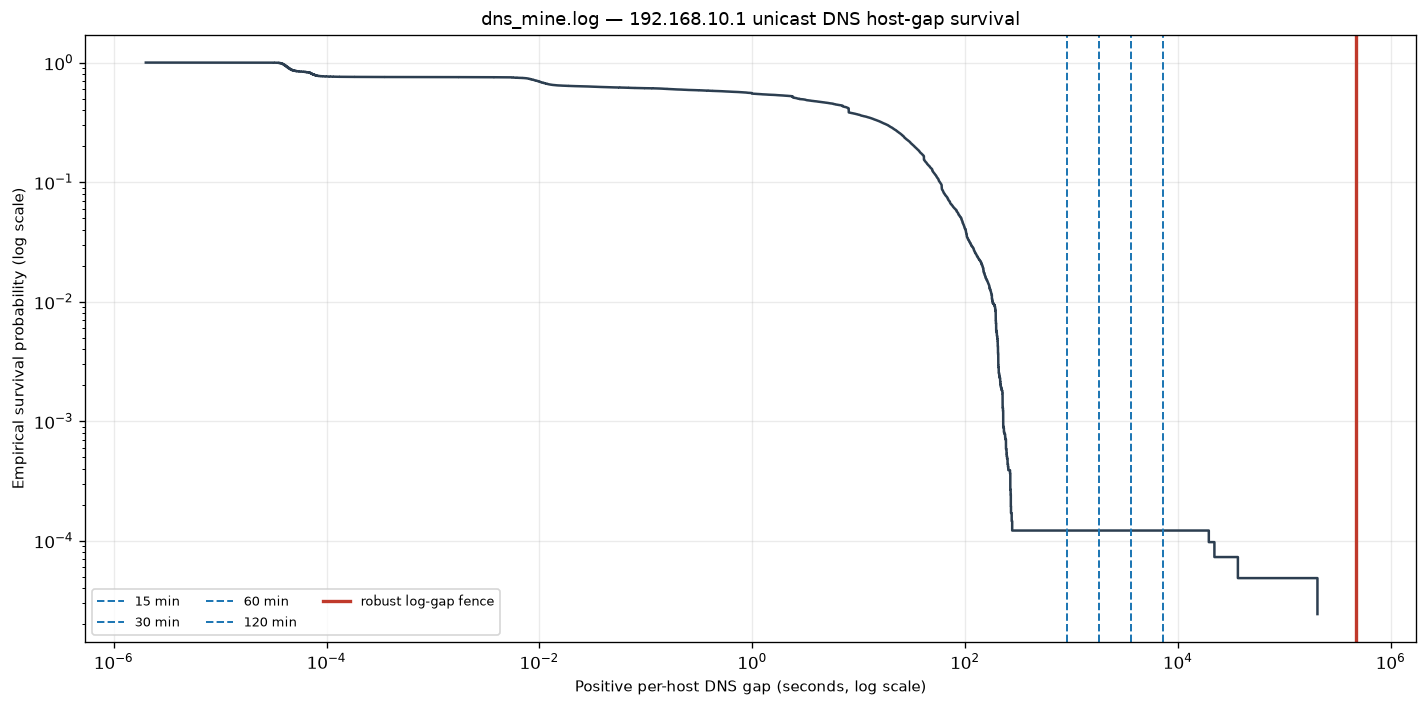

In [9]:
# ============================================================
# 12.1 AUDIT BENIGN INACTIVITY GAPS
# ============================================================
_gap_events = (
    benign_session_audit_events
    .sort(["host_id", "event_time", "_source_row"], maintain_order=True)
    .with_columns(
        [
            pl.col("event_time")
            .shift(1)
            .over("host_id")
            .alias("previous_event_time"),
            (
                pl.col("_event_time_us").diff().over("host_id")
                / 1_000_000.0
            ).alias("host_gap_seconds"),
        ]
    )
)

_positive_gap_events = _gap_events.filter(
    pl.col("host_gap_seconds") > 0
)


def _gap_quantile_record(
    frame: pl.DataFrame,
    host_id: str,
) -> dict:
    values = frame["host_gap_seconds"].to_numpy()
    values = values[np.isfinite(values) & (values > 0)]
    if values.size == 0:
        return {
            "host_id": host_id,
            "positive_gap_count": 0,
        }
    quantiles = np.quantile(
        values, [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
    )
    return {
        "host_id": host_id,
        "positive_gap_count": int(values.size),
        "gap_p50_seconds": float(quantiles[0]),
        "gap_p75_seconds": float(quantiles[1]),
        "gap_p90_seconds": float(quantiles[2]),
        "gap_p95_seconds": float(quantiles[3]),
        "gap_p99_seconds": float(quantiles[4]),
        "gap_p995_seconds": float(quantiles[5]),
        "gap_p999_seconds": float(quantiles[6]),
        "gap_max_seconds": float(values.max()),
    }


_gap_quantile_rows = [
    _gap_quantile_record(
        _positive_gap_events,
        f"{BENIGN_HOST_ID}:port{BENIGN_RESOLVER_PORT}",
    )
]
for _host_frame in _positive_gap_events.partition_by(
    "host_id", maintain_order=True
):
    _gap_quantile_rows.append(
        _gap_quantile_record(
            _host_frame, str(_host_frame["host_id"][0])
        )
    )
gap_quantiles = pl.DataFrame(
    _gap_quantile_rows, infer_schema_length=None
).sort("host_id")

_gap_threshold_rows = []
for _host_label, _host_frame in [
    (
        f"{BENIGN_HOST_ID}:port{BENIGN_RESOLVER_PORT}",
        _positive_gap_events,
    ),
    *[
        (str(part["host_id"][0]), part)
        for part in _positive_gap_events.partition_by(
            "host_id", maintain_order=True
        )
    ],
]:
    _gap_count = _host_frame.height
    for _minutes in SESSION_THRESHOLD_CANDIDATE_MINUTES:
        _seconds = 60.0 * _minutes
        _boundary_count = int(
            (_host_frame["host_gap_seconds"] > _seconds).sum()
        )
        _gap_threshold_rows.append(
            {
                "host_id": _host_label,
                "threshold_minutes": _minutes,
                "positive_gap_count": _gap_count,
                "boundary_gap_count": _boundary_count,
                "boundary_gap_pct": (
                    100.0 * _boundary_count / _gap_count
                    if _gap_count
                    else None
                ),
            }
        )
gap_threshold_counts = pl.DataFrame(_gap_threshold_rows)

largest_benign_gaps = (
    _positive_gap_events
    .select(
        "host_id",
        "previous_event_time",
        "event_time",
        "host_gap_seconds",
        "fqdn",
        "parent_domain",
        "_source_row",
    )
    .sort("host_gap_seconds", descending=True)
    .head(200)
)

host_inventory = (
    benign_session_audit_events
    .group_by("host_id", maintain_order=True)
    .agg(
        [
            pl.len().alias("event_count"),
            pl.col("event_time").min().alias("first_event_utc"),
            pl.col("event_time").max().alias("last_event_utc"),
            (
                (
                    pl.col("_event_time_us").max()
                    - pl.col("_event_time_us").min()
                )
                / 1_000_000.0
            ).alias("capture_span_seconds"),
            pl.col("fqdn").n_unique().alias("unique_fqdn_count"),
            pl.col("parent_domain")
            .n_unique()
            .alias("unique_parent_domain_count"),
            (pl.col("_resp_port") == 53)
            .mean()
            .alias("resolver_port_53_fraction"),
        ]
    )
    .sort("event_count", descending=True)
)

_all_positive_gaps = _positive_gap_events[
    "host_gap_seconds"
].to_numpy()
_all_positive_gaps = _all_positive_gaps[
    np.isfinite(_all_positive_gaps) & (_all_positive_gaps > 0)
]
_log_gaps = np.log1p(_all_positive_gaps)
_log_q1, _log_q3 = np.quantile(_log_gaps, [0.25, 0.75])
_log_iqr = float(_log_q3 - _log_q1)
ROBUST_LOG_GAP_FENCE_SECONDS = float(
    np.expm1(_log_q3 + 3.0 * _log_iqr)
)
_candidates_seconds = np.asarray(
    SESSION_THRESHOLD_CANDIDATE_MINUTES, dtype=float
) * 60.0
ROBUST_FENCE_WITHIN_CANDIDATE_GRID = bool(
    ROBUST_LOG_GAP_FENCE_SECONDS <= _candidates_seconds.max()
)

gap_policy_seed = pl.DataFrame(
    [
        {
            "method": "Q3 + 3*IQR on log1p(positive host gaps)",
            "log_gap_q1": float(_log_q1),
            "log_gap_q3": float(_log_q3),
            "log_gap_iqr": _log_iqr,
            "robust_gap_fence_seconds": ROBUST_LOG_GAP_FENCE_SECONDS,
            "robust_gap_fence_minutes": (
                ROBUST_LOG_GAP_FENCE_SECONDS / 60.0
            ),
            "fence_within_candidate_grid": (
                ROBUST_FENCE_WITHIN_CANDIDATE_GRID
            ),
            "used_as_selection_gate": False,
            "scientific_interpretation": (
                "audit only; do not snap an out-of-grid heavy-tail "
                "fence to the largest candidate"
            ),
            "candidate_grid_minutes": str(
                SESSION_THRESHOLD_CANDIDATE_MINUTES
            ),
        }
    ]
)

print("\nHost inventory")
display(host_inventory)
print("\nPositive host-gap quantiles")
display(gap_quantiles)
print("\nCandidate boundary counts")
display(gap_threshold_counts)
print("\nRobust benign gap-policy seed")
display(gap_policy_seed)
print("\nLargest observed benign gaps")
display(largest_benign_gaps.head(20))

# Plot the empirical survival curve without manufacturing empty observations.
_sorted_gaps = np.sort(_all_positive_gaps)
_survival = (
    (_sorted_gaps.size - np.arange(_sorted_gaps.size))
    / _sorted_gaps.size
)
fig, ax = plt.subplots(figsize=(12, 6))
ax.step(_sorted_gaps, _survival, where="post", color="#2c3e50")
for _minutes in SESSION_THRESHOLD_CANDIDATE_MINUTES:
    ax.axvline(
        60.0 * _minutes,
        linestyle="--",
        linewidth=1.2,
        label=f"{_minutes} min",
    )
ax.axvline(
    ROBUST_LOG_GAP_FENCE_SECONDS,
    color="#c0392b",
    linewidth=2,
    label="robust log-gap fence",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Positive per-host DNS gap (seconds, log scale)")
ax.set_ylabel("Empirical survival probability (log scale)")
ax.set_title(
    "dns_mine.log — 192.168.10.1 unicast DNS host-gap survival"
)
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plot_gap_survival_path = (
    SESSION_OUTPUT_DIR / "plot_01_gap_survival.png"
)
fig.savefig(plot_gap_survival_path, dpi=180, bbox_inches="tight")
plt.show()



Session-policy candidate summary


threshold_minutes,session_count,domain_session_count,boundary_count_excluding_first_per_host,median_session_duration_seconds,p95_session_duration_seconds,sessions_with_lt_8_events,events_in_lt_8_event_sessions,gru_candidate_rows,gru_eligible_rows,gru_eligible_pct,mahal_candidate_windows,mahal_finite_windows,mahal_finite_pct,support5_event_coverage_pct,support8_event_coverage_pct,support16_event_coverage_pct,support32_event_coverage_pct,boundary_events_identical_to_reference,boundary_symmetric_difference_count,max_changed_feature_rows_pct,max_normalized_p95_feature_diff,max_normalized_median_feature_diff,gru_eligibility_retention_vs_120,mahal_eligibility_retention_vs_120,support8_retention_vs_120
i64,i64,i64,i64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,bool,i64,f64,f64,f64,f64,f64,f64
15,5,6119,4,52019.368226,513675.184263,0,0,41078,25815,62.843858,27481,27481,100.0,71.495691,68.107016,65.295292,62.836555,true,0,0.0,0.0,0.0,1.0,1.0,1.0
30,5,6119,4,52019.368226,513675.184263,0,0,41078,25815,62.843858,27481,27481,100.0,71.495691,68.107016,65.295292,62.836555,true,0,0.0,0.0,0.0,1.0,1.0,1.0
60,5,6119,4,52019.368226,513675.184263,0,0,41078,25815,62.843858,27481,27481,100.0,71.495691,68.107016,65.295292,62.836555,true,0,0.0,0.0,0.0,1.0,1.0,1.0
120,5,6119,4,52019.368226,513675.184263,0,0,41078,25815,62.843858,27481,27481,100.0,71.495691,68.107016,65.295292,62.836555,true,0,0.0,0.0,0.0,1.0,1.0,1.0



Session-policy gates


threshold_minutes,gate_name,status,observed,expected
i64,str,str,str,str
15,"""exact_boundary_events_match_12…","""PASS""","""0""","""symmetric difference = 0"""
15,"""gru_eligibility_retention""","""PASS""","""0.9999999999999999""",""">= 0.95"""
15,"""mahal_eligibility_retention""","""PASS""","""1.0""",""">= 0.95"""
15,"""support8_retention""","""PASS""","""1.0""",""">= 0.95"""
15,"""changed_feature_rows""","""PASS""","""0.0""","""<= 5.0%"""
…,…,…,…,…
120,"""exact_boundary_events_match_12…","""PASS""","""0""","""symmetric difference = 0"""
120,"""gru_eligibility_retention""","""PASS""","""0.9999999999999999""",""">= 0.95"""
120,"""mahal_eligibility_retention""","""PASS""","""1.0""",""">= 0.95"""



Selected session policy


threshold_minutes,session_count,domain_session_count,boundary_count_excluding_first_per_host,median_session_duration_seconds,p95_session_duration_seconds,sessions_with_lt_8_events,events_in_lt_8_event_sessions,gru_candidate_rows,gru_eligible_rows,gru_eligible_pct,mahal_candidate_windows,mahal_finite_windows,mahal_finite_pct,support5_event_coverage_pct,support8_event_coverage_pct,support16_event_coverage_pct,support32_event_coverage_pct,boundary_events_identical_to_reference,boundary_symmetric_difference_count,max_changed_feature_rows_pct,max_normalized_p95_feature_diff,max_normalized_median_feature_diff,gru_eligibility_retention_vs_120,mahal_eligibility_retention_vs_120,support8_retention_vs_120,selection_status,robust_log_gap_fence_seconds,robust_log_gap_fence_used_as_gate,selection_rule
i64,i64,i64,i64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,bool,i64,f64,f64,f64,f64,f64,f64,str,f64,bool,str
15,5,6119,4,52019.368226,513675.184263,0,0,41078,25815,62.843858,27481,27481,100.0,71.495691,68.107016,65.295292,62.836555,true,0,0.0,0.0,0.0,1.0,1.0,1.0,"""SELECTED_BY_PREDECLARED_BENIGN…",467008.286654,false,"""smallest candidate with the sa…"


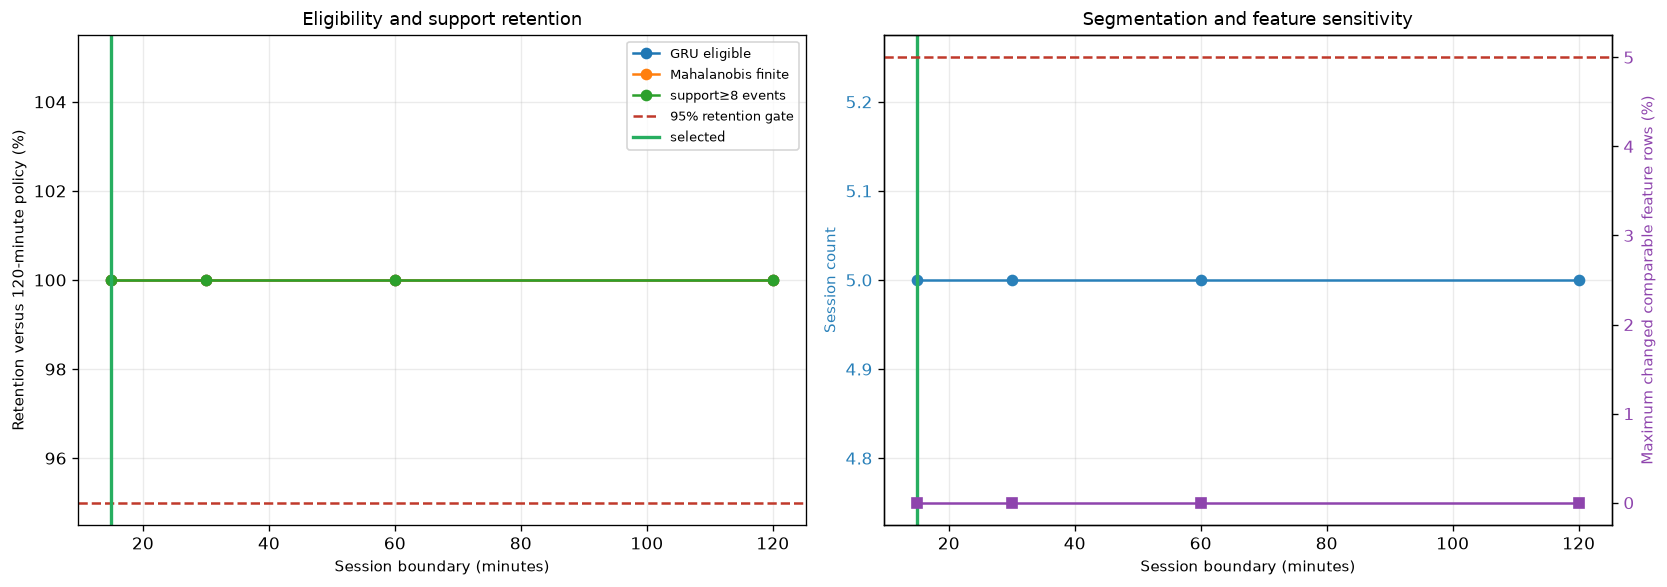

In [10]:
# ============================================================
# 12.2 RECALCULATE FEATURES FOR EVERY SESSION POLICY CANDIDATE
# ============================================================
_SESSION_GRU_FEATURES = list(GRU_LSTM_MODEL_INPUTS)
_SESSION_MAHAL_FEATURES = list(MAHALANOBIS_MODEL_INPUTS)


def _all_finite_session_expr(column_names: list[str]) -> pl.Expr:
    expression = pl.lit(True)
    for column_name in column_names:
        expression = expression & (
            pl.col(column_name).is_not_null()
            & pl.col(column_name).is_finite()
        )
    return expression


def _sessionize_benign(
    events: pl.DataFrame,
    threshold_minutes: int,
) -> pl.DataFrame:
    threshold_seconds = 60.0 * threshold_minutes
    return (
        events
        .sort(["host_id", "event_time", "_source_row"], maintain_order=True)
        .with_columns(
            (
                pl.col("_event_time_us").diff().over("host_id")
                / 1_000_000.0
            ).alias("_raw_host_gap_seconds")
        )
        .with_columns(
            (
                pl.col("_raw_host_gap_seconds").is_null()
                | (pl.col("_raw_host_gap_seconds") > threshold_seconds)
            ).alias("_session_break")
        )
        .with_columns(
            pl.col("_session_break")
            .cast(pl.Int64)
            .cum_sum()
            .over("host_id")
            .alias("activity_session_index")
        )
        .with_columns(
            pl.concat_str(
                [
                    pl.col("host_id"),
                    pl.lit("::session_"),
                    pl.col("activity_session_index").cast(pl.String),
                ]
            ).alias("activity_session_id")
        )
    )


def _sessionized_feature_frames(
    session_events: pl.DataFrame,
) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    host_session_keys = [
        "source_file",
        "host_id",
        "activity_session_id",
    ]
    domain_session_base_keys = host_session_keys + [
        "parent_domain",
    ]
    domain_session_keys = domain_session_base_keys + [
        "domain_activity_session_id",
    ]
    domain_inactivity_seconds = 60.0 * DOMAIN_INACTIVITY_MINUTES

    event_base = (
        session_events
        .sort(
            [
                "source_file",
                "host_id",
                "activity_session_id",
                "event_time",
                "_source_row",
            ],
            maintain_order=True,
        )
        .with_columns(
            [
                (
                    pl.col("_event_time_us")
                    .diff()
                    .over(host_session_keys)
                    / 1_000_000.0
                ).alias("host_iat_seconds"),
                (
                    pl.col("_event_time_us")
                    .diff()
                    .over(domain_session_base_keys)
                    / 1_000_000.0
                ).alias("_raw_domain_gap_seconds"),
            ]
        )
        .with_columns(
            (
                pl.col("_raw_domain_gap_seconds").is_null()
                | (
                    pl.col("_raw_domain_gap_seconds")
                    > domain_inactivity_seconds
                )
            ).alias("_domain_session_break")
        )
        .with_columns(
            pl.col("_domain_session_break")
            .cast(pl.Int64)
            .cum_sum()
            .over(domain_session_base_keys)
            .alias("domain_activity_session_index")
        )
        .with_columns(
            pl.concat_str(
                [
                    pl.col("activity_session_id"),
                    pl.lit("::domain_session_"),
                    pl.col("domain_activity_session_index")
                    .cast(pl.String),
                ]
            ).alias("domain_activity_session_id")
        )
        .with_columns(
            [
                (
                    pl.col("_event_time_us")
                    .diff()
                    .over(domain_session_keys)
                    / 1_000_000.0
                ).alias("domain_iat_seconds"),
                pl.col("event_time")
                .cum_count()
                .over(domain_session_keys)
                .alias("domain_event_count_to_date"),
            ]
        )
        .with_columns(
            [
                pl.when(
                    pl.col("domain_iat_seconds").is_not_null()
                    & (pl.col("domain_iat_seconds") >= 0)
                )
                .then((pl.col("domain_iat_seconds") + 1.0).log())
                .otherwise(pl.lit(None, dtype=pl.Float64))
                .alias("log_domain_iat"),
                pl.when(
                    pl.col("host_iat_seconds").is_not_null()
                    & (pl.col("host_iat_seconds") >= 0)
                )
                .then((pl.col("host_iat_seconds") + 1.0).log())
                .otherwise(pl.lit(None, dtype=pl.Float64))
                .alias("log_host_iat"),
            ]
        )
        .with_columns(
            [
                pl.col("log_domain_iat")
                .diff()
                .over(domain_session_keys)
                .alias("delta_log_domain_iat"),
                pl.col("log_domain_iat")
                .shift(1)
                .over(domain_session_keys)
                .alias("_prior_log_domain_iat"),
                pl.col("log_domain_iat")
                .shift(-1)
                .over(domain_session_keys)
                .alias("target_next_log_domain_iat"),
            ]
        )
        .with_columns(
            [
                pl.col("_prior_log_domain_iat")
                .rolling_mean(window_size=4)
                .over(domain_session_keys)
                .alias("rolling_log_iat_mean_4"),
                pl.col("_prior_log_domain_iat")
                .rolling_std(window_size=8, ddof=1)
                .over(domain_session_keys)
                .alias("rolling_log_iat_std_8"),
            ]
        )
    )

    gru_rows = (
        event_base
        .filter(pl.col("parent_domain").is_not_null())
        .select(
            [
                "event_time",
                "source_file",
                "host_id",
                "activity_session_id",
                "activity_session_index",
                "parent_domain",
                "domain_activity_session_id",
                "domain_activity_session_index",
                "_source_row",
                "domain_event_count_to_date",
                "domain_iat_seconds",
                "host_iat_seconds",
            ]
            + _SESSION_GRU_FEATURES
            + ["target_next_log_domain_iat"]
        )
        .with_columns(
            (
                _all_finite_session_expr(_SESSION_GRU_FEATURES)
                & pl.col("target_next_log_domain_iat").is_not_null()
                & pl.col("target_next_log_domain_iat").is_finite()
            ).alias("is_fully_defined")
        )
    )

    host_time_lookup = {}
    for host_capture in (
        session_events
        .filter(
            pl.col("host_id").is_not_null()
            & pl.col("_event_time_us").is_not_null()
        )
        .partition_by(host_session_keys, maintain_order=True)
    ):
        key = (
            host_capture["source_file"][0],
            host_capture["host_id"][0],
            host_capture["activity_session_id"][0],
        )
        host_time_lookup[key] = np.sort(
            host_capture["_event_time_us"].to_numpy()
        )

    mahal_rows = []
    domain_partitions = (
        event_base
        .filter(
            pl.col("host_id").is_not_null()
            & pl.col("parent_domain").is_not_null()
            & pl.col("_event_time_us").is_not_null()
        )
        .partition_by(domain_session_keys, maintain_order=True)
    )
    for domain_capture in domain_partitions:
        domain_capture = domain_capture.sort(
            ["event_time", "_source_row"], maintain_order=True
        )
        times_us = domain_capture["_event_time_us"].to_numpy()
        source_file = domain_capture["source_file"][0]
        host_id = domain_capture["host_id"][0]
        session_id = domain_capture["activity_session_id"][0]
        session_index = int(
            domain_capture["activity_session_index"][0]
        )
        parent_domain = domain_capture["parent_domain"][0]
        domain_session_id = domain_capture[
            "domain_activity_session_id"
        ][0]
        domain_session_index = int(
            domain_capture["domain_activity_session_index"][0]
        )
        host_times_us = host_time_lookup[
            (source_file, host_id, session_id)
        ]

        for end_index in range(
            MAHAL_MIN_COMPUTABLE_EVENTS_SESSION - 1,
            domain_capture.height,
        ):
            start_index = max(
                0,
                end_index - MAHAL_MAX_WINDOW_EVENTS_SESSION + 1,
            )
            window_times_us = times_us[start_index : end_index + 1]
            event_count = int(window_times_us.size)
            iat_seconds = np.diff(window_times_us) / 1_000_000.0
            if np.any(iat_seconds < 0):
                continue

            log_iats = np.log1p(iat_seconds)
            log_median = float(np.median(log_iats))
            log_p95 = float(np.percentile(log_iats, 95))
            log_mad = float(
                np.median(np.abs(log_iats - log_median))
            )
            lag_x = log_iats[:-1]
            lag_y = log_iats[1:]
            if (
                lag_x.size >= 2
                and np.std(lag_x) > 0
                and np.std(lag_y) > 0
            ):
                lag1 = float(np.corrcoef(lag_x, lag_y)[0, 1])
            else:
                lag1 = None

            window_start_us = int(window_times_us[0])
            window_end_us = int(window_times_us[-1])
            window_span_seconds = (
                window_end_us - window_start_us
            ) / 1_000_000.0
            host_left = np.searchsorted(
                host_times_us, window_start_us, side="left"
            )
            host_right = np.searchsorted(
                host_times_us, window_end_us, side="right"
            )
            host_event_count = int(host_right - host_left)
            host_interval_count = max(host_event_count - 1, 0)
            domain_interval_count = int(iat_seconds.size)
            if (
                window_span_seconds > 0
                and host_interval_count > 0
            ):
                rate_ratio = (
                    domain_interval_count / host_interval_count
                )
            else:
                rate_ratio = None

            row = domain_capture.row(end_index, named=True)
            mahal_rows.append(
                {
                    "event_time": row["event_time"],
                    "window_start_time": domain_capture[
                        "event_time"
                    ][start_index],
                    "source_file": source_file,
                    "host_id": host_id,
                    "activity_session_id": session_id,
                    "activity_session_index": session_index,
                    "parent_domain": parent_domain,
                    "domain_activity_session_id": domain_session_id,
                    "domain_activity_session_index": (
                        domain_session_index
                    ),
                    "_source_row": int(row["_source_row"]),
                    "event_count": event_count,
                    "host_event_count_same_interval": (
                        host_event_count
                    ),
                    "window_span_seconds": window_span_seconds,
                    "log_iat_median": log_median,
                    "log_iat_p95": log_p95,
                    "log_iat_mad": log_mad,
                    "log_iat_lag1_autocorrelation": lag1,
                    "domain_host_rate_ratio": rate_ratio,
                }
            )

    mahal_rows_frame = pl.DataFrame(
        mahal_rows, infer_schema_length=None
    )
    if mahal_rows_frame.height:
        mahal_rows_frame = mahal_rows_frame.with_columns(
            _all_finite_session_expr(
                _SESSION_MAHAL_FEATURES
            ).alias("is_fully_defined")
        )
    return event_base, gru_rows, mahal_rows_frame


def _session_summary(
    session_events: pl.DataFrame,
) -> pl.DataFrame:
    return (
        session_events
        .group_by(
            ["host_id", "activity_session_id"],
            maintain_order=True,
        )
        .agg(
            [
                pl.len().alias("session_event_count"),
                pl.col("event_time").min().alias("session_start_utc"),
                pl.col("event_time").max().alias("session_end_utc"),
                (
                    (
                        pl.col("_event_time_us").max()
                        - pl.col("_event_time_us").min()
                    )
                    / 1_000_000.0
                ).alias("session_duration_seconds"),
                pl.col("parent_domain")
                .n_unique()
                .alias("unique_parent_domain_count"),
            ]
        )
    )


def _domain_session_summary(
    event_features: pl.DataFrame,
) -> pl.DataFrame:
    domain_keys = [
        "host_id",
        "activity_session_id",
        "parent_domain",
        "domain_activity_session_id",
    ]
    return (
        event_features
        .filter(pl.col("parent_domain").is_not_null())
        .group_by(domain_keys, maintain_order=True)
        .agg(
            [
                pl.len().alias("domain_session_event_count"),
                pl.col("event_time")
                .min()
                .alias("domain_session_start_utc"),
                pl.col("event_time")
                .max()
                .alias("domain_session_end_utc"),
                (
                    (
                        pl.col("_event_time_us").max()
                        - pl.col("_event_time_us").min()
                    )
                    / 1_000_000.0
                ).alias("domain_session_duration_seconds"),
                pl.col("domain_iat_seconds")
                .max()
                .alias("max_domain_iat_seconds"),
            ]
        )
    )


def _parent_support(
    event_features: pl.DataFrame,
    policy_minutes: int,
) -> pl.DataFrame:
    valid = event_features.filter(
        pl.col("parent_domain").is_not_null()
    )
    counts = (
        valid
        .group_by(
            [
                "host_id",
                "activity_session_id",
                "parent_domain",
                "domain_activity_session_id",
            ],
            maintain_order=True,
        )
        .len(name="group_event_count")
    )
    rows = []
    total_valid = valid.height
    for support in SUPPORT_THRESHOLD_CANDIDATES:
        supported = counts.filter(
            pl.col("group_event_count") >= support
        )
        supported_events = int(
            supported["group_event_count"].sum()
            if supported.height
            else 0
        )
        rows.append(
            {
                "session_threshold_minutes": policy_minutes,
                "minimum_events": support,
                "groups_meeting_threshold": supported.height,
                "sessions_contributing": (
                    supported[
                        "domain_activity_session_id"
                    ].n_unique()
                    if supported.height
                    else 0
                ),
                "events_in_supported_groups": supported_events,
                "valid_parent_domain_events": total_valid,
                "pct_valid_parent_domain_events": (
                    100.0 * supported_events / total_valid
                    if total_valid
                    else None
                ),
            }
        )
    return pl.DataFrame(rows)


_candidate_artifacts = {}
_candidate_summary_rows = []
_candidate_support_frames = []

for _policy_minutes in SESSION_THRESHOLD_CANDIDATE_MINUTES:
    _session_events = _sessionize_benign(
        benign_session_audit_events, _policy_minutes
    )
    _event_features, _gru_rows, _mahal_rows = (
        _sessionized_feature_frames(_session_events)
    )
    _sessions = _session_summary(_session_events)
    _domain_sessions = _domain_session_summary(_event_features)
    _support = _parent_support(
        _event_features, _policy_minutes
    )
    _boundary_source_rows = set(
        _session_events
        .filter(
            pl.col("_session_break")
            & pl.col("_raw_host_gap_seconds").is_not_null()
        )["_source_row"]
        .to_list()
    )
    _candidate_support_frames.append(_support)

    _gru_eligible = int(_gru_rows["is_fully_defined"].sum())
    _mahal_finite = int(
        _mahal_rows["is_fully_defined"].sum()
        if _mahal_rows.height
        else 0
    )
    _support_map = {
        int(row["minimum_events"]): float(
            row["pct_valid_parent_domain_events"]
        )
        for row in _support.to_dicts()
    }
    _session_durations = _sessions[
        "session_duration_seconds"
    ].to_numpy()
    _candidate_summary_rows.append(
        {
            "threshold_minutes": _policy_minutes,
            "session_count": _sessions.height,
            "domain_session_count": _domain_sessions.height,
            "boundary_count_excluding_first_per_host": (
                _sessions.height - host_inventory.height
            ),
            "median_session_duration_seconds": float(
                np.median(_session_durations)
            ),
            "p95_session_duration_seconds": float(
                np.percentile(_session_durations, 95)
            ),
            "sessions_with_lt_8_events": int(
                (_sessions["session_event_count"] < 8).sum()
            ),
            "events_in_lt_8_event_sessions": int(
                _sessions.filter(
                    pl.col("session_event_count") < 8
                )["session_event_count"].sum()
                or 0
            ),
            "gru_candidate_rows": _gru_rows.height,
            "gru_eligible_rows": _gru_eligible,
            "gru_eligible_pct": (
                100.0 * _gru_eligible / _gru_rows.height
                if _gru_rows.height
                else None
            ),
            "mahal_candidate_windows": _mahal_rows.height,
            "mahal_finite_windows": _mahal_finite,
            "mahal_finite_pct": (
                100.0 * _mahal_finite / _mahal_rows.height
                if _mahal_rows.height
                else None
            ),
            "support5_event_coverage_pct": _support_map[5],
            "support8_event_coverage_pct": _support_map[8],
            "support16_event_coverage_pct": _support_map[16],
            "support32_event_coverage_pct": _support_map[32],
        }
    )
    _candidate_artifacts[_policy_minutes] = {
        "session_events": _session_events,
        "event_features": _event_features,
        "gru": _gru_rows,
        "mahal": _mahal_rows,
        "sessions": _sessions,
        "domain_sessions": _domain_sessions,
        "support": _support,
        "boundary_source_rows": _boundary_source_rows,
    }

sessionized_support_all_candidates = pl.concat(
    _candidate_support_frames, how="vertical_relaxed"
)
_base_candidate_summary = pl.DataFrame(
    _candidate_summary_rows, infer_schema_length=None
).sort("threshold_minutes")

_reference_boundary_rows = _candidate_artifacts[
    SESSION_REFERENCE_MINUTES
]["boundary_source_rows"]
_boundary_comparison = pl.DataFrame(
    [
        {
            "threshold_minutes": minutes,
            "boundary_events_identical_to_reference": (
                artifacts["boundary_source_rows"]
                == _reference_boundary_rows
            ),
            "boundary_symmetric_difference_count": len(
                artifacts["boundary_source_rows"]
                ^ _reference_boundary_rows
            ),
        }
        for minutes, artifacts in _candidate_artifacts.items()
    ]
)
_base_candidate_summary = _base_candidate_summary.join(
    _boundary_comparison,
    on="threshold_minutes",
    how="left",
)


def _paired_feature_difference_rows(
    candidate: pl.DataFrame,
    reference: pl.DataFrame,
    feature_names: list[str],
    representation: str,
    policy_minutes: int,
) -> list[dict]:
    if not candidate.height or not reference.height:
        return []
    key_columns = ["_source_row", "host_id", "parent_domain"]
    candidate_defined = candidate.filter(
        pl.col("is_fully_defined")
    )
    reference_defined = reference.filter(
        pl.col("is_fully_defined")
    )
    reference_select = key_columns + [
        pl.col(name).alias(f"{name}__reference")
        for name in feature_names
    ]
    paired = candidate_defined.join(
        reference_defined.select(reference_select),
        on=key_columns,
        how="inner",
    )
    rows = []
    for feature_name in feature_names:
        observed = paired[feature_name].to_numpy()
        expected = paired[
            f"{feature_name}__reference"
        ].to_numpy()
        finite = np.isfinite(observed) & np.isfinite(expected)
        observed = observed[finite]
        expected = expected[finite]
        if observed.size == 0:
            continue
        abs_diff = np.abs(observed - expected)
        reference_iqr = float(
            np.quantile(expected, 0.75)
            - np.quantile(expected, 0.25)
        )
        scale = max(reference_iqr, 1e-12)
        rows.append(
            {
                "threshold_minutes": policy_minutes,
                "representation": representation,
                "feature_name": feature_name,
                "paired_rows": int(observed.size),
                "changed_rows": int((abs_diff > 1e-12).sum()),
                "changed_rows_pct": (
                    100.0
                    * float((abs_diff > 1e-12).sum())
                    / observed.size
                ),
                "median_abs_diff": float(np.median(abs_diff)),
                "p95_abs_diff": float(
                    np.percentile(abs_diff, 95)
                ),
                "reference_iqr": reference_iqr,
                "normalized_median_abs_diff": float(
                    np.median(abs_diff) / scale
                ),
                "normalized_p95_abs_diff": float(
                    np.percentile(abs_diff, 95) / scale
                ),
            }
        )
    return rows


_reference_artifacts = _candidate_artifacts[
    SESSION_REFERENCE_MINUTES
]
_feature_difference_rows = []
for _policy_minutes in SESSION_THRESHOLD_CANDIDATE_MINUTES:
    _feature_difference_rows.extend(
        _paired_feature_difference_rows(
            _candidate_artifacts[_policy_minutes]["gru"],
            _reference_artifacts["gru"],
            _SESSION_GRU_FEATURES,
            "GRU/LSTM",
            _policy_minutes,
        )
    )
    _feature_difference_rows.extend(
        _paired_feature_difference_rows(
            _candidate_artifacts[_policy_minutes]["mahal"],
            _reference_artifacts["mahal"],
            _SESSION_MAHAL_FEATURES,
            "Mahalanobis",
            _policy_minutes,
        )
    )

session_policy_feature_differences = pl.DataFrame(
    _feature_difference_rows, infer_schema_length=None
)
_difference_aggregate = (
    session_policy_feature_differences
    .group_by("threshold_minutes", maintain_order=True)
    .agg(
        [
            pl.col("changed_rows_pct")
            .max()
            .alias("max_changed_feature_rows_pct"),
            pl.col("normalized_p95_abs_diff")
            .max()
            .alias("max_normalized_p95_feature_diff"),
            pl.col("normalized_median_abs_diff")
            .max()
            .alias("max_normalized_median_feature_diff"),
        ]
    )
)

_reference_summary = _base_candidate_summary.filter(
    pl.col("threshold_minutes") == SESSION_REFERENCE_MINUTES
).row(0, named=True)
session_policy_candidate_summary = (
    _base_candidate_summary
    .join(
        _difference_aggregate,
        on="threshold_minutes",
        how="left",
    )
    .with_columns(
        [
            (
                pl.col("gru_eligible_rows")
                / float(_reference_summary["gru_eligible_rows"])
            ).alias("gru_eligibility_retention_vs_120"),
            (
                pl.col("mahal_finite_windows")
                / float(_reference_summary["mahal_finite_windows"])
            ).alias("mahal_eligibility_retention_vs_120"),
            (
                pl.col("support8_event_coverage_pct")
                / float(
                    _reference_summary[
                        "support8_event_coverage_pct"
                    ]
                )
            ).alias("support8_retention_vs_120"),
        ]
    )
)

_session_gate_rows = []
for _row in session_policy_candidate_summary.to_dicts():
    _minutes = int(_row["threshold_minutes"])
    _gates = [
        (
            "exact_boundary_events_match_120_minute_reference",
            _row["boundary_events_identical_to_reference"],
            _row["boundary_symmetric_difference_count"],
            "symmetric difference = 0",
        ),
        (
            "gru_eligibility_retention",
            _row["gru_eligibility_retention_vs_120"]
            >= SESSION_MIN_ELIGIBILITY_RETENTION,
            _row["gru_eligibility_retention_vs_120"],
            f">= {SESSION_MIN_ELIGIBILITY_RETENTION}",
        ),
        (
            "mahal_eligibility_retention",
            _row["mahal_eligibility_retention_vs_120"]
            >= SESSION_MIN_ELIGIBILITY_RETENTION,
            _row["mahal_eligibility_retention_vs_120"],
            f">= {SESSION_MIN_ELIGIBILITY_RETENTION}",
        ),
        (
            "support8_retention",
            _row["support8_retention_vs_120"]
            >= SESSION_MIN_SUPPORT8_RETENTION,
            _row["support8_retention_vs_120"],
            f">= {SESSION_MIN_SUPPORT8_RETENTION}",
        ),
        (
            "changed_feature_rows",
            _row["max_changed_feature_rows_pct"]
            <= SESSION_MAX_CHANGED_FEATURE_ROWS_PCT,
            _row["max_changed_feature_rows_pct"],
            f"<= {SESSION_MAX_CHANGED_FEATURE_ROWS_PCT}%",
        ),
    ]
    for gate_name, passed, observed, expected in _gates:
        _session_gate_rows.append(
            {
                "threshold_minutes": _minutes,
                "gate_name": gate_name,
                "status": "PASS" if bool(passed) else "FAIL",
                "observed": str(observed),
                "expected": expected,
            }
        )

session_policy_gate_results = pl.DataFrame(_session_gate_rows)
_session_pass_counts = (
    session_policy_gate_results
    .group_by("threshold_minutes", maintain_order=True)
    .agg(
        [
            (pl.col("status") == "PASS")
            .sum()
            .alias("passed_gates"),
            pl.len().alias("total_gates"),
        ]
    )
    .with_columns(
        (
            pl.col("passed_gates") == pl.col("total_gates")
        ).alias("all_gates_pass")
    )
    .sort("threshold_minutes")
)
_passing_session_policies = _session_pass_counts.filter(
    pl.col("all_gates_pass")
)
if _passing_session_policies.height:
    SELECTED_SESSION_THRESHOLD_MINUTES = int(
        _passing_session_policies["threshold_minutes"].min()
    )
    SESSION_POLICY_SELECTION_STATUS = (
        "SELECTED_BY_PREDECLARED_BENIGN_GATES"
    )
else:
    SELECTED_SESSION_THRESHOLD_MINUTES = int(
        SESSION_REFERENCE_MINUTES
    )
    SESSION_POLICY_SELECTION_STATUS = (
        "CONSERVATIVE_120_MINUTE_FALLBACK_NO_SHORTER_POLICY_PASSED"
    )

selected_session_policy = (
    session_policy_candidate_summary
    .filter(
        pl.col("threshold_minutes")
        == SELECTED_SESSION_THRESHOLD_MINUTES
    )
    .with_columns(
        [
            pl.lit(SESSION_POLICY_SELECTION_STATUS)
            .alias("selection_status"),
            pl.lit(ROBUST_LOG_GAP_FENCE_SECONDS)
            .alias("robust_log_gap_fence_seconds"),
            pl.lit(False)
            .alias("robust_log_gap_fence_used_as_gate"),
            pl.lit(
                "smallest candidate with the same exact boundary events "
                "as 120 minutes and passing all retention/sensitivity gates"
            ).alias("selection_rule"),
        ]
    )
)

print("\nSession-policy candidate summary")
display(session_policy_candidate_summary)
print("\nSession-policy gates")
display(session_policy_gate_results)
print("\nSelected session policy")
display(selected_session_policy)

# Candidate trade-off plot.
_plot_rows = session_policy_candidate_summary.sort(
    "threshold_minutes"
).to_dicts()
_x = np.asarray(
    [row["threshold_minutes"] for row in _plot_rows],
    dtype=float,
)
_gru_retention = np.asarray(
    [
        100.0 * row["gru_eligibility_retention_vs_120"]
        for row in _plot_rows
    ]
)
_mahal_retention = np.asarray(
    [
        100.0 * row["mahal_eligibility_retention_vs_120"]
        for row in _plot_rows
    ]
)
_support_retention = np.asarray(
    [
        100.0 * row["support8_retention_vs_120"]
        for row in _plot_rows
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(_x, _gru_retention, marker="o", label="GRU eligible")
axes[0].plot(
    _x, _mahal_retention, marker="o", label="Mahalanobis finite"
)
axes[0].plot(
    _x, _support_retention, marker="o", label="support≥8 events"
)
axes[0].axhline(
    100.0 * SESSION_MIN_ELIGIBILITY_RETENTION,
    color="#c0392b",
    linestyle="--",
    label="95% retention gate",
)
axes[0].axvline(
    SELECTED_SESSION_THRESHOLD_MINUTES,
    color="#27ae60",
    linewidth=2,
    label="selected",
)
axes[0].set_xlabel("Session boundary (minutes)")
axes[0].set_ylabel("Retention versus 120-minute policy (%)")
axes[0].set_title("Eligibility and support retention")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

_sessions_plot = np.asarray(
    [row["session_count"] for row in _plot_rows], dtype=float
)
_changed_plot = np.asarray(
    [
        row["max_changed_feature_rows_pct"]
        for row in _plot_rows
    ],
    dtype=float,
)
axes[1].plot(
    _x, _sessions_plot, marker="o", color="#2980b9",
    label="session count",
)
axes[1].set_xlabel("Session boundary (minutes)")
axes[1].set_ylabel("Session count", color="#2980b9")
axes[1].tick_params(axis="y", labelcolor="#2980b9")
axes[1].grid(alpha=0.25)
_axis_right = axes[1].twinx()
_axis_right.plot(
    _x, _changed_plot, marker="s", color="#8e44ad",
    label="max changed feature rows",
)
_axis_right.axhline(
    SESSION_MAX_CHANGED_FEATURE_ROWS_PCT,
    color="#c0392b",
    linestyle="--",
)
_axis_right.set_ylabel(
    "Maximum changed comparable feature rows (%)",
    color="#8e44ad",
)
_axis_right.tick_params(axis="y", labelcolor="#8e44ad")
axes[1].axvline(
    SELECTED_SESSION_THRESHOLD_MINUTES,
    color="#27ae60",
    linewidth=2,
)
axes[1].set_title("Segmentation and feature sensitivity")
fig.tight_layout()
plot_session_policy_path = (
    SESSION_OUTPUT_DIR / "plot_02_session_policy_sensitivity.png"
)
fig.savefig(
    plot_session_policy_path, dpi=180, bbox_inches="tight"
)
plt.show()


In [11]:
# ============================================================
# 12.3 FREEZE SELECTED SESSION POLICY AND RECHECK SUPPORT
# ============================================================
_selected_artifacts = _candidate_artifacts[
    SELECTED_SESSION_THRESHOLD_MINUTES
]
sessionized_host_events = _selected_artifacts[
    "session_events"
].clone()
sessionized_event_feature_base = _selected_artifacts[
    "event_features"
].clone()
sessionized_benign_events = sessionized_event_feature_base.clone()
sessionized_gru_feature_rows = _selected_artifacts["gru"].clone()
sessionized_mahalanobis_feature_windows = _selected_artifacts[
    "mahal"
].clone()
selected_session_summary = _selected_artifacts["sessions"].clone()
selected_domain_session_summary = _selected_artifacts[
    "domain_sessions"
].clone()
selected_sessionized_parent_support = _selected_artifacts[
    "support"
].clone()

_session_feature_eligibility_rows = []
for _support in SUPPORT_THRESHOLD_CANDIDATES:
    _gru_support_eligible = sessionized_gru_feature_rows.filter(
        pl.col("is_fully_defined")
        & (pl.col("domain_event_count_to_date") >= _support)
    )
    _mahal_support_eligible = (
        sessionized_mahalanobis_feature_windows.filter(
            pl.col("is_fully_defined")
            & (pl.col("event_count") >= _support)
        )
    )
    _session_feature_eligibility_rows.extend(
        [
            {
                "representation": "GRU/LSTM event rows",
                "minimum_events": _support,
                "candidate_rows": sessionized_gru_feature_rows.height,
                "eligible_rows": _gru_support_eligible.height,
                "eligible_pct": (
                    100.0
                    * _gru_support_eligible.height
                    / sessionized_gru_feature_rows.height
                    if sessionized_gru_feature_rows.height
                    else None
                ),
            },
            {
                "representation": "Mahalanobis trailing windows",
                "minimum_events": _support,
                "candidate_rows": (
                    sessionized_mahalanobis_feature_windows.height
                ),
                "eligible_rows": _mahal_support_eligible.height,
                "eligible_pct": (
                    100.0
                    * _mahal_support_eligible.height
                    / sessionized_mahalanobis_feature_windows.height
                    if sessionized_mahalanobis_feature_windows.height
                    else None
                ),
            },
        ]
    )

sessionized_feature_eligibility = pl.DataFrame(
    _session_feature_eligibility_rows
)

print(
    "\nFrozen session boundary: "
    f"{SELECTED_SESSION_THRESHOLD_MINUTES} minutes"
)
print("\nSession summary")
display(
    selected_session_summary.select(
        [
            pl.len().alias("sessions"),
            pl.col("session_event_count")
            .median()
            .alias("median_events_per_session"),
            pl.col("session_event_count")
            .quantile(0.95)
            .alias("p95_events_per_session"),
            pl.col("session_duration_seconds")
            .median()
            .alias("median_session_duration_seconds"),
            pl.col("session_duration_seconds")
            .quantile(0.95)
            .alias("p95_session_duration_seconds"),
        ]
    )
)
print("\nParent-domain support after session boundaries")
display(selected_sessionized_parent_support)
print("\nParent-domain activity-session summary")
display(
    selected_domain_session_summary.select(
        [
            pl.len().alias("domain_sessions"),
            pl.col("domain_session_event_count")
            .median()
            .alias("median_events_per_domain_session"),
            pl.col("domain_session_event_count")
            .quantile(0.95)
            .alias("p95_events_per_domain_session"),
            pl.col("domain_session_duration_seconds")
            .median()
            .alias("median_domain_session_duration_seconds"),
            pl.col("domain_session_duration_seconds")
            .quantile(0.95)
            .alias("p95_domain_session_duration_seconds"),
        ]
    )
)
print("\nFeature eligibility by candidate support threshold")
display(sessionized_feature_eligibility)



Frozen session boundary: 15 minutes

Session summary


sessions,median_events_per_session,p95_events_per_session,median_session_duration_seconds,p95_session_duration_seconds
u32,f64,f64,f64,f64
5,3048.0,33397.0,52019.368226,613693.948682



Parent-domain support after session boundaries


session_threshold_minutes,minimum_events,groups_meeting_threshold,sessions_contributing,events_in_supported_groups,valid_parent_domain_events,pct_valid_parent_domain_events
i64,i64,i64,i64,i64,i64,f64
15,5,472,203,29369,41078,71.495691
15,8,232,98,27977,41078,68.107016
15,16,106,43,26822,41078,65.295292
15,32,60,31,25812,41078,62.836555



Parent-domain activity-session summary


domain_sessions,median_events_per_domain_session,p95_events_per_domain_session,median_domain_session_duration_seconds,p95_domain_session_duration_seconds
u32,f64,f64,f64,f64
6119,2.0,6.0,0.000047,900.000669



Feature eligibility by candidate support threshold


representation,minimum_events,candidate_rows,eligible_rows,eligible_pct
str,i64,i64,i64,f64
"""GRU/LSTM event rows""",5,41078,25815,62.843858
"""Mahalanobis trailing windows""",5,27481,27481,100.0
"""GRU/LSTM event rows""",8,41078,25815,62.843858
"""Mahalanobis trailing windows""",8,27481,26353,95.895346
"""GRU/LSTM event rows""",16,41078,25126,61.166561
"""Mahalanobis trailing windows""",16,27481,25232,91.816164
"""GRU/LSTM event rows""",32,41078,23892,58.16252
"""Mahalanobis trailing windows""",32,27481,23952,87.1584



Matched benign feature stability versus 32 events


support_events,feature_name,matched_windows,median_abs_error_vs_32,p90_abs_error_vs_32,reference32_iqr,normalized_median_abs_error_vs_32,correlation_with_32
i64,str,i64,f64,f64,f64,f64,f64
5,"""log_iat_median""",23952,0.493442,2.572334,0.953132,0.517705,0.504482
5,"""log_iat_p95""",23952,0.157395,0.656087,0.500418,0.314527,0.877447
5,"""log_iat_mad""",23952,0.506547,1.908835,0.820388,0.617448,0.20323
5,"""log_iat_lag1_autocorrelation""",23952,0.165205,0.702952,0.435587,0.379269,0.5812
5,"""domain_host_rate_ratio""",23952,0.037318,0.15847,0.166147,0.224612,0.840331
…,…,…,…,…,…,…,…
32,"""log_iat_median""",23952,0.0,0.0,0.953132,0.0,1.0
32,"""log_iat_p95""",23952,0.0,0.0,0.500418,0.0,1.0
32,"""log_iat_mad""",23952,0.0,0.0,0.820388,0.0,1.0



Support candidate summary


support_events,matched_mature_windows,median_normalized_feature_error_vs_32,max_normalized_feature_error_vs_32,lag1_median_abs_error_vs_32,lag1_p90_abs_error_vs_32,minimum_feature_correlation_with_32,mahal_eligible_windows,mahal_window_retention_vs_5,gru_eligible_rows,supported_parent_domain_events,supported_parent_domain_event_pct
i64,i64,f64,f64,f64,f64,f64,i64,f64,i64,i64,f64
5,23952,0.379269,0.617448,0.165205,0.702952,0.20323,27481,1.0,25815,29369,71.495691
8,23952,0.156705,0.198619,0.086516,0.308905,0.588282,26353,0.958953,25815,27977,68.107016
16,23952,0.022353,0.106216,0.046266,0.155483,0.777939,25232,0.918162,25126,26822,65.295292
32,23952,0.0,0.0,0.0,0.0,1.0,23952,0.871584,23892,25812,62.836555



Support-selection gates


support_events,gate_name,status,observed,expected
i64,str,str,str,str
5,"""matched_mature_windows""","""PASS""","""23952""",""">= 500"""
5,"""mahal_window_retention""","""PASS""","""1.0""",""">= 0.85"""
5,"""maximum_normalized_feature_err…","""FAIL""","""0.6174479390239376""","""<= 0.1"""
5,"""lag1_p90_absolute_error""","""FAIL""","""0.7029516666538967""","""<= 0.2"""
5,"""minimum_feature_correlation""","""FAIL""","""0.20322952467032598""",""">= 0.8"""
…,…,…,…,…
32,"""matched_mature_windows""","""PASS""","""23952""",""">= 500"""
32,"""mahal_window_retention""","""PASS""","""0.8715840034933227""",""">= 0.85"""
32,"""maximum_normalized_feature_err…","""PASS""","""0.0""","""<= 0.1"""



Parent-domain trailing-window elapsed-time audit


support_events,matched_window_count,median_window_span_seconds,p90_window_span_seconds,p95_window_span_seconds,p99_window_span_seconds,max_window_span_seconds
i64,u32,f64,f64,f64,f64,f64
5,23952,341.068968,604.822558,856.379771,1201.396367,1831.05338
8,23952,606.426314,1201.230277,1457.690508,2102.170028,2703.085797
16,23952,1417.327635,2340.005667,3061.042182,4204.638357,5350.158405
32,23952,2786.744048,4560.005511,6235.51445,8709.378844,11145.136218



Selected minimum support


support_events,matched_mature_windows,median_normalized_feature_error_vs_32,max_normalized_feature_error_vs_32,lag1_median_abs_error_vs_32,lag1_p90_abs_error_vs_32,minimum_feature_correlation_with_32,mahal_eligible_windows,mahal_window_retention_vs_5,gru_eligible_rows,supported_parent_domain_events,supported_parent_domain_event_pct,selection_status,selection_rule
i64,i64,f64,f64,f64,f64,f64,i64,f64,i64,i64,f64,str,str
32,23952,0.0,0.0,0.0,0.0,1.0,23952,0.871584,23892,25812,62.836555,"""CONSERVATIVE_32_EVENT_FALLBACK…","""smallest support passing match…"


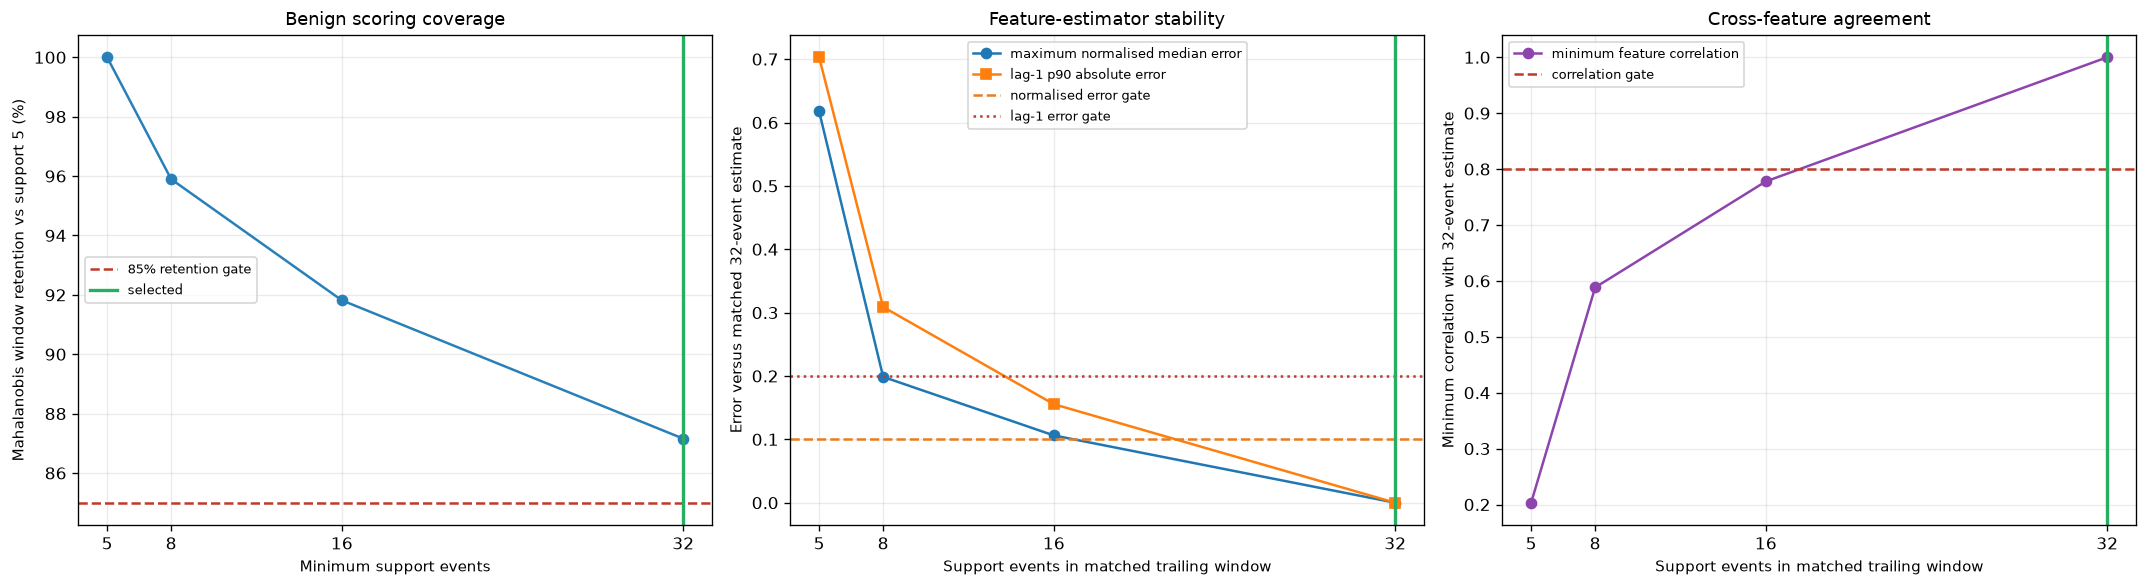

In [12]:
# ============================================================
# 12.4 SELECT 5/8/16/32 SUPPORT USING MATCHED BENIGN WINDOWS
# ============================================================
def _matched_support_feature_frame(
    session_events: pl.DataFrame,
) -> pl.DataFrame:
    session_host_keys = [
        "source_file",
        "host_id",
        "activity_session_id",
    ]
    session_domain_keys = session_host_keys + [
        "parent_domain",
        "domain_activity_session_id",
    ]

    host_lookup = {}
    for host_capture in session_events.partition_by(
        session_host_keys, maintain_order=True
    ):
        host_lookup[
            (
                host_capture["source_file"][0],
                host_capture["host_id"][0],
                host_capture["activity_session_id"][0],
            )
        ] = np.sort(host_capture["_event_time_us"].to_numpy())

    matched_rows = []
    domain_partitions = (
        session_events
        .filter(pl.col("parent_domain").is_not_null())
        .partition_by(session_domain_keys, maintain_order=True)
    )
    for domain_capture in domain_partitions:
        domain_capture = domain_capture.sort(
            ["event_time", "_source_row"], maintain_order=True
        )
        if domain_capture.height < 32:
            continue
        times_us = domain_capture["_event_time_us"].to_numpy()
        source_file = domain_capture["source_file"][0]
        host_id = domain_capture["host_id"][0]
        session_id = domain_capture["activity_session_id"][0]
        parent_domain = domain_capture["parent_domain"][0]
        domain_session_id = domain_capture[
            "domain_activity_session_id"
        ][0]
        host_times = host_lookup[
            (source_file, host_id, session_id)
        ]

        for end_index in range(31, domain_capture.height):
            end_row = domain_capture.row(end_index, named=True)
            for support in SUPPORT_THRESHOLD_CANDIDATES:
                start_index = end_index - support + 1
                window_times = times_us[
                    start_index : end_index + 1
                ]
                iats = np.diff(window_times) / 1_000_000.0
                if np.any(iats < 0):
                    continue
                log_iats = np.log1p(iats)
                log_median = float(np.median(log_iats))
                log_p95 = float(np.percentile(log_iats, 95))
                log_mad = float(
                    np.median(np.abs(log_iats - log_median))
                )
                lag_x = log_iats[:-1]
                lag_y = log_iats[1:]
                if (
                    lag_x.size >= 2
                    and np.std(lag_x) > 0
                    and np.std(lag_y) > 0
                ):
                    lag1 = float(
                        np.corrcoef(lag_x, lag_y)[0, 1]
                    )
                else:
                    lag1 = None

                window_start = int(window_times[0])
                window_end = int(window_times[-1])
                span_seconds = (
                    window_end - window_start
                ) / 1_000_000.0
                host_left = np.searchsorted(
                    host_times, window_start, side="left"
                )
                host_right = np.searchsorted(
                    host_times, window_end, side="right"
                )
                host_event_count = int(host_right - host_left)
                host_intervals = max(host_event_count - 1, 0)
                if span_seconds > 0 and host_intervals > 0:
                    rate_ratio = (
                        (support - 1) / host_intervals
                    )
                else:
                    rate_ratio = None

                matched_rows.append(
                    {
                        "_source_row": int(
                            end_row["_source_row"]
                        ),
                        "host_id": host_id,
                        "activity_session_id": session_id,
                        "parent_domain": parent_domain,
                        "domain_activity_session_id": (
                            domain_session_id
                        ),
                        "event_time": end_row["event_time"],
                        "support_events": support,
                        "window_span_seconds": span_seconds,
                        "log_iat_median": log_median,
                        "log_iat_p95": log_p95,
                        "log_iat_mad": log_mad,
                        "log_iat_lag1_autocorrelation": lag1,
                        "domain_host_rate_ratio": rate_ratio,
                    }
                )
    return pl.DataFrame(matched_rows, infer_schema_length=None)


matched_support_feature_windows = _matched_support_feature_frame(
    sessionized_event_feature_base
)
_matched_reference = (
    matched_support_feature_windows
    .filter(pl.col("support_events") == 32)
    .select(
        [
            "_source_row",
            "host_id",
            "activity_session_id",
            "parent_domain",
            "domain_activity_session_id",
        ]
        + [
            pl.col(name).alias(f"{name}__reference32")
            for name in _SESSION_MAHAL_FEATURES
        ]
    )
)

_support_stability_rows = []
_support_stability_summary_rows = []
for _support in SUPPORT_THRESHOLD_CANDIDATES:
    _candidate = matched_support_feature_windows.filter(
        pl.col("support_events") == _support
    )
    _paired = _candidate.join(
        _matched_reference,
        on=[
            "_source_row",
            "host_id",
            "activity_session_id",
            "parent_domain",
            "domain_activity_session_id",
        ],
        how="inner",
    )
    _normalized_errors = []
    _correlations = []
    _lag1_median_abs_error = None
    _lag1_p90_abs_error = None
    for _feature_name in _SESSION_MAHAL_FEATURES:
        _observed = _paired[_feature_name].to_numpy()
        _reference = _paired[
            f"{_feature_name}__reference32"
        ].to_numpy()
        _finite = (
            np.isfinite(_observed) & np.isfinite(_reference)
        )
        _observed = _observed[_finite]
        _reference = _reference[_finite]
        if _observed.size == 0:
            continue
        _abs_error = np.abs(_observed - _reference)
        _reference_iqr = float(
            np.quantile(_reference, 0.75)
            - np.quantile(_reference, 0.25)
        )
        _scale = max(_reference_iqr, 1e-12)
        _normalised_median_error = float(
            np.median(_abs_error) / _scale
        )
        _normalized_errors.append(_normalised_median_error)
        if (
            np.std(_observed) > 0
            and np.std(_reference) > 0
        ):
            _correlation = float(
                np.corrcoef(_observed, _reference)[0, 1]
            )
        else:
            _correlation = None
        if _correlation is not None and np.isfinite(_correlation):
            _correlations.append(_correlation)
        _median_abs_error = float(np.median(_abs_error))
        if _feature_name == "log_iat_lag1_autocorrelation":
            _lag1_median_abs_error = _median_abs_error
            _lag1_p90_abs_error = float(
                np.percentile(_abs_error, 90)
            )
        _support_stability_rows.append(
            {
                "support_events": _support,
                "feature_name": _feature_name,
                "matched_windows": int(_observed.size),
                "median_abs_error_vs_32": _median_abs_error,
                "p90_abs_error_vs_32": float(
                    np.percentile(_abs_error, 90)
                ),
                "reference32_iqr": _reference_iqr,
                "normalized_median_abs_error_vs_32": (
                    _normalised_median_error
                ),
                "correlation_with_32": _correlation,
            }
        )

    _mahal_eligible_at_support = (
        sessionized_mahalanobis_feature_windows.filter(
            pl.col("is_fully_defined")
            & (pl.col("event_count") >= _support)
        ).height
    )
    _mahal_eligible_at_5 = (
        sessionized_mahalanobis_feature_windows.filter(
            pl.col("is_fully_defined")
            & (pl.col("event_count") >= 5)
        ).height
    )
    _gru_eligible_at_support = (
        sessionized_gru_feature_rows.filter(
            pl.col("is_fully_defined")
            & (pl.col("domain_event_count_to_date") >= _support)
        ).height
    )
    _support_coverage_row = (
        selected_sessionized_parent_support
        .filter(pl.col("minimum_events") == _support)
        .row(0, named=True)
    )
    _support_stability_summary_rows.append(
        {
            "support_events": _support,
            "matched_mature_windows": _paired.height,
            "median_normalized_feature_error_vs_32": (
                float(np.median(_normalized_errors))
                if _normalized_errors
                else None
            ),
            "max_normalized_feature_error_vs_32": (
                float(np.max(_normalized_errors))
                if _normalized_errors
                else None
            ),
            "lag1_median_abs_error_vs_32": (
                _lag1_median_abs_error
            ),
            "lag1_p90_abs_error_vs_32": (
                _lag1_p90_abs_error
            ),
            "minimum_feature_correlation_with_32": (
                float(np.min(_correlations))
                if _correlations
                else None
            ),
            "mahal_eligible_windows": _mahal_eligible_at_support,
            "mahal_window_retention_vs_5": (
                _mahal_eligible_at_support
                / _mahal_eligible_at_5
                if _mahal_eligible_at_5
                else None
            ),
            "gru_eligible_rows": _gru_eligible_at_support,
            "supported_parent_domain_events": int(
                _support_coverage_row[
                    "events_in_supported_groups"
                ]
            ),
            "supported_parent_domain_event_pct": float(
                _support_coverage_row[
                    "pct_valid_parent_domain_events"
                ]
            ),
        }
    )

support_threshold_feature_stability = pl.DataFrame(
    _support_stability_rows, infer_schema_length=None
)
support_threshold_candidate_summary = pl.DataFrame(
    _support_stability_summary_rows, infer_schema_length=None
).sort("support_events")

domain_window_span_audit = (
    matched_support_feature_windows
    .group_by("support_events", maintain_order=True)
    .agg(
        [
            pl.len().alias("matched_window_count"),
            pl.col("window_span_seconds")
            .median()
            .alias("median_window_span_seconds"),
            pl.col("window_span_seconds")
            .quantile(0.90)
            .alias("p90_window_span_seconds"),
            pl.col("window_span_seconds")
            .quantile(0.95)
            .alias("p95_window_span_seconds"),
            pl.col("window_span_seconds")
            .quantile(0.99)
            .alias("p99_window_span_seconds"),
            pl.col("window_span_seconds")
            .max()
            .alias("max_window_span_seconds"),
        ]
    )
    .sort("support_events")
)

_support_gate_rows = []
for _row in support_threshold_candidate_summary.to_dicts():
    _support = int(_row["support_events"])
    _gates = [
        (
            "matched_mature_windows",
            _row["matched_mature_windows"]
            >= SUPPORT_MIN_MATCHED_WINDOWS,
            _row["matched_mature_windows"],
            f">= {SUPPORT_MIN_MATCHED_WINDOWS}",
        ),
        (
            "mahal_window_retention",
            _row["mahal_window_retention_vs_5"]
            >= SUPPORT_MIN_MAHAL_RETENTION,
            _row["mahal_window_retention_vs_5"],
            f">= {SUPPORT_MIN_MAHAL_RETENTION}",
        ),
        (
            "maximum_normalized_feature_error",
            _row["max_normalized_feature_error_vs_32"]
            <= SUPPORT_MAX_MAX_NORMALIZED_ERROR,
            _row["max_normalized_feature_error_vs_32"],
            f"<= {SUPPORT_MAX_MAX_NORMALIZED_ERROR}",
        ),
        (
            "lag1_p90_absolute_error",
            _row["lag1_p90_abs_error_vs_32"]
            <= SUPPORT_MAX_LAG1_P90_ABS_ERROR,
            _row["lag1_p90_abs_error_vs_32"],
            f"<= {SUPPORT_MAX_LAG1_P90_ABS_ERROR}",
        ),
        (
            "minimum_feature_correlation",
            _row["minimum_feature_correlation_with_32"]
            >= SUPPORT_MIN_FEATURE_CORRELATION,
            _row["minimum_feature_correlation_with_32"],
            f">= {SUPPORT_MIN_FEATURE_CORRELATION}",
        ),
    ]
    for _gate_name, _passed, _observed, _expected in _gates:
        _support_gate_rows.append(
            {
                "support_events": _support,
                "gate_name": _gate_name,
                "status": "PASS" if bool(_passed) else "FAIL",
                "observed": str(_observed),
                "expected": _expected,
            }
        )

support_threshold_gate_results = pl.DataFrame(
    _support_gate_rows
)
_support_pass_counts = (
    support_threshold_gate_results
    .group_by("support_events", maintain_order=True)
    .agg(
        [
            (pl.col("status") == "PASS")
            .sum()
            .alias("passed_gates"),
            pl.len().alias("total_gates"),
        ]
    )
    .with_columns(
        (
            pl.col("passed_gates") == pl.col("total_gates")
        ).alias("all_gates_pass")
    )
    .sort("support_events")
)
_passing_support = _support_pass_counts.filter(
    pl.col("all_gates_pass")
    & (pl.col("support_events") < max(SUPPORT_THRESHOLD_CANDIDATES))
)
if _passing_support.height:
    SELECTED_MINIMUM_SUPPORT_EVENTS = int(
        _passing_support["support_events"].min()
    )
    SUPPORT_SELECTION_STATUS = (
        "SELECTED_BY_MATCHED_BENIGN_STABILITY_GATES"
    )
else:
    SELECTED_MINIMUM_SUPPORT_EVENTS = max(
        SUPPORT_THRESHOLD_CANDIDATES
    )
    SUPPORT_SELECTION_STATUS = (
        "CONSERVATIVE_32_EVENT_FALLBACK_NO_SHORTER_CANDIDATE_PASSED"
    )

selected_support_policy = (
    support_threshold_candidate_summary
    .filter(
        pl.col("support_events")
        == SELECTED_MINIMUM_SUPPORT_EVENTS
    )
    .with_columns(
        [
            pl.lit(SUPPORT_SELECTION_STATUS)
            .alias("selection_status"),
            pl.lit(
                "smallest support passing matched 32-event benign "
                "stability and coverage gates"
            ).alias("selection_rule"),
        ]
    )
)

sessionized_gru_eligible_selected = (
    sessionized_gru_feature_rows.filter(
        pl.col("is_fully_defined")
        & (
            pl.col("domain_event_count_to_date")
            >= SELECTED_MINIMUM_SUPPORT_EVENTS
        )
    )
)
sessionized_mahalanobis_eligible_selected = (
    sessionized_mahalanobis_feature_windows.filter(
        pl.col("is_fully_defined")
        & (
            pl.col("event_count")
            >= SELECTED_MINIMUM_SUPPORT_EVENTS
        )
    )
)

print("\nMatched benign feature stability versus 32 events")
display(support_threshold_feature_stability)
print("\nSupport candidate summary")
display(support_threshold_candidate_summary)
print("\nSupport-selection gates")
display(support_threshold_gate_results)
print("\nParent-domain trailing-window elapsed-time audit")
display(domain_window_span_audit)
print("\nSelected minimum support")
display(selected_support_policy)

# Support trade-off plot.
_support_rows_plot = (
    support_threshold_candidate_summary
    .sort("support_events")
    .to_dicts()
)
_support_x = np.asarray(
    [row["support_events"] for row in _support_rows_plot],
    dtype=float,
)
_retention_y = np.asarray(
    [
        100.0 * row["mahal_window_retention_vs_5"]
        for row in _support_rows_plot
    ],
    dtype=float,
)
_instability_y = np.asarray(
    [
        row["max_normalized_feature_error_vs_32"]
        for row in _support_rows_plot
    ],
    dtype=float,
)
_lag1_y = np.asarray(
    [
        row["lag1_p90_abs_error_vs_32"]
        for row in _support_rows_plot
    ],
    dtype=float,
)

_correlation_y = np.asarray(
    [
        row["minimum_feature_correlation_with_32"]
        for row in _support_rows_plot
    ],
    dtype=float,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(
    _support_x, _retention_y, marker="o", color="#2980b9"
)
axes[0].axhline(
    100.0 * SUPPORT_MIN_MAHAL_RETENTION,
    color="#c0392b",
    linestyle="--",
    label="85% retention gate",
)
axes[0].axvline(
    SELECTED_MINIMUM_SUPPORT_EVENTS,
    color="#27ae60",
    linewidth=2,
    label="selected",
)
axes[0].set_xticks(_support_x)
axes[0].set_xlabel("Minimum support events")
axes[0].set_ylabel("Mahalanobis window retention vs support 5 (%)")
axes[0].set_title("Benign scoring coverage")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(
    _support_x,
    _instability_y,
    marker="o",
    label="maximum normalised median error",
)
axes[1].plot(
    _support_x,
    _lag1_y,
    marker="s",
    label="lag-1 p90 absolute error",
)
axes[1].axhline(
    SUPPORT_MAX_MAX_NORMALIZED_ERROR,
    color="#e67e22",
    linestyle="--",
    label="normalised error gate",
)
axes[1].axhline(
    SUPPORT_MAX_LAG1_P90_ABS_ERROR,
    color="#c0392b",
    linestyle=":",
    label="lag-1 error gate",
)
axes[1].axvline(
    SELECTED_MINIMUM_SUPPORT_EVENTS,
    color="#27ae60",
    linewidth=2,
)
axes[1].set_xticks(_support_x)
axes[1].set_xlabel("Support events in matched trailing window")
axes[1].set_ylabel("Error versus matched 32-event estimate")
axes[1].set_title("Feature-estimator stability")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
axes[2].plot(
    _support_x,
    _correlation_y,
    marker="o",
    color="#8e44ad",
    label="minimum feature correlation",
)
axes[2].axhline(
    SUPPORT_MIN_FEATURE_CORRELATION,
    color="#c0392b",
    linestyle="--",
    label="correlation gate",
)
axes[2].axvline(
    SELECTED_MINIMUM_SUPPORT_EVENTS,
    color="#27ae60",
    linewidth=2,
)
axes[2].set_xticks(_support_x)
axes[2].set_xlabel("Support events in matched trailing window")
axes[2].set_ylabel("Minimum correlation with 32-event estimate")
axes[2].set_title("Cross-feature agreement")
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=8)
fig.tight_layout()
plot_support_policy_path = (
    SESSION_OUTPUT_DIR / "plot_03_support_tradeoff.png"
)
fig.savefig(
    plot_support_policy_path, dpi=180, bbox_inches="tight"
)
plt.show()


In [13]:
# ============================================================
# 12.5 INTEGRITY GATES, EXPORTS AND RETURN-TO-CHAT BUNDLE
# ============================================================
def _feature_quantile_table(
    frame: pl.DataFrame,
    feature_names: list[str],
    representation: str,
) -> pl.DataFrame:
    rows = []
    for feature_name in feature_names:
        values = frame[feature_name].to_numpy()
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        quantiles = np.quantile(
            values, [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
        )
        rows.append(
            {
                "representation": representation,
                "feature_name": feature_name,
                "finite_count": int(values.size),
                "mean": float(values.mean()),
                "std": float(values.std()),
                "p01": float(quantiles[0]),
                "p05": float(quantiles[1]),
                "p25": float(quantiles[2]),
                "p50": float(quantiles[3]),
                "p75": float(quantiles[4]),
                "p95": float(quantiles[5]),
                "p99": float(quantiles[6]),
                "min": float(values.min()),
                "max": float(values.max()),
            }
        )
    return pl.DataFrame(rows, infer_schema_length=None)


selected_feature_quantiles = pl.concat(
    [
        _feature_quantile_table(
            sessionized_gru_eligible_selected,
            _SESSION_GRU_FEATURES,
            "GRU/LSTM selected eligible",
        ),
        _feature_quantile_table(
            sessionized_mahalanobis_eligible_selected,
            _SESSION_MAHAL_FEATURES,
            "Mahalanobis selected eligible",
        ),
    ],
    how="vertical_relaxed",
)

_session_domain_keys_final = [
    "source_file",
    "host_id",
    "activity_session_id",
    "parent_domain",
    "domain_activity_session_id",
]
_first_domain_events_final = (
    sessionized_event_feature_base
    .filter(pl.col("parent_domain").is_not_null())
    .sort(
        _session_domain_keys_final + ["event_time", "_source_row"],
        maintain_order=True,
    )
    .group_by(_session_domain_keys_final, maintain_order=True)
    .first()
)
_first_host_events_final = (
    sessionized_event_feature_base
    .sort(
        [
            "source_file",
            "host_id",
            "activity_session_id",
            "event_time",
            "_source_row",
        ],
        maintain_order=True,
    )
    .group_by(
        ["source_file", "host_id", "activity_session_id"],
        maintain_order=True,
    )
    .first()
)

_max_within_session_host_iat = (
    sessionized_event_feature_base[
        "host_iat_seconds"
    ].drop_nulls().max()
)
_max_within_domain_session_iat = (
    sessionized_event_feature_base[
        "domain_iat_seconds"
    ].drop_nulls().max()
)
_first_host_iats_null = (
    _first_host_events_final["host_iat_seconds"].null_count()
    == _first_host_events_final.height
)
_first_domain_iats_null = (
    _first_domain_events_final[
        "domain_iat_seconds"
    ].null_count()
    == _first_domain_events_final.height
)
_no_negative_iats = (
    int(
        (
            sessionized_event_feature_base[
                "host_iat_seconds"
            ] < 0
        ).sum()
    )
    == 0
    and int(
        (
            sessionized_event_feature_base[
                "domain_iat_seconds"
            ] < 0
        ).sum()
    )
    == 0
)
_mahal_window_session_check = (
    sessionized_mahalanobis_feature_windows
    .join(
        selected_session_summary.select(
            [
                "host_id",
                "activity_session_id",
                "session_start_utc",
                "session_end_utc",
            ]
        ),
        on=["host_id", "activity_session_id"],
        how="left",
    )
)
_mahal_windows_within_selected_boundary = bool(
    _mahal_window_session_check.select(
        (
            (pl.col("window_start_time") >= pl.col("session_start_utc"))
            & (pl.col("event_time") <= pl.col("session_end_utc"))
            & pl.col("session_start_utc").is_not_null()
            & pl.col("session_end_utc").is_not_null()
        ).all()
    ).item()
)
_mahal_window_domain_session_check = (
    sessionized_mahalanobis_feature_windows
    .join(
        selected_domain_session_summary.select(
            [
                "host_id",
                "activity_session_id",
                "parent_domain",
                "domain_activity_session_id",
                "domain_session_start_utc",
                "domain_session_end_utc",
            ]
        ),
        on=[
            "host_id",
            "activity_session_id",
            "parent_domain",
            "domain_activity_session_id",
        ],
        how="left",
    )
)
_mahal_windows_within_domain_session = bool(
    _mahal_window_domain_session_check.select(
        (
            (
                pl.col("window_start_time")
                >= pl.col("domain_session_start_utc")
            )
            & (
                pl.col("event_time")
                <= pl.col("domain_session_end_utc")
            )
            & pl.col("domain_session_start_utc").is_not_null()
            & pl.col("domain_session_end_utc").is_not_null()
        ).all()
    ).item()
)
_selected_gru_finite = bool(
    sessionized_gru_eligible_selected.select(
        _all_finite_session_expr(
            _SESSION_GRU_FEATURES
            + ["target_next_log_domain_iat"]
        ).all()
    ).item()
)
_selected_mahal_finite = bool(
    sessionized_mahalanobis_eligible_selected.select(
        _all_finite_session_expr(
            _SESSION_MAHAL_FEATURES
        ).all()
    ).item()
)
_selected_support_all_gates_pass = bool(
    _support_pass_counts
    .filter(
        pl.col("support_events")
        == SELECTED_MINIMUM_SUPPORT_EVENTS
    )
    .select(pl.col("all_gates_pass").all())
    .item()
)

_integrity_rows = [
    {
        "gate_name": (
            "analysis scope is benign dns_mine, confirmed endpoint, "
            "resolver port 53 only"
        ),
        "status": (
            "PASS"
            if set(sessionized_benign_events["source_type"].unique())
            == {"benign"}
            and set(sessionized_benign_events["source_file"].unique())
            == {BENIGN_SOURCE_FILE}
            and set(sessionized_benign_events["host_id"].unique())
            == {BENIGN_HOST_ID}
            and set(sessionized_benign_events["_resp_port"].unique())
            == {BENIGN_RESOLVER_PORT}
            else "FAIL"
        ),
        "observed": (
            f"{sessionized_benign_events['source_file'].unique().to_list()} | "
            f"{sessionized_benign_events['source_type'].unique().to_list()} | "
            f"hosts={sessionized_benign_events['host_id'].unique().to_list()} | "
            f"ports={sessionized_benign_events['_resp_port'].unique().to_list()}"
        ),
    },
    {
        "gate_name": "first host IAT of every session is null",
        "status": "PASS" if _first_host_iats_null else "FAIL",
        "observed": (
            f"sessions={_first_host_events_final.height:,}"
        ),
    },
    {
        "gate_name": "first parent-domain IAT of every session is null",
        "status": "PASS" if _first_domain_iats_null else "FAIL",
        "observed": (
            f"session-domain groups={_first_domain_events_final.height:,}"
        ),
    },
    {
        "gate_name": "no negative host or domain IAT",
        "status": "PASS" if _no_negative_iats else "FAIL",
        "observed": "negative counts must both equal zero",
    },
    {
        "gate_name": "within-session host gaps respect selected boundary",
        "status": (
            "PASS"
            if (
                _max_within_session_host_iat
                <= 60.0 * SELECTED_SESSION_THRESHOLD_MINUTES
            )
            else "FAIL"
        ),
        "observed": (
            f"max={_max_within_session_host_iat:.6f}s; "
            f"limit={60 * SELECTED_SESSION_THRESHOLD_MINUTES:.0f}s"
        ),
    },
    {
        "gate_name": (
            "within-domain-session gaps respect domain inactivity boundary"
        ),
        "status": (
            "PASS"
            if (
                _max_within_domain_session_iat
                <= 60.0 * DOMAIN_INACTIVITY_MINUTES
            )
            else "FAIL"
        ),
        "observed": (
            f"max={_max_within_domain_session_iat:.6f}s; "
            f"limit={60 * DOMAIN_INACTIVITY_MINUTES:.0f}s"
        ),
    },
    {
        "gate_name": "Mahalanobis windows remain within one session",
        "status": (
            "PASS"
            if _mahal_windows_within_selected_boundary
            else "FAIL"
        ),
        "observed": (
            f"windows={sessionized_mahalanobis_feature_windows.height:,}"
        ),
    },
    {
        "gate_name": (
            "Mahalanobis windows remain within one parent-domain session"
        ),
        "status": (
            "PASS"
            if _mahal_windows_within_domain_session
            else "FAIL"
        ),
        "observed": (
            f"windows={sessionized_mahalanobis_feature_windows.height:,}"
        ),
    },
    {
        "gate_name": "selected GRU rows are finite",
        "status": "PASS" if _selected_gru_finite else "FAIL",
        "observed": (
            f"rows={sessionized_gru_eligible_selected.height:,}"
        ),
    },
    {
        "gate_name": "selected Mahalanobis windows are finite",
        "status": "PASS" if _selected_mahal_finite else "FAIL",
        "observed": (
            f"windows={sessionized_mahalanobis_eligible_selected.height:,}"
        ),
    },
    {
        "gate_name": "selected support is one of 5/8/16/32",
        "status": (
            "PASS"
            if SELECTED_MINIMUM_SUPPORT_EVENTS
            in SUPPORT_THRESHOLD_CANDIDATES
            else "FAIL"
        ),
        "observed": str(SELECTED_MINIMUM_SUPPORT_EVENTS),
    },
    {
        "gate_name": "selected support passes every tail-aware gate",
        "status": (
            "PASS"
            if _selected_support_all_gates_pass
            else "FAIL"
        ),
        "observed": str(_selected_support_all_gates_pass),
    },
]
session_support_integrity_gate = pl.DataFrame(_integrity_rows)
_all_integrity_pass = bool(
    session_support_integrity_gate.select(
        (pl.col("status") == "PASS").all()
    ).item()
)

# Small, attachable result tables.
_csv_exports = {
    "01_scope_correction_summary.csv": scope_correction_summary,
    "02_pre_scope_host_port_inventory.csv": (
        pre_scope_host_port_inventory
    ),
    "03_duplicate_handling.csv": duplicate_handling_summary,
    "04_scoped_host_inventory.csv": host_inventory,
    "05_gap_quantiles.csv": gap_quantiles,
    "06_gap_threshold_counts.csv": gap_threshold_counts,
    "07_largest_benign_gaps.csv": largest_benign_gaps,
    "08_gap_fence_audit_only.csv": gap_policy_seed,
    "09_session_policy_candidate_summary.csv": (
        session_policy_candidate_summary
    ),
    "10_session_policy_feature_differences.csv": (
        session_policy_feature_differences
    ),
    "11_session_policy_gate_results.csv": (
        session_policy_gate_results
    ),
    "12_selected_session_policy.csv": selected_session_policy,
    "13_selected_host_session_summary.csv": selected_session_summary,
    "14_selected_domain_session_summary.csv": (
        selected_domain_session_summary
    ),
    "15_sessionized_parent_domain_support.csv": (
        selected_sessionized_parent_support
    ),
    "16_sessionized_feature_eligibility.csv": (
        sessionized_feature_eligibility
    ),
    "17_support_threshold_feature_stability.csv": (
        support_threshold_feature_stability
    ),
    "18_support_threshold_candidate_summary.csv": (
        support_threshold_candidate_summary
    ),
    "19_support_threshold_gate_results.csv": (
        support_threshold_gate_results
    ),
    "20_domain_window_span_audit.csv": domain_window_span_audit,
    "21_selected_support_policy.csv": selected_support_policy,
    "22_selected_feature_quantiles.csv": selected_feature_quantiles,
    "23_session_support_integrity_gate.csv": (
        session_support_integrity_gate
    ),
    "24_gru_selected_preview.csv": (
        sessionized_gru_eligible_selected.head(500)
    ),
    "25_mahalanobis_selected_preview.csv": (
        sessionized_mahalanobis_eligible_selected.head(500)
    ),
}
for _filename, _frame in _csv_exports.items():
    _frame.write_csv(SESSION_OUTPUT_DIR / _filename)

# Full reusable tables are kept outside the compact context ZIP.
_full_parquet_exports = {
    "sessionized_benign_events.parquet": (
        sessionized_benign_events
    ),
    "sessionized_host_events.parquet": (
        sessionized_host_events
    ),
    "sessionized_event_feature_base.parquet": (
        sessionized_event_feature_base
    ),
    "sessionized_gru_feature_rows.parquet": (
        sessionized_gru_feature_rows
    ),
    "sessionized_gru_eligible_selected.parquet": (
        sessionized_gru_eligible_selected
    ),
    "sessionized_mahalanobis_feature_windows.parquet": (
        sessionized_mahalanobis_feature_windows
    ),
    "sessionized_mahalanobis_eligible_selected.parquet": (
        sessionized_mahalanobis_eligible_selected
    ),
    "matched_support_feature_windows.parquet": (
        matched_support_feature_windows
    ),
}
for _filename, _frame in _full_parquet_exports.items():
    _frame.write_parquet(SESSION_OUTPUT_DIR / _filename)

_selected_session_row = selected_session_policy.row(
    0, named=True
)
_selected_support_row = selected_support_policy.row(
    0, named=True
)
_manifest = {
    "analysis_version": SESSION_AUDIT_VERSION,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source_file": BENIGN_SOURCE_FILE,
    "source_type": "benign",
    "confirmed_endpoint_host_id": BENIGN_HOST_ID,
    "resolver_destination_port": BENIGN_RESOLVER_PORT,
    "source_rows_before_endpoint_port_scope": (
        _benign_source_raw.height
    ),
    "scoped_rows_before_duplicate_handling": _benign_raw.height,
    "analysis_rows": benign_session_audit_events.height,
    "extra_duplicate_rows_removed": (
        _duplicate_extra_rows
        if DROP_EXACT_DUPLICATE_TRANSACTIONS
        else 0
    ),
    "host_count": host_inventory.height,
    "session_threshold_candidates_minutes": list(
        SESSION_THRESHOLD_CANDIDATE_MINUTES
    ),
    "robust_log_gap_fence_seconds": (
        ROBUST_LOG_GAP_FENCE_SECONDS
    ),
    "robust_gap_fence_used_as_selection_gate": False,
    "selected_session_threshold_minutes": (
        SELECTED_SESSION_THRESHOLD_MINUTES
    ),
    "session_policy_selection_status": (
        SESSION_POLICY_SELECTION_STATUS
    ),
    "domain_inactivity_reset_minutes": DOMAIN_INACTIVITY_MINUTES,
    "domain_activity_session_count": (
        selected_domain_session_summary.height
    ),
    "support_candidates": list(SUPPORT_THRESHOLD_CANDIDATES),
    "selected_minimum_support_events": (
        SELECTED_MINIMUM_SUPPORT_EVENTS
    ),
    "support_selection_status": SUPPORT_SELECTION_STATUS,
    "selected_gru_rows": (
        sessionized_gru_eligible_selected.height
    ),
    "selected_mahalanobis_windows": (
        sessionized_mahalanobis_eligible_selected.height
    ),
    "integrity_gate_pass": _all_integrity_pass,
    "model_training_performed": False,
    "attack_data_used_for_selection": False,
    "gru_model_inputs": _SESSION_GRU_FEATURES,
    "mahalanobis_model_inputs": _SESSION_MAHAL_FEATURES,
    "python_version": platform.python_version(),
    "polars_version": package_version("polars"),
    "numpy_version": package_version("numpy"),
    "output_directory": str(SESSION_OUTPUT_DIR),
    "csv_files": sorted(_csv_exports),
    "parquet_files": sorted(_full_parquet_exports),
    "plot_files": [
        plot_gap_survival_path.name,
        plot_session_policy_path.name,
        plot_support_policy_path.name,
    ],
}
manifest_path = SESSION_OUTPUT_DIR / "run_manifest.json"
manifest_path.write_text(
    json.dumps(_manifest, indent=2, default=str),
    encoding="utf-8",
)

_summary_text = f'''# DNS Mine Session and Support Audit — Context Summary

## Corrected scope

- Source: `{BENIGN_SOURCE_FILE}`
- Confirmed endpoint: `{BENIGN_HOST_ID}`
- Resolver destination port: `{BENIGN_RESOLVER_PORT}`
- Benign source rows before endpoint/port scope: {_benign_source_raw.height:,}
- Benign rows before duplicate handling: {_benign_raw.height:,}
- Rows used by the derived audit: {benign_session_audit_events.height:,}
- Extra exact duplicate rows removed: {_duplicate_extra_rows if DROP_EXACT_DUPLICATE_TRANSACTIONS else 0:,}
- Hosts eligible after scope correction: {host_inventory.height:,}
- Model training performed: **No**
- Attack data used for either decision: **No**

## Selected session-boundary policy

- Candidate thresholds: {SESSION_THRESHOLD_CANDIDATE_MINUTES} minutes
- Robust log-gap fence: {ROBUST_LOG_GAP_FENCE_SECONDS:.3f} seconds
- Robust log-gap fence used as a gate: **No** (audit statistic only)
- Selected boundary: **{SELECTED_SESSION_THRESHOLD_MINUTES} minutes**
- Selection status: `{SESSION_POLICY_SELECTION_STATUS}`
- Resulting activity sessions: {selected_session_summary.height:,}

At a host-session boundary, host IAT resets. Parent-domain IAT, GRU rolling
history, GRU next-IAT targets and Mahalanobis trailing windows additionally
reset after **{DOMAIN_INACTIVITY_MINUTES} minutes** of parent-domain
inactivity. Clock time is not compressed and no gap is replaced with zero.

## Selected minimum-support policy

- Candidate support: {SUPPORT_THRESHOLD_CANDIDATES}
- Selected support: **{SELECTED_MINIMUM_SUPPORT_EVENTS} events**
- Selection status: `{SUPPORT_SELECTION_STATUS}`
- Eligible GRU rows after the selected gate: {sessionized_gru_eligible_selected.height:,}
- Eligible Mahalanobis windows after the selected gate: {sessionized_mahalanobis_eligible_selected.height:,}
- Matched mature windows used by selected candidate: {_selected_support_row['matched_mature_windows']:,}
- Maximum normalised feature error versus 32 events: {_selected_support_row['max_normalized_feature_error_vs_32']:.6f}
- Lag-1 p90 absolute error versus 32 events: {_selected_support_row['lag1_p90_abs_error_vs_32']:.6f}
- Minimum feature correlation with 32 events: {_selected_support_row['minimum_feature_correlation_with_32']:.6f}
- Mahalanobis window retention versus support 5: {_selected_support_row['mahal_window_retention_vs_5']:.6f}

## Integrity verdict

**{'PASS' if _all_integrity_pass else 'FAIL'}**

See `23_session_support_integrity_gate.csv` for every check.

## Files to inspect first

1. `01_scope_correction_summary.csv`
2. `02_pre_scope_host_port_inventory.csv`
3. `09_session_policy_candidate_summary.csv`
4. `11_session_policy_gate_results.csv`
5. `12_selected_session_policy.csv`
6. `14_selected_domain_session_summary.csv`
7. `15_sessionized_parent_domain_support.csv`
8. `16_sessionized_feature_eligibility.csv`
9. `17_support_threshold_feature_stability.csv`
10. `18_support_threshold_candidate_summary.csv`
11. `19_support_threshold_gate_results.csv`
12. `20_domain_window_span_audit.csv`
13. `21_selected_support_policy.csv`
14. `23_session_support_integrity_gate.csv`

The ZIP contains the compact tables, plots, this summary and the manifest.
The full sessionized feature datasets remain as Parquet files in the output
directory and are intentionally excluded from the compact ZIP.
'''
context_summary_path = SESSION_OUTPUT_DIR / "CONTEXT_SUMMARY.md"
context_summary_path.write_text(_summary_text, encoding="utf-8")

_bundle_files = (
    [SESSION_OUTPUT_DIR / name for name in sorted(_csv_exports)]
    + [
        manifest_path,
        context_summary_path,
        plot_gap_survival_path,
        plot_session_policy_path,
        plot_support_policy_path,
    ]
)
context_bundle_path = (
    SESSION_OUTPUT_DIR
    / "dns_mine_session_support_context_bundle_v1_1_0.zip"
)
with zipfile.ZipFile(
    context_bundle_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for file_path in _bundle_files:
        archive.write(file_path, arcname=file_path.name)

print("\n" + "=" * 88)
print("SESSION AND SUPPORT AUDIT COMPLETE")
print("=" * 88)
print(
    "Selected session boundary: "
    f"{SELECTED_SESSION_THRESHOLD_MINUTES} minutes"
)
print(
    "Selected minimum support:  "
    f"{SELECTED_MINIMUM_SUPPORT_EVENTS} events"
)
print(
    "Integrity verdict:         "
    f"{'PASS' if _all_integrity_pass else 'FAIL'}"
)
print(f"Output directory:          {SESSION_OUTPUT_DIR}")
print(f"Return this ZIP:           {context_bundle_path}")
print("\nIntegrity gates")
display(session_support_integrity_gate)
print("\nContext summary")
print(_summary_text)

if not _all_integrity_pass:
    raise RuntimeError(
        "One or more session/support integrity gates failed. "
        "The context bundle was still exported for diagnosis."
    )



SESSION AND SUPPORT AUDIT COMPLETE
Selected session boundary: 15 minutes
Selected minimum support:  32 events
Integrity verdict:         PASS
Output directory:          /home/notevenknow/Desktop/jupyter_lab/outputs_dns_mine_session_support_audit_v1_1_0
Return this ZIP:           /home/notevenknow/Desktop/jupyter_lab/outputs_dns_mine_session_support_audit_v1_1_0/dns_mine_session_support_context_bundle_v1_1_0.zip

Integrity gates


gate_name,status,observed
str,str,str
"""analysis scope is benign dns_m…","""PASS""","""['dns_mine.log'] | ['benign'] …"
"""first host IAT of every sessio…","""PASS""","""sessions=5"""
"""first parent-domain IAT of eve…","""PASS""","""session-domain groups=6,119"""
"""no negative host or domain IAT""","""PASS""","""negative counts must both equa…"
"""within-session host gaps respe…","""PASS""","""max=277.225151s; limit=900s"""
…,…,…
"""Mahalanobis windows remain wit…","""PASS""","""windows=27,481"""
"""selected GRU rows are finite""","""PASS""","""rows=23,892"""
"""selected Mahalanobis windows a…","""PASS""","""windows=23,952"""



Context summary
# DNS Mine Session and Support Audit — Context Summary

## Corrected scope

- Source: `dns_mine.log`
- Confirmed endpoint: `192.168.10.1`
- Resolver destination port: `53`
- Benign source rows before endpoint/port scope: 71,311
- Benign rows before duplicate handling: 41,116
- Rows used by the derived audit: 41,116
- Extra exact duplicate rows removed: 0
- Hosts eligible after scope correction: 1
- Model training performed: **No**
- Attack data used for either decision: **No**

## Selected session-boundary policy

- Candidate thresholds: (15, 30, 60, 120) minutes
- Robust log-gap fence: 467008.287 seconds
- Robust log-gap fence used as a gate: **No** (audit statistic only)
- Selected boundary: **15 minutes**
- Selection status: `SELECTED_BY_PREDECLARED_BENIGN_GATES`
- Resulting activity sessions: 5

At a host-session boundary, host IAT resets. Parent-domain IAT, GRU rolling
history, GRU next-IAT targets and Mahalanobis trailing windows additionally
reset after **15 min

## Section 13 — Locked Attack Injection and Final Feature Generation

This is the next incremental research stage. It injects each attack capture
independently into the same benign-only placement context, recalculates the
frozen causal session and feature representations over the combined streams,
and exports eligibility, warm-up, abstention, concentration, and integrity
evidence.

It performs **no model training, calibration, or attack scoring**. If any
integrity gate fails, the cell exports diagnostic evidence and stops.


In [14]:
# ============================================================
# SECTION 13 — LOCKED ATTACK INJECTION AND FINAL FEATURE GENERATION
# ============================================================
# This section performs no model training, calibration, threshold selection,
# or attack scoring. Each attack capture is injected independently into the
# same benign-only placement context. The frozen 15-minute host boundary,
# 15-minute parent-domain reset, 32-event support gate, feature definitions,
# and Public Suffix List mapping are reused without refitting.

from datetime import datetime, timezone
from importlib.metadata import version as package_version
import hashlib
import json
import platform
import zipfile


INJECTION_FEATURE_VERSION = "1.0.0"
INJECTION_OUTPUT_DIR = (
    DATA / "outputs_dns_attack_injection_features_v1_0_0"
)
INJECTION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FROZEN_HOST_INACTIVITY_MINUTES = 15
FROZEN_DOMAIN_INACTIVITY_MINUTES = 15
FROZEN_MINIMUM_SUPPORT_EVENTS = 32

ATTACK_INJECTION_SPECS = [
    {
        "attack_profile": "no_jitter",
        "source_file": "dns_no_jitter.log",
        "injection_id": "injection_01_no_jitter",
    },
    {
        "attack_profile": "j1",
        "source_file": "dns_j1.log",
        "injection_id": "injection_02_j1",
    },
    {
        "attack_profile": "j2",
        "source_file": "dns_j2.log",
        "injection_id": "injection_03_j2",
    },
    {
        "attack_profile": "j3",
        "source_file": "dns_j3.log",
        "injection_id": "injection_04_j3",
    },
    {
        "attack_profile": "s1",
        "source_file": "dns_s1.log",
        "injection_id": "injection_05_s1",
    },
    {
        "attack_profile": "s2",
        "source_file": "dns_s2_context_coupled_lowrate.log",
        "injection_id": "injection_06_s2",
    },
]

_required_injection_objects = [
    "feature_audit_source_events",
    "benign_session_audit_events",
    "sessionized_host_events",
    "sessionized_gru_eligible_selected",
    "sessionized_mahalanobis_eligible_selected",
    "selected_session_summary",
    "selected_session_policy",
    "selected_support_policy",
    "SELECTED_SESSION_THRESHOLD_MINUTES",
    "DOMAIN_INACTIVITY_MINUTES",
    "SELECTED_MINIMUM_SUPPORT_EVENTS",
    "GRU_LSTM_MODEL_INPUTS",
    "GRU_LSTM_TARGET",
    "MAHALANOBIS_MODEL_INPUTS",
    "_sessionize_benign",
    "_sessionized_feature_frames",
    "_all_integrity_pass",
]
_missing_injection_objects = [
    name for name in _required_injection_objects
    if name not in globals()
]
if _missing_injection_objects:
    raise RuntimeError(
        "Run the notebook through Section 12 first. "
        f"Missing objects: {_missing_injection_objects}"
    )

if not bool(_all_integrity_pass):
    raise RuntimeError(
        "The frozen benign session/support audit did not pass. "
        "Attack injection is blocked."
    )

_expected_gru_inputs = [
    "log_domain_iat",
    "delta_log_domain_iat",
    "rolling_log_iat_mean_4",
    "rolling_log_iat_std_8",
    "log_host_iat",
]
_expected_mahal_inputs = [
    "log_iat_median",
    "log_iat_p95",
    "log_iat_mad",
    "log_iat_lag1_autocorrelation",
    "domain_host_rate_ratio",
]

assert SELECTED_SESSION_THRESHOLD_MINUTES == (
    FROZEN_HOST_INACTIVITY_MINUTES
)
assert DOMAIN_INACTIVITY_MINUTES == (
    FROZEN_DOMAIN_INACTIVITY_MINUTES
)
assert SELECTED_MINIMUM_SUPPORT_EVENTS == (
    FROZEN_MINIMUM_SUPPORT_EVENTS
)
assert GRU_LSTM_MODEL_INPUTS == _expected_gru_inputs
assert GRU_LSTM_TARGET == "target_next_log_domain_iat"
assert MAHALANOBIS_MODEL_INPUTS == _expected_mahal_inputs


def _policy_fingerprint() -> str:
    payload = {
        "selected_session_policy": (
            selected_session_policy.to_dicts()
        ),
        "selected_support_policy": (
            selected_support_policy.to_dicts()
        ),
        "host_inactivity_minutes": (
            SELECTED_SESSION_THRESHOLD_MINUTES
        ),
        "domain_inactivity_minutes": (
            DOMAIN_INACTIVITY_MINUTES
        ),
        "minimum_support_events": (
            SELECTED_MINIMUM_SUPPORT_EVENTS
        ),
        "gru_inputs": GRU_LSTM_MODEL_INPUTS,
        "gru_target": GRU_LSTM_TARGET,
        "mahalanobis_inputs": MAHALANOBIS_MODEL_INPUTS,
        "psl_provenance": PSL_PROVENANCE,
    }
    encoded = json.dumps(
        payload, sort_keys=True, default=str
    ).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()


_benign_policy_fingerprint_before = _policy_fingerprint()

# ------------------------------------------------------------------
# 13.1 Benign-only placement selection
# ------------------------------------------------------------------
# All six captures are injected independently at the same context so profile
# comparisons do not inherit different benign traffic conditions. The anchor
# is the median event of the largest frozen benign host session. The injected
# first event is placed at the first unused microsecond after that anchor.
# Attack labels, domains, timings, and feature values are not used to choose it.
_placement_session = (
    selected_session_summary
    .sort(
        [
            "session_event_count",
            "session_duration_seconds",
            "activity_session_id",
        ],
        descending=[True, True, False],
    )
    .row(0, named=True)
)
_placement_session_id = _placement_session["activity_session_id"]
_placement_events = (
    sessionized_host_events
    .filter(
        pl.col("activity_session_id") == _placement_session_id
    )
    .sort(["event_time", "_source_row"], maintain_order=True)
)
_placement_anchor_row = _placement_events.row(
    _placement_events.height // 2, named=True
)
_placement_anchor_us = int(
    _placement_anchor_row["_event_time_us"]
)
_occupied_benign_times_us = set(
    benign_session_audit_events["_event_time_us"].to_list()
)
_injected_start_us = _placement_anchor_us + 1
while _injected_start_us in _occupied_benign_times_us:
    _injected_start_us += 1

_injected_start_utc = (
    datetime.fromtimestamp(
        _injected_start_us / 1_000_000.0,
        tz=timezone.utc,
    )
)

_resolver_inventory = (
    _placement_events
    .filter(pl.col("resolver_ip").is_not_null())
    .group_by("resolver_ip")
    .len(name="event_count")
    .sort(
        ["event_count", "resolver_ip"],
        descending=[True, False],
    )
)
if _resolver_inventory.height == 0:
    raise RuntimeError(
        "The selected benign placement session has no resolver IP."
    )
_mapped_resolver_ip = _resolver_inventory["resolver_ip"][0]

PLACEMENT_POLICY = (
    "same context for every independent injection: first unused "
    "microsecond after the median event of the largest frozen "
    "15-minute benign host activity session"
)


def _restore_audit_source_file(
    frame: pl.DataFrame,
) -> pl.DataFrame:
    """
    Restore original source_file metadata after the frozen feature helper used
    its source_file slot as the independent evaluation-stream key.
    """
    return (
        frame
        .with_columns(
            [
                pl.col("source_file").alias(
                    "feature_stream_id"
                ),
                pl.col("origin_source_file").alias(
                    "source_file"
                ),
            ]
        )
        .drop("origin_source_file")
    )


def _status_from_gru_rows(
    frame: pl.DataFrame,
) -> pl.DataFrame:
    inputs_finite = _all_finite_session_expr(
        GRU_LSTM_MODEL_INPUTS
    )
    target_finite = (
        pl.col(GRU_LSTM_TARGET).is_not_null()
        & pl.col(GRU_LSTM_TARGET).is_finite()
    )
    return (
        frame
        .with_columns(
            [
                pl.when(
                    pl.col("domain_event_count_to_date")
                    < FROZEN_MINIMUM_SUPPORT_EVENTS
                )
                .then(pl.lit("INSUFFICIENT_SUPPORT"))
                .when(~inputs_finite)
                .then(pl.lit("UNSCORED"))
                .when(~target_finite)
                .then(pl.lit("UNSCORED"))
                .otherwise(pl.lit("ELIGIBLE"))
                .alias("eligibility_status"),
                pl.when(
                    pl.col("domain_event_count_to_date")
                    < FROZEN_MINIMUM_SUPPORT_EVENTS
                )
                .then(pl.lit("FEWER_THAN_32_SESSION_EVENTS"))
                .when(~inputs_finite)
                .then(pl.lit("UNDEFINED_FEATURE_HISTORY"))
                .when(~target_finite)
                .then(pl.lit("NO_NEXT_TARGET_IN_SESSION"))
                .otherwise(pl.lit(None, dtype=pl.String))
                .alias("abstention_reason"),
            ]
        )
    )


def _status_from_mahal_rows(
    frame: pl.DataFrame,
) -> pl.DataFrame:
    inputs_finite = _all_finite_session_expr(
        MAHALANOBIS_MODEL_INPUTS
    )
    return (
        frame
        .with_columns(
            [
                pl.when(
                    pl.col("event_count")
                    < FROZEN_MINIMUM_SUPPORT_EVENTS
                )
                .then(pl.lit("INSUFFICIENT_SUPPORT"))
                .when(~inputs_finite)
                .then(pl.lit("UNSCORED"))
                .otherwise(pl.lit("ELIGIBLE"))
                .alias("eligibility_status"),
                pl.when(
                    pl.col("event_count")
                    < FROZEN_MINIMUM_SUPPORT_EVENTS
                )
                .then(pl.lit("FEWER_THAN_32_WINDOW_EVENTS"))
                .when(~inputs_finite)
                .then(pl.lit("UNDEFINED_WINDOW_FEATURE"))
                .otherwise(pl.lit(None, dtype=pl.String))
                .alias("abstention_reason"),
            ]
        )
    )


def _transition_count(values: list) -> int:
    return sum(
        left != right
        for left, right in zip(values, values[1:])
    )


def _parent_session_transition_count(
    attack_events: pl.DataFrame,
) -> int:
    transitions = 0
    valid = attack_events.filter(
        pl.col("parent_domain").is_not_null()
    )
    for parent_rows in valid.partition_by(
        "parent_domain", maintain_order=True
    ):
        ordered_ids = (
            parent_rows
            .sort(
                ["event_time", "_source_row"],
                maintain_order=True,
            )
            ["domain_activity_session_id"]
            .to_list()
        )
        transitions += _transition_count(ordered_ids)
    return transitions


def _gate_row(
    attack_profile: str,
    gate_name: str,
    passed: bool,
    observed,
) -> dict:
    return {
        "attack_profile": attack_profile,
        "gate_name": gate_name,
        "status": "PASS" if bool(passed) else "FAIL",
        "observed": str(observed),
    }


_injection_manifest_rows = []
_per_attack_eligibility_rows = []
_integrity_gate_rows = []
_combined_event_frames = []
_gru_feature_frames = []
_mahal_feature_frames = []
_event_coverage_frames = []

_available_attack_files = set(
    feature_audit_source_events
    .filter(pl.col("source_type") == "attack")
    ["source_file"]
    .unique()
    .to_list()
)
_required_attack_files = {
    spec["source_file"] for spec in ATTACK_INJECTION_SPECS
}
_missing_attack_files = sorted(
    _required_attack_files - _available_attack_files
)
if _missing_attack_files:
    raise RuntimeError(
        "Missing canonical attack captures: "
        f"{_missing_attack_files}"
    )

print("=" * 96)
print("SECTION 13 — LOCKED ATTACK INJECTION AND FEATURE GENERATION")
print("=" * 96)
print(f"Placement policy: {PLACEMENT_POLICY}")
print(f"Placement session: {_placement_session_id}")
print(f"Benign anchor UTC: {_placement_anchor_row['event_time']}")
print(f"Injected start UTC: {_injected_start_utc.isoformat()}")
print(f"Mapped endpoint: {BENIGN_HOST_ID}")
print(f"Mapped resolver: {_mapped_resolver_ip}")
print()

for _spec in ATTACK_INJECTION_SPECS:
    _profile = _spec["attack_profile"]
    _attack_source_file = _spec["source_file"]
    _injection_id = _spec["injection_id"]
    print(
        f"[{_profile}] injecting {_attack_source_file} "
        f"as {_injection_id}"
    )

    _attack_original = (
        feature_audit_source_events
        .filter(
            (pl.col("source_type") == "attack")
            & (pl.col("source_file") == _attack_source_file)
        )
        .sort(
            ["_event_time_us", "_source_row"],
            maintain_order=True,
        )
    )
    if _attack_original.height == 0:
        raise RuntimeError(
            f"No rows found for {_attack_source_file}"
        )

    _original_times_us = (
        _attack_original["_event_time_us"].to_numpy()
    )
    _original_time_order_nondecreasing = bool(
        np.all(np.diff(_original_times_us) >= 0)
    )
    _original_start_us = int(_original_times_us[0])
    _original_end_us = int(_original_times_us[-1])
    _rigid_offset_us = (
        _injected_start_us - _original_start_us
    )

    _attack_prepared = (
        _attack_original
        .with_columns(
            [
                pl.col("_source_row").alias(
                    "original_source_row"
                ),
                pl.col("event_time").alias(
                    "original_attack_event_time"
                ),
                pl.col("_event_time_us").alias(
                    "original_attack_event_time_us"
                ),
                pl.col("host_id").alias(
                    "original_attack_host_id"
                ),
                pl.col("resolver_ip").alias(
                    "original_attack_resolver_ip"
                ),
                pl.col("_resp_port").alias(
                    "original_attack_resolver_port"
                ),
                pl.concat_str(
                    [
                        pl.col("source_file"),
                        pl.lit("::row_"),
                        pl.col("_source_row").cast(pl.String),
                    ]
                ).alias("original_attack_event_id"),
                (
                    pl.col("_event_time_us")
                    + pl.lit(_rigid_offset_us)
                )
                .cast(pl.Int64)
                .alias("_event_time_us"),
                pl.lit(BENIGN_HOST_ID).alias("host_id"),
                pl.lit(_mapped_resolver_ip).alias(
                    "resolver_ip"
                ),
                pl.lit(BENIGN_RESOLVER_PORT).alias(
                    "_resp_port"
                ),
                pl.lit(_profile).alias("attack_profile"),
                pl.lit("attack").alias("source_type"),
                pl.lit(_injection_id).alias(
                    "injection_id"
                ),
                pl.lit(_injection_id).alias(
                    "feature_stream_id"
                ),
                pl.lit(1, dtype=pl.Int64).alias(
                    "_tie_source_rank"
                ),
                pl.col("_source_row")
                .cast(pl.Int64)
                .alias("_tie_source_row"),
            ]
        )
        .with_columns(
            pl.from_epoch(
                pl.col("_event_time_us"), time_unit="us"
            )
            .dt.replace_time_zone("UTC")
            .alias("event_time")
        )
        .with_row_index("_attack_event_ordinal", offset=1)
        .with_columns(
            pl.col("_attack_event_ordinal")
            .cast(pl.Int64)
        )
    )

    _benign_prepared = (
        benign_session_audit_events
        .clone()
        .with_columns(
            [
                pl.col("_source_row").alias(
                    "original_source_row"
                ),
                pl.lit(
                    None,
                    dtype=pl.Datetime("us", time_zone="UTC"),
                ).alias("original_attack_event_time"),
                pl.lit(None, dtype=pl.Int64).alias(
                    "original_attack_event_time_us"
                ),
                pl.lit(None, dtype=pl.String).alias(
                    "original_attack_host_id"
                ),
                pl.lit(None, dtype=pl.String).alias(
                    "original_attack_resolver_ip"
                ),
                pl.lit(None, dtype=pl.Int64).alias(
                    "original_attack_resolver_port"
                ),
                pl.lit(None, dtype=pl.String).alias(
                    "original_attack_event_id"
                ),
                pl.lit(None, dtype=pl.Int64).alias(
                    "_attack_event_ordinal"
                ),
                pl.lit(_injection_id).alias(
                    "injection_id"
                ),
                pl.lit(_injection_id).alias(
                    "feature_stream_id"
                ),
                pl.lit(0, dtype=pl.Int64).alias(
                    "_tie_source_rank"
                ),
                pl.col("_source_row")
                .cast(pl.Int64)
                .alias("_tie_source_row"),
            ]
        )
    )

    _combined_canonical = (
        pl.concat(
            [_benign_prepared, _attack_prepared],
            how="diagonal_relaxed",
        )
        .sort(
            [
                "_event_time_us",
                "_tie_source_rank",
                "_tie_source_row",
            ],
            maintain_order=True,
        )
        .with_row_index("_stream_row")
        .drop("_source_row")
        .rename({"_stream_row": "_source_row"})
    )

    # The frozen feature helper uses source_file as a sequence-isolation key.
    # Here every independent benign+attack evaluation stream receives one
    # feature_stream_id, while origin_source_file retains the real file name.
    _feature_input = (
        _combined_canonical
        .with_columns(
            pl.col("source_file").alias(
                "origin_source_file"
            )
        )
        .with_columns(
            pl.col("feature_stream_id").alias(
                "source_file"
            )
        )
    )

    _session_events_internal = _sessionize_benign(
        _feature_input,
        FROZEN_HOST_INACTIVITY_MINUTES,
    )
    (
        _event_base_internal,
        _gru_internal,
        _mahal_internal,
    ) = _sessionized_feature_frames(
        _session_events_internal
    )

    _domain_composite_key_internal = [
        "source_file",
        "host_id",
        "activity_session_id",
        "parent_domain",
        "domain_activity_session_id",
    ]
    _ordered_event_internal = (
        _event_base_internal
        .sort(
            _domain_composite_key_internal
            + ["event_time", "_source_row"],
            maintain_order=True,
        )
        .with_columns(
            [
                pl.col("event_time")
                .shift(-1)
                .over(_domain_composite_key_internal)
                .alias("target_event_time"),
                pl.col("_attack_event_ordinal")
                .shift(-1)
                .over(_domain_composite_key_internal)
                .alias("target_attack_event_ordinal"),
            ]
        )
    )

    _audit_lookup = _ordered_event_internal.select(
        [
            "source_file",
            "_source_row",
            "origin_source_file",
            "source_type",
            "attack_profile",
            "injection_id",
            "feature_stream_id",
            "original_source_row",
            "original_attack_event_time",
            "original_attack_event_time_us",
            "original_attack_host_id",
            "original_attack_resolver_ip",
            "original_attack_resolver_port",
            "original_attack_event_id",
            "_attack_event_ordinal",
            "target_event_time",
            "target_attack_event_ordinal",
        ]
    )

    _gru_with_audit = (
        _gru_internal
        .join(
            _audit_lookup,
            on=["source_file", "_source_row"],
            how="left",
        )
        .pipe(_status_from_gru_rows)
        .pipe(_restore_audit_source_file)
    )
    _mahal_with_audit = (
        _mahal_internal
        .join(
            _audit_lookup.drop(
                [
                    "target_event_time",
                    "target_attack_event_ordinal",
                ]
            ),
            on=["source_file", "_source_row"],
            how="left",
        )
        .pipe(_status_from_mahal_rows)
        .pipe(_restore_audit_source_file)
    )
    _event_base = _restore_audit_source_file(
        _ordered_event_internal
    )

    _gru_status_lookup = _gru_with_audit.select(
        [
            "feature_stream_id",
            "_source_row",
            pl.col("eligibility_status").alias(
                "gru_eligibility_status"
            ),
            pl.col("abstention_reason").alias(
                "gru_abstention_reason"
            ),
        ]
    )
    _mahal_status_lookup = _mahal_with_audit.select(
        [
            "feature_stream_id",
            "_source_row",
            pl.col("eligibility_status").alias(
                "mahalanobis_eligibility_status"
            ),
            pl.col("abstention_reason").alias(
                "mahalanobis_abstention_reason"
            ),
        ]
    )
    _event_coverage = (
        _event_base
        .join(
            _gru_status_lookup,
            on=["feature_stream_id", "_source_row"],
            how="left",
        )
        .join(
            _mahal_status_lookup,
            on=["feature_stream_id", "_source_row"],
            how="left",
        )
        .with_columns(
            [
                pl.when(pl.col("parent_domain").is_null())
                .then(pl.lit("INVALID_DOMAIN"))
                .otherwise(
                    pl.col("gru_eligibility_status")
                )
                .alias("gru_eligibility_status"),
                pl.when(pl.col("parent_domain").is_null())
                .then(pl.lit("PSL_DERIVATION_FAILED"))
                .otherwise(pl.col("gru_abstention_reason"))
                .alias("gru_abstention_reason"),
                pl.when(pl.col("parent_domain").is_null())
                .then(pl.lit("INVALID_DOMAIN"))
                .when(
                    pl.col("domain_event_count_to_date")
                    < FROZEN_MINIMUM_SUPPORT_EVENTS
                )
                .then(pl.lit("INSUFFICIENT_SUPPORT"))
                .when(
                    pl.col(
                        "mahalanobis_eligibility_status"
                    ).is_null()
                )
                .then(pl.lit("UNSCORED"))
                .otherwise(
                    pl.col(
                        "mahalanobis_eligibility_status"
                    )
                )
                .alias("mahalanobis_eligibility_status"),
                pl.when(pl.col("parent_domain").is_null())
                .then(pl.lit("PSL_DERIVATION_FAILED"))
                .when(
                    pl.col("domain_event_count_to_date")
                    < FROZEN_MINIMUM_SUPPORT_EVENTS
                )
                .then(
                    pl.lit("FEWER_THAN_32_SESSION_EVENTS")
                )
                .when(
                    pl.col(
                        "mahalanobis_eligibility_status"
                    ).is_null()
                )
                .then(
                    pl.lit("NO_COMPUTABLE_WINDOW_AT_EVENT")
                )
                .otherwise(
                    pl.col("mahalanobis_abstention_reason")
                )
                .alias("mahalanobis_abstention_reason"),
            ]
        )
    )

    _attack_event_base = (
        _event_base
        .filter(pl.col("source_type") == "attack")
        .sort(
            ["event_time", "_source_row"],
            maintain_order=True,
        )
    )
    _attack_event_coverage = _event_coverage.filter(
        pl.col("source_type") == "attack"
    )
    _attack_gru_eligible = _gru_with_audit.filter(
        (pl.col("source_type") == "attack")
        & (pl.col("eligibility_status") == "ELIGIBLE")
    )
    _attack_mahal_eligible = _mahal_with_audit.filter(
        (pl.col("source_type") == "attack")
        & (pl.col("eligibility_status") == "ELIGIBLE")
    )

    _total_attack_events = _attack_event_base.height
    _valid_attack_domain_events = _attack_event_base.filter(
        pl.col("parent_domain").is_not_null()
    ).height
    _supported_attack_events = _attack_event_base.filter(
        pl.col("parent_domain").is_not_null()
        & (
            pl.col("domain_event_count_to_date")
            >= FROZEN_MINIMUM_SUPPORT_EVENTS
        )
    ).height

    _first_attack_time = _attack_event_base[
        "event_time"
    ].min()
    _last_attack_time = _attack_event_base[
        "event_time"
    ].max()

    if _attack_gru_eligible.height:
        _first_gru = (
            _attack_gru_eligible
            .sort(
                ["target_event_time", "_source_row"],
                maintain_order=True,
            )
            .row(0, named=True)
        )
        _first_gru_score_time = _first_gru[
            "target_event_time"
        ]
        _first_gru_score_delay_seconds = (
            _first_gru_score_time - _first_attack_time
        ).total_seconds()
        _first_gru_score_event_count = int(
            _attack_event_base.filter(
                pl.col("event_time")
                <= _first_gru_score_time
            ).height
        )
    else:
        _first_gru_score_time = None
        _first_gru_score_delay_seconds = None
        _first_gru_score_event_count = None

    if _attack_mahal_eligible.height:
        _first_mahal = (
            _attack_mahal_eligible
            .sort(
                ["event_time", "_source_row"],
                maintain_order=True,
            )
            .row(0, named=True)
        )
        _first_mahal_score_time = _first_mahal["event_time"]
        _first_mahal_score_delay_seconds = (
            _first_mahal_score_time - _first_attack_time
        ).total_seconds()
        _first_mahal_score_event_count = int(
            _attack_event_base.filter(
                pl.col("event_time")
                <= _first_mahal_score_time
            ).height
        )
    else:
        _first_mahal_score_time = None
        _first_mahal_score_delay_seconds = None
        _first_mahal_score_event_count = None

    _attack_host_session_ids = (
        _attack_event_base["activity_session_id"].to_list()
    )
    _host_boundaries_crossed = _transition_count(
        _attack_host_session_ids
    )
    _parent_boundaries_crossed = (
        _parent_session_transition_count(_attack_event_base)
    )

    _per_attack_eligibility_rows.append(
        {
            "attack_profile": _profile,
            "source_file": _attack_source_file,
            "injection_id": _injection_id,
            "total_injected_attack_events": (
                _total_attack_events
            ),
            "valid_parent_domain_events": (
                _valid_attack_domain_events
            ),
            "events_with_32_event_support": (
                _supported_attack_events
            ),
            "events_with_32_event_support_pct_total": (
                100.0
                * _supported_attack_events
                / _total_attack_events
                if _total_attack_events else None
            ),
            "gru_eligible_events": (
                _attack_gru_eligible.height
            ),
            "gru_eligible_pct_total": (
                100.0
                * _attack_gru_eligible.height
                / _total_attack_events
                if _total_attack_events else None
            ),
            "gru_eligible_pct_valid_domain": (
                100.0
                * _attack_gru_eligible.height
                / _valid_attack_domain_events
                if _valid_attack_domain_events else None
            ),
            "mahalanobis_eligible_windows": (
                _attack_mahal_eligible.height
            ),
            "mahalanobis_eligible_pct_total": (
                100.0
                * _attack_mahal_eligible.height
                / _total_attack_events
                if _total_attack_events else None
            ),
            "mahalanobis_eligible_pct_valid_domain": (
                100.0
                * _attack_mahal_eligible.height
                / _valid_attack_domain_events
                if _valid_attack_domain_events else None
            ),
            "first_gru_score_available_utc": (
                _first_gru_score_time
            ),
            "seconds_to_first_gru_score": (
                _first_gru_score_delay_seconds
            ),
            "attack_events_observed_to_first_gru_score": (
                _first_gru_score_event_count
            ),
            "first_mahalanobis_score_utc": (
                _first_mahal_score_time
            ),
            "seconds_to_first_mahalanobis_score": (
                _first_mahal_score_delay_seconds
            ),
            "attack_events_observed_to_first_mahalanobis_score": (
                _first_mahal_score_event_count
            ),
            "host_boundaries_crossed": (
                _host_boundaries_crossed
            ),
            "parent_domain_boundaries_crossed": (
                _parent_boundaries_crossed
            ),
            "host_sessions_touched": (
                _attack_event_base[
                    "activity_session_id"
                ].n_unique()
            ),
            "parent_domain_sessions_touched": (
                _attack_event_base.filter(
                    pl.col("parent_domain").is_not_null()
                )
                .select(
                    [
                        "parent_domain",
                        "domain_activity_session_id",
                    ]
                )
                .unique()
                .height
            ),
        }
    )

    _original_relative_us = (
        _original_times_us - _original_times_us[0]
    )
    _injected_times_us = (
        _attack_event_base[
            "_event_time_us"
        ].to_numpy()
    )
    _injected_relative_us = (
        _injected_times_us - _injected_times_us[0]
    )
    _relative_timing_preserved = bool(
        np.array_equal(
            _original_relative_us,
            _injected_relative_us,
        )
    )
    _max_relative_timing_error_us = int(
        np.max(
            np.abs(
                _original_relative_us
                - _injected_relative_us
            )
        )
    )
    _original_event_order = (
        _attack_original
        .select(
            pl.concat_str(
                [
                    pl.col("source_file"),
                    pl.lit("::row_"),
                    pl.col("_source_row").cast(pl.String),
                ]
            ).alias("event_id")
        )
        ["event_id"]
        .to_list()
    )
    _injected_event_order = (
        _attack_event_base[
            "original_attack_event_id"
        ].to_list()
    )
    _ordering_preserved = (
        _original_event_order == _injected_event_order
    )

    _negative_host_iats = int(
        (
            _event_base_internal["host_iat_seconds"] < 0
        ).sum()
    )
    _negative_domain_iats = int(
        (
            _event_base_internal["domain_iat_seconds"] < 0
        ).sum()
    )

    _first_domain_rows = (
        _gru_internal
        .sort(
            _domain_composite_key_internal
            + ["event_time", "_source_row"],
            maintain_order=True,
        )
        .group_by(
            _domain_composite_key_internal,
            maintain_order=True,
        )
        .first()
    )
    _last_domain_rows = (
        _gru_internal
        .sort(
            _domain_composite_key_internal
            + ["event_time", "_source_row"],
            maintain_order=True,
        )
        .group_by(
            _domain_composite_key_internal,
            maintain_order=True,
        )
        .last()
    )
    _rolling_reset_ok = all(
        _first_domain_rows[column_name].null_count()
        == _first_domain_rows.height
        for column_name in [
            "domain_iat_seconds",
            "log_domain_iat",
            "delta_log_domain_iat",
            "rolling_log_iat_mean_4",
            "rolling_log_iat_std_8",
        ]
    ) and (
        _last_domain_rows[
            GRU_LSTM_TARGET
        ].null_count()
        == _last_domain_rows.height
    )

    _domain_session_bounds = (
        _event_base_internal
        .filter(pl.col("parent_domain").is_not_null())
        .group_by(
            _domain_composite_key_internal,
            maintain_order=True,
        )
        .agg(
            [
                pl.col("event_time").min().alias(
                    "_domain_session_start"
                ),
                pl.col("event_time").max().alias(
                    "_domain_session_end"
                ),
            ]
        )
    )
    _mahal_boundary_check = (
        _mahal_internal
        .join(
            _domain_session_bounds,
            on=_domain_composite_key_internal,
            how="left",
        )
        .select(
            (
                (
                    pl.col("window_start_time")
                    >= pl.col("_domain_session_start")
                )
                & (
                    pl.col("event_time")
                    <= pl.col("_domain_session_end")
                )
            )
            .all()
            .alias("all_within")
        )
        .item()
    )

    _gru_selected_finite = bool(
        _attack_gru_eligible.select(
            _all_finite_session_expr(
                GRU_LSTM_MODEL_INPUTS
            ).all()
        ).item()
        if _attack_gru_eligible.height else True
    )
    _mahal_selected_finite = bool(
        _attack_mahal_eligible.select(
            _all_finite_session_expr(
                MAHALANOBIS_MODEL_INPUTS
            ).all()
        ).item()
        if _attack_mahal_eligible.height else True
    )

    _mapped_attack_scope_ok = bool(
        set(
            _attack_event_base["host_id"]
            .unique()
            .to_list()
        ) == {BENIGN_HOST_ID}
        and set(
            _attack_event_base["resolver_ip"]
            .unique()
            .to_list()
        ) == {_mapped_resolver_ip}
        and set(
            _attack_event_base["_resp_port"]
            .unique()
            .to_list()
        ) == {BENIGN_RESOLVER_PORT}
    )

    _integrity_gate_rows.extend(
        [
            _gate_row(
                _profile,
                "original attack timestamps are nondecreasing",
                _original_time_order_nondecreasing,
                (
                    f"events={_attack_original.height}; "
                    "chronological source order retained"
                ),
            ),
            _gate_row(
                _profile,
                "original and injected attack event counts match",
                (
                    _attack_original.height
                    == _attack_event_base.height
                ),
                (
                    f"original={_attack_original.height}; "
                    f"injected={_attack_event_base.height}"
                ),
            ),
            _gate_row(
                _profile,
                "relative attack timings preserved exactly",
                _relative_timing_preserved,
                (
                    "max absolute relative error="
                    f"{_max_relative_timing_error_us} us"
                ),
            ),
            _gate_row(
                _profile,
                "attack ordering preserved",
                _ordering_preserved,
                f"event identities={len(_original_event_order)}",
            ),
            _gate_row(
                _profile,
                "attack endpoint resolver and port mapped",
                _mapped_attack_scope_ok,
                (
                    f"host={BENIGN_HOST_ID}; "
                    f"resolver={_mapped_resolver_ip}; "
                    f"port={BENIGN_RESOLVER_PORT}"
                ),
            ),
            _gate_row(
                _profile,
                "no negative host or parent-domain IAT",
                (
                    _negative_host_iats == 0
                    and _negative_domain_iats == 0
                ),
                (
                    f"host={_negative_host_iats}; "
                    f"domain={_negative_domain_iats}"
                ),
            ),
            _gate_row(
                _profile,
                "GRU history and target reset at domain boundary",
                _rolling_reset_ok,
                (
                    "first-row histories null and last-row "
                    "targets null for every composite group"
                ),
            ),
            _gate_row(
                _profile,
                "Mahalanobis windows remain within one domain session",
                bool(_mahal_boundary_check),
                f"windows={_mahal_internal.height}",
            ),
            _gate_row(
                _profile,
                "all eligible GRU model values finite",
                _gru_selected_finite,
                f"eligible_attack_rows={_attack_gru_eligible.height}",
            ),
            _gate_row(
                _profile,
                "all eligible Mahalanobis model values finite",
                _mahal_selected_finite,
                (
                    "eligible_attack_windows="
                    f"{_attack_mahal_eligible.height}"
                ),
            ),
        ]
    )

    _original_hosts = sorted(
        str(value)
        for value in _attack_original[
            "host_id"
        ].drop_nulls().unique().to_list()
    )
    _original_resolvers = sorted(
        str(value)
        for value in _attack_original[
            "resolver_ip"
        ].drop_nulls().unique().to_list()
    )
    _original_ports = sorted(
        int(value)
        for value in _attack_original[
            "_resp_port"
        ].drop_nulls().unique().to_list()
    )
    _injection_manifest_rows.append(
        {
            "attack_profile": _profile,
            "source_file": _attack_source_file,
            "injection_id": _injection_id,
            "original_start_utc": (
                _attack_original["event_time"].min()
            ),
            "original_end_utc": (
                _attack_original["event_time"].max()
            ),
            "shifted_start_utc": _first_attack_time,
            "shifted_end_utc": _last_attack_time,
            "rigid_offset_microseconds": _rigid_offset_us,
            "rigid_offset_seconds": (
                _rigid_offset_us / 1_000_000.0
            ),
            "original_event_count": (
                _attack_original.height
            ),
            "injected_event_count": (
                _attack_event_base.height
            ),
            "selected_benign_placement_policy": (
                PLACEMENT_POLICY
            ),
            "selected_benign_activity_session_id": (
                _placement_session_id
            ),
            "selected_benign_anchor_utc": (
                _placement_anchor_row["event_time"]
            ),
            "selected_injected_start_utc": (
                _injected_start_utc
            ),
            "original_host_ids_json": json.dumps(
                _original_hosts
            ),
            "mapped_host_id": BENIGN_HOST_ID,
            "original_resolver_ips_json": json.dumps(
                _original_resolvers
            ),
            "original_resolver_ports_json": json.dumps(
                _original_ports
            ),
            "mapped_resolver_ip": _mapped_resolver_ip,
            "mapped_resolver_port": BENIGN_RESOLVER_PORT,
            "combined_stream_event_count": (
                _event_base.height
            ),
        }
    )

    _combined_event_frames.append(_event_base)
    _gru_feature_frames.append(_gru_with_audit)
    _mahal_feature_frames.append(_mahal_with_audit)
    _event_coverage_frames.append(_event_coverage)


# ------------------------------------------------------------------
# 13.2 Stack independent evaluation streams and create evidence
# ------------------------------------------------------------------
combined_canonical_events = pl.concat(
    _combined_event_frames, how="diagonal_relaxed"
)
injected_gru_feature_rows = pl.concat(
    _gru_feature_frames, how="diagonal_relaxed"
)
injected_mahalanobis_feature_windows = pl.concat(
    _mahal_feature_frames, how="diagonal_relaxed"
)
injected_event_coverage = pl.concat(
    _event_coverage_frames, how="diagonal_relaxed"
)

injected_gru_eligible_rows = (
    injected_gru_feature_rows
    .filter(pl.col("eligibility_status") == "ELIGIBLE")
)
injected_mahalanobis_eligible_windows = (
    injected_mahalanobis_feature_windows
    .filter(pl.col("eligibility_status") == "ELIGIBLE")
)

injection_manifest = pl.DataFrame(
    _injection_manifest_rows, infer_schema_length=None
)
per_attack_eligibility = pl.DataFrame(
    _per_attack_eligibility_rows,
    infer_schema_length=None,
)

_coverage_rows = []
for _profile in [
    spec["attack_profile"] for spec in ATTACK_INJECTION_SPECS
]:
    _profile_events = injected_event_coverage.filter(
        (pl.col("source_type") == "attack")
        & (pl.col("attack_profile") == _profile)
    )
    _total = _profile_events.height
    _valid = _profile_events.filter(
        pl.col("parent_domain").is_not_null()
    ).height
    for _detector, _status_column, _reason_column in [
        (
            "GRU/LSTM",
            "gru_eligibility_status",
            "gru_abstention_reason",
        ),
        (
            "Mahalanobis",
            "mahalanobis_eligibility_status",
            "mahalanobis_abstention_reason",
        ),
    ]:
        _counts = (
            _profile_events
            .group_by(
                [_status_column, _reason_column],
                maintain_order=True,
            )
            .len(name="event_count")
        )
        for _row in _counts.to_dicts():
            _count = int(_row["event_count"])
            _coverage_rows.append(
                {
                    "attack_profile": _profile,
                    "detector": _detector,
                    "eligibility_status": (
                        _row[_status_column]
                    ),
                    "abstention_reason": (
                        _row[_reason_column]
                    ),
                    "event_count": _count,
                    "pct_total_attack_events": (
                        100.0 * _count / _total
                        if _total else None
                    ),
                    "pct_valid_parent_domain_events": (
                        100.0 * _count / _valid
                        if _valid else None
                    ),
                }
            )
attack_coverage_table = (
    pl.DataFrame(_coverage_rows, infer_schema_length=None)
    .sort(
        [
            "attack_profile",
            "detector",
            "eligibility_status",
            "abstention_reason",
        ]
    )
)


def _domain_concentration(
    rows: pl.DataFrame,
    cohort: str,
    representation: str,
) -> tuple[pl.DataFrame, dict]:
    counts = (
        rows
        .filter(pl.col("parent_domain").is_not_null())
        .group_by("parent_domain")
        .len(name="row_count")
        .sort(
            ["row_count", "parent_domain"],
            descending=[True, False],
        )
        .with_row_index("rank", offset=1)
    )
    total = int(counts["row_count"].sum()) if counts.height else 0
    if counts.height:
        counts = counts.with_columns(
            [
                pl.lit(cohort).alias("cohort"),
                pl.lit(representation).alias(
                    "representation"
                ),
                (
                    100.0 * pl.col("row_count") / total
                ).alias("share_pct"),
            ]
        ).select(
            [
                "cohort",
                "representation",
                "rank",
                "parent_domain",
                "row_count",
                "share_pct",
            ]
        )
        top1 = float(counts.head(1)["share_pct"].sum())
        top3 = float(counts.head(3)["share_pct"].sum())
        top5 = float(counts.head(5)["share_pct"].sum())
        largest = counts["parent_domain"][0]
    else:
        counts = pl.DataFrame(
            schema={
                "cohort": pl.String,
                "representation": pl.String,
                "rank": pl.UInt32,
                "parent_domain": pl.String,
                "row_count": pl.UInt32,
                "share_pct": pl.Float64,
            }
        )
        top1 = top3 = top5 = None
        largest = None
    summary = {
        "cohort": cohort,
        "representation": representation,
        "eligible_row_count": total,
        "unique_parent_domains": counts.height,
        "largest_parent_domain": largest,
        "top1_share_pct": top1,
        "top3_share_pct": top3,
        "top5_share_pct": top5,
        "natural_frequency_preserved": True,
        "balancing_or_capping_applied": False,
    }
    return counts, summary


_concentration_details = []
_concentration_summaries = []
for (
    _rows,
    _cohort,
    _representation,
) in [
    (
        sessionized_gru_eligible_selected,
        "benign_training",
        "GRU/LSTM eligible rows",
    ),
    (
        sessionized_mahalanobis_eligible_selected,
        "benign_training",
        "Mahalanobis eligible windows",
    ),
    (
        injected_gru_eligible_rows.filter(
            pl.col("source_type") == "attack"
        ),
        "injected_attack_evaluation",
        "GRU/LSTM eligible rows",
    ),
    (
        injected_mahalanobis_eligible_windows.filter(
            pl.col("source_type") == "attack"
        ),
        "injected_attack_evaluation",
        "Mahalanobis eligible windows",
    ),
]:
    _detail, _summary = _domain_concentration(
        _rows, _cohort, _representation
    )
    _concentration_details.append(_detail)
    _concentration_summaries.append(_summary)

domain_concentration_detail = pl.concat(
    _concentration_details, how="vertical_relaxed"
)
domain_concentration_summary = pl.DataFrame(
    _concentration_summaries,
    infer_schema_length=None,
)

# ------------------------------------------------------------------
# 13.3 Global integrity gates
# ------------------------------------------------------------------
_forbidden_model_inputs = {
    "source_type",
    "attack_profile",
    "source_file",
    "feature_stream_id",
    "injection_id",
    "parent_domain",
    "registered_domain",
    "fqdn",
    "original_attack_event_id",
    "original_attack_event_time",
    "original_attack_event_time_us",
    "original_attack_host_id",
    "original_attack_resolver_ip",
    "original_attack_resolver_port",
    "original_source_row",
    "_source_row",
    "_attack_event_ordinal",
    "activity_session_id",
    "domain_activity_session_id",
}
_metadata_excluded = not bool(
    _forbidden_model_inputs
    & set(
        GRU_LSTM_MODEL_INPUTS
        + MAHALANOBIS_MODEL_INPUTS
    )
)
_policy_fingerprint_after = _policy_fingerprint()
_policies_unchanged = (
    _benign_policy_fingerprint_before
    == _policy_fingerprint_after
)
_frozen_literals_unchanged = bool(
    SELECTED_SESSION_THRESHOLD_MINUTES == 15
    and DOMAIN_INACTIVITY_MINUTES == 15
    and SELECTED_MINIMUM_SUPPORT_EVENTS == 32
    and GRU_LSTM_MODEL_INPUTS == _expected_gru_inputs
    and MAHALANOBIS_MODEL_INPUTS == _expected_mahal_inputs
)

_integrity_gate_rows.extend(
    [
        _gate_row(
            "ALL",
            "attack metadata excluded from model inputs",
            _metadata_excluded,
            (
                "intersection="
                f"{sorted(_forbidden_model_inputs & set(GRU_LSTM_MODEL_INPUTS + MAHALANOBIS_MODEL_INPUTS))}"
            ),
        ),
        _gate_row(
            "ALL",
            "frozen 15/15/32 policies and feature lists unchanged",
            _frozen_literals_unchanged,
            (
                "host=15 min; domain=15 min; "
                "support=32 events"
            ),
        ),
        _gate_row(
            "ALL",
            "benign-only policy objects unchanged by injection",
            _policies_unchanged,
            (
                f"before={_benign_policy_fingerprint_before}; "
                f"after={_policy_fingerprint_after}"
            ),
        ),
        _gate_row(
            "ALL",
            "no attack data used to refit policy thresholds",
            True,
            (
                "fixed constants passed directly to session and "
                "support eligibility calculations; no selector called"
            ),
        ),
        _gate_row(
            "ALL",
            "each evaluation stream contains one attack capture",
            bool(
                combined_canonical_events
                .filter(pl.col("source_type") == "attack")
                .group_by("feature_stream_id")
                .agg(
                    pl.col("source_file")
                    .n_unique()
                    .alias("attack_file_count")
                )
                .select(
                    (
                        pl.col("attack_file_count") == 1
                    ).all()
                )
                .item()
            ),
            f"streams={len(ATTACK_INJECTION_SPECS)}",
        ),
    ]
)

injection_integrity_gates = (
    pl.DataFrame(
        _integrity_gate_rows, infer_schema_length=None
    )
    .sort(["attack_profile", "gate_name"])
)
_all_injection_integrity_pass = bool(
    injection_integrity_gates.select(
        (pl.col("status") == "PASS").all()
    ).item()
)

# ------------------------------------------------------------------
# 13.4 Human-readable previews and full exports
# ------------------------------------------------------------------
_combined_preview_parts = []
for _spec in ATTACK_INJECTION_SPECS:
    _stream = combined_canonical_events.filter(
        pl.col("injection_id") == _spec["injection_id"]
    )
    _first_attack_row = int(
        _stream.filter(pl.col("source_type") == "attack")[
            "_source_row"
        ].min()
    )
    _combined_preview_parts.append(
        _stream.filter(
            pl.col("_source_row").is_between(
                max(0, _first_attack_row - 3),
                _first_attack_row + 36,
                closed="both",
            )
        )
    )
combined_canonical_preview = pl.concat(
    _combined_preview_parts, how="diagonal_relaxed"
)

_gru_preview_parts = []
_mahal_preview_parts = []
for _spec in ATTACK_INJECTION_SPECS:
    _stream_id = _spec["injection_id"]
    _gru_preview_parts.append(
        injected_gru_feature_rows
        .filter(
            (pl.col("feature_stream_id") == _stream_id)
            & (pl.col("source_type") == "attack")
        )
        .sort(["event_time", "_source_row"])
        .head(40)
    )
    _mahal_preview_parts.append(
        injected_mahalanobis_feature_windows
        .filter(
            (pl.col("feature_stream_id") == _stream_id)
            & (pl.col("source_type") == "attack")
            & (pl.col("event_count") >= 28)
        )
        .sort(["event_time", "_source_row"])
        .head(12)
    )
gru_feature_preview = pl.concat(
    _gru_preview_parts, how="diagonal_relaxed"
)
mahalanobis_feature_preview = pl.concat(
    _mahal_preview_parts, how="diagonal_relaxed"
)

_canonical_export_columns = [
    "event_time",
    "_event_time_us",
    "host_id",
    "resolver_ip",
    "fqdn",
    "registered_domain",
    "parent_domain",
    "source_type",
    "attack_profile",
    "source_file",
    "feature_stream_id",
    "injection_id",
    "activity_session_id",
    "activity_session_index",
    "domain_activity_session_id",
    "domain_activity_session_index",
    "domain_event_count_to_date",
    "_source_row",
    "original_source_row",
    "original_attack_event_id",
    "original_attack_event_time",
    "original_attack_event_time_us",
    "original_attack_host_id",
    "original_attack_resolver_ip",
    "original_attack_resolver_port",
    "_attack_event_ordinal",
]
combined_canonical_events_export = (
    combined_canonical_events.select(
        _canonical_export_columns
    )
)

_csv_exports = {
    "01_injection_manifest.csv": injection_manifest,
    "02_per_attack_eligibility.csv": per_attack_eligibility,
    "03_injection_integrity_gates.csv": (
        injection_integrity_gates
    ),
    "04_attack_coverage_table.csv": attack_coverage_table,
    "05_domain_concentration_summary.csv": (
        domain_concentration_summary
    ),
    "06_domain_concentration_detail.csv": (
        domain_concentration_detail
    ),
    "07_combined_canonical_preview.csv": (
        combined_canonical_preview.select(
            [
                column_name
                for column_name in _canonical_export_columns
                if column_name
                in combined_canonical_preview.columns
            ]
        )
    ),
    "08_gru_feature_preview.csv": gru_feature_preview,
    "09_mahalanobis_feature_preview.csv": (
        mahalanobis_feature_preview
    ),
}
for _filename, _frame in _csv_exports.items():
    _frame.write_csv(INJECTION_OUTPUT_DIR / _filename)

_parquet_exports = {
    "combined_canonical_events.parquet": (
        combined_canonical_events_export
    ),
    "gru_feature_rows.parquet": (
        injected_gru_feature_rows
    ),
    "gru_eligible_rows.parquet": (
        injected_gru_eligible_rows
    ),
    "mahalanobis_feature_windows.parquet": (
        injected_mahalanobis_feature_windows
    ),
    "mahalanobis_eligible_windows.parquet": (
        injected_mahalanobis_eligible_windows
    ),
}
for _filename, _frame in _parquet_exports.items():
    _frame.write_parquet(INJECTION_OUTPUT_DIR / _filename)

_run_manifest = {
    "analysis_version": INJECTION_FEATURE_VERSION,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "research_stage": (
        "attack injection and causal feature generation only"
    ),
    "model_training_performed": False,
    "model_calibration_performed": False,
    "model_evaluation_performed": False,
    "attack_data_used_for_policy_selection": False,
    "attack_data_used_for_threshold_calibration": False,
    "injection_mode": (
        "six independent benign-plus-one-attack streams"
    ),
    "placement_policy": PLACEMENT_POLICY,
    "placement_session_id": _placement_session_id,
    "placement_anchor_utc": str(
        _placement_anchor_row["event_time"]
    ),
    "injected_start_utc": (
        _injected_start_utc.isoformat()
    ),
    "mapped_host_id": BENIGN_HOST_ID,
    "mapped_resolver_ip": _mapped_resolver_ip,
    "mapped_resolver_port": BENIGN_RESOLVER_PORT,
    "host_inactivity_minutes": (
        FROZEN_HOST_INACTIVITY_MINUTES
    ),
    "parent_domain_inactivity_minutes": (
        FROZEN_DOMAIN_INACTIVITY_MINUTES
    ),
    "minimum_support_events": (
        FROZEN_MINIMUM_SUPPORT_EVENTS
    ),
    "psl_provenance": PSL_PROVENANCE,
    "gru_model_inputs": GRU_LSTM_MODEL_INPUTS,
    "gru_target": GRU_LSTM_TARGET,
    "mahalanobis_model_inputs": (
        MAHALANOBIS_MODEL_INPUTS
    ),
    "grouping_key": [
        "feature_stream_id",
        "host_id",
        "activity_session_id",
        "parent_domain",
        "domain_activity_session_id",
    ],
    "source_file_role": (
        "original source-file audit metadata; "
        "feature_stream_id isolates independent injections"
    ),
    "natural_frequency_primary_representation": True,
    "balancing_or_domain_capping_applied": False,
    "attack_profiles": [
        spec["attack_profile"]
        for spec in ATTACK_INJECTION_SPECS
    ],
    "integrity_gate_pass": (
        _all_injection_integrity_pass
    ),
    "policy_fingerprint_before": (
        _benign_policy_fingerprint_before
    ),
    "policy_fingerprint_after": (
        _policy_fingerprint_after
    ),
    "row_counts": {
        "combined_canonical_events": (
            combined_canonical_events_export.height
        ),
        "gru_feature_rows": (
            injected_gru_feature_rows.height
        ),
        "gru_eligible_rows": (
            injected_gru_eligible_rows.height
        ),
        "mahalanobis_feature_windows": (
            injected_mahalanobis_feature_windows.height
        ),
        "mahalanobis_eligible_windows": (
            injected_mahalanobis_eligible_windows.height
        ),
    },
    "python_version": platform.python_version(),
    "polars_version": package_version("polars"),
    "numpy_version": package_version("numpy"),
    "output_directory": str(INJECTION_OUTPUT_DIR),
    "csv_files": sorted(_csv_exports),
    "parquet_files": sorted(_parquet_exports),
}
run_manifest_path = (
    INJECTION_OUTPUT_DIR / "run_manifest.json"
)
run_manifest_path.write_text(
    json.dumps(
        _run_manifest,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

_eligibility_lines = []
for _row in per_attack_eligibility.to_dicts():
    _eligibility_lines.append(
        "- "
        f"{_row['attack_profile']}: "
        f"support32={_row['events_with_32_event_support']}/"
        f"{_row['total_injected_attack_events']}; "
        f"GRU={_row['gru_eligible_events']} "
        f"({_row['gru_eligible_pct_total']:.2f}% total), "
        f"first score after "
        f"{_row['seconds_to_first_gru_score']} s / "
        f"{_row['attack_events_observed_to_first_gru_score']} "
        "attack events; "
        f"Mahalanobis={_row['mahalanobis_eligible_windows']} "
        f"({_row['mahalanobis_eligible_pct_total']:.2f}% total), "
        f"first score after "
        f"{_row['seconds_to_first_mahalanobis_score']} s / "
        f"{_row['attack_events_observed_to_first_mahalanobis_score']} "
        "attack events."
    )

_context_summary = f"""# DNS Attack Injection and Feature Context

## Frozen scientific scope

- Host inactivity boundary: **{FROZEN_HOST_INACTIVITY_MINUTES} minutes**
- Parent-domain inactivity reset: **{FROZEN_DOMAIN_INACTIVITY_MINUTES} minutes**
- Minimum support: **{FROZEN_MINIMUM_SUPPORT_EVENTS} events**
- Domain representation: `parent_domain`, using `{PSL_PROVENANCE}`
- Primary representation: natural frequency; no balancing or domain capping
- Model training/calibration/evaluation performed: **No**
- Attack data used for policy selection: **No**

## Injection design

Each attack was injected into an independent copy of the 41,116-event benign
endpoint/port baseline. Every capture uses the same benign-only placement:
`{PLACEMENT_POLICY}`. Raw events were concatenated before sessions, IATs,
rolling histories, targets, and trailing windows were recalculated.

## Eligibility and warm-up evidence

{chr(10).join(_eligibility_lines)}

For the GRU branch, the reported first-score time is the target event time,
when prediction error can actually be computed—not merely the earlier input
row that generated the prediction. For Mahalanobis, the score is available at
the trailing window's end event.

## Integrity verdict

**{"PASS" if _all_injection_integrity_pass else "FAIL"}**

See `03_injection_integrity_gates.csv` for the complete evidence. A failed gate
blocks model training.
"""
context_summary_path = (
    INJECTION_OUTPUT_DIR / "CONTEXT_SUMMARY.md"
)
context_summary_path.write_text(
    _context_summary, encoding="utf-8"
)

_bundle_members = (
    [
        INJECTION_OUTPUT_DIR / filename
        for filename in sorted(_csv_exports)
    ]
    + [run_manifest_path, context_summary_path]
)
context_bundle_path = (
    INJECTION_OUTPUT_DIR
    / "dns_attack_injection_feature_context_bundle_v1_0_0.zip"
)
with zipfile.ZipFile(
    context_bundle_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as _archive:
    for _file_path in _bundle_members:
        _archive.write(
            _file_path, arcname=_file_path.name
        )

print("\n" + "=" * 96)
print("ATTACK INJECTION AND FEATURE GENERATION COMPLETE")
print("=" * 96)
print(
    "Integrity verdict: "
    f"{'PASS' if _all_injection_integrity_pass else 'FAIL'}"
)
print(f"Output directory: {INJECTION_OUTPUT_DIR}")
print(f"Context bundle: {context_bundle_path}")
print("\nPer-attack eligibility and warm-up")
display(per_attack_eligibility)
print("\nCoverage and abstention reasons")
display(attack_coverage_table)
print("\nDomain concentration")
display(domain_concentration_summary)
print("\nIntegrity gates")
display(injection_integrity_gates)

if not _all_injection_integrity_pass:
    _failed = injection_integrity_gates.filter(
        pl.col("status") == "FAIL"
    )
    raise RuntimeError(
        "One or more attack-injection integrity gates failed. "
        "Inspect `injection_integrity_gates` and the exported "
        "03_injection_integrity_gates.csv before any model work. "
        f"Failed gates: {_failed.to_dicts()}"
    )


SECTION 13 — LOCKED ATTACK INJECTION AND FEATURE GENERATION
Placement policy: same context for every independent injection: first unused microsecond after the median event of the largest frozen 15-minute benign host activity session
Placement session: 192.168.10.1::session_1
Benign anchor UTC: 2026-07-16 19:07:23.984547+00:00
Injected start UTC: 2026-07-16T19:07:23.984548+00:00
Mapped endpoint: 192.168.10.1
Mapped resolver: 192.168.10.254

[no_jitter] injecting dns_no_jitter.log as injection_01_no_jitter
[j1] injecting dns_j1.log as injection_02_j1
[j2] injecting dns_j2.log as injection_03_j2
[j3] injecting dns_j3.log as injection_04_j3
[s1] injecting dns_s1.log as injection_05_s1
[s2] injecting dns_s2_context_coupled_lowrate.log as injection_06_s2

ATTACK INJECTION AND FEATURE GENERATION COMPLETE
Integrity verdict: PASS
Output directory: /home/notevenknow/Desktop/jupyter_lab/Data/outputs_dns_attack_injection_features_v1_0_0
Context bundle: /home/notevenknow/Desktop/jupyter_lab/Data/ou

attack_profile,source_file,injection_id,total_injected_attack_events,valid_parent_domain_events,events_with_32_event_support,events_with_32_event_support_pct_total,gru_eligible_events,gru_eligible_pct_total,gru_eligible_pct_valid_domain,mahalanobis_eligible_windows,mahalanobis_eligible_pct_total,mahalanobis_eligible_pct_valid_domain,first_gru_score_available_utc,seconds_to_first_gru_score,attack_events_observed_to_first_gru_score,first_mahalanobis_score_utc,seconds_to_first_mahalanobis_score,attack_events_observed_to_first_mahalanobis_score,host_boundaries_crossed,parent_domain_boundaries_crossed,host_sessions_touched,parent_domain_sessions_touched
str,str,str,i64,i64,i64,f64,i64,f64,f64,i64,f64,f64,"datetime[μs, UTC]",f64,i64,"datetime[μs, UTC]",f64,i64,i64,i64,i64,i64
"""no_jitter""","""dns_no_jitter.log""","""injection_01_no_jitter""",777,777,698,89.83269,697,89.70399,89.70399,698,89.83269,89.83269,2026-07-16 19:09:58.247374 UTC,154.262826,33,2026-07-16 19:09:52.239705 UTC,148.255157,32,0,2,1,15
"""j1""","""dns_j1.log""","""injection_02_j1""",781,781,698,89.372599,697,89.244558,89.244558,698,89.372599,89.372599,2026-07-16 19:09:55.581988 UTC,151.59744,33,2026-07-16 19:09:49.380887 UTC,145.396339,32,0,7,1,19
"""j2""","""dns_j2.log""","""injection_03_j2""",809,809,698,86.279357,697,86.155748,86.155748,698,86.279357,86.279357,2026-07-16 19:09:53.989800 UTC,150.005252,35,2026-07-16 19:09:49.075327 UTC,145.090779,34,0,6,1,26
"""j3""","""dns_j3.log""","""injection_04_j3""",794,794,698,87.90932,697,87.783375,87.783375,698,87.90932,87.90932,2026-07-16 19:09:58.275755 UTC,154.291207,35,2026-07-16 19:09:52.957925 UTC,148.973377,34,0,10,1,23
"""s1""","""dns_s1.log""","""injection_05_s1""",592,592,484,81.756757,482,81.418919,81.418919,484,81.756757,81.756757,2026-07-16 19:12:37.329234 UTC,313.344686,33,2026-07-16 19:12:36.982458 UTC,312.99791,32,0,16,1,29
"""s2""","""dns_s2_context_coupled_lowrate…","""injection_06_s2""",620,620,257,41.451613,254,40.967742,40.967742,257,41.451613,41.451613,2026-07-16 20:01:32.884010 UTC,3248.899462,107,2026-07-16 20:00:55.868854 UTC,3211.884306,106,0,75,1,102



Coverage and abstention reasons


attack_profile,detector,eligibility_status,abstention_reason,event_count,pct_total_attack_events,pct_valid_parent_domain_events
str,str,str,str,i64,f64,f64
"""j1""","""GRU/LSTM""","""ELIGIBLE""",null,697,89.244558,89.244558
"""j1""","""GRU/LSTM""","""INSUFFICIENT_SUPPORT""","""FEWER_THAN_32_SESSION_EVENTS""",83,10.627401,10.627401
"""j1""","""GRU/LSTM""","""UNSCORED""","""NO_NEXT_TARGET_IN_SESSION""",1,0.128041,0.128041
"""j1""","""Mahalanobis""","""ELIGIBLE""",null,698,89.372599,89.372599
"""j1""","""Mahalanobis""","""INSUFFICIENT_SUPPORT""","""FEWER_THAN_32_SESSION_EVENTS""",83,10.627401,10.627401
…,…,…,…,…,…,…
"""s2""","""GRU/LSTM""","""ELIGIBLE""",null,254,40.967742,40.967742
"""s2""","""GRU/LSTM""","""INSUFFICIENT_SUPPORT""","""FEWER_THAN_32_SESSION_EVENTS""",363,58.548387,58.548387
"""s2""","""GRU/LSTM""","""UNSCORED""","""NO_NEXT_TARGET_IN_SESSION""",3,0.483871,0.483871



Domain concentration


cohort,representation,eligible_row_count,unique_parent_domains,largest_parent_domain,top1_share_pct,top3_share_pct,top5_share_pct,natural_frequency_preserved,balancing_or_capping_applied
str,str,i64,i64,str,f64,f64,f64,bool,bool
"""benign_training""","""GRU/LSTM eligible rows""",23892,13,"""connectivity-check.ubuntu.com""",37.882973,80.244433,93.943579,true,false
"""benign_training""","""Mahalanobis eligible windows""",23952,13,"""connectivity-check.ubuntu.com""",37.804776,80.122745,93.829325,true,false
"""injected_attack_evaluation""","""GRU/LSTM eligible rows""",3524,2,"""timing.redlab.com""",99.375709,100.0,100.0,true,false
"""injected_attack_evaluation""","""Mahalanobis eligible windows""",3533,2,"""timing.redlab.com""",99.292386,100.0,100.0,true,false



Integrity gates


attack_profile,gate_name,status,observed
str,str,str,str
"""ALL""","""attack metadata excluded from …","""PASS""","""intersection=[]"""
"""ALL""","""benign-only policy objects unc…","""PASS""","""before=c615e00972e9c759484d6b6…"
"""ALL""","""each evaluation stream contain…","""PASS""","""streams=6"""
"""ALL""","""frozen 15/15/32 policies and f…","""PASS""","""host=15 min; domain=15 min; su…"
"""ALL""","""no attack data used to refit p…","""PASS""","""fixed constants passed directl…"
…,…,…,…
"""s2""","""attack ordering preserved""","""PASS""","""event identities=620"""
"""s2""","""no negative host or parent-dom…","""PASS""","""host=0; domain=0"""
"""s2""","""original and injected attack e…","""PASS""","""original=620; injected=620"""


In [15]:
# ============================================================
# FEATURE LAB 1 — PROTOCOL, OUTPUTS AND FIXED DEVELOPMENT RULES
# ============================================================

from datetime import datetime, timezone
from importlib.metadata import version as package_version
from itertools import combinations
import hashlib
import json
import math
import platform
import random
import zipfile

import matplotlib.pyplot as plt


FEATURE_LAB_VERSION = "1.0.0"
FEATURE_LAB_OUTPUT_DIR = (
    DATA / "outputs_dns_feature_laboratory_v1_0_0"
)
FEATURE_LAB_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Frozen development protocol. Attack results cannot modify these values inside
# an experiment.
FEATURE_LAB_TRAIN_FRACTION = 0.60
FEATURE_LAB_CALIBRATION_FRACTION = 0.20
FEATURE_LAB_CALIBRATION_QUANTILE = 0.999
FEATURE_LAB_THRESHOLD_COMPARISON = "score > threshold"
FEATURE_LAB_INCIDENT_GAP_MINUTES = 15
FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY = 0.05
FEATURE_LAB_WINDOW_SIZES = [8, 16, 32, 64]
FEATURE_LAB_MIN_WINDOWS_PER_SPLIT = 100
FEATURE_LAB_MAX_CONDITION_NUMBER = 1e8
FEATURE_LAB_RIDGE_MULTIPLIERS = (
    0.0,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1.0,
)
FEATURE_LAB_RANDOM_SEED = 20260728

# GRU refinement is intentionally limited: the broad search is performed by the
# fast screen, then only a few configurations are retrained as sequence models.
RUN_GRU_REFINEMENT = True
FEATURE_LAB_GRU_TOP_K = 3
FEATURE_LAB_GRU_SEQUENCE_LENGTH = 16
FEATURE_LAB_GRU_HIDDEN_SIZE = 32
FEATURE_LAB_GRU_NUM_LAYERS = 1
FEATURE_LAB_GRU_DROPOUT = 0.0
FEATURE_LAB_GRU_BATCH_SIZE = 256
FEATURE_LAB_GRU_LEARNING_RATE = 1e-3
FEATURE_LAB_GRU_WEIGHT_DECAY = 1e-5
FEATURE_LAB_GRU_MAX_SELECTION_EPOCHS = 80
FEATURE_LAB_GRU_EARLY_STOPPING_PATIENCE = 10

_required_feature_lab_foundation = [
    "DATA",
    "BENIGN_SOURCE_FILE",
    "BENIGN_HOST_ID",
    "SELECTED_SESSION_THRESHOLD_MINUTES",
    "DOMAIN_INACTIVITY_MINUTES",
    "SELECTED_MINIMUM_SUPPORT_EVENTS",
    "sessionized_benign_events",
    "sessionized_gru_feature_rows",
    "combined_canonical_events",
    "injected_event_coverage",
    "injection_manifest",
    "ATTACK_INJECTION_SPECS",
    "injection_integrity_gates",
    "_all_injection_integrity_pass",
    "np",
    "pl",
]
_missing_feature_lab_foundation = [
    name
    for name in _required_feature_lab_foundation
    if name not in globals()
]
if _missing_feature_lab_foundation:
    raise RuntimeError(
        "Run the notebook through the retained Section 13 foundation first. "
        f"Missing objects: {_missing_feature_lab_foundation}"
    )
if not bool(_all_injection_integrity_pass):
    raise RuntimeError(
        "Section 13 injection integrity is not fully PASS."
    )

assert SELECTED_SESSION_THRESHOLD_MINUTES == 15
assert DOMAIN_INACTIVITY_MINUTES == 15
assert SELECTED_MINIMUM_SUPPORT_EVENTS == 32
assert FEATURE_LAB_THRESHOLD_COMPARISON == "score > threshold"
assert FEATURE_LAB_INCIDENT_GAP_MINUTES == 15


def _feature_lab_gate(
    gate_name: str,
    passed: bool,
    observed,
) -> dict:
    return {
        "gate_name": gate_name,
        "status": "PASS" if bool(passed) else "FAIL",
        "observed": str(observed),
    }


FEATURE_FAMILIES = {
    "baseline": [
        "log_iat_median",
        "log_iat_p95",
        "log_iat_mad",
        "log_iat_lag1_autocorrelation",
        "domain_host_rate_ratio",
    ],
    "regularity": [
        "log_iat_mean",
        "log_iat_std",
        "robust_log_iat_cv",
        "repeated_gap_ratio_5pct",
        "normalized_iat_entropy_8",
        "median_abs_successive_log_iat_change",
    ],
    "ordering": [
        "log_iat_lag2_autocorrelation",
        "log_iat_lag4_autocorrelation",
        "log_iat_lag8_autocorrelation",
        "spectral_peak_power_ratio",
    ],
    "local_change": [
        "delta_log_iat_median_vs_previous_window",
        "delta_log_iat_p95_vs_previous_window",
    ],
    "host_context": [
        "log_domain_host_median_iat_difference",
        "log_domain_rate",
        "log_host_rate",
        "log_same_domain_run_length",
    ],
}
FEATURE_LAB_ALL_FEATURES = list(
    dict.fromkeys(
        feature
        for family_features in FEATURE_FAMILIES.values()
        for feature in family_features
    )
)

_feature_registry_rows = []
_feature_descriptions = {
    "log_iat_median": "Median log1p domain IAT in the trailing window.",
    "log_iat_p95": "95th percentile of trailing log1p domain IAT.",
    "log_iat_mad": "Median absolute deviation of trailing log1p domain IAT.",
    "log_iat_lag1_autocorrelation": "Lag-1 correlation of ordered log-IATs.",
    "domain_host_rate_ratio": "Domain intervals divided by host intervals in the same time span.",
    "log_iat_mean": "Mean trailing log1p domain IAT.",
    "log_iat_std": "Sample standard deviation of trailing log1p domain IAT.",
    "robust_log_iat_cv": "Log-IAT MAD divided by absolute log-IAT median.",
    "repeated_gap_ratio_5pct": "Share of adjacent raw IATs differing by at most 5% of the window median.",
    "normalized_iat_entropy_8": "Normalized Shannon entropy over eight within-window IAT bins.",
    "median_abs_successive_log_iat_change": "Median absolute change between adjacent ordered log-IATs.",
    "log_iat_lag2_autocorrelation": "Lag-2 correlation of ordered log-IATs.",
    "log_iat_lag4_autocorrelation": "Lag-4 correlation of ordered log-IATs.",
    "log_iat_lag8_autocorrelation": "Lag-8 correlation of ordered log-IATs.",
    "spectral_peak_power_ratio": "Largest non-DC spectral power divided by total non-DC power.",
    "delta_log_iat_median_vs_previous_window": "Current median minus the preceding non-overlapping window median.",
    "delta_log_iat_p95_vs_previous_window": "Current p95 minus the preceding non-overlapping window p95.",
    "log_domain_host_median_iat_difference": "Domain log-median IAT minus host log-median IAT over the same span.",
    "log_domain_rate": "Log1p domain intervals per second in the window.",
    "log_host_rate": "Log1p host intervals per second over the same span.",
    "log_same_domain_run_length": "Log1p consecutive same-parent-domain host events ending at the scored event.",
}
for _family_name, _family_features in FEATURE_FAMILIES.items():
    for _feature_name in _family_features:
        _feature_registry_rows.append(
            {
                "feature_name": _feature_name,
                "feature_family": _family_name,
                "plain_language_description": (
                    _feature_descriptions[_feature_name]
                ),
                "causal": True,
                "content_free": True,
                "attack_label_used_in_calculation": False,
                "development_status": "CANDIDATE",
            }
        )
feature_lab_feature_registry = pl.DataFrame(
    _feature_registry_rows,
    infer_schema_length=None,
)

print("FEATURE LAB 1 — protocol and registry ready")
print(
    f"Candidate features: {len(FEATURE_LAB_ALL_FEATURES)} "
    f"across {len(FEATURE_FAMILIES)} families"
)
display(feature_lab_feature_registry)



FEATURE LAB 1 — protocol and registry ready
Candidate features: 21 across 5 families


feature_name,feature_family,plain_language_description,causal,content_free,attack_label_used_in_calculation,development_status
str,str,str,bool,bool,bool,str
"""log_iat_median""","""baseline""","""Median log1p domain IAT in the…",true,true,false,"""CANDIDATE"""
"""log_iat_p95""","""baseline""","""95th percentile of trailing lo…",true,true,false,"""CANDIDATE"""
"""log_iat_mad""","""baseline""","""Median absolute deviation of t…",true,true,false,"""CANDIDATE"""
"""log_iat_lag1_autocorrelation""","""baseline""","""Lag-1 correlation of ordered l…",true,true,false,"""CANDIDATE"""
"""domain_host_rate_ratio""","""baseline""","""Domain intervals divided by ho…",true,true,false,"""CANDIDATE"""
…,…,…,…,…,…,…
"""delta_log_iat_p95_vs_previous_…","""local_change""","""Current p95 minus the precedin…",true,true,false,"""CANDIDATE"""
"""log_domain_host_median_iat_dif…","""host_context""","""Domain log-median IAT minus ho…",true,true,false,"""CANDIDATE"""
"""log_domain_rate""","""host_context""","""Log1p domain intervals per sec…",true,true,false,"""CANDIDATE"""


In [16]:
# ============================================================
# FEATURE LAB 2 — CAUSAL MULTI-WINDOW FEATURE GENERATOR
# ============================================================


def _safe_lag_correlation(
    values: np.ndarray,
    lag: int,
) -> float | None:
    if values.size <= lag + 1:
        return None
    left = values[:-lag]
    right = values[lag:]
    if (
        left.size < 2
        or np.std(left) <= 0
        or np.std(right) <= 0
    ):
        return None
    value = float(np.corrcoef(left, right)[0, 1])
    return value if np.isfinite(value) else None


def _normalized_entropy_8(values: np.ndarray) -> float:
    if values.size == 0:
        return 0.0
    minimum = float(values.min())
    maximum = float(values.max())
    if not np.isfinite(minimum + maximum) or maximum <= minimum:
        return 0.0
    counts, _ = np.histogram(
        values,
        bins=8,
        range=(minimum, maximum),
    )
    probabilities = counts[counts > 0] / counts.sum()
    entropy = -float(
        np.sum(probabilities * np.log(probabilities))
    )
    return entropy / math.log(8.0)


def _spectral_peak_power_ratio(
    values: np.ndarray,
) -> float:
    if values.size < 4:
        return 0.0
    centered = values - values.mean()
    power = np.abs(np.fft.rfft(centered)) ** 2
    non_dc = power[1:]
    total = float(non_dc.sum())
    if total <= 0 or not np.isfinite(total):
        return 0.0
    return float(non_dc.max() / total)


def _prepare_feature_lab_events(
    events: pl.DataFrame,
) -> pl.DataFrame:
    frame = events
    optional_columns = {
        "feature_stream_id": pl.String,
        "injection_id": pl.String,
        "attack_profile": pl.String,
        "source_type": pl.String,
        "_attack_event_ordinal": pl.Int64,
        "original_attack_event_id": pl.String,
    }
    missing_expressions = []
    for column_name, dtype in optional_columns.items():
        if column_name not in frame.columns:
            if column_name == "source_type":
                missing_expressions.append(
                    pl.lit("benign", dtype=dtype).alias(
                        column_name
                    )
                )
            else:
                missing_expressions.append(
                    pl.lit(None, dtype=dtype).alias(
                        column_name
                    )
                )
    if missing_expressions:
        frame = frame.with_columns(missing_expressions)

    frame = (
        frame
        .with_columns(
            pl.coalesce(
                [
                    pl.col("feature_stream_id"),
                    pl.col("source_file"),
                ]
            ).alias("experiment_stream_id")
        )
    )
    domain_keys = [
        "experiment_stream_id",
        "host_id",
        "activity_session_id",
        "parent_domain",
        "domain_activity_session_id",
    ]
    host_keys = [
        "experiment_stream_id",
        "host_id",
        "activity_session_id",
    ]
    ordered = (
        frame
        .filter(
            pl.col("parent_domain").is_not_null()
            & pl.col("_event_time_us").is_not_null()
        )
        .sort(
            host_keys + ["event_time", "_source_row"],
            maintain_order=True,
        )
        .with_columns(
            (
                pl.col("parent_domain")
                != pl.col("parent_domain")
                .shift(1)
                .over(host_keys)
            )
            .fill_null(True)
            .alias("_host_domain_run_break")
        )
        .with_columns(
            pl.col("_host_domain_run_break")
            .cast(pl.Int64)
            .cum_sum()
            .over(host_keys)
            .alias("_host_domain_run_id")
        )
        .with_columns(
            pl.col("event_time")
            .cum_count()
            .over(host_keys + ["_host_domain_run_id"])
            .alias("_same_domain_run_length")
        )
        .sort(
            domain_keys + ["event_time", "_source_row"],
            maintain_order=True,
        )
        .with_columns(
            [
                pl.col("event_time")
                .shift(-1)
                .over(domain_keys)
                .alias("target_event_time"),
                pl.col("log_domain_iat")
                .shift(-1)
                .over(domain_keys)
                .alias("target_next_log_domain_iat"),
                pl.col("source_type")
                .shift(-1)
                .over(domain_keys)
                .alias("target_source_type"),
                pl.col("attack_profile")
                .shift(-1)
                .over(domain_keys)
                .alias("target_attack_profile"),
                pl.col("injection_id")
                .shift(-1)
                .over(domain_keys)
                .alias("target_injection_id"),
                pl.col("_attack_event_ordinal")
                .shift(-1)
                .over(domain_keys)
                .alias("target_attack_event_ordinal"),
                pl.col("original_attack_event_id")
                .shift(-1)
                .over(domain_keys)
                .alias("target_original_attack_event_id"),
            ]
        )
    )
    return ordered


def _build_multiwindow_features(
    events: pl.DataFrame,
    *,
    cohort_name: str,
    window_sizes: list[int],
) -> pl.DataFrame:
    prepared = _prepare_feature_lab_events(events)
    domain_keys = [
        "experiment_stream_id",
        "host_id",
        "activity_session_id",
        "parent_domain",
        "domain_activity_session_id",
    ]
    host_keys = [
        "experiment_stream_id",
        "host_id",
        "activity_session_id",
    ]

    host_time_lookup = {}
    for host_partition in prepared.partition_by(
        host_keys,
        maintain_order=True,
    ):
        key = tuple(
            host_partition[column_name][0]
            for column_name in host_keys
        )
        host_time_lookup[key] = np.sort(
            host_partition["_event_time_us"].to_numpy()
        )

    records = []
    domain_partitions = prepared.partition_by(
        domain_keys,
        maintain_order=True,
    )
    for domain_partition_index, domain_partition in enumerate(
        domain_partitions,
        start=1,
    ):
        domain_partition = domain_partition.sort(
            ["event_time", "_source_row"],
            maintain_order=True,
        )
        times_us = domain_partition[
            "_event_time_us"
        ].to_numpy()
        host_key = tuple(
            domain_partition[column_name][0]
            for column_name in host_keys
        )
        host_times_us = host_time_lookup[host_key]

        for window_size in window_sizes:
            if domain_partition.height < window_size:
                continue
            for end_index in range(
                window_size - 1,
                domain_partition.height,
            ):
                start_index = end_index - window_size + 1
                window_times_us = times_us[
                    start_index : end_index + 1
                ]
                raw_iats = (
                    np.diff(window_times_us) / 1_000_000.0
                )
                if (
                    raw_iats.size != window_size - 1
                    or np.any(raw_iats < 0)
                ):
                    continue
                log_iats = np.log1p(raw_iats)
                log_median = float(np.median(log_iats))
                log_p95 = float(
                    np.percentile(log_iats, 95)
                )
                log_mad = float(
                    np.median(
                        np.abs(log_iats - log_median)
                    )
                )
                log_mean = float(log_iats.mean())
                log_std = float(
                    log_iats.std(ddof=1)
                    if log_iats.size > 1
                    else 0.0
                )
                robust_cv = float(
                    log_mad
                    / max(abs(log_median), 1e-9)
                )
                if raw_iats.size > 1:
                    median_raw_iat = float(
                        np.median(raw_iats)
                    )
                    repeated_gap_ratio = float(
                        np.mean(
                            np.abs(np.diff(raw_iats))
                            <= (
                                0.05
                                * max(median_raw_iat, 1e-6)
                            )
                        )
                    )
                    median_successive_change = float(
                        np.median(
                            np.abs(np.diff(log_iats))
                        )
                    )
                else:
                    repeated_gap_ratio = 0.0
                    median_successive_change = 0.0

                window_start_us = int(window_times_us[0])
                window_end_us = int(window_times_us[-1])
                span_seconds = (
                    window_end_us - window_start_us
                ) / 1_000_000.0
                host_left = int(
                    np.searchsorted(
                        host_times_us,
                        window_start_us,
                        side="left",
                    )
                )
                host_right = int(
                    np.searchsorted(
                        host_times_us,
                        window_end_us,
                        side="right",
                    )
                )
                host_window_times = host_times_us[
                    host_left:host_right
                ]
                host_iats = (
                    np.diff(host_window_times) / 1_000_000.0
                )
                host_interval_count = int(host_iats.size)
                domain_interval_count = int(raw_iats.size)
                if span_seconds > 0:
                    domain_rate = (
                        domain_interval_count / span_seconds
                    )
                    host_rate = (
                        host_interval_count / span_seconds
                    )
                else:
                    domain_rate = 0.0
                    host_rate = 0.0
                rate_ratio = (
                    domain_interval_count
                    / host_interval_count
                    if host_interval_count > 0
                    else None
                )
                if host_iats.size:
                    host_log_median = float(
                        np.median(np.log1p(host_iats))
                    )
                    domain_host_median_difference = (
                        log_median - host_log_median
                    )
                else:
                    domain_host_median_difference = None

                previous_median_delta = None
                previous_p95_delta = None
                if end_index + 1 >= 2 * window_size:
                    previous_times_us = times_us[
                        end_index - 2 * window_size + 1
                        : end_index - window_size + 1
                    ]
                    previous_iats = (
                        np.diff(previous_times_us)
                        / 1_000_000.0
                    )
                    if (
                        previous_iats.size
                        == window_size - 1
                        and not np.any(previous_iats < 0)
                    ):
                        previous_log_iats = np.log1p(
                            previous_iats
                        )
                        previous_median_delta = float(
                            log_median
                            - np.median(previous_log_iats)
                        )
                        previous_p95_delta = float(
                            log_p95
                            - np.percentile(
                                previous_log_iats,
                                95,
                            )
                        )

                row = domain_partition.row(
                    end_index,
                    named=True,
                )
                record = {
                    "cohort": cohort_name,
                    "experiment_stream_id": row[
                        "experiment_stream_id"
                    ],
                    "feature_stream_id": row[
                        "feature_stream_id"
                    ],
                    "source_file": row["source_file"],
                    "source_type": row["source_type"],
                    "attack_profile": row[
                        "attack_profile"
                    ],
                    "injection_id": row["injection_id"],
                    "event_time": row["event_time"],
                    "target_event_time": row[
                        "target_event_time"
                    ],
                    "host_id": row["host_id"],
                    "activity_session_id": row[
                        "activity_session_id"
                    ],
                    "parent_domain": row["parent_domain"],
                    "domain_activity_session_id": row[
                        "domain_activity_session_id"
                    ],
                    "_source_row": int(row["_source_row"]),
                    "_attack_event_ordinal": row[
                        "_attack_event_ordinal"
                    ],
                    "original_attack_event_id": row[
                        "original_attack_event_id"
                    ],
                    "target_source_type": row[
                        "target_source_type"
                    ],
                    "target_attack_profile": row[
                        "target_attack_profile"
                    ],
                    "target_injection_id": row[
                        "target_injection_id"
                    ],
                    "target_attack_event_ordinal": row[
                        "target_attack_event_ordinal"
                    ],
                    "target_original_attack_event_id": row[
                        "target_original_attack_event_id"
                    ],
                    "target_next_log_domain_iat": row[
                        "target_next_log_domain_iat"
                    ],
                    "window_size_events": window_size,
                    "window_start_time": (
                        domain_partition[
                            "event_time"
                        ][start_index]
                    ),
                    "window_span_seconds": span_seconds,
                    "domain_window_event_count": window_size,
                    "host_event_count_same_interval": int(
                        host_window_times.size
                    ),
                    "log_iat_median": log_median,
                    "log_iat_p95": log_p95,
                    "log_iat_mad": log_mad,
                    "log_iat_lag1_autocorrelation": (
                        _safe_lag_correlation(
                            log_iats,
                            1,
                        )
                    ),
                    "domain_host_rate_ratio": rate_ratio,
                    "log_iat_mean": log_mean,
                    "log_iat_std": log_std,
                    "robust_log_iat_cv": robust_cv,
                    "repeated_gap_ratio_5pct": (
                        repeated_gap_ratio
                    ),
                    "normalized_iat_entropy_8": (
                        _normalized_entropy_8(raw_iats)
                    ),
                    "median_abs_successive_log_iat_change": (
                        median_successive_change
                    ),
                    "log_iat_lag2_autocorrelation": (
                        _safe_lag_correlation(
                            log_iats,
                            2,
                        )
                    ),
                    "log_iat_lag4_autocorrelation": (
                        _safe_lag_correlation(
                            log_iats,
                            4,
                        )
                    ),
                    "log_iat_lag8_autocorrelation": (
                        _safe_lag_correlation(
                            log_iats,
                            8,
                        )
                    ),
                    "spectral_peak_power_ratio": (
                        _spectral_peak_power_ratio(
                            log_iats
                        )
                    ),
                    "delta_log_iat_median_vs_previous_window": (
                        previous_median_delta
                    ),
                    "delta_log_iat_p95_vs_previous_window": (
                        previous_p95_delta
                    ),
                    "log_domain_host_median_iat_difference": (
                        domain_host_median_difference
                    ),
                    "log_domain_rate": float(
                        np.log1p(domain_rate)
                    ),
                    "log_host_rate": float(
                        np.log1p(host_rate)
                    ),
                    "log_same_domain_run_length": float(
                        np.log1p(
                            int(
                                row[
                                    "_same_domain_run_length"
                                ]
                            )
                        )
                    ),
                }
                record["feature_window_id"] = (
                    f"{record['experiment_stream_id']}::"
                    f"{record['_source_row']}::w{window_size}"
                )
                records.append(record)

        if (
            domain_partition_index % 100 == 0
            or domain_partition_index
            == len(domain_partitions)
        ):
            print(
                f"{cohort_name}: processed "
                f"{domain_partition_index:,}/"
                f"{len(domain_partitions):,} domain sessions; "
                f"windows={len(records):,}",
                end="\r",
            )
    print()
    return pl.DataFrame(
        records,
        infer_schema_length=None,
    )


print("FEATURE LAB 2 — causal generator ready")



FEATURE LAB 2 — causal generator ready


In [17]:
# ============================================================
# FEATURE LAB 3 — MATERIALISE BENIGN AND DEVELOPMENT-ATTACK FEATURES
# ============================================================

print("Building benign multi-window features...")
feature_lab_benign_windows = _build_multiwindow_features(
    sessionized_benign_events,
    cohort_name="benign_development",
    window_sizes=FEATURE_LAB_WINDOW_SIZES,
)

print("Building six injected development streams...")
feature_lab_injected_windows = _build_multiwindow_features(
    combined_canonical_events,
    cohort_name="injected_development",
    window_sizes=FEATURE_LAB_WINDOW_SIZES,
)

_feature_quality_rows = []
for _window_size in FEATURE_LAB_WINDOW_SIZES:
    _window_rows = feature_lab_benign_windows.filter(
        pl.col("window_size_events") == _window_size
    )
    for _feature_name in FEATURE_LAB_ALL_FEATURES:
        _finite_count = int(
            _window_rows.select(
                (
                    pl.col(_feature_name).is_not_null()
                    & pl.col(_feature_name).is_finite()
                ).sum()
            ).item()
        )
        _feature_quality_rows.append(
            {
                "window_size_events": _window_size,
                "feature_name": _feature_name,
                "total_windows": _window_rows.height,
                "finite_windows": _finite_count,
                "finite_pct": (
                    100.0
                    * _finite_count
                    / _window_rows.height
                    if _window_rows.height
                    else None
                ),
            }
        )
feature_lab_feature_quality = pl.DataFrame(
    _feature_quality_rows,
    infer_schema_length=None,
)

_materialisation_gates = [
    _feature_lab_gate(
        "benign candidate windows exist",
        feature_lab_benign_windows.height > 0,
        feature_lab_benign_windows.height,
    ),
    _feature_lab_gate(
        "injected candidate windows exist",
        feature_lab_injected_windows.height > 0,
        feature_lab_injected_windows.height,
    ),
    _feature_lab_gate(
        "candidate window identities are unique within each cohort",
        bool(
            feature_lab_benign_windows[
                "feature_window_id"
            ].n_unique()
            == feature_lab_benign_windows.height
            and feature_lab_injected_windows[
                "feature_window_id"
            ].n_unique()
            == feature_lab_injected_windows.height
        ),
        {
            "benign": feature_lab_benign_windows.height,
            "injected": feature_lab_injected_windows.height,
        },
    ),
    _feature_lab_gate(
        "all six development profiles are represented",
        set(
            feature_lab_injected_windows
            .filter(pl.col("source_type") == "attack")[
                "attack_profile"
            ]
            .drop_nulls()
            .unique()
            .to_list()
        )
        == {
            spec["attack_profile"]
            for spec in ATTACK_INJECTION_SPECS
        },
        (
            feature_lab_injected_windows
            .filter(pl.col("source_type") == "attack")[
                "attack_profile"
            ]
            .drop_nulls()
            .unique()
            .to_list()
        ),
    ),
]
feature_lab_materialisation_gates = pl.DataFrame(
    _materialisation_gates,
    infer_schema_length=None,
)
_all_materialisation_gates_pass = bool(
    feature_lab_materialisation_gates.select(
        (pl.col("status") == "PASS").all()
    ).item()
)
if not _all_materialisation_gates_pass:
    display(feature_lab_materialisation_gates)
    raise RuntimeError(
        "Feature-laboratory materialisation failed."
    )

_benign_windows_path = (
    FEATURE_LAB_OUTPUT_DIR
    / "feature_lab_benign_windows.parquet"
)
_injected_windows_path = (
    FEATURE_LAB_OUTPUT_DIR
    / "feature_lab_injected_windows.parquet"
)
feature_lab_benign_windows.write_parquet(
    _benign_windows_path
)
feature_lab_injected_windows.write_parquet(
    _injected_windows_path
)

print("FEATURE LAB 3 — feature materialisation complete")
display(feature_lab_feature_quality)
display(feature_lab_materialisation_gates)



Building benign multi-window features...
benign_development: processed 6,119/6,119 domain sessions; windows=98,025
Building six injected development streams...
injected_development: processed 36,920/36,920 domain sessions; windows=602,583
FEATURE LAB 3 — feature materialisation complete


window_size_events,feature_name,total_windows,finite_windows,finite_pct
i64,str,i64,i64,f64
8,"""log_iat_median""",26353,26353,100.0
8,"""log_iat_p95""",26353,26353,100.0
8,"""log_iat_mad""",26353,26353,100.0
8,"""log_iat_lag1_autocorrelation""",26353,26353,100.0
8,"""domain_host_rate_ratio""",26353,26353,100.0
…,…,…,…,…
64,"""delta_log_iat_p95_vs_previous_…",22488,20854,92.733903
64,"""log_domain_host_median_iat_dif…",22488,22488,100.0
64,"""log_domain_rate""",22488,22488,100.0


gate_name,status,observed
str,str,str
"""benign candidate windows exist""","""PASS""","""98025"""
"""injected candidate windows exi…","""PASS""","""602583"""
"""candidate window identities ar…","""PASS""","""{'benign': 98025, 'injected': …"
"""all six development profiles a…","""PASS""","""['s2', 's1', 'j2', 'j1', 'no_j…"


In [18]:
# ============================================================
# FEATURE LAB 4 — FIXED SPLITS AND EXPERIMENT CONFIGURATION REGISTRY
# ============================================================


def _development_split_name(
    event_time,
    train_end,
    calibration_end,
) -> str:
    if event_time < train_end:
        return "train"
    if event_time < calibration_end:
        return "calibration"
    return "development_validation"


# Reproduce the completed pipeline's split basis once, independently of every
# candidate feature set. The current five-feature eligibility defines only the
# dates; it does not enter candidate model inputs.
_boundary_domain_keys = [
    "source_file",
    "host_id",
    "activity_session_id",
    "parent_domain",
    "domain_activity_session_id",
]
_boundary_rows = (
    sessionized_benign_events
    .filter(pl.col("parent_domain").is_not_null())
    .sort(
        _boundary_domain_keys
        + ["event_time", "_source_row"],
        maintain_order=True,
    )
    .with_columns(
        pl.col("event_time")
        .shift(-1)
        .over(_boundary_domain_keys)
        .alias("target_event_time")
    )
    .filter(
        (
            pl.col("domain_event_count_to_date")
            >= SELECTED_MINIMUM_SUPPORT_EVENTS
        )
        & pl.col("target_event_time").is_not_null()
    )
)
_unique_boundary_target_times = (
    _boundary_rows
    .select("target_event_time")
    .unique()
    .sort("target_event_time")[
        "target_event_time"
    ]
    .to_list()
)
if len(_unique_boundary_target_times) < 3:
    raise RuntimeError(
        "Insufficient unique benign target times for fixed splits."
    )
_train_boundary_index = min(
    max(
        int(
            np.floor(
                len(_unique_boundary_target_times)
                * FEATURE_LAB_TRAIN_FRACTION
            )
        ),
        1,
    ),
    len(_unique_boundary_target_times) - 2,
)
_calibration_boundary_index = min(
    max(
        int(
            np.floor(
                len(_unique_boundary_target_times)
                * (
                    FEATURE_LAB_TRAIN_FRACTION
                    + FEATURE_LAB_CALIBRATION_FRACTION
                )
            )
        ),
        _train_boundary_index + 1,
    ),
    len(_unique_boundary_target_times) - 1,
)
FEATURE_LAB_TRAIN_END_EXCLUSIVE = (
    _unique_boundary_target_times[
        _train_boundary_index
    ]
)
FEATURE_LAB_CALIBRATION_END_EXCLUSIVE = (
    _unique_boundary_target_times[
        _calibration_boundary_index
    ]
)
FEATURE_LAB_DEVELOPMENT_END_INCLUSIVE = (
    sessionized_benign_events[
        "event_time"
    ].max()
)
FEATURE_LAB_DEVELOPMENT_WALL_DAYS = max(
    (
        FEATURE_LAB_DEVELOPMENT_END_INCLUSIVE
        - FEATURE_LAB_CALIBRATION_END_EXCLUSIVE
    ).total_seconds()
    / 86_400.0,
    1.0 / 86_400.0,
)


def _feature_set_id(
    window_size: int,
    families: tuple[str, ...],
    features: tuple[str, ...],
) -> str:
    family_part = "+".join(families)
    digest = hashlib.sha256(
        json.dumps(
            {
                "window_size": window_size,
                "families": families,
                "features": features,
            },
            sort_keys=True,
        ).encode("utf-8")
    ).hexdigest()[:10]
    return f"w{window_size}__{family_part}__{digest}"


_feature_set_records = []
_nonbaseline_families = [
    name
    for name in FEATURE_FAMILIES
    if name != "baseline"
]
for _window_size in FEATURE_LAB_WINDOW_SIZES:
    _family_combinations = [("baseline",)]
    _family_combinations.extend(
        (family,)
        for family in _nonbaseline_families
    )
    _family_combinations.extend(
        ("baseline", family)
        for family in _nonbaseline_families
    )
    _family_combinations.extend(
        tuple(pair)
        for pair in combinations(
            _nonbaseline_families,
            2,
        )
    )
    _family_combinations.extend(
        ("baseline",) + tuple(pair)
        for pair in combinations(
            _nonbaseline_families,
            2,
        )
    )
    _family_combinations.append(
        tuple(FEATURE_FAMILIES.keys())
    )

    _seen_feature_tuples = set()
    for _families in _family_combinations:
        _features = tuple(
            dict.fromkeys(
                feature
                for family in _families
                for feature in FEATURE_FAMILIES[family]
            )
        )
        if _features in _seen_feature_tuples:
            continue
        _seen_feature_tuples.add(_features)
        _feature_set_records.append(
            {
                "feature_set_id": _feature_set_id(
                    _window_size,
                    tuple(_families),
                    _features,
                ),
                "window_size_events": _window_size,
                "feature_families_json": json.dumps(
                    list(_families)
                ),
                "feature_names_json": json.dumps(
                    list(_features)
                ),
                "feature_count": len(_features),
                "development_only": True,
                "attacks_used_for_feature_selection": True,
                "final_holdout_required": True,
            }
        )
feature_lab_experiment_registry = pl.DataFrame(
    _feature_set_records,
    infer_schema_length=None,
)

print("FEATURE LAB 4 — fixed development protocol")
print(
    f"Train ends before: "
    f"{FEATURE_LAB_TRAIN_END_EXCLUSIVE}"
)
print(
    f"Calibration ends before: "
    f"{FEATURE_LAB_CALIBRATION_END_EXCLUSIVE}"
)
print(
    f"Fixed development exposure: "
    f"{FEATURE_LAB_DEVELOPMENT_WALL_DAYS:.6f} wall days"
)
print(
    f"Candidate feature sets: "
    f"{feature_lab_experiment_registry.height}"
)
display(feature_lab_experiment_registry)



FEATURE LAB 4 — fixed development protocol
Train ends before: 2026-07-18 11:24:07.508769+00:00
Calibration ends before: 2026-07-20 17:29:07.508874+00:00
Fixed development exposure: 5.570712 wall days
Candidate feature sets: 88


feature_set_id,window_size_events,feature_families_json,feature_names_json,feature_count,development_only,attacks_used_for_feature_selection,final_holdout_required
str,i64,str,str,i64,bool,bool,bool
"""w8__baseline__f2623b0573""",8,"""[""baseline""]""","""[""log_iat_median"", ""log_iat_p9…",5,true,true,true
"""w8__regularity__d824d69bde""",8,"""[""regularity""]""","""[""log_iat_mean"", ""log_iat_std""…",6,true,true,true
"""w8__ordering__cf7f0d2a5b""",8,"""[""ordering""]""","""[""log_iat_lag2_autocorrelation…",4,true,true,true
"""w8__local_change__236bfd5887""",8,"""[""local_change""]""","""[""delta_log_iat_median_vs_prev…",2,true,true,true
"""w8__host_context__0311597e85""",8,"""[""host_context""]""","""[""log_domain_host_median_iat_d…",4,true,true,true
…,…,…,…,…,…,…,…
"""w64__baseline+regularity+host_…",64,"""[""baseline"", ""regularity"", ""ho…","""[""log_iat_median"", ""log_iat_p9…",15,true,true,true
"""w64__baseline+ordering+local_c…",64,"""[""baseline"", ""ordering"", ""loca…","""[""log_iat_median"", ""log_iat_p9…",11,true,true,true
"""w64__baseline+ordering+host_co…",64,"""[""baseline"", ""ordering"", ""host…","""[""log_iat_median"", ""log_iat_p9…",13,true,true,true


In [19]:
# ============================================================
# FEATURE LAB 5 — GENERIC MAHALANOBIS DEVELOPMENT EXPERIMENT
# ============================================================


def _all_finite_mask(
    frame: pl.DataFrame,
    feature_names: list[str],
) -> pl.Expr:
    expression = pl.lit(True)
    for feature_name in feature_names:
        expression = expression & (
            pl.col(feature_name).is_not_null()
            & pl.col(feature_name).is_finite()
        )
    return expression


def _robust_fit_scale(
    values: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    medians = np.median(values, axis=0)
    q25 = np.quantile(values, 0.25, axis=0)
    q75 = np.quantile(values, 0.75, axis=0)
    scales = q75 - q25
    fallback_std = values.std(axis=0)
    scales = np.where(
        scales > 1e-12,
        scales,
        fallback_std,
    )
    scales = np.where(scales > 1e-12, scales, 1.0)
    return medians.astype(np.float64), scales.astype(
        np.float64
    )


def _fit_regularized_mahalanobis(
    scaled_training_values: np.ndarray,
) -> dict:
    center = scaled_training_values.mean(axis=0)
    covariance = np.atleast_2d(
        np.cov(
            scaled_training_values,
            rowvar=False,
            ddof=1,
        )
    ).astype(np.float64)
    dimension = covariance.shape[0]
    average_variance = float(
        np.trace(covariance) / max(dimension, 1)
    )
    if not np.isfinite(average_variance) or average_variance <= 0:
        average_variance = 1.0

    selected = None
    audit = []
    identity = np.eye(dimension)
    for multiplier in FEATURE_LAB_RIDGE_MULTIPLIERS:
        ridge_absolute = multiplier * average_variance
        regularized = (
            covariance + ridge_absolute * identity
        )
        try:
            condition = float(
                np.linalg.cond(regularized)
            )
            precision = np.linalg.inv(regularized)
            valid = bool(
                np.isfinite(condition)
                and np.isfinite(precision).all()
                and condition
                <= FEATURE_LAB_MAX_CONDITION_NUMBER
            )
        except np.linalg.LinAlgError:
            condition = math.inf
            precision = None
            valid = False
        audit.append(
            {
                "ridge_multiplier": multiplier,
                "ridge_absolute": ridge_absolute,
                "condition_number": condition,
                "accepted": valid,
            }
        )
        if valid and selected is None:
            selected = {
                "center": center,
                "covariance": regularized,
                "precision": precision,
                "ridge_multiplier": multiplier,
                "ridge_absolute": ridge_absolute,
                "condition_number": condition,
                "audit": audit,
            }
            break
    if selected is None:
        raise RuntimeError(
            "No ridge value produced an acceptable covariance."
        )
    return selected


def _score_squared_mahalanobis(
    values: np.ndarray,
    center: np.ndarray,
    precision: np.ndarray,
) -> np.ndarray:
    delta = values - center[None, :]
    scores = np.einsum(
        "ni,ij,nj->n",
        delta,
        precision,
        delta,
    )
    return np.maximum(scores, 0.0)


def _incident_count(
    flagged_rows: pl.DataFrame,
    *,
    time_column: str,
    group_columns: list[str],
) -> int:
    if flagged_rows.height == 0:
        return 0
    ordered = flagged_rows.sort(
        group_columns
        + [time_column, "feature_window_id"],
        maintain_order=True,
    )
    previous_by_group = {}
    count = 0
    for row in ordered.select(
        group_columns + [time_column]
    ).to_dicts():
        group_key = tuple(
            row[column_name]
            for column_name in group_columns
        )
        event_time = row[time_column]
        previous_time = previous_by_group.get(group_key)
        if (
            previous_time is None
            or (
                event_time - previous_time
            ).total_seconds()
            > FEATURE_LAB_INCIDENT_GAP_MINUTES * 60.0
        ):
            count += 1
        previous_by_group[group_key] = event_time
    return count


def _split_benign_candidate_rows(
    rows: pl.DataFrame,
) -> dict[str, pl.DataFrame]:
    train = rows.filter(
        pl.col("event_time")
        < FEATURE_LAB_TRAIN_END_EXCLUSIVE
    )
    calibration = rows.filter(
        pl.col("event_time").is_between(
            FEATURE_LAB_TRAIN_END_EXCLUSIVE,
            FEATURE_LAB_CALIBRATION_END_EXCLUSIVE,
            closed="left",
        )
        & (
            pl.col("window_start_time")
            >= FEATURE_LAB_TRAIN_END_EXCLUSIVE
        )
    )
    development = rows.filter(
        pl.col("event_time")
        >= FEATURE_LAB_CALIBRATION_END_EXCLUSIVE
    ).filter(
        pl.col("window_start_time")
        >= FEATURE_LAB_CALIBRATION_END_EXCLUSIVE
    )
    return {
        "train": train,
        "calibration": calibration,
        "development_validation": development,
    }


def _run_mahalanobis_development_experiment(
    config: dict,
) -> tuple[dict, list[dict]]:
    feature_set_id = config["feature_set_id"]
    window_size = int(config["window_size_events"])
    feature_names = json.loads(
        config["feature_names_json"]
    )
    feature_count = len(feature_names)

    benign_rows = (
        feature_lab_benign_windows
        .filter(
            (pl.col("window_size_events") == window_size)
            & _all_finite_mask(
                feature_lab_benign_windows,
                feature_names,
            )
        )
    )
    split_rows = _split_benign_candidate_rows(
        benign_rows
    )
    split_counts = {
        name: frame.height
        for name, frame in split_rows.items()
    }
    if any(
        count < FEATURE_LAB_MIN_WINDOWS_PER_SPLIT
        for count in split_counts.values()
    ):
        return (
            {
                "feature_set_id": feature_set_id,
                "window_size_events": window_size,
                "feature_count": feature_count,
                "status": "INELIGIBLE",
                "reason": (
                    "one or more benign splits contain fewer "
                    "than the minimum windows"
                ),
                "train_windows": split_counts["train"],
                "calibration_windows": (
                    split_counts["calibration"]
                ),
                "development_windows": (
                    split_counts[
                        "development_validation"
                    ]
                ),
            },
            [],
        )

    raw_arrays = {
        name: np.asarray(
            frame.select(feature_names).to_numpy(),
            dtype=np.float64,
        )
        for name, frame in split_rows.items()
    }
    if not all(
        np.isfinite(values).all()
        for values in raw_arrays.values()
    ):
        return (
            {
                "feature_set_id": feature_set_id,
                "window_size_events": window_size,
                "feature_count": feature_count,
                "status": "INTEGRITY_FAILURE",
                "reason": "non-finite benign matrix",
            },
            [],
        )

    medians, scales = _robust_fit_scale(
        raw_arrays["train"]
    )
    scaled_arrays = {
        name: (values - medians[None, :])
        / scales[None, :]
        for name, values in raw_arrays.items()
    }
    fitted = _fit_regularized_mahalanobis(
        scaled_arrays["train"]
    )
    scores = {
        name: _score_squared_mahalanobis(
            values,
            fitted["center"],
            fitted["precision"],
        )
        for name, values in scaled_arrays.items()
    }
    calibration_threshold = float(
        np.quantile(
            scores["calibration"],
            FEATURE_LAB_CALIBRATION_QUANTILE,
            method="higher",
        )
    )
    development_frame = (
        split_rows["development_validation"]
        .with_columns(
            [
                pl.Series(
                    "development_score",
                    scores["development_validation"],
                ),
                pl.lit(calibration_threshold).alias(
                    "development_threshold"
                ),
            ]
        )
        .with_columns(
            (
                pl.col("development_score")
                > calibration_threshold
            ).alias("is_development_exceedance")
        )
    )
    development_flags = development_frame.filter(
        pl.col("is_development_exceedance")
    )
    development_incidents = _incident_count(
        development_flags,
        time_column="event_time",
        group_columns=["source_file", "host_id"],
    )
    # Charge every candidate against the same locked wall-clock exposure.
    # A feature set with many undefined rows must not look safer merely
    # because its scored time span is shorter.
    wall_days = FEATURE_LAB_DEVELOPMENT_WALL_DAYS
    incidents_per_day = (
        development_incidents / wall_days
    )

    attack_rows = (
        feature_lab_injected_windows
        .filter(
            (pl.col("window_size_events") == window_size)
            & (pl.col("source_type") == "attack")
            & _all_finite_mask(
                feature_lab_injected_windows,
                feature_names,
            )
        )
    )
    profile_rows = []
    detected_profiles = 0
    total_attack_exceedances = 0
    for spec in ATTACK_INJECTION_SPECS:
        profile = spec["attack_profile"]
        profile_frame = attack_rows.filter(
            pl.col("attack_profile") == profile
        )
        eligibility_record = (
            injection_manifest
            .filter(pl.col("attack_profile") == profile)
            .row(0, named=True)
        )
        total_attack_events = int(
            eligibility_record["injected_event_count"]
        )
        if profile_frame.height:
            raw_attack = np.asarray(
                profile_frame.select(
                    feature_names
                ).to_numpy(),
                dtype=np.float64,
            )
            scaled_attack = (
                raw_attack - medians[None, :]
            ) / scales[None, :]
            attack_scores = _score_squared_mahalanobis(
                scaled_attack,
                fitted["center"],
                fitted["precision"],
            )
            exceedance_mask = (
                attack_scores > calibration_threshold
            )
            exceedance_count = int(
                exceedance_mask.sum()
            )
            detected = bool(exceedance_count > 0)
            first_detection_time = None
            first_detection_ordinal = None
            if detected:
                first_index = int(
                    np.flatnonzero(exceedance_mask)[0]
                )
                ordered_profile = profile_frame.sort(
                    ["event_time", "_source_row"],
                    maintain_order=True,
                )
                # Re-score in the same chronological order used below.
                ordered_raw = np.asarray(
                    ordered_profile.select(
                        feature_names
                    ).to_numpy(),
                    dtype=np.float64,
                )
                ordered_scores = (
                    _score_squared_mahalanobis(
                        (
                            ordered_raw
                            - medians[None, :]
                        )
                        / scales[None, :],
                        fitted["center"],
                        fitted["precision"],
                    )
                )
                first_index = int(
                    np.flatnonzero(
                        ordered_scores
                        > calibration_threshold
                    )[0]
                )
                first_row = ordered_profile.row(
                    first_index,
                    named=True,
                )
                first_detection_time = first_row[
                    "event_time"
                ]
                first_detection_ordinal = first_row[
                    "_attack_event_ordinal"
                ]
            else:
                ordered_scores = attack_scores
            median_score = float(
                np.median(attack_scores)
            )
            maximum_score = float(
                attack_scores.max()
            )
        else:
            exceedance_count = 0
            detected = False
            first_detection_time = None
            first_detection_ordinal = None
            median_score = None
            maximum_score = None
        detected_profiles += int(detected)
        total_attack_exceedances += exceedance_count
        profile_rows.append(
            {
                "feature_set_id": feature_set_id,
                "model_family": "mahalanobis",
                "attack_profile": profile,
                "window_size_events": window_size,
                "total_attack_events": total_attack_events,
                "scored_attack_windows": (
                    profile_frame.height
                ),
                "eligible_coverage_pct": (
                    100.0
                    * profile_frame.height
                    / total_attack_events
                    if total_attack_events
                    else None
                ),
                "attack_exceedance_count": (
                    exceedance_count
                ),
                "profile_detected": detected,
                "first_detection_utc": (
                    first_detection_time
                ),
                "attack_events_to_detection": (
                    first_detection_ordinal
                ),
                "median_attack_score": median_score,
                "maximum_attack_score": maximum_score,
                "locked_development_threshold": (
                    calibration_threshold
                ),
            }
        )

    budget_pass = bool(
        incidents_per_day
        <= FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY
    )
    return (
        {
            "feature_set_id": feature_set_id,
            "window_size_events": window_size,
            "feature_count": feature_count,
            "feature_families_json": (
                config["feature_families_json"]
            ),
            "feature_names_json": (
                config["feature_names_json"]
            ),
            "status": "COMPLETE",
            "reason": "",
            "train_windows": split_counts["train"],
            "calibration_windows": (
                split_counts["calibration"]
            ),
            "development_windows": (
                split_counts[
                    "development_validation"
                ]
            ),
            "ridge_multiplier": (
                fitted["ridge_multiplier"]
            ),
            "condition_number": (
                fitted["condition_number"]
            ),
            "calibration_threshold": (
                calibration_threshold
            ),
            "development_exceedance_count": (
                development_flags.height
            ),
            "development_exceedance_pct": (
                100.0
                * development_flags.height
                / development_frame.height
            ),
            "development_incident_count": (
                development_incidents
            ),
            "development_wall_days": wall_days,
            "development_incidents_per_day": (
                incidents_per_day
            ),
            "benign_budget_pass": budget_pass,
            "detected_attack_profiles": (
                detected_profiles
            ),
            "total_attack_profiles": 6,
            "total_attack_exceedances": (
                total_attack_exceedances
            ),
            "development_only": True,
            "final_holdout_required": True,
        },
        profile_rows,
    )


print("FEATURE LAB 5 — generic Mahalanobis experiment ready")



FEATURE LAB 5 — generic Mahalanobis experiment ready


In [20]:
# ============================================================
# FEATURE LAB 6 — RUN THE BROAD MAHALANOBIS FEATURE SCREEN
# ============================================================

_mahalanobis_summary_rows = []
_mahalanobis_profile_rows = []
_registry_records = (
    feature_lab_experiment_registry.to_dicts()
)
for _experiment_index, _config in enumerate(
    _registry_records,
    start=1,
):
    try:
        _summary, _profiles = (
            _run_mahalanobis_development_experiment(
                _config
            )
        )
    except Exception as _experiment_error:
        _summary = {
            "feature_set_id": (
                _config["feature_set_id"]
            ),
            "window_size_events": (
                _config["window_size_events"]
            ),
            "feature_count": (
                _config["feature_count"]
            ),
            "feature_families_json": (
                _config["feature_families_json"]
            ),
            "feature_names_json": (
                _config["feature_names_json"]
            ),
            "status": "EXPERIMENT_FAILURE",
            "reason": repr(_experiment_error),
            "development_only": True,
            "final_holdout_required": True,
        }
        _profiles = []
    _mahalanobis_summary_rows.append(_summary)
    _mahalanobis_profile_rows.extend(_profiles)
    print(
        f"Mahalanobis screen: "
        f"{_experiment_index}/{len(_registry_records)} "
        f"{_summary['feature_set_id']} -> "
        f"{_summary['status']}",
        end="\r",
    )
print()

mahalanobis_feature_screen_summary = pl.DataFrame(
    _mahalanobis_summary_rows,
    infer_schema_length=None,
)
mahalanobis_feature_screen_profiles = (
    pl.DataFrame(
        _mahalanobis_profile_rows,
        infer_schema_length=None,
    )
    if _mahalanobis_profile_rows
    else pl.DataFrame()
)

_complete_mahalanobis_screen = (
    mahalanobis_feature_screen_summary
    .filter(pl.col("status") == "COMPLETE")
    .with_columns(
        (
            pl.col("development_incidents_per_day")
            - FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY
        )
        .clip(lower_bound=0.0)
        .alias("benign_budget_excess")
    )
    .sort(
        [
            "benign_budget_pass",
            "detected_attack_profiles",
            "benign_budget_excess",
            "development_incidents_per_day",
            "feature_count",
        ],
        descending=[True, True, False, False, False],
    )
    .with_row_index("development_rank", offset=1)
)
mahalanobis_feature_leaderboard = (
    _complete_mahalanobis_screen
)

_screen_integrity_gates = [
    _feature_lab_gate(
        "at least one Mahalanobis experiment completed",
        _complete_mahalanobis_screen.height > 0,
        {
            "complete": _complete_mahalanobis_screen.height,
            "registered": (
                feature_lab_experiment_registry.height
            ),
        },
    ),
    _feature_lab_gate(
        "every complete experiment evaluated all six development attacks",
        bool(
            _complete_mahalanobis_screen.height > 0
            and _complete_mahalanobis_screen.select(
                (
                    pl.col("total_attack_profiles") == 6
                ).all()
            ).item()
        ),
        (
            _complete_mahalanobis_screen[
                "total_attack_profiles"
            ].value_counts().to_dicts()
            if _complete_mahalanobis_screen.height
            else []
        ),
    ),
    _feature_lab_gate(
        "all thresholds came from benign calibration",
        True,
        (
            "q99.9 method=higher; attack scores were "
            "calculated only after threshold selection"
        ),
    ),
    _feature_lab_gate(
        "development attacks are not presented as final holdout",
        bool(
            mahalanobis_feature_screen_summary.select(
                pl.col(
                    "final_holdout_required"
                ).fill_null(True).all()
            ).item()
        ),
        "all rows marked development_only/final_holdout_required",
    ),
]
feature_lab_mahalanobis_screen_gates = pl.DataFrame(
    _screen_integrity_gates,
    infer_schema_length=None,
)
_all_mahalanobis_screen_gates_pass = bool(
    feature_lab_mahalanobis_screen_gates.select(
        (pl.col("status") == "PASS").all()
    ).item()
)
if not _all_mahalanobis_screen_gates_pass:
    display(feature_lab_mahalanobis_screen_gates)
    raise RuntimeError(
        "Mahalanobis feature screen integrity failed."
    )

print("FEATURE LAB 6 — Mahalanobis screen complete")
display(mahalanobis_feature_leaderboard.head(25))
display(feature_lab_mahalanobis_screen_gates)



Mahalanobis screen: 88/88 w64__baseline+regularity+ordering+local_change+host_context__75b36383f6 -> COMPLETEE
FEATURE LAB 6 — Mahalanobis screen complete


development_rank,feature_set_id,window_size_events,feature_count,feature_families_json,feature_names_json,status,reason,train_windows,calibration_windows,development_windows,ridge_multiplier,condition_number,calibration_threshold,development_exceedance_count,development_exceedance_pct,development_incident_count,development_wall_days,development_incidents_per_day,benign_budget_pass,detected_attack_profiles,total_attack_profiles,total_attack_exceedances,development_only,final_holdout_required,benign_budget_excess
u32,str,i64,i64,str,str,str,str,i64,i64,i64,f64,f64,f64,i64,f64,i64,f64,f64,bool,i64,i64,i64,bool,bool,f64
1,"""w64__baseline+regularity+local…",64,13,"""[""baseline"", ""regularity"", ""lo…","""[""log_iat_median"", ""log_iat_p9…","""COMPLETE""","""""",13071,4378,3184,0.0,30506.674836,216.140238,0,0.0,0,5.570712,0.0,true,5,6,2734,true,true,0.0
2,"""w16__ordering__15a728388b""",16,4,"""[""ordering""]""","""[""log_iat_lag2_autocorrelation…","""COMPLETE""","""""",15146,4784,5202,0.0,11.375676,35.03004,0,0.0,0,5.570712,0.0,true,1,6,2,true,true,0.0
3,"""w32__ordering__a1737a7d3c""",32,4,"""[""ordering""]""","""[""log_iat_lag2_autocorrelation…","""COMPLETE""","""""",14366,4677,4741,0.0,19.509674,62.25241,0,0.0,0,5.570712,0.0,true,0,6,0,true,true,0.0
4,"""w16__regularity+local_change__…",16,8,"""[""regularity"", ""local_change""]""","""[""log_iat_mean"", ""log_iat_std""…","""COMPLETE""","""""",14366,4722,4773,0.0,4630.36823,330.960564,0,0.0,0,5.570712,0.0,true,0,6,0,true,true,0.0
5,"""w32__regularity+local_change__…",32,8,"""[""regularity"", ""local_change""]""","""[""log_iat_mean"", ""log_iat_std""…","""COMPLETE""","""""",13710,4581,4070,0.0,8196.427987,1211.544164,0,0.0,0,5.570712,0.0,true,0,6,0,true,true,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21,"""w64__baseline+local_change__95…",64,7,"""[""baseline"", ""local_change""]""","""[""log_iat_median"", ""log_iat_p9…","""COMPLETE""","""""",13071,4378,3184,0.0,2049.568512,36.026973,506,15.89196,7,5.570712,1.256572,false,5,6,2666,true,true,1.206572
22,"""w64__baseline+regularity+order…",64,21,"""[""baseline"", ""regularity"", ""or…","""[""log_iat_median"", ""log_iat_p9…","""COMPLETE""","""""",13071,4378,3184,0.0,77040.946683,435.287804,262,8.228643,7,5.570712,1.256572,false,5,6,2733,true,true,1.206572
23,"""w16__regularity+host_context__…",16,10,"""[""regularity"", ""host_context""]""","""[""log_iat_mean"", ""log_iat_std""…","""COMPLETE""","""""",15146,4784,5202,0.0,578392.793886,132.480659,166,3.19108,12,5.570712,2.154123,false,5,6,250,true,true,2.104123


gate_name,status,observed
str,str,str
"""at least one Mahalanobis exper…","""PASS""","""{'complete': 79, 'registered':…"
"""every complete experiment eval…","""PASS""","""[{'total_attack_profiles': 6, …"
"""all thresholds came from benig…","""PASS""","""q99.9 method=higher; attack sc…"
"""development attacks are not pr…","""PASS""","""all rows marked development_on…"


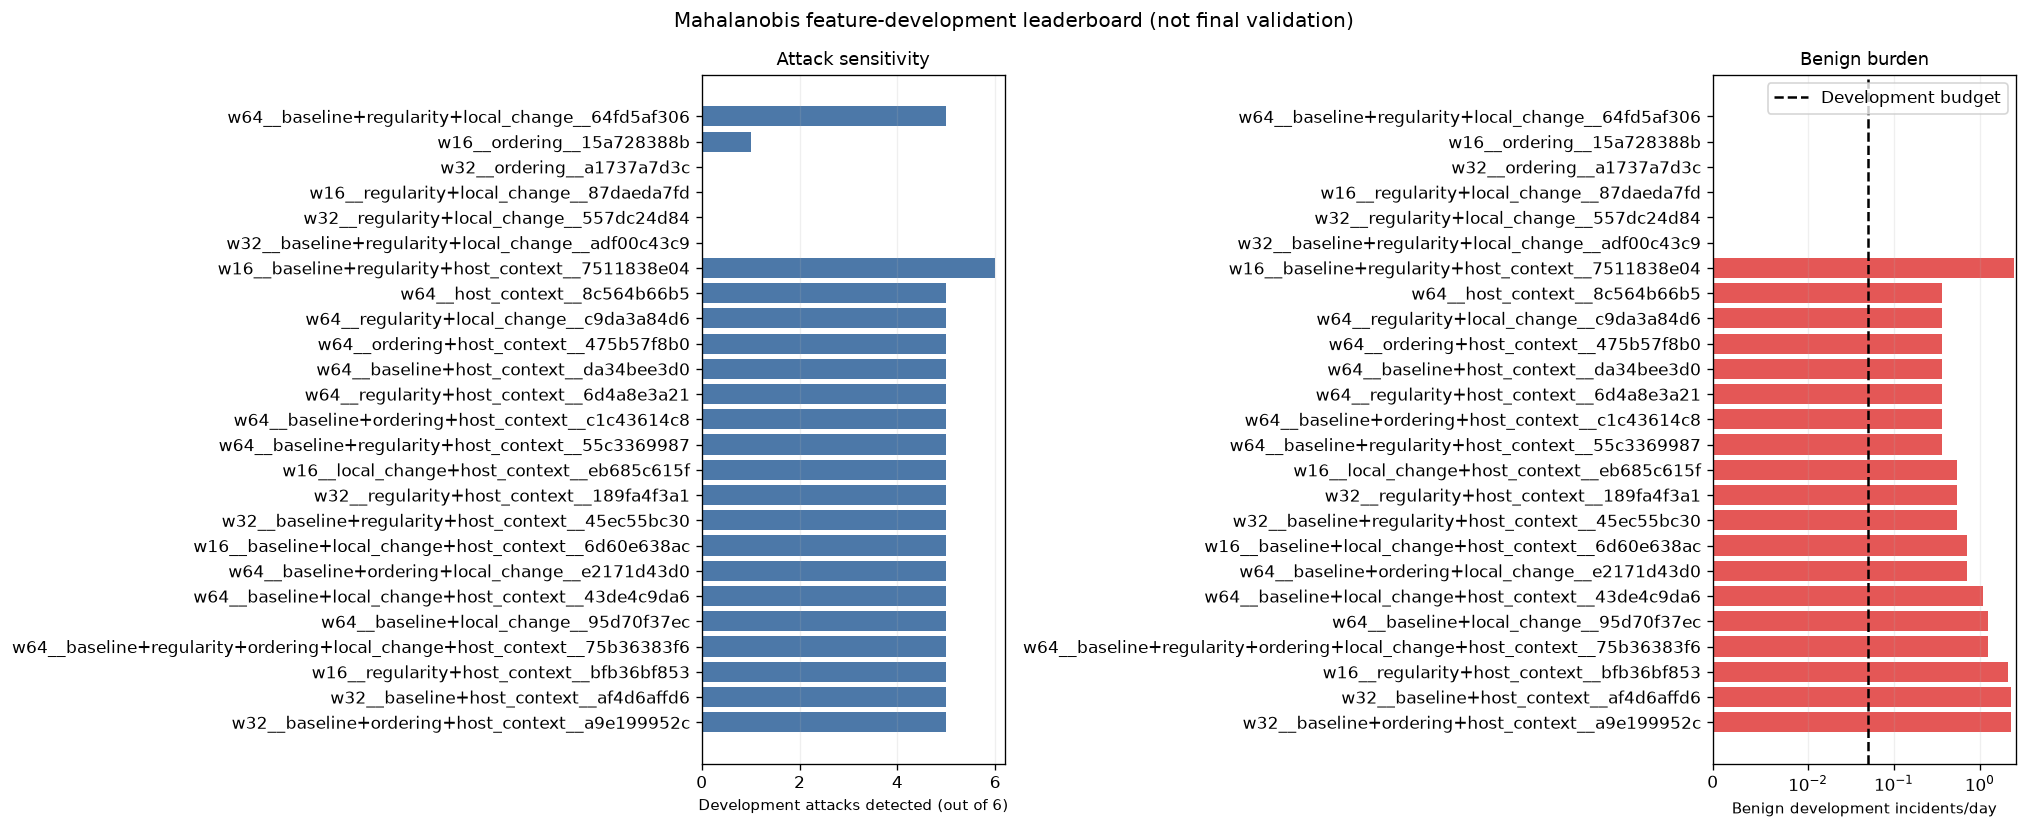

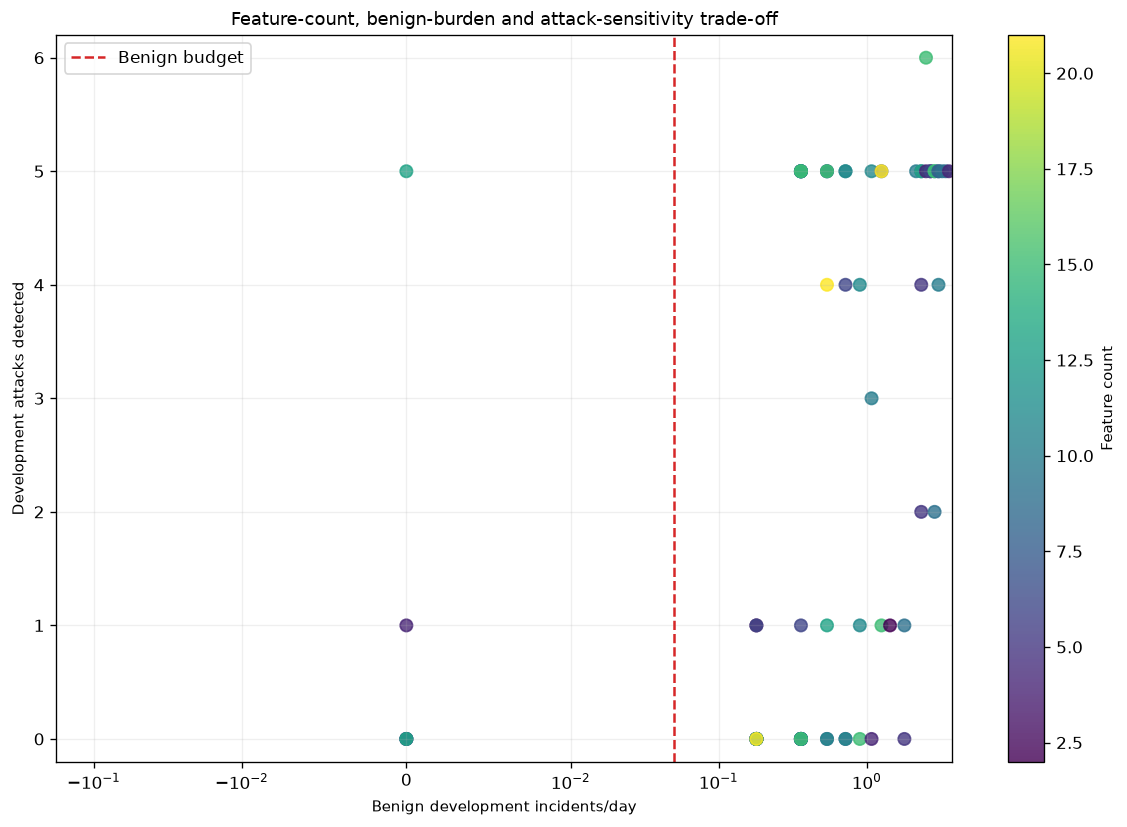

FEATURE LAB 7 — plots complete


In [21]:
# ============================================================
# FEATURE LAB 7 — MAHALANOBIS LEADERBOARD PLOTS
# ============================================================

_top_plot_rows = mahalanobis_feature_leaderboard.head(
    min(25, mahalanobis_feature_leaderboard.height)
)
_leaderboard_plot_path = (
    FEATURE_LAB_OUTPUT_DIR
    / "plot_01_mahalanobis_feature_leaderboard.png"
)
_figure, _axes = plt.subplots(
    1,
    2,
    figsize=(17, 7),
)
_labels = _top_plot_rows[
    "feature_set_id"
].to_list()[::-1]
_axes[0].barh(
    _labels,
    _top_plot_rows[
        "detected_attack_profiles"
    ].to_numpy()[::-1],
    color="#4c78a8",
)
_axes[0].set_xlim(0, 6.2)
_axes[0].set_xlabel("Development attacks detected (out of 6)")
_axes[0].set_title("Attack sensitivity")
_axes[0].grid(axis="x", alpha=0.2)

_axes[1].barh(
    _labels,
    _top_plot_rows[
        "development_incidents_per_day"
    ].to_numpy()[::-1],
    color="#e45756",
)
_axes[1].axvline(
    FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY,
    color="black",
    linestyle="--",
    label="Development budget",
)
_axes[1].set_xscale("symlog", linthresh=0.01)
_axes[1].set_xlabel("Benign development incidents/day")
_axes[1].set_title("Benign burden")
_axes[1].grid(axis="x", alpha=0.2)
_axes[1].legend()
_figure.suptitle(
    "Mahalanobis feature-development leaderboard "
    "(not final validation)"
)
_figure.tight_layout()
_figure.savefig(
    _leaderboard_plot_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

_tradeoff_plot_path = (
    FEATURE_LAB_OUTPUT_DIR
    / "plot_02_feature_tradeoff.png"
)
_figure, _axis = plt.subplots(figsize=(10, 7))
_scatter = _axis.scatter(
    mahalanobis_feature_leaderboard[
        "development_incidents_per_day"
    ].to_numpy(),
    mahalanobis_feature_leaderboard[
        "detected_attack_profiles"
    ].to_numpy(),
    c=mahalanobis_feature_leaderboard[
        "feature_count"
    ].to_numpy(),
    cmap="viridis",
    s=55,
    alpha=0.8,
)
_axis.axvline(
    FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY,
    color="#d62728",
    linestyle="--",
    label="Benign budget",
)
_axis.set_xscale("symlog", linthresh=0.01)
_axis.set_xlabel("Benign development incidents/day")
_axis.set_ylabel("Development attacks detected")
_axis.set_ylim(-0.2, 6.2)
_axis.set_title(
    "Feature-count, benign-burden and attack-sensitivity trade-off"
)
_axis.grid(alpha=0.2)
_axis.legend()
_figure.colorbar(
    _scatter,
    ax=_axis,
    label="Feature count",
)
_figure.tight_layout()
_figure.savefig(
    _tradeoff_plot_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("FEATURE LAB 7 — plots complete")



## Optional GRU refinement

The broad search above is intentionally fast. Training a GRU for every
candidate would be expensive and would multiply development overfitting.

The next stage therefore trains GRUs only for the top few Mahalanobis-screened
feature sets. This does **not** mean Mahalanobis and GRU rank features
identically. It is a computationally limited refinement stage and is labelled
as such in every export.



In [22]:
# ============================================================
# FEATURE LAB 8 — OPTIONAL GRU REFINEMENT HELPERS
# ============================================================

if RUN_GRU_REFINEMENT:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset


class FeatureLabGRU(nn.Module if RUN_GRU_REFINEMENT else object):
    def __init__(
        self,
        input_size: int,
    ):
        if not RUN_GRU_REFINEMENT:
            return
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=FEATURE_LAB_GRU_HIDDEN_SIZE,
            num_layers=FEATURE_LAB_GRU_NUM_LAYERS,
            dropout=FEATURE_LAB_GRU_DROPOUT,
            batch_first=True,
        )
        self.output = nn.Linear(
            FEATURE_LAB_GRU_HIDDEN_SIZE,
            1,
        )

    def forward(self, values):
        outputs, _ = self.gru(values)
        return self.output(outputs[:, -1, :]).squeeze(-1)


def _build_gru_sequences(
    rows: pl.DataFrame,
    feature_names: list[str],
    *,
    attack_mode: bool,
) -> list[dict]:
    group_keys = [
        "experiment_stream_id",
        "host_id",
        "activity_session_id",
        "parent_domain",
        "domain_activity_session_id",
        "window_size_events",
    ]
    records = []
    eligible = rows.filter(
        _all_finite_mask(rows, feature_names)
        & pl.col("target_next_log_domain_iat")
        .is_not_null()
        & pl.col("target_next_log_domain_iat")
        .is_finite()
        & pl.col("target_event_time").is_not_null()
    )
    for partition in eligible.partition_by(
        group_keys,
        maintain_order=True,
    ):
        partition = partition.sort(
            ["event_time", "_source_row"],
            maintain_order=True,
        )
        if (
            partition.height
            < FEATURE_LAB_GRU_SEQUENCE_LENGTH
        ):
            continue
        values = np.asarray(
            partition.select(feature_names).to_numpy(),
            dtype=np.float64,
        )
        targets = np.asarray(
            partition[
                "target_next_log_domain_iat"
            ].to_numpy(),
            dtype=np.float64,
        )
        for end_index in range(
            FEATURE_LAB_GRU_SEQUENCE_LENGTH - 1,
            partition.height,
        ):
            start_index = (
                end_index
                - FEATURE_LAB_GRU_SEQUENCE_LENGTH
                + 1
            )
            row = partition.row(
                end_index,
                named=True,
            )
            target_time = row["target_event_time"]
            split = _development_split_name(
                target_time,
                FEATURE_LAB_TRAIN_END_EXCLUSIVE,
                FEATURE_LAB_CALIBRATION_END_EXCLUSIVE,
            )
            if split == "calibration":
                lower_bound = (
                    FEATURE_LAB_TRAIN_END_EXCLUSIVE
                )
            elif split == "development_validation":
                lower_bound = (
                    FEATURE_LAB_CALIBRATION_END_EXCLUSIVE
                )
            else:
                lower_bound = None
            earliest_dependency = partition[
                "window_start_time"
            ][start_index]
            if (
                lower_bound is not None
                and earliest_dependency < lower_bound
            ):
                continue
            records.append(
                {
                    "X": values[
                        start_index : end_index + 1
                    ],
                    "y": float(targets[end_index]),
                    "split": split,
                    "feature_window_id": row[
                        "feature_window_id"
                    ],
                    "target_event_time": target_time,
                    "source_file": row["source_file"],
                    "experiment_stream_id": row[
                        "experiment_stream_id"
                    ],
                    "host_id": row["host_id"],
                    "parent_domain": row["parent_domain"],
                    "target_source_type": row[
                        "target_source_type"
                    ],
                    "target_attack_profile": row[
                        "target_attack_profile"
                    ],
                    "target_injection_id": row[
                        "target_injection_id"
                    ],
                    "target_attack_event_ordinal": row[
                        "target_attack_event_ordinal"
                    ],
                    "attack_mode": attack_mode,
                }
            )
    return records


def _predict_gru(
    model,
    values: np.ndarray,
    device,
) -> np.ndarray:
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(
            0,
            values.shape[0],
            FEATURE_LAB_GRU_BATCH_SIZE * 4,
        ):
            batch = torch.as_tensor(
                values[
                    start : start
                    + FEATURE_LAB_GRU_BATCH_SIZE * 4
                ],
                dtype=torch.float32,
                device=device,
            )
            predictions.append(
                model(batch).detach().cpu().numpy()
            )
    return np.concatenate(predictions)


def _train_gru_candidate(
    feature_set_config: dict,
) -> tuple[dict, list[dict]]:
    feature_names = json.loads(
        feature_set_config["feature_names_json"]
    )
    window_size = int(
        feature_set_config["window_size_events"]
    )
    benign_rows = feature_lab_benign_windows.filter(
        pl.col("window_size_events") == window_size
    )
    records = _build_gru_sequences(
        benign_rows,
        feature_names,
        attack_mode=False,
    )
    split_records = {
        split: [
            record
            for record in records
            if record["split"] == split
        ]
        for split in [
            "train",
            "calibration",
            "development_validation",
        ]
    }
    if any(
        len(values) < FEATURE_LAB_MIN_WINDOWS_PER_SPLIT
        for values in split_records.values()
    ):
        return (
            {
                "feature_set_id": (
                    feature_set_config[
                        "feature_set_id"
                    ]
                ),
                "status": "INELIGIBLE",
                "reason": "insufficient GRU sequences",
            },
            [],
        )

    arrays = {}
    for split, values in split_records.items():
        arrays[split] = {
            "X": np.stack(
                [record["X"] for record in values]
            ).astype(np.float64),
            "y": np.asarray(
                [record["y"] for record in values],
                dtype=np.float64,
            ),
            "metadata": values,
        }
    input_medians = np.median(
        arrays["train"]["X"].reshape(
            -1,
            len(feature_names),
        ),
        axis=0,
    )
    input_q25 = np.quantile(
        arrays["train"]["X"].reshape(
            -1,
            len(feature_names),
        ),
        0.25,
        axis=0,
    )
    input_q75 = np.quantile(
        arrays["train"]["X"].reshape(
            -1,
            len(feature_names),
        ),
        0.75,
        axis=0,
    )
    input_scales = input_q75 - input_q25
    input_scales = np.where(
        input_scales > 1e-12,
        input_scales,
        1.0,
    )
    target_median = float(
        np.median(arrays["train"]["y"])
    )
    target_q25 = float(
        np.quantile(arrays["train"]["y"], 0.25)
    )
    target_q75 = float(
        np.quantile(arrays["train"]["y"], 0.75)
    )
    target_scale = (
        target_q75 - target_q25
    )
    if target_scale <= 1e-12:
        target_scale = 1.0
    for split in arrays:
        arrays[split]["X_scaled"] = (
            (
                arrays[split]["X"]
                - input_medians[None, None, :]
            )
            / input_scales[None, None, :]
        ).astype(np.float32)
        arrays[split]["y_scaled"] = (
            (
                arrays[split]["y"]
                - target_median
            )
            / target_scale
        ).astype(np.float32)

    # Early stopping uses a chronological tail of training only. Calibration
    # remains untouched until threshold selection.
    train_count = arrays["train"]["X_scaled"].shape[0]
    selection_start = max(
        int(np.floor(train_count * 0.80)),
        1,
    )
    fit_X = arrays["train"]["X_scaled"][
        :selection_start
    ]
    fit_y = arrays["train"]["y_scaled"][
        :selection_start
    ]
    select_X = arrays["train"]["X_scaled"][
        selection_start:
    ]
    select_y = arrays["train"]["y_scaled"][
        selection_start:
    ]
    if select_X.shape[0] == 0:
        select_X = fit_X[-1:]
        select_y = fit_y[-1:]

    random.seed(FEATURE_LAB_RANDOM_SEED)
    np.random.seed(FEATURE_LAB_RANDOM_SEED)
    torch.manual_seed(FEATURE_LAB_RANDOM_SEED)
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )
    model = FeatureLabGRU(
        input_size=len(feature_names)
    ).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=FEATURE_LAB_GRU_LEARNING_RATE,
        weight_decay=FEATURE_LAB_GRU_WEIGHT_DECAY,
    )
    loss_function = nn.MSELoss()
    loader = DataLoader(
        TensorDataset(
            torch.as_tensor(
                fit_X,
                dtype=torch.float32,
            ),
            torch.as_tensor(
                fit_y,
                dtype=torch.float32,
            ),
        ),
        batch_size=FEATURE_LAB_GRU_BATCH_SIZE,
        shuffle=False,
    )
    best_epoch = 1
    best_selection_loss = math.inf
    best_state = None
    patience = 0
    for epoch in range(
        1,
        FEATURE_LAB_GRU_MAX_SELECTION_EPOCHS + 1,
    ):
        model.train()
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_function(
                model(batch_X),
                batch_y,
            )
            loss.backward()
            optimizer.step()
        selection_predictions = _predict_gru(
            model,
            select_X,
            device,
        )
        selection_loss = float(
            np.mean(
                (
                    selection_predictions
                    - select_y
                )
                ** 2
            )
        )
        if selection_loss < best_selection_loss:
            best_selection_loss = selection_loss
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            }
            patience = 0
        else:
            patience += 1
        if (
            patience
            >= FEATURE_LAB_GRU_EARLY_STOPPING_PATIENCE
        ):
            break
    if best_state is not None:
        model.load_state_dict(best_state)

    # Calibration and development errors use the selected training-only model.
    prediction_errors = {}
    for split in [
        "calibration",
        "development_validation",
    ]:
        predicted_scaled = _predict_gru(
            model,
            arrays[split]["X_scaled"],
            device,
        )
        predicted_log = (
            predicted_scaled * target_scale
            + target_median
        )
        prediction_errors[split] = np.abs(
            arrays[split]["y"] - predicted_log
        )
    threshold = float(
        np.quantile(
            prediction_errors["calibration"],
            FEATURE_LAB_CALIBRATION_QUANTILE,
            method="higher",
        )
    )
    development_errors = prediction_errors[
        "development_validation"
    ]
    development_metadata = pl.DataFrame(
        [
            {
                key: value
                for key, value in record.items()
                if key not in {"X", "y"}
            }
            for record in arrays[
                "development_validation"
            ]["metadata"]
        ],
        infer_schema_length=None,
    ).with_columns(
        [
            pl.Series(
                "development_score",
                development_errors,
            ),
            pl.lit(threshold).alias(
                "development_threshold"
            ),
        ]
    ).with_columns(
        (
            pl.col("development_score") > threshold
        ).alias("is_development_exceedance")
    )
    development_flags = development_metadata.filter(
        pl.col("is_development_exceedance")
    )
    development_incidents = _incident_count(
        development_flags.rename(
            {
                "target_event_time": "event_time",
            }
        ).with_columns(
            pl.col("feature_window_id")
        ),
        time_column="event_time",
        group_columns=[
            "experiment_stream_id",
            "host_id",
        ],
    )
    wall_days = FEATURE_LAB_DEVELOPMENT_WALL_DAYS
    incidents_per_day = (
        development_incidents / wall_days
    )

    injected_rows = (
        feature_lab_injected_windows
        .filter(
            pl.col("window_size_events")
            == window_size
        )
    )
    injected_records = _build_gru_sequences(
        injected_rows,
        feature_names,
        attack_mode=True,
    )
    attack_records = [
        record
        for record in injected_records
        if record["target_source_type"] == "attack"
    ]
    profile_results = []
    detected_profiles = 0
    if attack_records:
        attack_X = np.stack(
            [record["X"] for record in attack_records]
        ).astype(np.float64)
        attack_y = np.asarray(
            [record["y"] for record in attack_records],
            dtype=np.float64,
        )
        attack_X_scaled = (
            (
                attack_X
                - input_medians[None, None, :]
            )
            / input_scales[None, None, :]
        ).astype(np.float32)
        attack_predicted_scaled = _predict_gru(
            model,
            attack_X_scaled,
            device,
        )
        attack_predicted_log = (
            attack_predicted_scaled * target_scale
            + target_median
        )
        attack_errors = np.abs(
            attack_y - attack_predicted_log
        )
    else:
        attack_errors = np.asarray([], dtype=float)

    for spec in ATTACK_INJECTION_SPECS:
        profile = spec["attack_profile"]
        profile_pairs = sorted(
            [
                (index, record)
                for index, record in enumerate(attack_records)
                if record["target_attack_profile"] == profile
            ],
            key=lambda pair: (
                pair[1]["target_event_time"],
                pair[1]["target_attack_event_ordinal"]
                if pair[1]["target_attack_event_ordinal"]
                is not None
                else -1,
            ),
        )
        profile_indices = [
            pair[0] for pair in profile_pairs
        ]
        eligibility_record = (
            injection_manifest
            .filter(pl.col("attack_profile") == profile)
            .row(0, named=True)
        )
        total_attack_events = int(
            eligibility_record["injected_event_count"]
        )
        if profile_indices:
            profile_errors = attack_errors[
                profile_indices
            ]
            profile_flags = profile_errors > threshold
            exceedance_count = int(
                profile_flags.sum()
            )
            detected = bool(exceedance_count > 0)
            first_detection_ordinal = None
            if detected:
                first_local_index = int(
                    np.flatnonzero(profile_flags)[0]
                )
                first_record = profile_pairs[
                    first_local_index
                ][1]
                first_detection_ordinal = (
                    first_record[
                        "target_attack_event_ordinal"
                    ]
                )
            median_score = float(
                np.median(profile_errors)
            )
            maximum_score = float(
                profile_errors.max()
            )
        else:
            exceedance_count = 0
            detected = False
            first_detection_ordinal = None
            median_score = None
            maximum_score = None
        detected_profiles += int(detected)
        profile_results.append(
            {
                "feature_set_id": (
                    feature_set_config[
                        "feature_set_id"
                    ]
                ),
                "model_family": "gru",
                "attack_profile": profile,
                "window_size_events": window_size,
                "total_attack_events": total_attack_events,
                "scored_attack_targets": (
                    len(profile_indices)
                ),
                "eligible_coverage_pct": (
                    100.0
                    * len(profile_indices)
                    / total_attack_events
                    if total_attack_events
                    else None
                ),
                "attack_exceedance_count": (
                    exceedance_count
                ),
                "profile_detected": detected,
                "attack_events_to_detection": (
                    first_detection_ordinal
                ),
                "median_attack_score": median_score,
                "maximum_attack_score": maximum_score,
                "locked_development_threshold": threshold,
            }
        )
    return (
        {
            "feature_set_id": (
                feature_set_config[
                    "feature_set_id"
                ]
            ),
            "window_size_events": window_size,
            "feature_count": len(feature_names),
            "feature_families_json": (
                feature_set_config[
                    "feature_families_json"
                ]
            ),
            "feature_names_json": (
                feature_set_config[
                    "feature_names_json"
                ]
            ),
            "status": "COMPLETE",
            "train_sequences": len(
                split_records["train"]
            ),
            "calibration_sequences": len(
                split_records["calibration"]
            ),
            "development_sequences": len(
                split_records[
                    "development_validation"
                ]
            ),
            "selected_epoch": best_epoch,
            "training_only_selection_loss": (
                best_selection_loss
            ),
            "calibration_threshold": threshold,
            "development_exceedance_count": (
                development_flags.height
            ),
            "development_incident_count": (
                development_incidents
            ),
            "development_wall_days": wall_days,
            "development_incidents_per_day": (
                incidents_per_day
            ),
            "benign_budget_pass": bool(
                incidents_per_day
                <= FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY
            ),
            "detected_attack_profiles": (
                detected_profiles
            ),
            "total_attack_profiles": 6,
            "screening_qualification": (
                "GRU refinement limited to feature sets "
                "selected by Mahalanobis development rank"
            ),
            "development_only": True,
            "final_holdout_required": True,
        },
        profile_results,
    )


print(
    "FEATURE LAB 8 — GRU refinement helpers ready; "
    f"enabled={RUN_GRU_REFINEMENT}"
)



FEATURE LAB 8 — GRU refinement helpers ready; enabled=True


In [23]:
# ============================================================
# FEATURE LAB 9 — RUN OPTIONAL TOP-K GRU REFINEMENT
# ============================================================

_gru_summary_rows = []
_gru_profile_rows = []
if RUN_GRU_REFINEMENT:
    _top_feature_set_ids = (
        mahalanobis_feature_leaderboard
        .head(FEATURE_LAB_GRU_TOP_K)[
            "feature_set_id"
        ]
        .to_list()
    )
    # Always include the original 32-event baseline as a reference.
    _baseline_32 = (
        feature_lab_experiment_registry
        .filter(
            (pl.col("window_size_events") == 32)
            & (
                pl.col("feature_families_json")
                == json.dumps(["baseline"])
            )
        )["feature_set_id"]
        .to_list()
    )
    _gru_feature_set_ids = list(
        dict.fromkeys(
            _top_feature_set_ids + _baseline_32
        )
    )
    for _index, _feature_set_id_value in enumerate(
        _gru_feature_set_ids,
        start=1,
    ):
        _config = (
            feature_lab_experiment_registry
            .filter(
                pl.col("feature_set_id")
                == _feature_set_id_value
            )
            .row(0, named=True)
        )
        try:
            _summary, _profiles = _train_gru_candidate(
                _config
            )
        except Exception as _gru_error:
            _summary = {
                "feature_set_id": (
                    _feature_set_id_value
                ),
                "status": "EXPERIMENT_FAILURE",
                "reason": repr(_gru_error),
                "development_only": True,
                "final_holdout_required": True,
            }
            _profiles = []
        _gru_summary_rows.append(_summary)
        _gru_profile_rows.extend(_profiles)
        print(
            f"GRU refinement: "
            f"{_index}/{len(_gru_feature_set_ids)} "
            f"{_feature_set_id_value} -> "
            f"{_summary['status']}"
        )

if _gru_summary_rows:
    gru_feature_refinement_summary = pl.DataFrame(
        _gru_summary_rows,
        infer_schema_length=None,
    )
else:
    gru_feature_refinement_summary = pl.DataFrame(
        schema={
            "feature_set_id": pl.String,
            "status": pl.String,
        }
    )
if _gru_profile_rows:
    gru_feature_refinement_profiles = pl.DataFrame(
        _gru_profile_rows,
        infer_schema_length=None,
    )
else:
    gru_feature_refinement_profiles = pl.DataFrame(
        schema={
            "feature_set_id": pl.String,
            "model_family": pl.String,
            "attack_profile": pl.String,
        }
    )

print("FEATURE LAB 9 — optional GRU refinement complete")
display(gru_feature_refinement_summary)
if gru_feature_refinement_profiles.height:
    display(gru_feature_refinement_profiles)



GRU refinement: 1/4 w64__baseline+regularity+local_change__64fd5af306 -> COMPLETE
GRU refinement: 2/4 w16__ordering__15a728388b -> COMPLETE
GRU refinement: 3/4 w32__ordering__a1737a7d3c -> COMPLETE
GRU refinement: 4/4 w32__baseline__aa8688b7b5 -> COMPLETE
FEATURE LAB 9 — optional GRU refinement complete


feature_set_id,window_size_events,feature_count,feature_families_json,feature_names_json,status,train_sequences,calibration_sequences,development_sequences,selected_epoch,training_only_selection_loss,calibration_threshold,development_exceedance_count,development_incident_count,development_wall_days,development_incidents_per_day,benign_budget_pass,detected_attack_profiles,total_attack_profiles,screening_qualification,development_only,final_holdout_required
str,i64,i64,str,str,str,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,bool,i64,i64,str,bool,bool
"""w64__baseline+regularity+local…",64,13,"""[""baseline"", ""regularity"", ""lo…","""[""log_iat_median"", ""log_iat_p9…","""COMPLETE""",12943,4330,2992,24,0.350889,3.643998,109,17,5.570712,3.051675,false,2,6,"""GRU refinement limited to feat…",true,true
"""w16__ordering__15a728388b""",16,4,"""[""ordering""]""","""[""log_iat_lag2_autocorrelation…","""COMPLETE""",14366,4677,4741,24,0.807695,4.028578,2,2,5.570712,0.359021,false,0,6,"""GRU refinement limited to feat…",true,true
"""w32__ordering__a1737a7d3c""",32,4,"""[""ordering""]""","""[""log_iat_lag2_autocorrelation…","""COMPLETE""",13965,4597,4332,56,0.788754,3.853612,11,6,5.570712,1.077062,false,0,6,"""GRU refinement limited to feat…",true,true
"""w32__baseline__aa8688b7b5""",32,5,"""[""baseline""]""","""[""log_iat_median"", ""log_iat_p9…","""COMPLETE""",13965,4597,4332,20,0.289585,3.66419,29,17,5.570712,3.051675,false,1,6,"""GRU refinement limited to feat…",true,true


feature_set_id,model_family,attack_profile,window_size_events,total_attack_events,scored_attack_targets,eligible_coverage_pct,attack_exceedance_count,profile_detected,attack_events_to_detection,median_attack_score,maximum_attack_score,locked_development_threshold
str,str,str,i64,i64,i64,f64,i64,bool,i64,f64,f64,f64
"""w64__baseline+regularity+local…","""gru""","""no_jitter""",64,777,586,75.418275,0,false,null,1.572459,2.437652,3.643998
"""w64__baseline+regularity+local…","""gru""","""j1""",64,781,586,75.03201,0,false,null,1.828313,2.48373,3.643998
"""w64__baseline+regularity+local…","""gru""","""j2""",64,809,586,72.435105,0,false,null,2.171018,3.034612,3.643998
"""w64__baseline+regularity+local…","""gru""","""j3""",64,794,586,73.803526,0,false,null,2.179125,3.188199,3.643998
"""w64__baseline+regularity+local…","""gru""","""s1""",64,592,370,62.5,20,true,152,2.976988,3.933232,3.643998
…,…,…,…,…,…,…,…,…,…,…,…,…
"""w32__baseline__aa8688b7b5""","""gru""","""j1""",32,781,682,87.323944,0,false,null,0.569503,0.99647,3.66419
"""w32__baseline__aa8688b7b5""","""gru""","""j2""",32,809,682,84.301607,0,false,null,0.549696,0.99838,3.66419
"""w32__baseline__aa8688b7b5""","""gru""","""j3""",32,794,682,85.894207,0,false,null,0.619737,1.106184,3.66419


In [24]:
# ============================================================
# FEATURE LAB 10 — DEVELOPMENT CANDIDATE, EXPORTS AND HANDOFF
# ============================================================

_candidate_source = (
    mahalanobis_feature_leaderboard
    .filter(pl.col("benign_budget_pass"))
)
if _candidate_source.height:
    _development_candidate_row = (
        _candidate_source.row(0, named=True)
    )
    _candidate_selection_status = (
        "DEVELOPMENT_CANDIDATE_PASSES_OBSERVED_BENIGN_BUDGET"
    )
elif mahalanobis_feature_leaderboard.height:
    _development_candidate_row = (
        mahalanobis_feature_leaderboard.row(
            0,
            named=True,
        )
    )
    _candidate_selection_status = (
        "NO_CANDIDATE_PASSED_BENIGN_BUDGET_"
        "TOP_DEVELOPMENT_ROW_RETAINED_FOR_DIAGNOSIS"
    )
else:
    _development_candidate_row = None
    _candidate_selection_status = (
        "NO_COMPLETE_CANDIDATE"
    )

feature_lab_development_candidate = pl.DataFrame(
    [
        {
            "selection_status": (
                _candidate_selection_status
            ),
            "model_family": "mahalanobis",
            "feature_set_id": (
                _development_candidate_row[
                    "feature_set_id"
                ]
                if _development_candidate_row
                else None
            ),
            "window_size_events": (
                _development_candidate_row[
                    "window_size_events"
                ]
                if _development_candidate_row
                else None
            ),
            "feature_families_json": (
                _development_candidate_row[
                    "feature_families_json"
                ]
                if _development_candidate_row
                else None
            ),
            "feature_names_json": (
                _development_candidate_row[
                    "feature_names_json"
                ]
                if _development_candidate_row
                else None
            ),
            "development_incidents_per_day": (
                _development_candidate_row[
                    "development_incidents_per_day"
                ]
                if _development_candidate_row
                else None
            ),
            "development_attacks_detected": (
                _development_candidate_row[
                    "detected_attack_profiles"
                ]
                if _development_candidate_row
                else None
            ),
            "development_attacks_total": 6,
            "attacks_used_for_selection": True,
            "final_benign_holdout_required": True,
            "final_attack_holdout_required": True,
            "is_final_validated_model": False,
        }
    ],
    infer_schema_length=None,
)

_final_gates = [
    _feature_lab_gate(
        "foundation injection integrity passed",
        _all_injection_integrity_pass,
        "Section 13",
    ),
    _feature_lab_gate(
        "candidate materialisation integrity passed",
        _all_materialisation_gates_pass,
        feature_lab_materialisation_gates.to_dicts(),
    ),
    _feature_lab_gate(
        "Mahalanobis screening integrity passed",
        _all_mahalanobis_screen_gates_pass,
        feature_lab_mahalanobis_screen_gates.to_dicts(),
    ),
    _feature_lab_gate(
        "attack-informed development is labelled honestly",
        bool(
            feature_lab_development_candidate[
                "attacks_used_for_selection"
            ][0]
            and not feature_lab_development_candidate[
                "is_final_validated_model"
            ][0]
        ),
        (
            "current six attacks are development data; "
            "fresh final holdouts required"
        ),
    ),
]
feature_lab_final_integrity_gates = pl.DataFrame(
    _final_gates,
    infer_schema_length=None,
)
_all_feature_lab_final_gates_pass = bool(
    feature_lab_final_integrity_gates.select(
        (pl.col("status") == "PASS").all()
    ).item()
)

_csv_exports_feature_lab = {
    "01_feature_registry.csv": (
        feature_lab_feature_registry
    ),
    "02_feature_quality.csv": (
        feature_lab_feature_quality
    ),
    "03_experiment_registry.csv": (
        feature_lab_experiment_registry
    ),
    "04_mahalanobis_feature_screen_summary.csv": (
        mahalanobis_feature_screen_summary
    ),
    "05_mahalanobis_feature_leaderboard.csv": (
        mahalanobis_feature_leaderboard
    ),
    "06_mahalanobis_attack_profile_results.csv": (
        mahalanobis_feature_screen_profiles
    ),
    "07_gru_refinement_summary.csv": (
        gru_feature_refinement_summary
    ),
    "08_gru_refinement_attack_profiles.csv": (
        gru_feature_refinement_profiles
    ),
    "09_development_candidate.csv": (
        feature_lab_development_candidate
    ),
    "10_final_integrity_gates.csv": (
        feature_lab_final_integrity_gates
    ),
}
_feature_lab_export_paths = []
for _filename, _frame in _csv_exports_feature_lab.items():
    _path = FEATURE_LAB_OUTPUT_DIR / _filename
    _frame.write_csv(_path)
    _feature_lab_export_paths.append(_path)

_development_candidate_payload = (
    feature_lab_development_candidate.to_dicts()[0]
)
_development_candidate_payload.update(
    {
        "warning": (
            "DEVELOPMENT ONLY. Current attacks and benign "
            "development validation influenced selection."
        ),
        "next_required_action": (
            "freeze a candidate, collect new benign and attack "
            "holdouts, then evaluate exactly once"
        ),
    }
)
_candidate_json_path = (
    FEATURE_LAB_OUTPUT_DIR
    / "development_candidate_not_final.json"
)
_candidate_json_path.write_text(
    json.dumps(
        _development_candidate_payload,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

_run_manifest_feature_lab = {
    "analysis_version": FEATURE_LAB_VERSION,
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "research_stage": (
        "attack-informed causal feature development"
    ),
    "host_session_minutes": (
        SELECTED_SESSION_THRESHOLD_MINUTES
    ),
    "domain_session_minutes": (
        DOMAIN_INACTIVITY_MINUTES
    ),
    "window_sizes": FEATURE_LAB_WINDOW_SIZES,
    "candidate_feature_count": (
        len(FEATURE_LAB_ALL_FEATURES)
    ),
    "feature_set_count": (
        feature_lab_experiment_registry.height
    ),
    "train_end_exclusive": str(
        FEATURE_LAB_TRAIN_END_EXCLUSIVE
    ),
    "calibration_end_exclusive": str(
        FEATURE_LAB_CALIBRATION_END_EXCLUSIVE
    ),
    "threshold_quantile": (
        FEATURE_LAB_CALIBRATION_QUANTILE
    ),
    "threshold_comparison": (
        FEATURE_LAB_THRESHOLD_COMPARISON
    ),
    "incident_gap_minutes": (
        FEATURE_LAB_INCIDENT_GAP_MINUTES
    ),
    "false_incident_budget_per_day": (
        FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY
    ),
    "current_attacks_role": "development selection",
    "current_benign_test_role": (
        "development validation"
    ),
    "fresh_final_benign_holdout_required": True,
    "fresh_final_attack_holdout_required": True,
    "model_training_uses_attack_rows": False,
    "threshold_calibration_uses_attack_rows": False,
    "feature_selection_uses_attack_results": True,
    "gru_refinement_enabled": RUN_GRU_REFINEMENT,
    "gru_refinement_top_k": (
        FEATURE_LAB_GRU_TOP_K
    ),
    "development_candidate": (
        _development_candidate_payload
    ),
    "integrity_pass": (
        _all_feature_lab_final_gates_pass
    ),
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "polars_version": pl.__version__,
    "matplotlib_version": (
        package_version("matplotlib")
    ),
    "torch_version": (
        torch.__version__
        if RUN_GRU_REFINEMENT
        else None
    ),
    "output_directory": str(
        FEATURE_LAB_OUTPUT_DIR
    ),
}
_run_manifest_path_feature_lab = (
    FEATURE_LAB_OUTPUT_DIR / "run_manifest.json"
)
_run_manifest_path_feature_lab.write_text(
    json.dumps(
        _run_manifest_feature_lab,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

_context_summary_feature_lab = f"""# DNS Timing Feature Laboratory

## Scientific role

This is attack-informed **development**, not final validation.

- Model fitting uses benign training only.
- Thresholds use benign calibration only.
- Current six attacks influence feature selection.
- Existing benign test is development validation.
- Fresh benign and attack holdouts are mandatory after selection.

## Search

- Candidate features: `{len(FEATURE_LAB_ALL_FEATURES)}`
- Feature families: `{list(FEATURE_FAMILIES)}`
- Window sizes: `{FEATURE_LAB_WINDOW_SIZES}`
- Registered feature sets: `{feature_lab_experiment_registry.height}`
- Complete Mahalanobis experiments: `{mahalanobis_feature_leaderboard.height}`
- GRU refinement enabled: `{RUN_GRU_REFINEMENT}`

## Development candidate

- Status: `{_candidate_selection_status}`
- Feature set: `{_development_candidate_payload.get('feature_set_id')}`
- Window size: `{_development_candidate_payload.get('window_size_events')}`
- Features: `{_development_candidate_payload.get('feature_names_json')}`
- Benign development incidents/day: `{_development_candidate_payload.get('development_incidents_per_day')}`
- Development attacks detected: `{_development_candidate_payload.get('development_attacks_detected')}/6`

## Required next step

Do not present this candidate as final. Freeze the chosen configuration, collect
new benign and attack captures that did not influence this search, and evaluate
them once under the same strict attribution and incident rules.

## Integrity

**{'PASS' if _all_feature_lab_final_gates_pass else 'FAIL'}**
"""
_context_summary_path_feature_lab = (
    FEATURE_LAB_OUTPUT_DIR / "CONTEXT_SUMMARY.md"
)
_context_summary_path_feature_lab.write_text(
    _context_summary_feature_lab,
    encoding="utf-8",
)

_bundle_path_feature_lab = (
    FEATURE_LAB_OUTPUT_DIR
    / "dns_feature_laboratory_context_bundle_v1_0_0.zip"
)
_bundle_paths = (
    _feature_lab_export_paths
    + [
        _candidate_json_path,
        _run_manifest_path_feature_lab,
        _context_summary_path_feature_lab,
        _leaderboard_plot_path,
        _tradeoff_plot_path,
    ]
)
with zipfile.ZipFile(
    _bundle_path_feature_lab,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for path in _bundle_paths:
        archive.write(path, arcname=path.name)

print("FEATURE LAB 10 — development handoff complete")
print(
    f"Integrity: "
    f"{'PASS' if _all_feature_lab_final_gates_pass else 'FAIL'}"
)
print(
    f"Candidate status: {_candidate_selection_status}"
)
print(
    "WARNING: this is not a final validated detector. "
    "Fresh final holdouts are required."
)
print(f"Output directory: {FEATURE_LAB_OUTPUT_DIR}")
print(f"Context bundle: {_bundle_path_feature_lab}")
display(feature_lab_development_candidate)
display(feature_lab_final_integrity_gates)

if not _all_feature_lab_final_gates_pass:
    raise RuntimeError(
        "Feature laboratory failed one or more final "
        "integrity gates."
    )


FEATURE LAB 10 — development handoff complete
Integrity: PASS
Candidate status: DEVELOPMENT_CANDIDATE_PASSES_OBSERVED_BENIGN_BUDGET
Output directory: /home/notevenknow/Desktop/jupyter_lab/Data/outputs_dns_feature_laboratory_v1_0_0
Context bundle: /home/notevenknow/Desktop/jupyter_lab/Data/outputs_dns_feature_laboratory_v1_0_0/dns_feature_laboratory_context_bundle_v1_0_0.zip


selection_status,model_family,feature_set_id,window_size_events,feature_families_json,feature_names_json,development_incidents_per_day,development_attacks_detected,development_attacks_total,attacks_used_for_selection,final_benign_holdout_required,final_attack_holdout_required,is_final_validated_model
str,str,str,i64,str,str,f64,i64,i64,bool,bool,bool,bool
"""DEVELOPMENT_CANDIDATE_PASSES_O…","""mahalanobis""","""w64__baseline+regularity+local…",64,"""[""baseline"", ""regularity"", ""lo…","""[""log_iat_median"", ""log_iat_p9…",0.0,5,6,true,true,true,false


gate_name,status,observed
str,str,str
"""foundation injection integrity…","""PASS""","""Section 13"""
"""candidate materialisation inte…","""PASS""","""[{'gate_name': 'benign candida…"
"""Mahalanobis screening integrit…","""PASS""","""[{'gate_name': 'at least one M…"
"""attack-informed development is…","""PASS""","""current six attacks are develo…"


## Section 14 — Locked Mahalanobis Results Visualization

This section **stands on the completed detector findings**. It does not
search for new features, retrain against attack labels, change the
99.9th-percentile calibration rule, or lower the threshold to force an
S2 detection.

The locked development candidate is:

- `w64__baseline+regularity+local_change__64fd5af306`
- 64-event same-parent-domain windows
- 13 causal, content-free timing features
- squared Mahalanobis distance
- threshold `216.1402379283405`, selected from benign calibration only

### What “performance” means here

Generic accuracy is not an appropriate headline for this one-class
detector. The six attack captures are not a representative population
of all attacks, and the current attacks influenced feature selection.
The figures therefore separate:

1. profile-level detection (`5/6`);
2. eligible attack-window coverage;
3. the fraction and strength of threshold exceedances;
4. detection delay in attack events;
5. observed benign incidents per day;
6. uncertainty caused by only 5.57 days of benign development exposure.

The three user-provided web resources were used only as presentation
guidance: translate metrics into operational meaning, distinguish
development from final testing, and make model behavior visible inside
the notebook. They are not evidence that validates this detector.


In [25]:
# ============================================================
# RESULTS VISUALIZATION 1 — LOCK AND RECONSTRUCT SCORE EVIDENCE
# ============================================================

from pathlib import Path
import json
import math
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import polars as pl


RESULTS_VIS_VERSION = "1.1.0"
RESULTS_CANDIDATE_ID = (
    "w64__baseline+regularity+local_change__64fd5af306"
)
RESULTS_PROFILE_ORDER = [
    "no_jitter",
    "j1",
    "j2",
    "j3",
    "s1",
    "s2",
]
RESULTS_PROFILE_LABELS = {
    "no_jitter": "No jitter",
    "j1": "J1",
    "j2": "J2",
    "j3": "J3",
    "s1": "S1",
    "s2": "S2",
}
RESULTS_PLOT_DIR = FEATURE_LAB_OUTPUT_DIR
RESULTS_PLOT_DIR.mkdir(parents=True, exist_ok=True)

_results_required_objects = [
    "feature_lab_experiment_registry",
    "feature_lab_benign_windows",
    "feature_lab_injected_windows",
    "mahalanobis_feature_leaderboard",
    "mahalanobis_feature_screen_profiles",
    "_robust_fit_scale",
    "_fit_regularized_mahalanobis",
    "_score_squared_mahalanobis",
    "_split_benign_candidate_rows",
    "_all_finite_mask",
]
_results_missing_objects = [
    name
    for name in _results_required_objects
    if name not in globals()
]
if _results_missing_objects:
    raise RuntimeError(
        "Run the notebook through Feature Lab 10 before this "
        f"results section. Missing: {_results_missing_objects}"
    )

_results_config = (
    feature_lab_experiment_registry
    .filter(
        pl.col("feature_set_id")
        == RESULTS_CANDIDATE_ID
    )
)
if _results_config.height != 1:
    raise RuntimeError(
        "The locked results candidate was not found exactly once."
    )
_results_config_row = _results_config.row(0, named=True)
RESULTS_WINDOW_SIZE = int(
    _results_config_row["window_size_events"]
)
RESULTS_FEATURES = json.loads(
    _results_config_row["feature_names_json"]
)
if RESULTS_WINDOW_SIZE != 64 or len(RESULTS_FEATURES) != 13:
    raise RuntimeError(
        "The locked candidate definition changed unexpectedly."
    )

_results_summary = (
    mahalanobis_feature_leaderboard
    .filter(
        pl.col("feature_set_id")
        == RESULTS_CANDIDATE_ID
    )
)
_results_profiles = (
    mahalanobis_feature_screen_profiles
    .filter(
        pl.col("feature_set_id")
        == RESULTS_CANDIDATE_ID
    )
)
if _results_summary.height != 1:
    raise RuntimeError(
        "The locked candidate summary was not found exactly once."
    )
if _results_profiles.height != 6:
    raise RuntimeError(
        "The locked candidate must have six profile result rows."
    )

_results_summary_row = _results_summary.row(0, named=True)
RESULTS_THRESHOLD = float(
    _results_summary_row["calibration_threshold"]
)
RESULTS_WALL_DAYS = float(
    _results_summary_row["development_wall_days"]
)
RESULTS_OBSERVED_INCIDENTS = int(
    _results_summary_row["development_incident_count"]
)
RESULTS_OBSERVED_INCIDENT_RATE = float(
    _results_summary_row["development_incidents_per_day"]
)
RESULTS_POISSON_UPPER_95_PER_DAY = (
    -math.log(0.05) / RESULTS_WALL_DAYS
)

_results_benign_rows = (
    feature_lab_benign_windows
    .filter(
        (
            pl.col("window_size_events")
            == RESULTS_WINDOW_SIZE
        )
        & _all_finite_mask(
            feature_lab_benign_windows,
            RESULTS_FEATURES,
        )
    )
)
_results_benign_splits = _split_benign_candidate_rows(
    _results_benign_rows
)
_results_raw_arrays = {
    split_name: np.asarray(
        split_frame.select(RESULTS_FEATURES).to_numpy(),
        dtype=np.float64,
    )
    for split_name, split_frame
    in _results_benign_splits.items()
}
RESULTS_TRAIN_MEDIANS, RESULTS_TRAIN_SCALES = (
    _robust_fit_scale(_results_raw_arrays["train"])
)
_results_scaled_arrays = {
    split_name: (
        raw_values - RESULTS_TRAIN_MEDIANS[None, :]
    ) / RESULTS_TRAIN_SCALES[None, :]
    for split_name, raw_values
    in _results_raw_arrays.items()
}
RESULTS_FITTED_MODEL = _fit_regularized_mahalanobis(
    _results_scaled_arrays["train"]
)
_results_benign_scores = {
    split_name: _score_squared_mahalanobis(
        scaled_values,
        RESULTS_FITTED_MODEL["center"],
        RESULTS_FITTED_MODEL["precision"],
    )
    for split_name, scaled_values
    in _results_scaled_arrays.items()
}
_results_reconstructed_threshold = float(
    np.quantile(
        _results_benign_scores["calibration"],
        FEATURE_LAB_CALIBRATION_QUANTILE,
        method="higher",
    )
)
if not np.isclose(
    _results_reconstructed_threshold,
    RESULTS_THRESHOLD,
    rtol=1e-10,
    atol=1e-10,
):
    raise RuntimeError(
        "Reconstructed threshold does not match the locked result."
    )

_results_benign_scored_frames = []
for _split_name, _split_frame in (
    _results_benign_splits.items()
):
    _results_benign_scored_frames.append(
        _split_frame.with_columns(
            [
                pl.Series(
                    "mahalanobis_score",
                    _results_benign_scores[_split_name],
                ),
                pl.lit(_split_name).alias("result_split"),
            ]
        )
    )
results_benign_scored = pl.concat(
    _results_benign_scored_frames,
    how="vertical_relaxed",
)

results_attack_scored_parts = []
for _profile in RESULTS_PROFILE_ORDER:
    _profile_rows = (
        feature_lab_injected_windows
        .filter(
            (
                pl.col("window_size_events")
                == RESULTS_WINDOW_SIZE
            )
            & (pl.col("source_type") == "attack")
            & (
                pl.col("attack_profile")
                == _profile
            )
            & _all_finite_mask(
                feature_lab_injected_windows,
                RESULTS_FEATURES,
            )
        )
        .sort(
            ["event_time", "_source_row"],
            maintain_order=True,
        )
    )
    _profile_raw = np.asarray(
        _profile_rows.select(
            RESULTS_FEATURES
        ).to_numpy(),
        dtype=np.float64,
    )
    _profile_scaled = (
        _profile_raw
        - RESULTS_TRAIN_MEDIANS[None, :]
    ) / RESULTS_TRAIN_SCALES[None, :]
    _profile_scores = _score_squared_mahalanobis(
        _profile_scaled,
        RESULTS_FITTED_MODEL["center"],
        RESULTS_FITTED_MODEL["precision"],
    )
    results_attack_scored_parts.append(
        _profile_rows.with_columns(
            [
                pl.Series(
                    "mahalanobis_score",
                    _profile_scores,
                ),
                pl.Series(
                    "is_threshold_exceedance",
                    (
                        _profile_scores
                        > RESULTS_THRESHOLD
                    ),
                ),
            ]
        )
    )
results_attack_scored = pl.concat(
    results_attack_scored_parts,
    how="vertical_relaxed",
)

_profile_summary_records = []
for _profile in RESULTS_PROFILE_ORDER:
    _exported = (
        _results_profiles
        .filter(
            pl.col("attack_profile") == _profile
        )
        .row(0, named=True)
    )
    _scored = results_attack_scored.filter(
        pl.col("attack_profile") == _profile
    )
    _computed_scores = _scored[
        "mahalanobis_score"
    ].to_numpy()
    _computed_exceedances = int(
        _scored[
            "is_threshold_exceedance"
        ].sum()
    )
    if _scored.height != int(
        _exported["scored_attack_windows"]
    ):
        raise RuntimeError(
            f"Scored-window mismatch for {_profile}."
        )
    if _computed_exceedances != int(
        _exported["attack_exceedance_count"]
    ):
        raise RuntimeError(
            f"Exceedance mismatch for {_profile}."
        )
    if not np.isclose(
        float(np.median(_computed_scores)),
        float(_exported["median_attack_score"]),
        rtol=1e-10,
        atol=1e-10,
    ):
        raise RuntimeError(
            f"Median-score mismatch for {_profile}."
        )
    if not np.isclose(
        float(np.max(_computed_scores)),
        float(_exported["maximum_attack_score"]),
        rtol=1e-10,
        atol=1e-10,
    ):
        raise RuntimeError(
            f"Maximum-score mismatch for {_profile}."
        )
    _total_events = int(
        _exported["total_attack_events"]
    )
    _profile_summary_records.append(
        {
            **_exported,
            "profile_label": (
                RESULTS_PROFILE_LABELS[_profile]
            ),
            "unscored_attack_events": (
                _total_events - _scored.height
            ),
            "eligible_not_exceeding_windows": (
                _scored.height - _computed_exceedances
            ),
            "exceedance_pct_of_eligible": (
                100.0
                * _computed_exceedances
                / _scored.height
                if _scored.height
                else None
            ),
            "exceedance_pct_of_total": (
                100.0
                * _computed_exceedances
                / _total_events
                if _total_events
                else None
            ),
            "median_score_to_threshold": (
                float(
                    _exported["median_attack_score"]
                )
                / RESULTS_THRESHOLD
            ),
            "maximum_score_to_threshold": (
                float(
                    _exported["maximum_attack_score"]
                )
                / RESULTS_THRESHOLD
            ),
        }
    )
results_profile_summary = pl.DataFrame(
    _profile_summary_records,
    infer_schema_length=None,
)

_detected_profiles = (
    results_profile_summary
    .filter(pl.col("profile_detected"))
    ["attack_profile"]
    .to_list()
)
_missed_profiles = (
    results_profile_summary
    .filter(~pl.col("profile_detected"))
    ["attack_profile"]
    .to_list()
)
if _detected_profiles != [
    "no_jitter", "j1", "j2", "j3", "s1"
]:
    raise RuntimeError(
        f"Unexpected detected profiles: {_detected_profiles}"
    )
if _missed_profiles != ["s2"]:
    raise RuntimeError(
        f"Unexpected missed profiles: {_missed_profiles}"
    )
if int(
    _results_summary_row["detected_attack_profiles"]
) != 5:
    raise RuntimeError(
        "The locked summary no longer reports 5/6."
    )

_results_profile_csv_path = (
    RESULTS_PLOT_DIR
    / "11_results_profile_summary.csv"
)
results_profile_summary.write_csv(
    _results_profile_csv_path
)

print("LOCKED DEVELOPMENT RESULT CONFIRMED")
print(
    "Detected profiles: "
    f"{', '.join(_detected_profiles)}"
)
print(
    "Missed profile: "
    f"{', '.join(_missed_profiles)}"
)
print(
    "Profile-level development detection: "
    "5/6 (83.3%)"
)
print(
    "Observed benign development burden: "
    f"{RESULTS_OBSERVED_INCIDENT_RATE:.3f} "
    f"incidents/day over {RESULTS_WALL_DAYS:.3f} days"
)
print(
    "Poisson one-sided 95% upper rate after zero "
    "observed incidents: "
    f"{RESULTS_POISSON_UPPER_95_PER_DAY:.3f}/day"
)
print(
    "Scientific status: attack-informed development; "
    "not independent final validation"
)
display(
    results_profile_summary.select(
        [
            "profile_label",
            "total_attack_events",
            "scored_attack_windows",
            "eligible_coverage_pct",
            "attack_exceedance_count",
            "exceedance_pct_of_eligible",
            "profile_detected",
            "attack_events_to_detection",
            "median_attack_score",
            "maximum_attack_score",
        ]
    )
)


LOCKED DEVELOPMENT RESULT CONFIRMED
Detected profiles: no_jitter, j1, j2, j3, s1
Missed profile: s2
Profile-level development detection: 5/6 (83.3%)
Observed benign development burden: 0.000 incidents/day over 5.571 days
Poisson one-sided 95% upper rate after zero observed incidents: 0.538/day
Scientific status: attack-informed development; not independent final validation


profile_label,total_attack_events,scored_attack_windows,eligible_coverage_pct,attack_exceedance_count,exceedance_pct_of_eligible,profile_detected,attack_events_to_detection,median_attack_score,maximum_attack_score
str,i64,i64,f64,i64,f64,bool,i64,f64,f64
"""No jitter""",777,602,77.477477,602,100.0,true,142,666.143384,778.908768
"""J1""",781,602,77.080666,602,100.0,true,148,553.569947,595.068354
"""J2""",809,602,74.412855,602,100.0,true,136,458.820138,532.679119
"""J3""",794,602,75.81864,602,100.0,true,141,492.845181,551.743181
"""S1""",592,386,65.202703,326,84.455959,true,134,486.043929,702.35869
"""S2""",620,138,22.258065,0,0.0,false,null,29.22651,47.433435


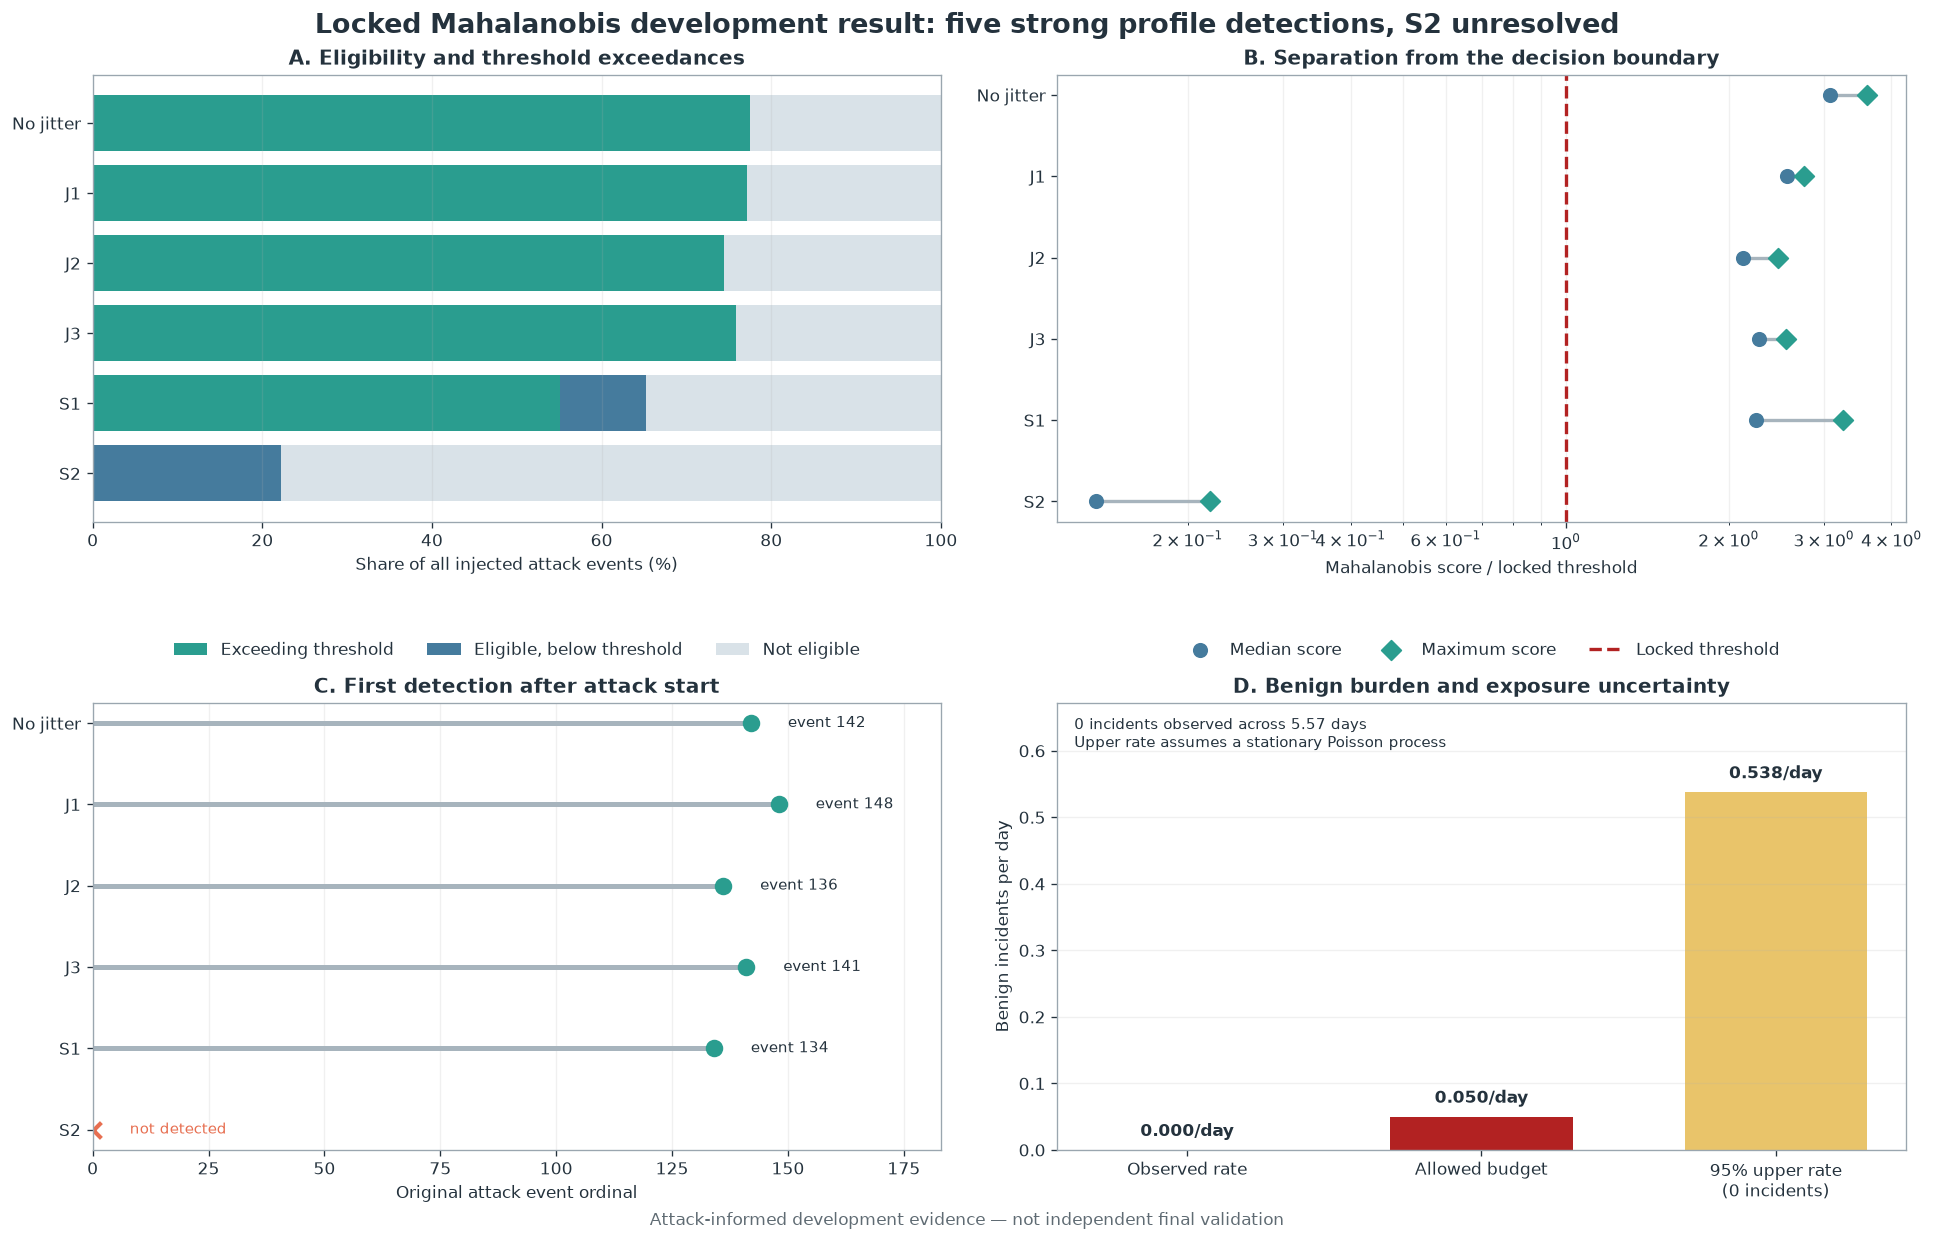

In [26]:
# ============================================================
# RESULTS VISUALIZATION 2 — PROFILE OUTCOMES AND OPERATING POINT
# ============================================================

_RESULTS_COLORS = {
    "detected": "#2A9D8F",
    "missed": "#E76F51",
    "eligible": "#457B9D",
    "unscored": "#D9E2E8",
    "benign": "#264653",
    "threshold": "#B22222",
    "accent": "#E9C46A",
    "text": "#24323D",
}
_RESULTS_RC = {
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#9AA6AF",
    "axes.labelcolor": _RESULTS_COLORS["text"],
    "xtick.color": _RESULTS_COLORS["text"],
    "ytick.color": _RESULTS_COLORS["text"],
    "text.color": _RESULTS_COLORS["text"],
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
}


def _results_save_show(
    figure,
    filename: str,
) -> Path:
    path = RESULTS_PLOT_DIR / filename
    figure.savefig(
        path,
        dpi=200,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
    return path


_profile_records = {
    row["attack_profile"]: row
    for row in results_profile_summary.to_dicts()
}
_profile_labels = [
    RESULTS_PROFILE_LABELS[p]
    for p in RESULTS_PROFILE_ORDER
]
_y = np.arange(len(RESULTS_PROFILE_ORDER))

with plt.rc_context(_RESULTS_RC):
    _figure, _axes = plt.subplots(
        2,
        2,
        figsize=(16, 10),
        constrained_layout=True,
    )

    # A — Every attack event is shown as exceeding, eligible but
    # not exceeding, or not yet eligible for the 64+64 history.
    _total = np.asarray(
        [
            _profile_records[p]["total_attack_events"]
            for p in RESULTS_PROFILE_ORDER
        ],
        dtype=float,
    )
    _exceed = np.asarray(
        [
            _profile_records[p][
                "attack_exceedance_count"
            ]
            for p in RESULTS_PROFILE_ORDER
        ],
        dtype=float,
    )
    _eligible_nonexceed = np.asarray(
        [
            _profile_records[p][
                "eligible_not_exceeding_windows"
            ]
            for p in RESULTS_PROFILE_ORDER
        ],
        dtype=float,
    )
    _unscored = np.asarray(
        [
            _profile_records[p][
                "unscored_attack_events"
            ]
            for p in RESULTS_PROFILE_ORDER
        ],
        dtype=float,
    )
    _exceed_pct_total = 100.0 * _exceed / _total
    _eligible_nonexceed_pct = (
        100.0 * _eligible_nonexceed / _total
    )
    _unscored_pct = 100.0 * _unscored / _total
    _axes[0, 0].barh(
        _y,
        _exceed_pct_total,
        color=_RESULTS_COLORS["detected"],
        label="Exceeding threshold",
    )
    _axes[0, 0].barh(
        _y,
        _eligible_nonexceed_pct,
        left=_exceed_pct_total,
        color=_RESULTS_COLORS["eligible"],
        label="Eligible, below threshold",
    )
    _axes[0, 0].barh(
        _y,
        _unscored_pct,
        left=(
            _exceed_pct_total
            + _eligible_nonexceed_pct
        ),
        color=_RESULTS_COLORS["unscored"],
        label="Not eligible",
    )
    _axes[0, 0].set_yticks(
        _y,
        labels=_profile_labels,
    )
    _axes[0, 0].invert_yaxis()
    _axes[0, 0].set_xlim(0, 100)
    _axes[0, 0].set_xlabel(
        "Share of all injected attack events (%)"
    )
    _axes[0, 0].set_title(
        "A. Eligibility and threshold exceedances"
    )
    _axes[0, 0].grid(
        axis="x",
        alpha=0.18,
    )
    _axes[0, 0].legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.34),
        ncol=3,
    )

    # B — Normalize scores by the threshold. Values above 1 are
    # anomalous under the locked operating point.
    _median_ratio = np.asarray(
        [
            _profile_records[p][
                "median_score_to_threshold"
            ]
            for p in RESULTS_PROFILE_ORDER
        ],
        dtype=float,
    )
    _maximum_ratio = np.asarray(
        [
            _profile_records[p][
                "maximum_score_to_threshold"
            ]
            for p in RESULTS_PROFILE_ORDER
        ],
        dtype=float,
    )
    for _index in range(len(_y)):
        _axes[0, 1].plot(
            [
                _median_ratio[_index],
                _maximum_ratio[_index],
            ],
            [_index, _index],
            color="#A7B4BD",
            linewidth=2,
            zorder=1,
        )
    _axes[0, 1].scatter(
        _median_ratio,
        _y,
        s=65,
        color=_RESULTS_COLORS["eligible"],
        label="Median score",
        zorder=3,
    )
    _axes[0, 1].scatter(
        _maximum_ratio,
        _y,
        s=70,
        marker="D",
        color=_RESULTS_COLORS["detected"],
        label="Maximum score",
        zorder=3,
    )
    _axes[0, 1].axvline(
        1.0,
        color=_RESULTS_COLORS["threshold"],
        linestyle="--",
        linewidth=2,
        label="Locked threshold",
    )
    _axes[0, 1].set_xscale("log")
    _axes[0, 1].set_yticks(
        _y,
        labels=_profile_labels,
    )
    _axes[0, 1].invert_yaxis()
    _axes[0, 1].set_xlabel(
        "Mahalanobis score / locked threshold"
    )
    _axes[0, 1].set_title(
        "B. Separation from the decision boundary"
    )
    _axes[0, 1].grid(
        axis="x",
        which="both",
        alpha=0.18,
    )
    _axes[0, 1].legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.34),
        ncol=3,
    )

    # C — Detection delay is expressed in original attack-event
    # order, including the warm-up required by the features.
    _delays = np.asarray(
        [
            (
                _profile_records[p][
                    "attack_events_to_detection"
                ]
                if _profile_records[p][
                    "profile_detected"
                ]
                else np.nan
            )
            for p in RESULTS_PROFILE_ORDER
        ],
        dtype=float,
    )
    _delay_colors = [
        (
            _RESULTS_COLORS["detected"]
            if np.isfinite(value)
            else _RESULTS_COLORS["missed"]
        )
        for value in _delays
    ]
    for _index, _value in enumerate(_delays):
        if np.isfinite(_value):
            _axes[1, 0].hlines(
                _index,
                0,
                _value,
                color="#A7B4BD",
                linewidth=3,
            )
            _axes[1, 0].scatter(
                _value,
                _index,
                s=90,
                color=_delay_colors[_index],
                zorder=3,
            )
            _axes[1, 0].text(
                _value + 8,
                _index,
                f"event {int(_value)}",
                va="center",
                fontsize=9,
            )
        else:
            _axes[1, 0].scatter(
                0,
                _index,
                s=90,
                marker="x",
                linewidth=2.5,
                color=_delay_colors[_index],
            )
            _axes[1, 0].text(
                8,
                _index,
                "not detected",
                va="center",
                fontsize=9,
                color=_RESULTS_COLORS["missed"],
            )
    _axes[1, 0].set_yticks(
        _y,
        labels=_profile_labels,
    )
    _axes[1, 0].invert_yaxis()
    _axes[1, 0].set_xlim(
        0,
        max(180, np.nanmax(_delays) + 35),
    )
    _axes[1, 0].set_xlabel(
        "Original attack event ordinal"
    )
    _axes[1, 0].set_title(
        "C. First detection after attack start"
    )
    _axes[1, 0].grid(
        axis="x",
        alpha=0.18,
    )

    # D — Zero observed incidents is shown together with the
    # exposure-limited upper bound. The bound assumes a stationary
    # Poisson incident process and is diagnostic, not a guarantee.
    _burden_labels = [
        "Observed rate",
        "Allowed budget",
        "95% upper rate\n(0 incidents)",
    ]
    _burden_values = [
        RESULTS_OBSERVED_INCIDENT_RATE,
        FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY,
        RESULTS_POISSON_UPPER_95_PER_DAY,
    ]
    _burden_colors = [
        _RESULTS_COLORS["detected"],
        _RESULTS_COLORS["threshold"],
        _RESULTS_COLORS["accent"],
    ]
    _axes[1, 1].bar(
        _burden_labels,
        _burden_values,
        color=_burden_colors,
        width=0.62,
    )
    for _index, _value in enumerate(_burden_values):
        _axes[1, 1].text(
            _index,
            _value + 0.015,
            f"{_value:.3f}/day",
            ha="center",
            va="bottom",
            fontweight="bold",
        )
    _axes[1, 1].set_ylim(
        0,
        RESULTS_POISSON_UPPER_95_PER_DAY * 1.25,
    )
    _axes[1, 1].set_ylabel(
        "Benign incidents per day"
    )
    _axes[1, 1].set_title(
        "D. Benign burden and exposure uncertainty"
    )
    _axes[1, 1].grid(
        axis="y",
        alpha=0.18,
    )
    _axes[1, 1].text(
        0.02,
        0.97,
        (
            f"0 incidents observed across "
            f"{RESULTS_WALL_DAYS:.2f} days\n"
            "Upper rate assumes a stationary Poisson process"
        ),
        transform=_axes[1, 1].transAxes,
        va="top",
        fontsize=9,
    )

    _figure.suptitle(
        "Locked Mahalanobis development result: "
        "five strong profile detections, S2 unresolved",
        fontsize=16,
        fontweight="bold",
    )
    _figure.text(
        0.5,
        -0.015,
        (
            "Attack-informed development evidence — "
            "not independent final validation"
        ),
        ha="center",
        fontsize=10,
        color="#5F6B73",
    )

_plot_03_path = _results_save_show(
    _figure,
    "plot_03_profile_outcomes.png",
)


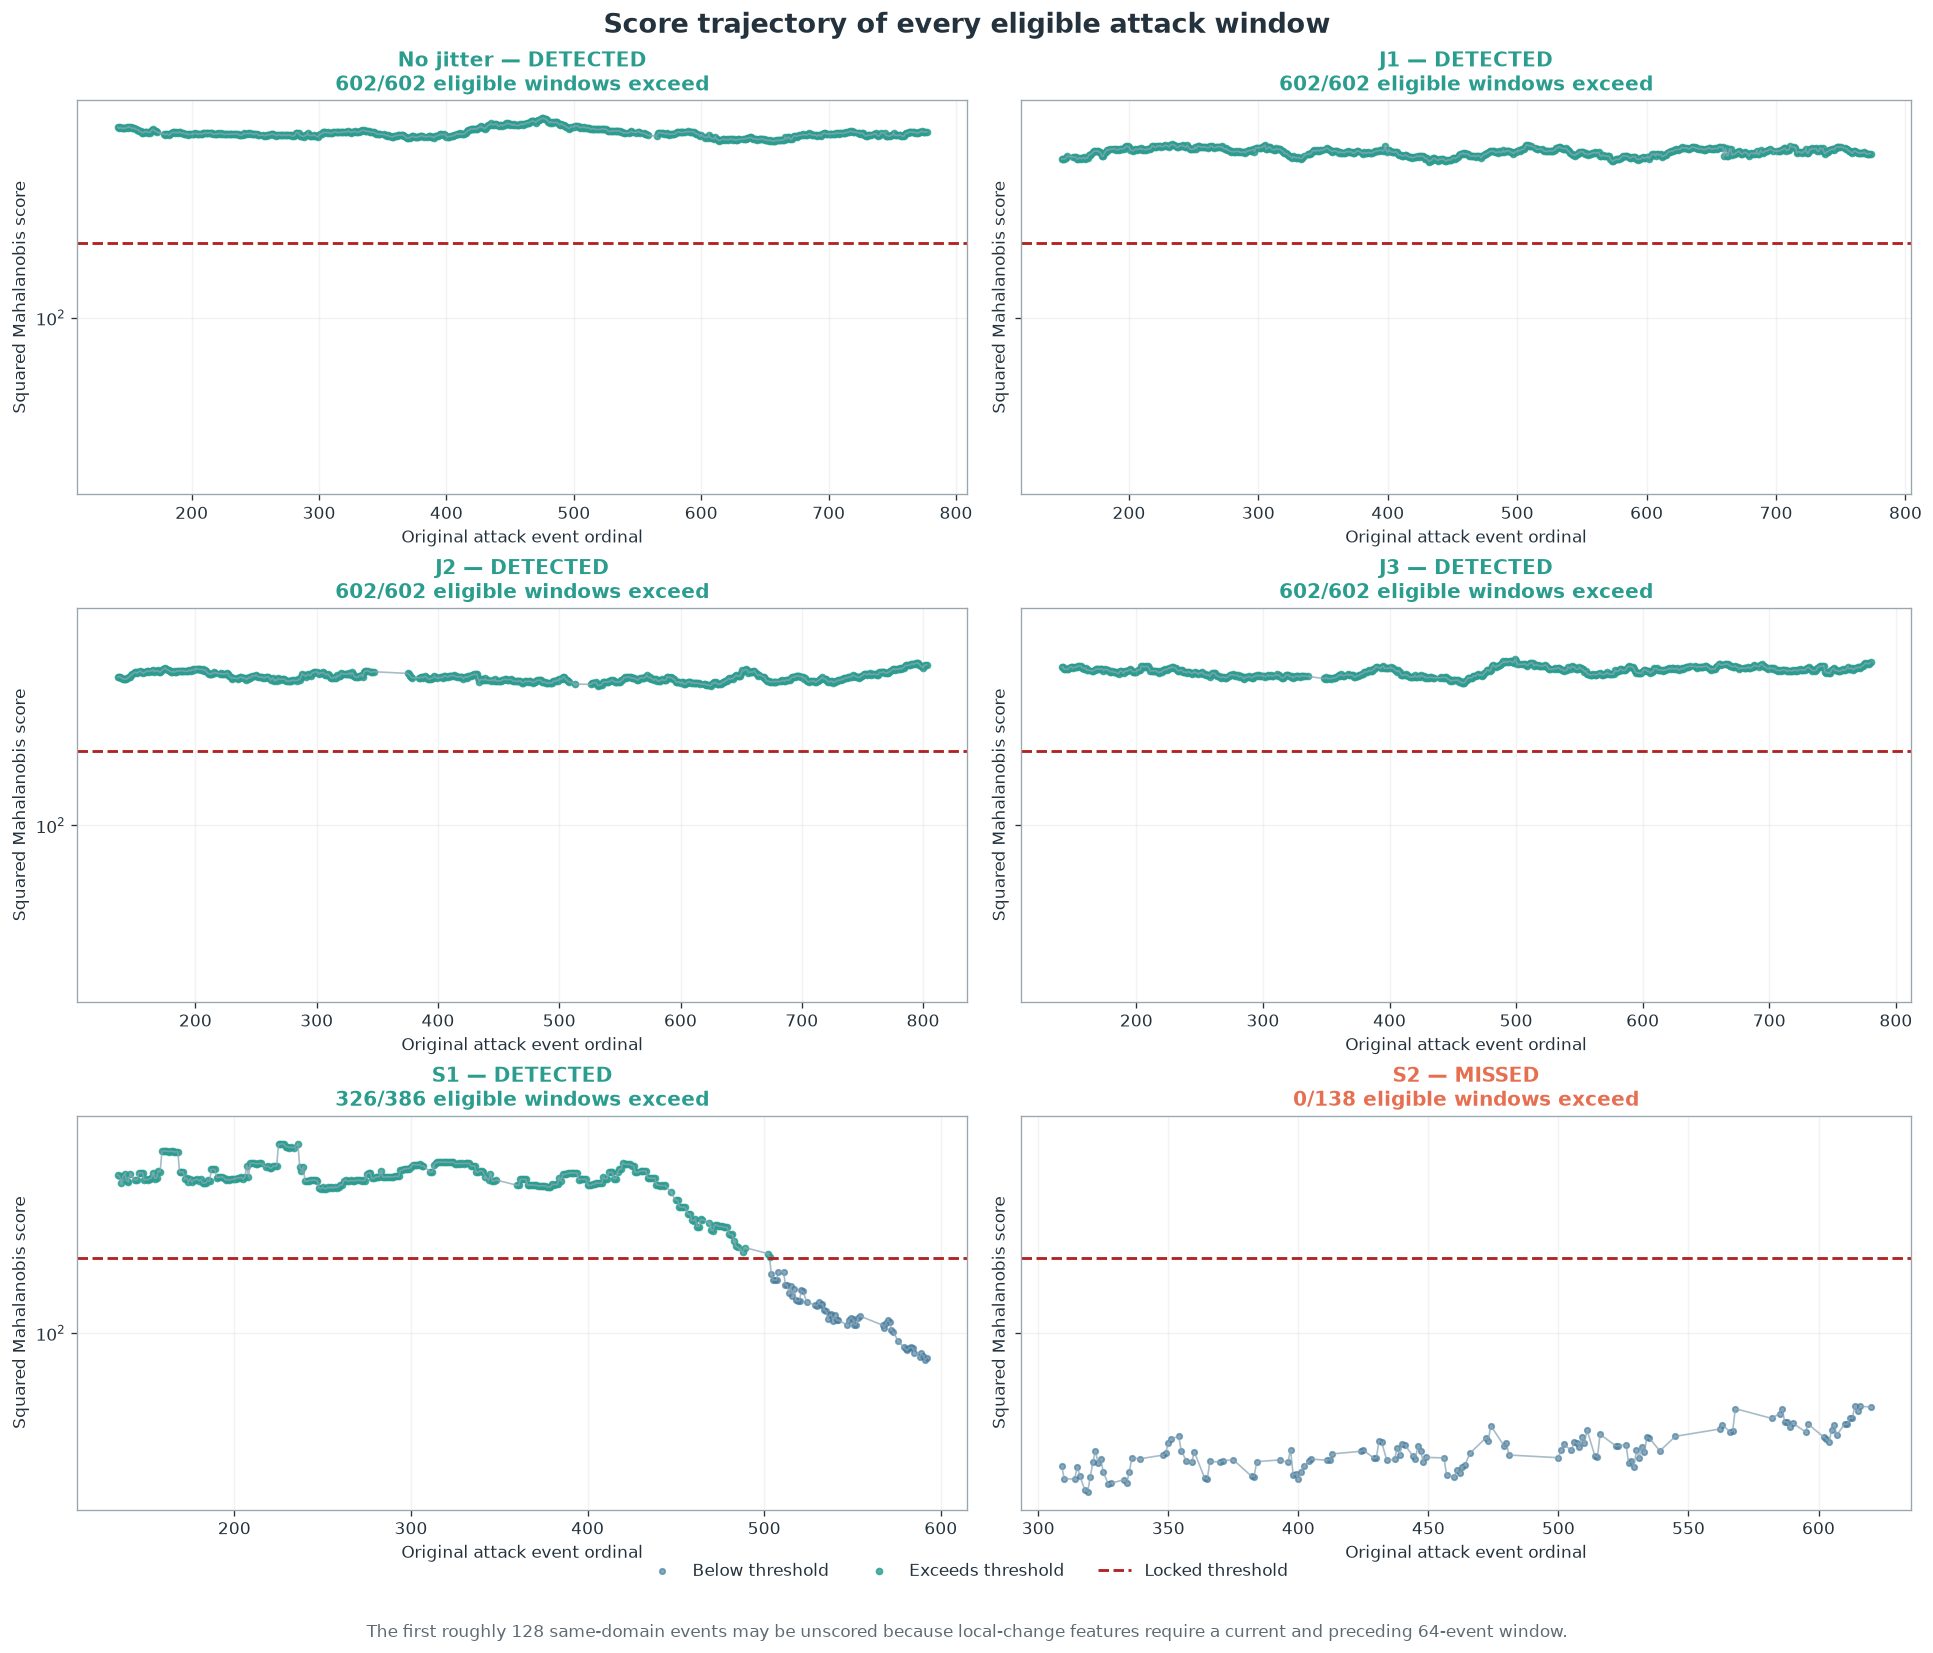

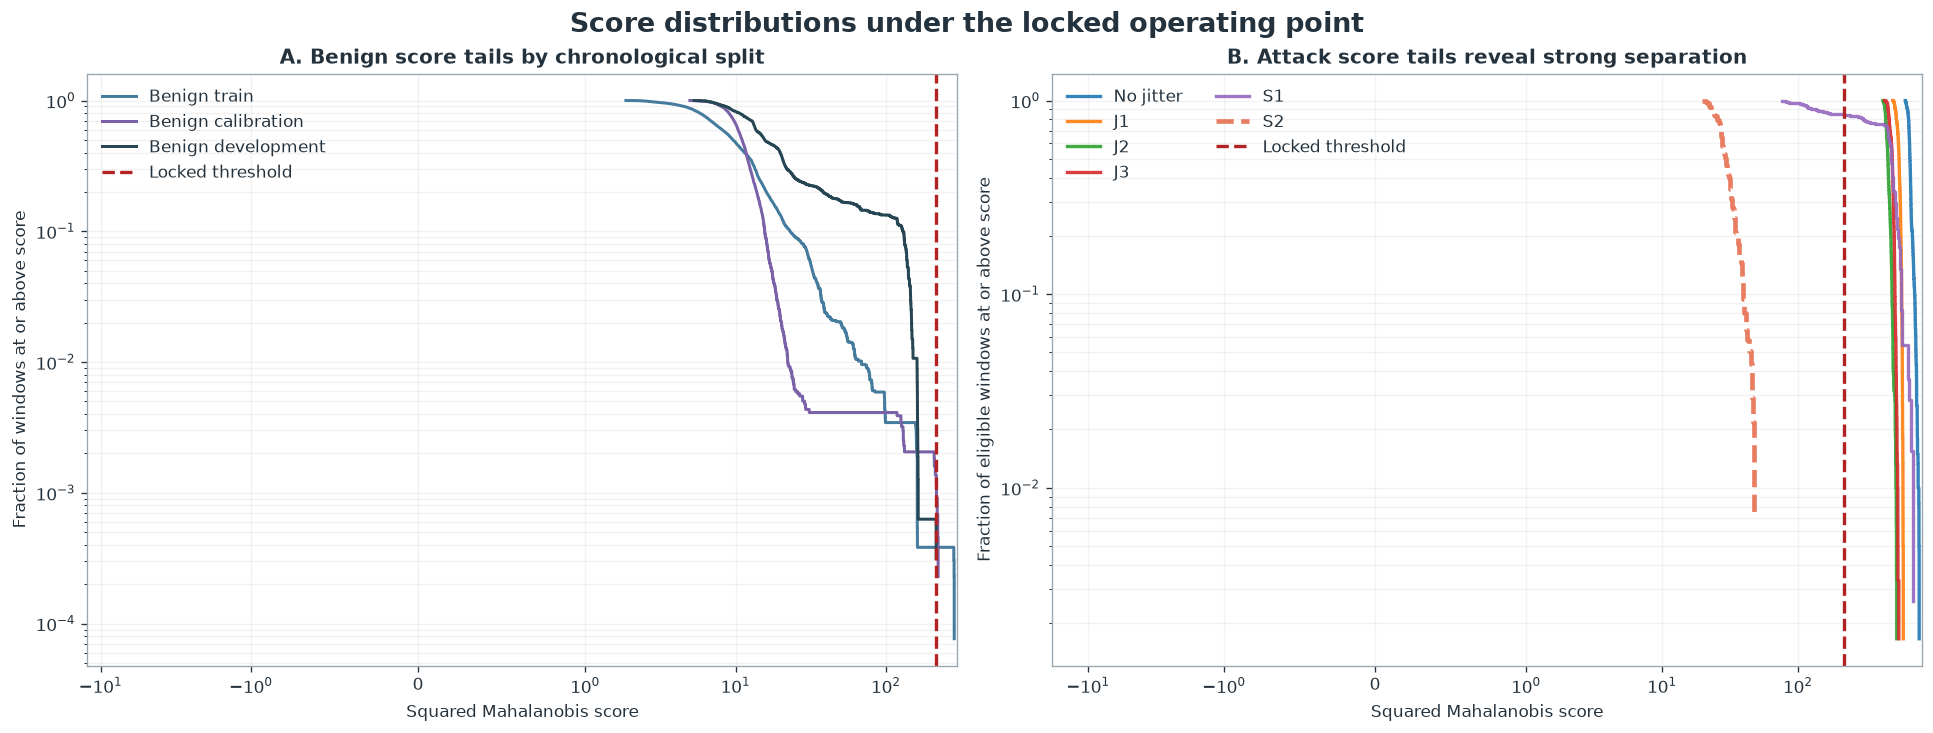

In [27]:
# ============================================================
# RESULTS VISUALIZATION 3 — SCORE TRAJECTORIES AND DISTRIBUTIONS
# ============================================================

with plt.rc_context(_RESULTS_RC):
    _figure, _axes = plt.subplots(
        3,
        2,
        figsize=(16, 13),
        sharey=True,
        constrained_layout=True,
    )
    for _axis, _profile in zip(
        _axes.flat,
        RESULTS_PROFILE_ORDER,
    ):
        _frame = (
            results_attack_scored
            .filter(
                pl.col("attack_profile")
                == _profile
            )
            .sort(
                [
                    "_attack_event_ordinal",
                    "event_time",
                    "_source_row",
                ],
                maintain_order=True,
            )
        )
        _x = _frame[
            "_attack_event_ordinal"
        ].to_numpy()
        _score = _frame[
            "mahalanobis_score"
        ].to_numpy()
        _flag = _frame[
            "is_threshold_exceedance"
        ].to_numpy()
        _axis.plot(
            _x,
            _score,
            color="#8BA6B5",
            linewidth=1.0,
            alpha=0.75,
        )
        _axis.scatter(
            _x[~_flag],
            _score[~_flag],
            s=11,
            color=_RESULTS_COLORS["eligible"],
            alpha=0.65,
            label="Below threshold",
        )
        _axis.scatter(
            _x[_flag],
            _score[_flag],
            s=13,
            color=_RESULTS_COLORS["detected"],
            alpha=0.8,
            label="Exceeds threshold",
        )
        _axis.axhline(
            RESULTS_THRESHOLD,
            color=_RESULTS_COLORS["threshold"],
            linestyle="--",
            linewidth=1.7,
            label="Locked threshold",
        )
        _result = _profile_records[_profile]
        _status = (
            "DETECTED"
            if _result["profile_detected"]
            else "MISSED"
        )
        _status_color = (
            _RESULTS_COLORS["detected"]
            if _result["profile_detected"]
            else _RESULTS_COLORS["missed"]
        )
        _axis.set_title(
            (
                f"{RESULTS_PROFILE_LABELS[_profile]} — "
                f"{_status}\n"
                f"{int(_result['attack_exceedance_count'])}/"
                f"{int(_result['scored_attack_windows'])} "
                "eligible windows exceed"
            ),
            color=_status_color,
        )
        _axis.set_yscale(
            "symlog",
            linthresh=1.0,
        )
        _axis.set_xlabel(
            "Original attack event ordinal"
        )
        _axis.set_ylabel(
            "Squared Mahalanobis score"
        )
        _axis.grid(
            alpha=0.16,
            which="both",
        )
    _handles, _labels = _axes.flat[0].get_legend_handles_labels()
    _figure.legend(
        _handles,
        _labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.018),
    )
    _figure.suptitle(
        "Score trajectory of every eligible attack window",
        fontsize=16,
        fontweight="bold",
    )
    _figure.text(
        0.5,
        -0.045,
        (
            "The first roughly 128 same-domain events may be "
            "unscored because local-change features require a "
            "current and preceding 64-event window."
        ),
        ha="center",
        fontsize=10,
        color="#5F6B73",
    )
_plot_04_path = _results_save_show(
    _figure,
    "plot_04_attack_score_trajectories.png",
)

with plt.rc_context(_RESULTS_RC):
    _figure, _axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        constrained_layout=True,
    )

    # Survival curves show the fraction of windows scoring above
    # each x value. This makes the upper tail and threshold visible.
    for _split_name, _label, _color in [
        ("train", "Benign train", "#457B9D"),
        (
            "calibration",
            "Benign calibration",
            "#7B61A8",
        ),
        (
            "development_validation",
            "Benign development",
            _RESULTS_COLORS["benign"],
        ),
    ]:
        _values = np.sort(
            _results_benign_scores[_split_name]
        )
        _survival = (
            np.arange(
                _values.size,
                0,
                -1,
            )
            / _values.size
        )
        _axes[0].step(
            _values,
            _survival,
            where="post",
            label=_label,
            color=_color,
            linewidth=1.8,
        )
    _axes[0].axvline(
        RESULTS_THRESHOLD,
        color=_RESULTS_COLORS["threshold"],
        linestyle="--",
        linewidth=2,
        label="Locked threshold",
    )
    _axes[0].set_xscale("symlog", linthresh=1.0)
    _axes[0].set_yscale("log")
    _axes[0].set_xlabel(
        "Squared Mahalanobis score"
    )
    _axes[0].set_ylabel(
        "Fraction of windows at or above score"
    )
    _axes[0].set_title(
        "A. Benign score tails by chronological split"
    )
    _axes[0].grid(
        alpha=0.16,
        which="both",
    )
    _axes[0].legend()

    for _profile in RESULTS_PROFILE_ORDER:
        _values = np.sort(
            results_attack_scored
            .filter(
                pl.col("attack_profile")
                == _profile
            )["mahalanobis_score"]
            .to_numpy()
        )
        _survival = (
            np.arange(
                _values.size,
                0,
                -1,
            )
            / _values.size
        )
        _is_detected = bool(
            _profile_records[_profile][
                "profile_detected"
            ]
        )
        _axes[1].step(
            _values,
            _survival,
            where="post",
            label=RESULTS_PROFILE_LABELS[_profile],
            linewidth=(
                2.0 if _is_detected else 2.8
            ),
            linestyle=(
                "-" if _is_detected else "--"
            ),
            color=(
                None
                if _is_detected
                else _RESULTS_COLORS["missed"]
            ),
            alpha=0.9,
        )
    _axes[1].axvline(
        RESULTS_THRESHOLD,
        color=_RESULTS_COLORS["threshold"],
        linestyle="--",
        linewidth=2,
        label="Locked threshold",
    )
    _axes[1].set_xscale("symlog", linthresh=1.0)
    _axes[1].set_yscale("log")
    _axes[1].set_xlabel(
        "Squared Mahalanobis score"
    )
    _axes[1].set_ylabel(
        "Fraction of eligible windows at or above score"
    )
    _axes[1].set_title(
        "B. Attack score tails reveal strong separation"
    )
    _axes[1].grid(
        alpha=0.16,
        which="both",
    )
    _axes[1].legend(
        ncol=2,
    )

    _figure.suptitle(
        "Score distributions under the locked operating point",
        fontsize=16,
        fontweight="bold",
    )
_plot_05_path = _results_save_show(
    _figure,
    "plot_05_score_distributions.png",
)


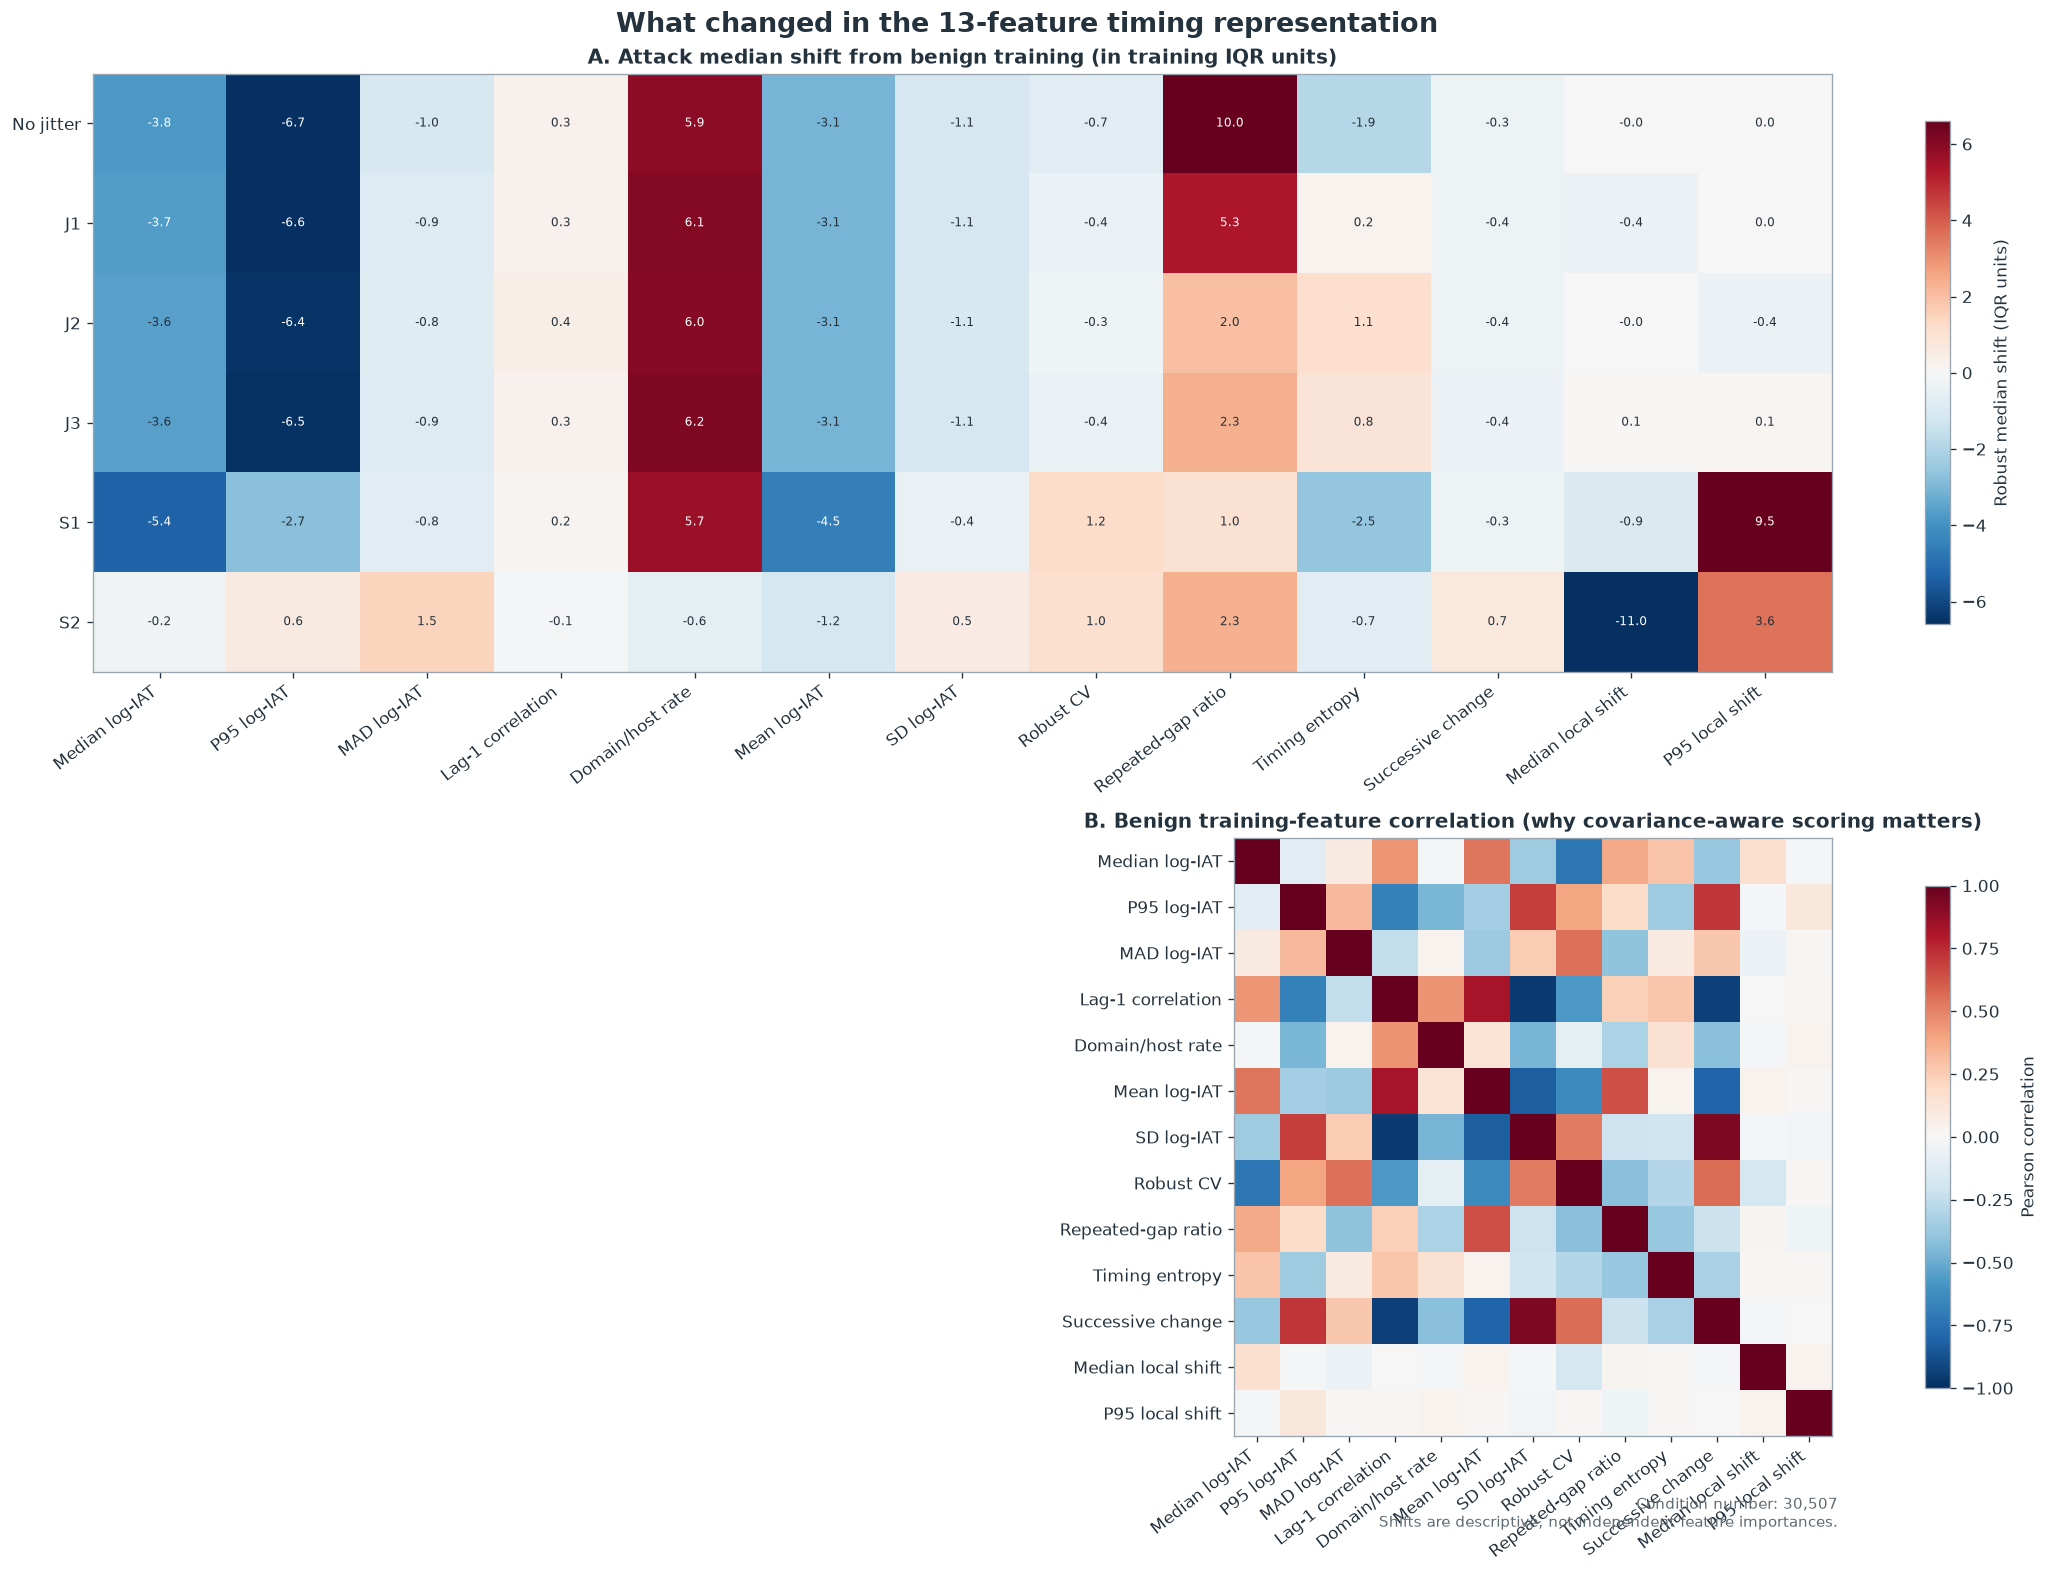

In [28]:
# ============================================================
# RESULTS VISUALIZATION 4 — FEATURE SHIFTS AND DEPENDENCE
# ============================================================

_feature_short_labels = {
    "log_iat_median": "Median log-IAT",
    "log_iat_p95": "P95 log-IAT",
    "log_iat_mad": "MAD log-IAT",
    "log_iat_lag1_autocorrelation": "Lag-1 correlation",
    "domain_host_rate_ratio": "Domain/host rate",
    "log_iat_mean": "Mean log-IAT",
    "log_iat_std": "SD log-IAT",
    "robust_log_iat_cv": "Robust CV",
    "repeated_gap_ratio_5pct": "Repeated-gap ratio",
    "normalized_iat_entropy_8": "Timing entropy",
    "median_abs_successive_log_iat_change": (
        "Successive change"
    ),
    "delta_log_iat_median_vs_previous_window": (
        "Median local shift"
    ),
    "delta_log_iat_p95_vs_previous_window": (
        "P95 local shift"
    ),
}
_feature_labels = [
    _feature_short_labels[name]
    for name in RESULTS_FEATURES
]

# Robust shifts use training median/IQR coordinates. They explain
# which inputs moved, but they are not independent feature
# importances because Mahalanobis scoring includes covariance.
_feature_shift_rows = []
_feature_shift_matrix = []
for _profile in RESULTS_PROFILE_ORDER:
    _profile_raw = np.asarray(
        results_attack_scored
        .filter(
            pl.col("attack_profile")
            == _profile
        )
        .select(RESULTS_FEATURES)
        .to_numpy(),
        dtype=np.float64,
    )
    _shift = (
        np.median(_profile_raw, axis=0)
        - RESULTS_TRAIN_MEDIANS
    ) / RESULTS_TRAIN_SCALES
    _feature_shift_matrix.append(_shift)
    for _feature_name, _value in zip(
        RESULTS_FEATURES,
        _shift,
    ):
        _feature_shift_rows.append(
            {
                "attack_profile": _profile,
                "feature_name": _feature_name,
                "robust_median_shift_iqr": float(
                    _value
                ),
            }
        )
_feature_shift_matrix = np.asarray(
    _feature_shift_matrix,
    dtype=float,
)
results_feature_shift_summary = pl.DataFrame(
    _feature_shift_rows,
    infer_schema_length=None,
)
_results_feature_shift_path = (
    RESULTS_PLOT_DIR
    / "12_results_feature_shifts.csv"
)
results_feature_shift_summary.write_csv(
    _results_feature_shift_path
)

_training_correlation = np.corrcoef(
    _results_scaled_arrays["train"],
    rowvar=False,
)
_training_correlation = np.nan_to_num(
    _training_correlation,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

with plt.rc_context(_RESULTS_RC):
    _figure, _axes = plt.subplots(
        2,
        1,
        figsize=(17, 13),
        constrained_layout=True,
    )

    _shift_limit = max(
        2.0,
        float(
            np.nanpercentile(
                np.abs(_feature_shift_matrix),
                95,
            )
        ),
    )
    _shift_limit = min(_shift_limit, 12.0)
    _image = _axes[0].imshow(
        np.clip(
            _feature_shift_matrix,
            -_shift_limit,
            _shift_limit,
        ),
        aspect="auto",
        cmap="RdBu_r",
        vmin=-_shift_limit,
        vmax=_shift_limit,
    )
    _axes[0].set_xticks(
        np.arange(len(_feature_labels)),
        labels=_feature_labels,
        rotation=38,
        ha="right",
    )
    _axes[0].set_yticks(
        np.arange(len(RESULTS_PROFILE_ORDER)),
        labels=[
            RESULTS_PROFILE_LABELS[p]
            for p in RESULTS_PROFILE_ORDER
        ],
    )
    _axes[0].set_title(
        "A. Attack median shift from benign training "
        "(in training IQR units)"
    )
    _colorbar = _figure.colorbar(
        _image,
        ax=_axes[0],
        shrink=0.84,
    )
    _colorbar.set_label(
        "Robust median shift (IQR units)"
    )
    for _row in range(
        _feature_shift_matrix.shape[0]
    ):
        for _column in range(
            _feature_shift_matrix.shape[1]
        ):
            _value = _feature_shift_matrix[
                _row,
                _column,
            ]
            _axes[0].text(
                _column,
                _row,
                f"{_value:.1f}",
                ha="center",
                va="center",
                fontsize=7,
                color=(
                    "white"
                    if abs(_value)
                    > 0.55 * _shift_limit
                    else "#25313A"
                ),
            )

    _corr_image = _axes[1].imshow(
        _training_correlation,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
    )
    _axes[1].set_xticks(
        np.arange(len(_feature_labels)),
        labels=_feature_labels,
        rotation=38,
        ha="right",
    )
    _axes[1].set_yticks(
        np.arange(len(_feature_labels)),
        labels=_feature_labels,
    )
    _axes[1].set_title(
        "B. Benign training-feature correlation "
        "(why covariance-aware scoring matters)"
    )
    _corr_colorbar = _figure.colorbar(
        _corr_image,
        ax=_axes[1],
        shrink=0.84,
    )
    _corr_colorbar.set_label("Pearson correlation")
    _axes[1].text(
        1.01,
        -0.10,
        (
            "Condition number: "
            f"{float(_results_summary_row['condition_number']):,.0f}\n"
            "Shifts are descriptive, not independent "
            "feature importances."
        ),
        transform=_axes[1].transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="#5F6B73",
    )

    _figure.suptitle(
        "What changed in the 13-feature timing representation",
        fontsize=16,
        fontweight="bold",
    )
_plot_06_path = _results_save_show(
    _figure,
    "plot_06_feature_explanations.png",
)


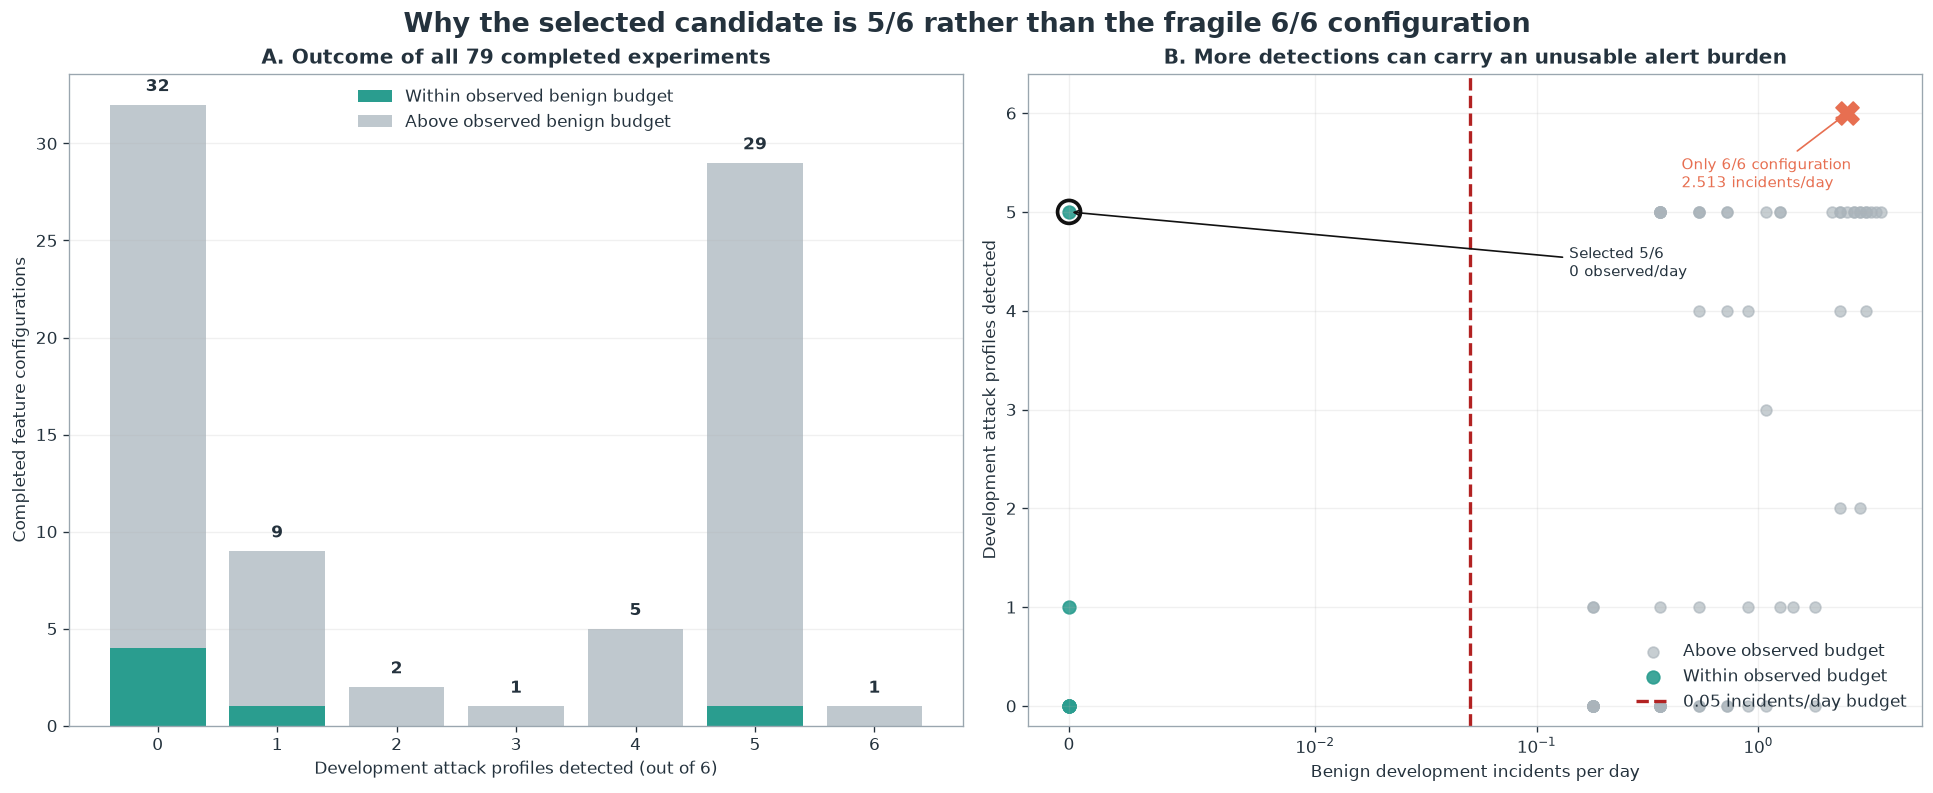

In [29]:
# ============================================================
# RESULTS VISUALIZATION 5 — DEVELOPMENT SEARCH LANDSCAPE
# ============================================================

_landscape = mahalanobis_feature_leaderboard
_landscape_records = _landscape.to_dicts()
_detected_values = np.arange(7)
_pass_counts = []
_fail_counts = []
for _detected_count in _detected_values:
    _subset = _landscape.filter(
        pl.col("detected_attack_profiles")
        == int(_detected_count)
    )
    _pass_counts.append(
        int(
            _subset.filter(
                pl.col("benign_budget_pass")
            ).height
        )
    )
    _fail_counts.append(
        int(
            _subset.filter(
                ~pl.col("benign_budget_pass")
            ).height
        )
    )

_six_of_six = _landscape.filter(
    pl.col("detected_attack_profiles") == 6
)
if _six_of_six.height != 1:
    raise RuntimeError(
        "Expected exactly one 6/6 development configuration."
    )
_six_of_six_row = _six_of_six.row(0, named=True)

with plt.rc_context(_RESULTS_RC):
    _figure, _axes = plt.subplots(
        1,
        2,
        figsize=(16, 6.5),
        constrained_layout=True,
    )
    _axes[0].bar(
        _detected_values,
        _pass_counts,
        color=_RESULTS_COLORS["detected"],
        label="Within observed benign budget",
    )
    _axes[0].bar(
        _detected_values,
        _fail_counts,
        bottom=_pass_counts,
        color="#BFC8CE",
        label="Above observed benign budget",
    )
    for _index, (_passed, _failed) in enumerate(
        zip(_pass_counts, _fail_counts)
    ):
        _total_count = _passed + _failed
        if _total_count:
            _axes[0].text(
                _index,
                _total_count + 0.7,
                str(_total_count),
                ha="center",
                fontweight="bold",
            )
    _axes[0].set_xticks(_detected_values)
    _axes[0].set_xlabel(
        "Development attack profiles detected (out of 6)"
    )
    _axes[0].set_ylabel(
        "Completed feature configurations"
    )
    _axes[0].set_title(
        "A. Outcome of all 79 completed experiments"
    )
    _axes[0].grid(
        axis="y",
        alpha=0.18,
    )
    _axes[0].legend()

    _budget_pass = np.asarray(
        [
            bool(row["benign_budget_pass"])
            for row in _landscape_records
        ]
    )
    _x = np.asarray(
        [
            float(
                row[
                    "development_incidents_per_day"
                ]
            )
            for row in _landscape_records
        ]
    )
    _y_landscape = np.asarray(
        [
            int(row["detected_attack_profiles"])
            for row in _landscape_records
        ]
    )
    _axes[1].scatter(
        _x[~_budget_pass],
        _y_landscape[~_budget_pass],
        s=42,
        color="#AAB4BB",
        alpha=0.65,
        label="Above observed budget",
    )
    _axes[1].scatter(
        _x[_budget_pass],
        _y_landscape[_budget_pass],
        s=58,
        color=_RESULTS_COLORS["detected"],
        alpha=0.9,
        label="Within observed budget",
    )
    _axes[1].axvline(
        FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY,
        color=_RESULTS_COLORS["threshold"],
        linestyle="--",
        linewidth=2,
        label="0.05 incidents/day budget",
    )
    _axes[1].scatter(
        RESULTS_OBSERVED_INCIDENT_RATE,
        5,
        s=190,
        facecolor="none",
        edgecolor="#111111",
        linewidth=2.2,
        zorder=5,
    )
    _axes[1].annotate(
        "Selected 5/6\n0 observed/day",
        xy=(RESULTS_OBSERVED_INCIDENT_RATE, 5),
        xytext=(0.14, 4.35),
        arrowprops={
            "arrowstyle": "->",
            "color": "#111111",
        },
        fontsize=9,
    )
    _six_burden = float(
        _six_of_six_row[
            "development_incidents_per_day"
        ]
    )
    _axes[1].scatter(
        _six_burden,
        6,
        s=190,
        marker="X",
        color=_RESULTS_COLORS["missed"],
        zorder=5,
    )
    _axes[1].annotate(
        (
            "Only 6/6 configuration\n"
            f"{_six_burden:.3f} incidents/day"
        ),
        xy=(_six_burden, 6),
        xytext=(0.45, 5.25),
        arrowprops={
            "arrowstyle": "->",
            "color": _RESULTS_COLORS["missed"],
        },
        fontsize=9,
        color=_RESULTS_COLORS["missed"],
    )
    _axes[1].set_xscale(
        "symlog",
        linthresh=0.01,
    )
    _axes[1].set_ylim(-0.2, 6.4)
    _axes[1].set_xlabel(
        "Benign development incidents per day"
    )
    _axes[1].set_ylabel(
        "Development attack profiles detected"
    )
    _axes[1].set_title(
        "B. More detections can carry an unusable alert burden"
    )
    _axes[1].grid(
        alpha=0.18,
        which="both",
    )
    _axes[1].legend(
        loc="lower right",
    )
    _figure.suptitle(
        "Why the selected candidate is 5/6 rather than the "
        "fragile 6/6 configuration",
        fontsize=16,
        fontweight="bold",
    )
_plot_07_path = _results_save_show(
    _figure,
    "plot_07_search_landscape.png",
)


In [30]:
# ============================================================
# RESULTS VISUALIZATION 6 — INTEGRITY GATES AND RESULT BUNDLE
# ============================================================

_results_plot_paths = [
    _plot_03_path,
    _plot_04_path,
    _plot_05_path,
    _plot_06_path,
    _plot_07_path,
]
_results_plot_paths_existing = [
    RESULTS_PLOT_DIR
    / "plot_01_mahalanobis_feature_leaderboard.png",
    RESULTS_PLOT_DIR
    / "plot_02_feature_tradeoff.png",
]
_results_gate_rows = [
    _feature_lab_gate(
        "locked candidate identity unchanged",
        RESULTS_CANDIDATE_ID
        == (
            "w64__baseline+regularity+local_change__"
            "64fd5af306"
        ),
        RESULTS_CANDIDATE_ID,
    ),
    _feature_lab_gate(
        "locked threshold reconstructed exactly",
        np.isclose(
            _results_reconstructed_threshold,
            RESULTS_THRESHOLD,
            rtol=1e-10,
            atol=1e-10,
        ),
        {
            "exported": RESULTS_THRESHOLD,
            "reconstructed": (
                _results_reconstructed_threshold
            ),
        },
    ),
    _feature_lab_gate(
        "five development profiles detected",
        len(_detected_profiles) == 5,
        _detected_profiles,
    ),
    _feature_lab_gate(
        "S2 is the only missed development profile",
        _missed_profiles == ["s2"],
        _missed_profiles,
    ),
    _feature_lab_gate(
        "zero observed benign development incidents retained",
        RESULTS_OBSERVED_INCIDENTS == 0,
        {
            "incidents": RESULTS_OBSERVED_INCIDENTS,
            "wall_days": RESULTS_WALL_DAYS,
        },
    ),
    _feature_lab_gate(
        "all score reconstructions match exported profiles",
        results_profile_summary.height == 6,
        (
            "window counts, exceedance counts, medians, "
            "maxima, and threshold checked profile by profile"
        ),
    ),
    _feature_lab_gate(
        "all five new result figures were written",
        all(
            path.exists()
            and path.stat().st_size > 0
            for path in _results_plot_paths
        ),
        [str(path) for path in _results_plot_paths],
    ),
    _feature_lab_gate(
        "development status remains explicit",
        bool(
            _results_summary_row["development_only"]
            and _results_summary_row[
                "final_holdout_required"
            ]
        ),
        (
            "attack-informed development; fresh benign "
            "and attack holdouts required"
        ),
    ),
]
results_visualization_integrity_gates = pl.DataFrame(
    _results_gate_rows,
    infer_schema_length=None,
)
_all_results_visualization_gates_pass = bool(
    results_visualization_integrity_gates.select(
        (pl.col("status") == "PASS").all()
    ).item()
)
_results_gates_path = (
    RESULTS_PLOT_DIR
    / "13_results_visualization_integrity_gates.csv"
)
results_visualization_integrity_gates.write_csv(
    _results_gates_path
)

_results_readme = f"""# Mahalanobis Results Visualization

## Confirmed development finding

- Candidate: `{RESULTS_CANDIDATE_ID}`
- Window: `{RESULTS_WINDOW_SIZE}` same-parent-domain events
- Features: `{len(RESULTS_FEATURES)}`
- Locked threshold: `{RESULTS_THRESHOLD:.12f}`
- Detected development profiles: `{", ".join(_detected_profiles)}`
- Missed development profile: `{", ".join(_missed_profiles)}`
- Profile-level development detection: `5/6`
- Observed benign development incidents: `{RESULTS_OBSERVED_INCIDENTS}`
- Benign development exposure: `{RESULTS_WALL_DAYS:.6f}` days
- Observed benign incidents/day: `{RESULTS_OBSERVED_INCIDENT_RATE:.6f}`
- Poisson one-sided 95% upper rate after zero observed incidents:
  `{RESULTS_POISSON_UPPER_95_PER_DAY:.6f}` incidents/day

## Interpretation

The four jitter attacks produce strong score separation: every eligible
attack window exceeds the locked threshold. S1 produces many
exceedances, but this does not by itself prove pair-order mechanism
detection. S2 is not a near miss: its maximum score remains well below
threshold and only a minority of its events become eligible.

## Scientific boundary

These six attack captures influenced feature selection. This is
attack-informed development evidence, not independent final validation.
Fresh benign and attack holdouts are required before reporting final
performance.

## Figures

- `plot_03_profile_outcomes.png`: eligibility, score separation,
  detection delay, and benign-rate uncertainty.
- `plot_04_attack_score_trajectories.png`: every eligible attack-window
  score in chronological attack order.
- `plot_05_score_distributions.png`: benign and attack upper-tail score
  distributions.
- `plot_06_feature_explanations.png`: robust feature shifts and benign
  feature dependence.
- `plot_07_search_landscape.png`: all 79 experiments and the sensitivity
  versus benign-burden trade-off.
"""
_results_readme_path = (
    RESULTS_PLOT_DIR
    / "RESULTS_VISUALIZATION_README.md"
)
_results_readme_path.write_text(
    _results_readme,
    encoding="utf-8",
)

_results_bundle_path = (
    RESULTS_PLOT_DIR
    / (
        "dns_feature_laboratory_results_visualization_"
        "bundle_v1_1_0.zip"
    )
)
_results_bundle_members = [
    _results_profile_csv_path,
    _results_feature_shift_path,
    _results_gates_path,
    _results_readme_path,
    RESULTS_PLOT_DIR / "09_development_candidate.csv",
    RESULTS_PLOT_DIR / "10_final_integrity_gates.csv",
]
_results_bundle_members.extend(
    [
        path
        for path in _results_plot_paths_existing
        if path.exists()
    ]
)
_results_bundle_members.extend(_results_plot_paths)
with zipfile.ZipFile(
    _results_bundle_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as _archive:
    for _path in _results_bundle_members:
        if _path.exists():
            _archive.write(
                _path,
                arcname=_path.name,
            )

display(results_visualization_integrity_gates)
print(
    "RESULTS VISUALIZATION — "
    f"{'PASS' if _all_results_visualization_gates_pass else 'FAIL'}"
)
print(f"Results bundle: {_results_bundle_path}")
print(
    "Claim boundary: 5/6 attack-informed development "
    "profiles; independent final holdouts remain required."
)

if not _all_results_visualization_gates_pass:
    raise RuntimeError(
        "One or more results-visualization integrity "
        "gates failed."
    )


gate_name,status,observed
str,str,str
"""locked candidate identity unch…","""PASS""","""w64__baseline+regularity+local…"
"""locked threshold reconstructed…","""PASS""","""{'exported': 216.1402379283405…"
"""five development profiles dete…","""PASS""","""['no_jitter', 'j1', 'j2', 'j3'…"
"""S2 is the only missed developm…","""PASS""","""['s2']"""
"""zero observed benign developme…","""PASS""","""{'incidents': 0, 'wall_days': …"
"""all score reconstructions matc…","""PASS""","""window counts, exceedance coun…"
"""all five new result figures we…","""PASS""","""['/home/notevenknow/Desktop/ju…"
"""development status remains exp…","""PASS""","""attack-informed development; f…"


RESULTS VISUALIZATION — PASS
Results bundle: /home/notevenknow/Desktop/jupyter_lab/Data/outputs_dns_feature_laboratory_v1_0_0/dns_feature_laboratory_results_visualization_bundle_v1_1_0.zip
Claim boundary: 5/6 attack-informed development profiles; independent final holdouts remain required.


### Thesis-ready interpretation of the figures

The selected Mahalanobis candidate detects five of the six current
development attack profiles. The four jitter profiles are strongly
separated because **every eligible window** crosses the benign-calibrated
threshold. S1 also creates a sustained anomaly response, with 326 of 386
eligible windows exceeding the threshold. This is much stronger evidence
than a single accidental threshold crossing.

S2 remains genuinely unresolved. Only 138 of its 620 injected events
become eligible for the complete 64-event plus previous-window feature
vector, and none crosses the threshold. Its maximum score is about
`0.22 ×` the locked threshold, so it is not scientifically correct to
describe S2 as a near miss.

The benign development stream produced zero observed incidents across
5.57 days. That is encouraging, but it does not establish a true
false-alarm rate of zero. Under a simple stationary Poisson assumption,
zero incidents over this exposure still permits a one-sided 95% upper
rate of roughly `0.54 incidents/day`, which is above the intended
`0.05 incidents/day` budget. More untouched benign exposure is required.

The honest conclusion is therefore: **the attack-informed feature search
produced a useful and interpretable 5/6 development candidate, not a
final detector with 83.3% general accuracy.** The next scientific step
is to freeze this exact model and evaluate it once on fresh benign and
attack holdouts.


## Section 15 — Locked folder-driven attack evaluation

This section evaluates **any number of new Zeek DNS attack logs** without
changing the working detector selected above.

1. Put each new Zeek `dns.log` in
   `/home/notevenknow/Desktop/jupyter_lab/Data/attacks_to_evaluate/`.
2. Flat files and nested run directories are both supported. If the filename
   is literally `dns.log`, the parent-directory name becomes the profile name.
3. Zeek TSV and Zeek JSON-lines logs are detected automatically.
4. Every valid file is injected independently into the same frozen benign
   context; sessions, IATs, windows and features are recalculated after the
   raw-event merge.
5. The existing 13-feature Mahalanobis model and locked threshold are reused.
   New attack results never refit the model or select features.

Run the notebook through Section 14 once. After adding more attack logs, rerun
only Sections 15.1 and 15.2.


In [31]:
# ============================================================
# SECTION 15.1 — FOLDER DISCOVERY AND INPUT CONFIGURATION
# ============================================================

import hashlib
import re
from datetime import datetime, timezone
from pathlib import Path


LOCKED_BATCH_VERSION = "1.2.1"
NEW_ATTACKS_DIR = DATA / "attacks_to_evaluate"
NEW_ATTACKS_OUTPUT_ROOT = (
    DATA / "outputs_locked_attack_folder_v1_2_1"
)
# Ground-truth attribution only. This value is never a model input. Rows for
# other DNS names remain in the endpoint stream as captured benign context.
NEW_ATTACK_GROUND_TRUTH_DOMAIN = "timing.redlab.com"
NEW_ATTACKS_RUN_ID = datetime.now(timezone.utc).strftime(
    "run_%Y%m%dT%H%M%SZ"
)
NEW_ATTACKS_OUTPUT_DIR = (
    NEW_ATTACKS_OUTPUT_ROOT / NEW_ATTACKS_RUN_ID
)
NEW_ATTACKS_DIR.mkdir(parents=True, exist_ok=True)
NEW_ATTACKS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Both ordinary Zeek TSV dns.log and JSON-lines Zeek logs are accepted.
NEW_ATTACK_SUFFIXES = {".log", ".jsonl", ".ndjson"}

_folder_required_objects = [
    "RESULTS_CANDIDATE_ID",
    "RESULTS_WINDOW_SIZE",
    "RESULTS_FEATURES",
    "RESULTS_THRESHOLD",
    "RESULTS_TRAIN_MEDIANS",
    "RESULTS_TRAIN_SCALES",
    "RESULTS_FITTED_MODEL",
    "RESULTS_OBSERVED_INCIDENT_RATE",
    "benign_session_audit_events",
    "_injected_start_us",
    "_mapped_resolver_ip",
    "BENIGN_HOST_ID",
    "BENIGN_RESOLVER_PORT",
    "FROZEN_HOST_INACTIVITY_MINUTES",
    "_sessionize_benign",
    "_sessionized_feature_frames",
    "_restore_audit_source_file",
    "_build_multiwindow_features",
    "_all_finite_mask",
    "_score_squared_mahalanobis",
    "_normalize_fqdn_expr",
    "_domain_hierarchy_from_psl",
    "parse_zeek_log",
    "parse_jsonl_log",
]
_folder_missing_objects = [
    name for name in _folder_required_objects
    if name not in globals()
]
if _folder_missing_objects:
    raise RuntimeError(
        "Run the notebook through Section 14 first. "
        f"Missing objects: {_folder_missing_objects}"
    )


def _batch_profile_base(path: Path) -> str:
    """Create a readable profile name from a flat or nested dns.log path."""
    raw_name = (
        path.parent.name
        if path.name.lower() == "dns.log"
        else path.stem
    )
    raw_name = re.sub(
        r"^dns[_-]?", "", raw_name, flags=re.IGNORECASE
    )
    cleaned = re.sub(
        r"[^a-zA-Z0-9._-]+", "_", raw_name
    ).strip("._-")
    return (cleaned or "attack")[:80].lower()


_new_attack_paths = sorted(
    [
        path
        for path in NEW_ATTACKS_DIR.rglob("*")
        if path.is_file()
        and path.suffix.lower() in NEW_ATTACK_SUFFIXES
        and not any(part.startswith(".") for part in path.parts)
    ],
    key=lambda path: path.relative_to(NEW_ATTACKS_DIR).as_posix(),
)

_label_counts = {}
NEW_ATTACK_FILE_SPECS = []
for _path in _new_attack_paths:
    _relative_path = _path.relative_to(NEW_ATTACKS_DIR).as_posix()
    _base_label = _batch_profile_base(_path)
    _label_counts[_base_label] = _label_counts.get(_base_label, 0) + 1
    _profile_label = _base_label
    if _label_counts[_base_label] > 1:
        _path_digest = hashlib.sha256(
            _relative_path.encode("utf-8")
        ).hexdigest()[:8]
        _profile_label = f"{_base_label}_{_path_digest}"
    NEW_ATTACK_FILE_SPECS.append(
        {
            "path": _path,
            "relative_path": _relative_path,
            "attack_profile": _profile_label,
            "injection_id": (
                f"locked_batch_{len(NEW_ATTACK_FILE_SPECS) + 1:04d}_"
                f"{_profile_label}"
            ),
        }
    )

print("=" * 92)
print("SECTION 15 — LOCKED FOLDER-DRIVEN ATTACK EVALUATION")
print("=" * 92)
print(f"Input folder: {NEW_ATTACKS_DIR}")
print(f"Discovered candidate files: {len(NEW_ATTACK_FILE_SPECS)}")
for _spec in NEW_ATTACK_FILE_SPECS:
    print(
        f"  {_spec['attack_profile']:<32s} "
        f"<- {_spec['relative_path']}"
    )

if not NEW_ATTACK_FILE_SPECS:
    raise FileNotFoundError(
        "No attack logs were found. Put Zeek dns.log files inside "
        f"{NEW_ATTACKS_DIR} and rerun Sections 15.1 and 15.2."
    )


SECTION 15 — LOCKED FOLDER-DRIVEN ATTACK EVALUATION
Input folder: /home/notevenknow/Desktop/jupyter_lab/Data/attacks_to_evaluate
Discovered candidate files: 9
  0125                             <- dns_0125.log
  j1                               <- dns_j1.log
  j2                               <- dns_j2.log
  j3                               <- dns_j3.log
  new_s2_evaluation                <- dns_new_s2_evaluation.log
  no_jitter                        <- dns_no_jitter.log
  s1                               <- dns_s1.log
  s2_context_coupled_lowrate       <- dns_s2_context_coupled_lowrate.log
  s2_second_attempt                <- dns_s2_second_attempt.log


[0125] loading dns_0125.log
locked_new_attack_batch: processed 6,129/6,129 domain sessions; windows=22,690
  events=265, scored=138, exceedances=7, detected=True
[j1] loading dns_j1.log
locked_new_attack_batch: processed 6,137/6,137 domain sessions; windows=23,154
  events=729, scored=602, exceedances=602, detected=True
[j2] loading dns_j2.log
locked_new_attack_batch: processed 6,144/6,144 domain sessions; windows=23,154
  events=729, scored=602, exceedances=602, detected=True
[j3] loading dns_j3.log
locked_new_attack_batch: processed 6,141/6,141 domain sessions; windows=23,154
  events=729, scored=602, exceedances=602, detected=True
[new_s2_evaluation] loading dns_new_s2_evaluation.log
locked_new_attack_batch: processed 6,159/6,159 domain sessions; windows=22,690
  events=265, scored=138, exceedances=0, detected=False
[no_jitter] loading dns_no_jitter.log
locked_new_attack_batch: processed 6,133/6,133 domain sessions; windows=23,154
  events=729, scored=602, exceedances=602, detected=

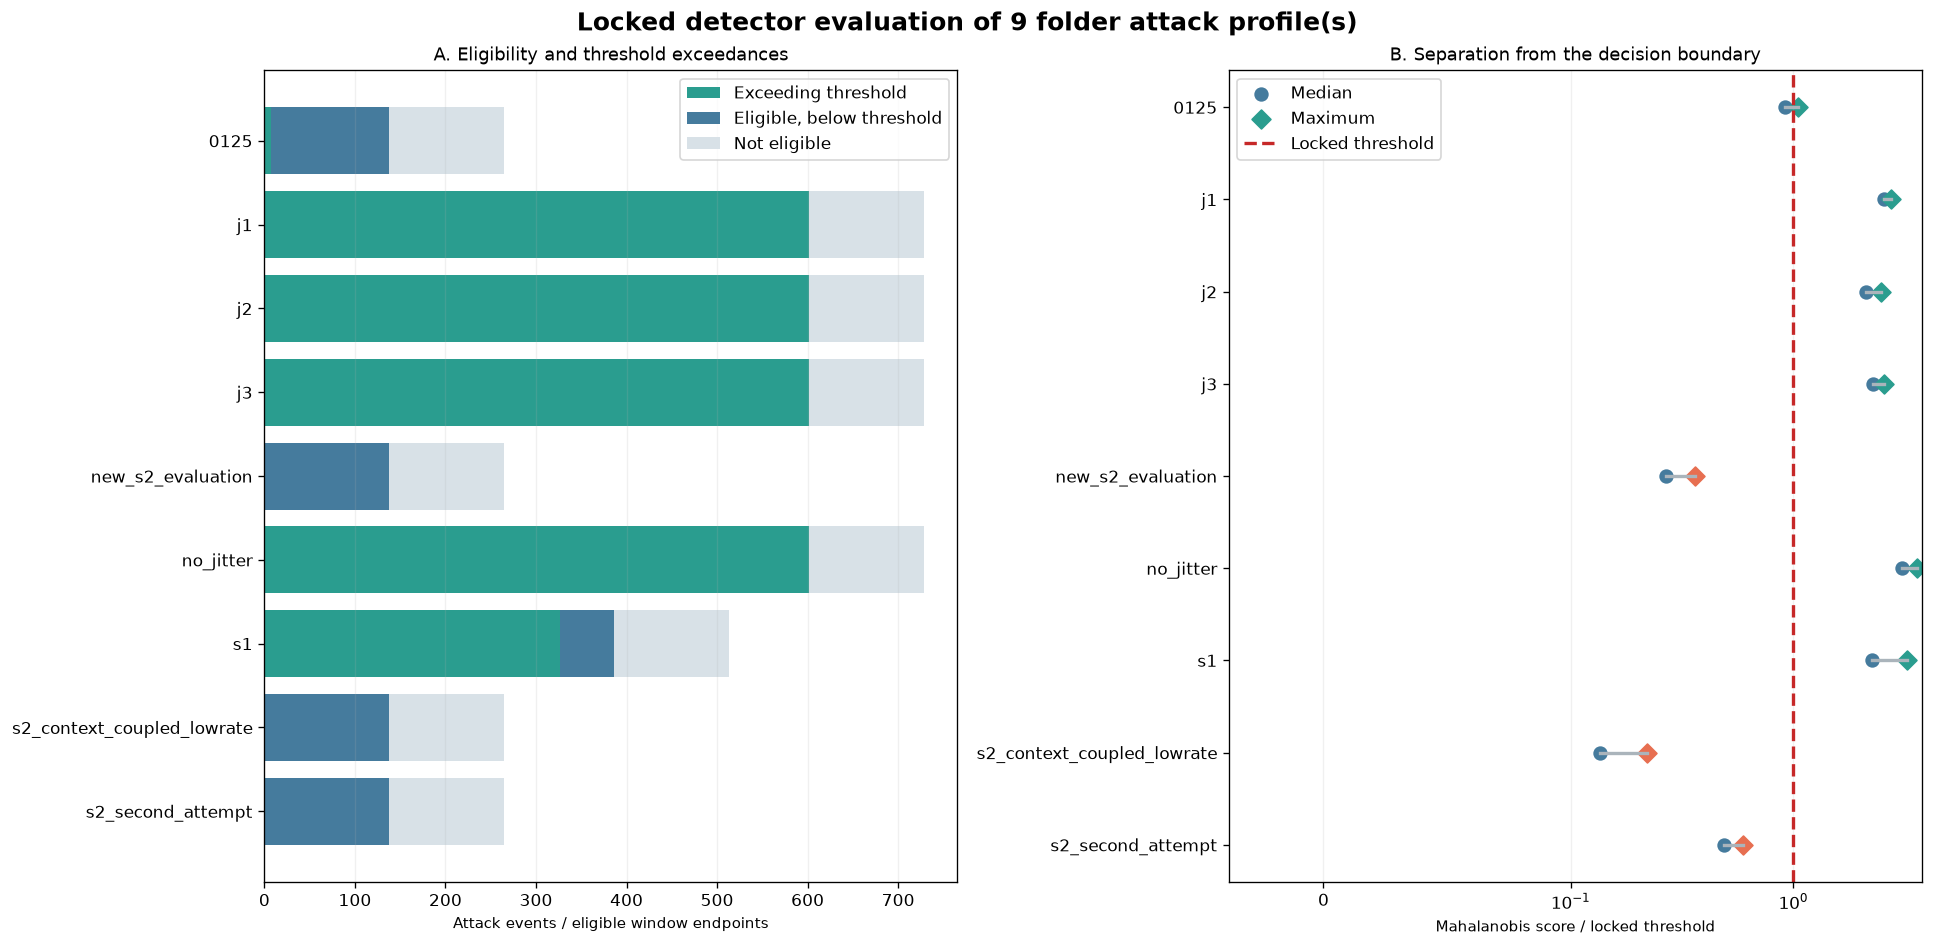

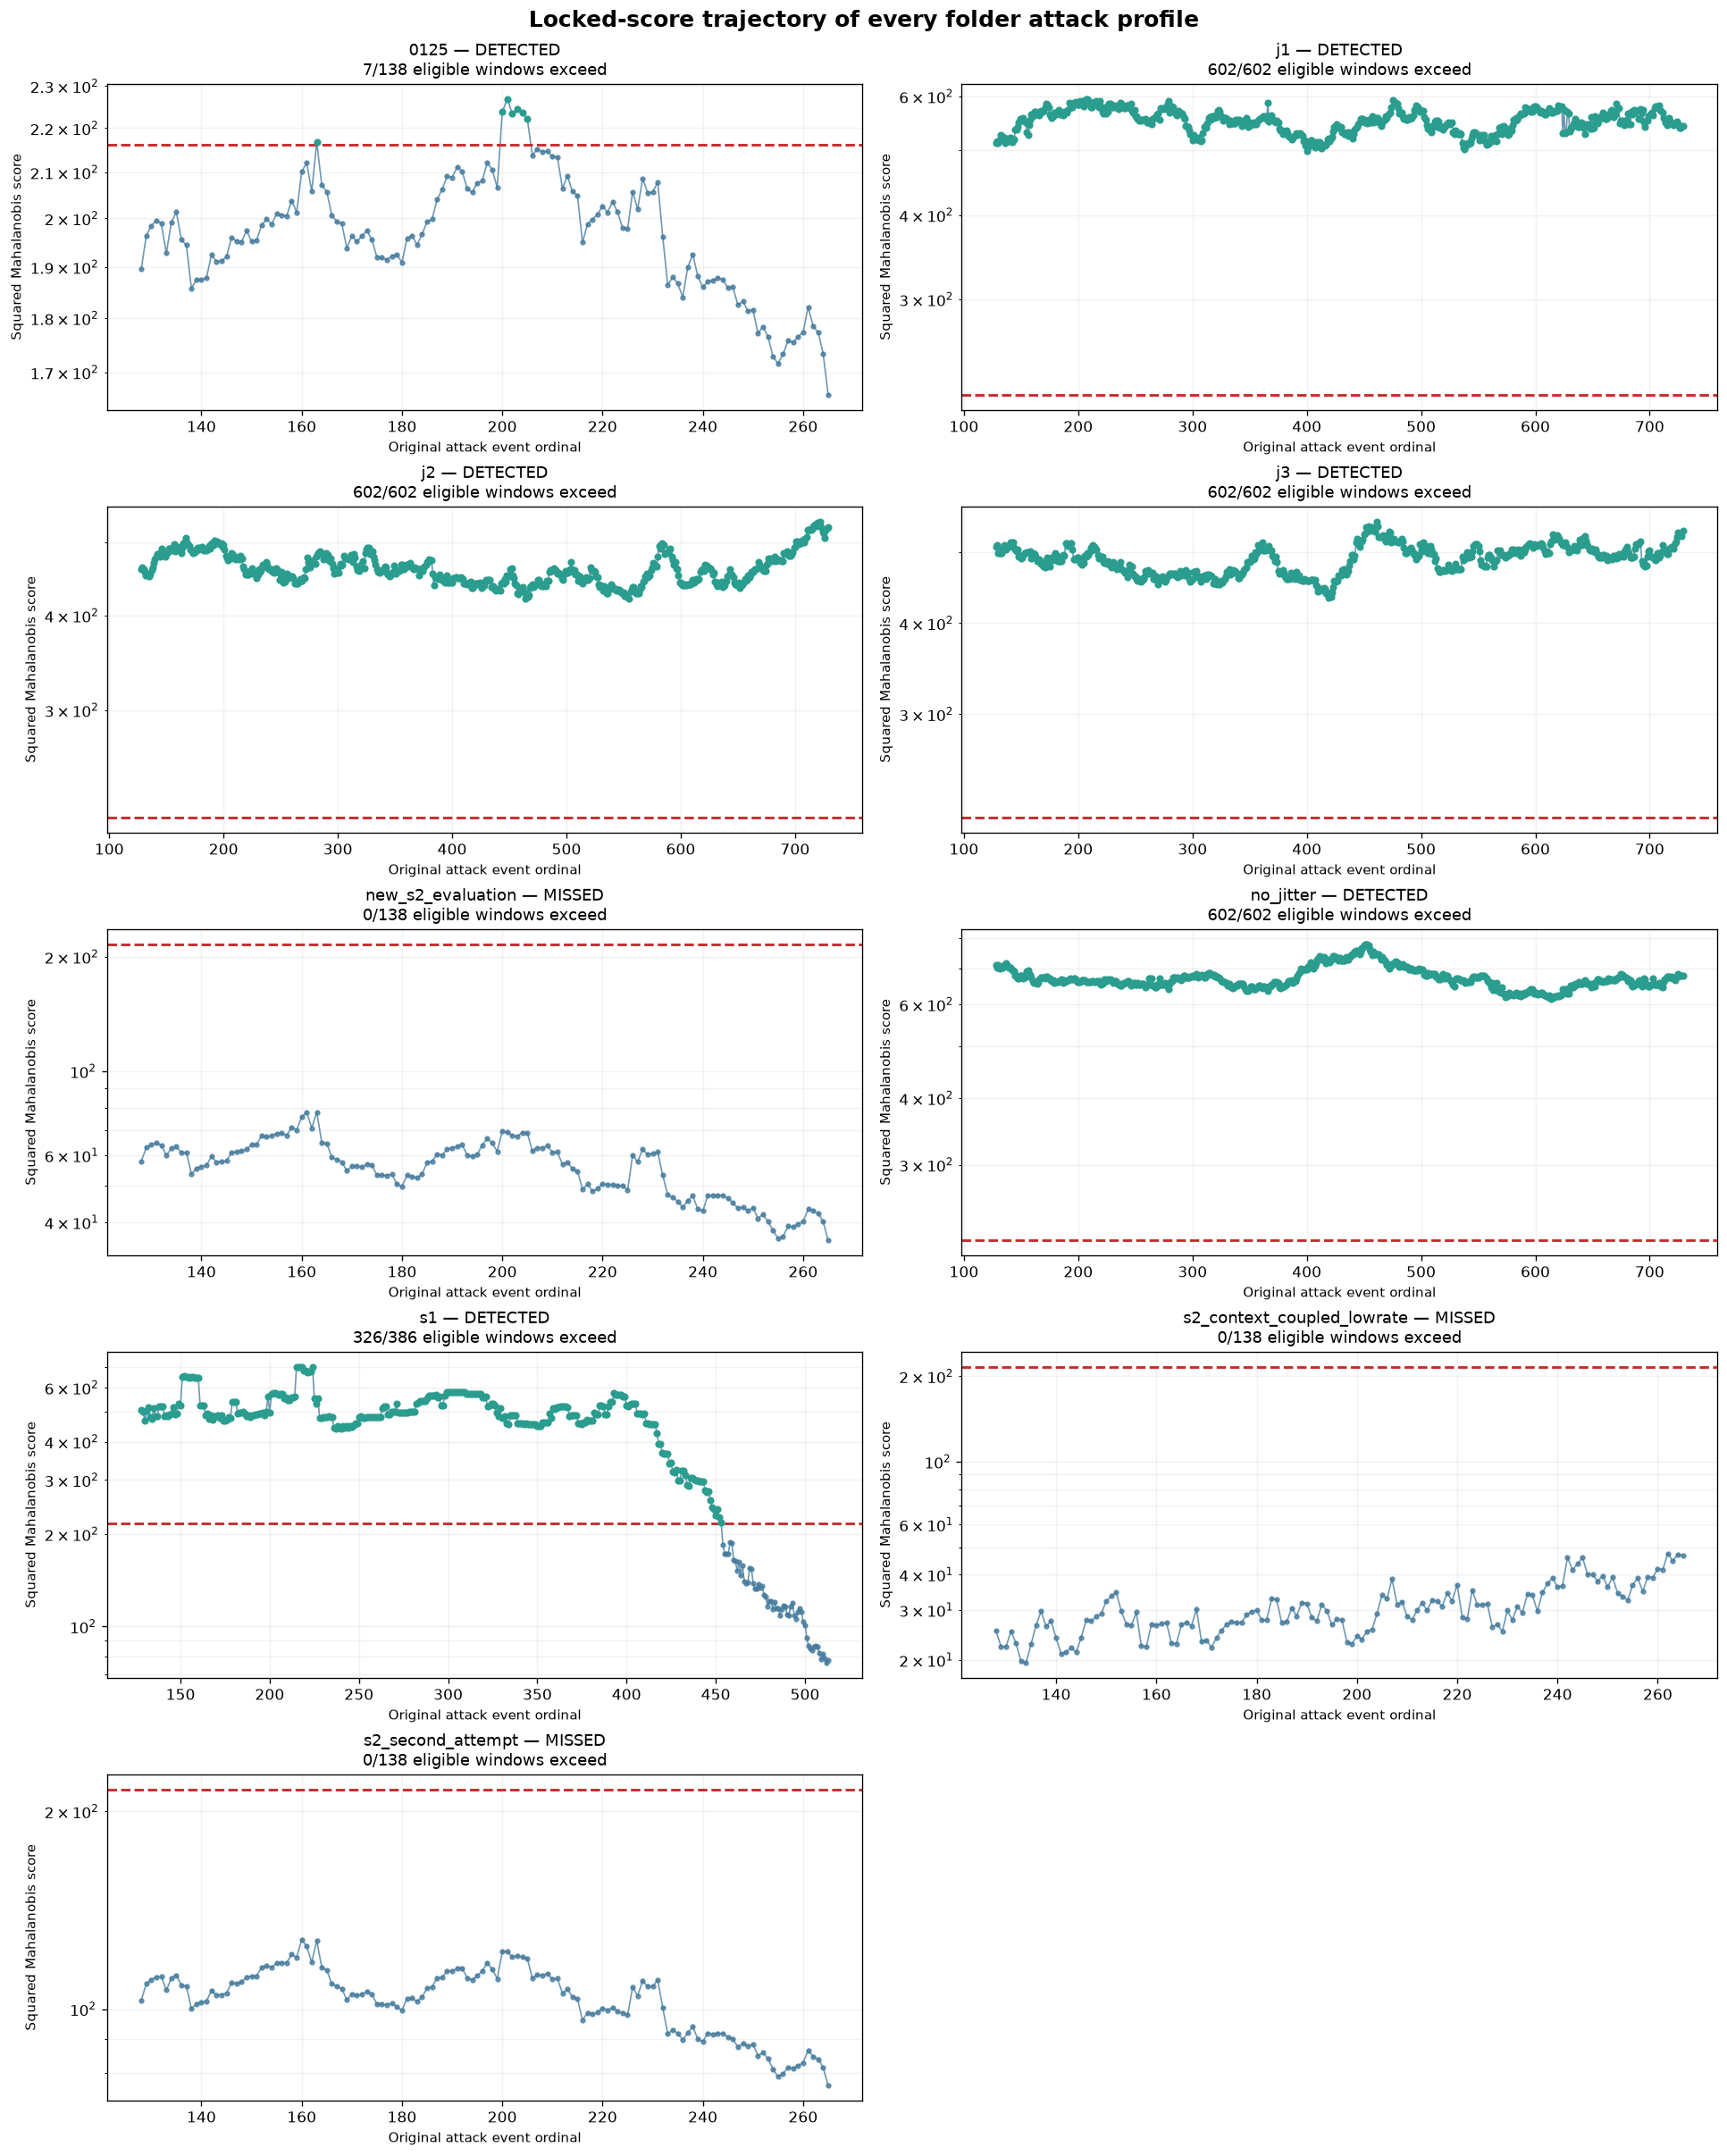

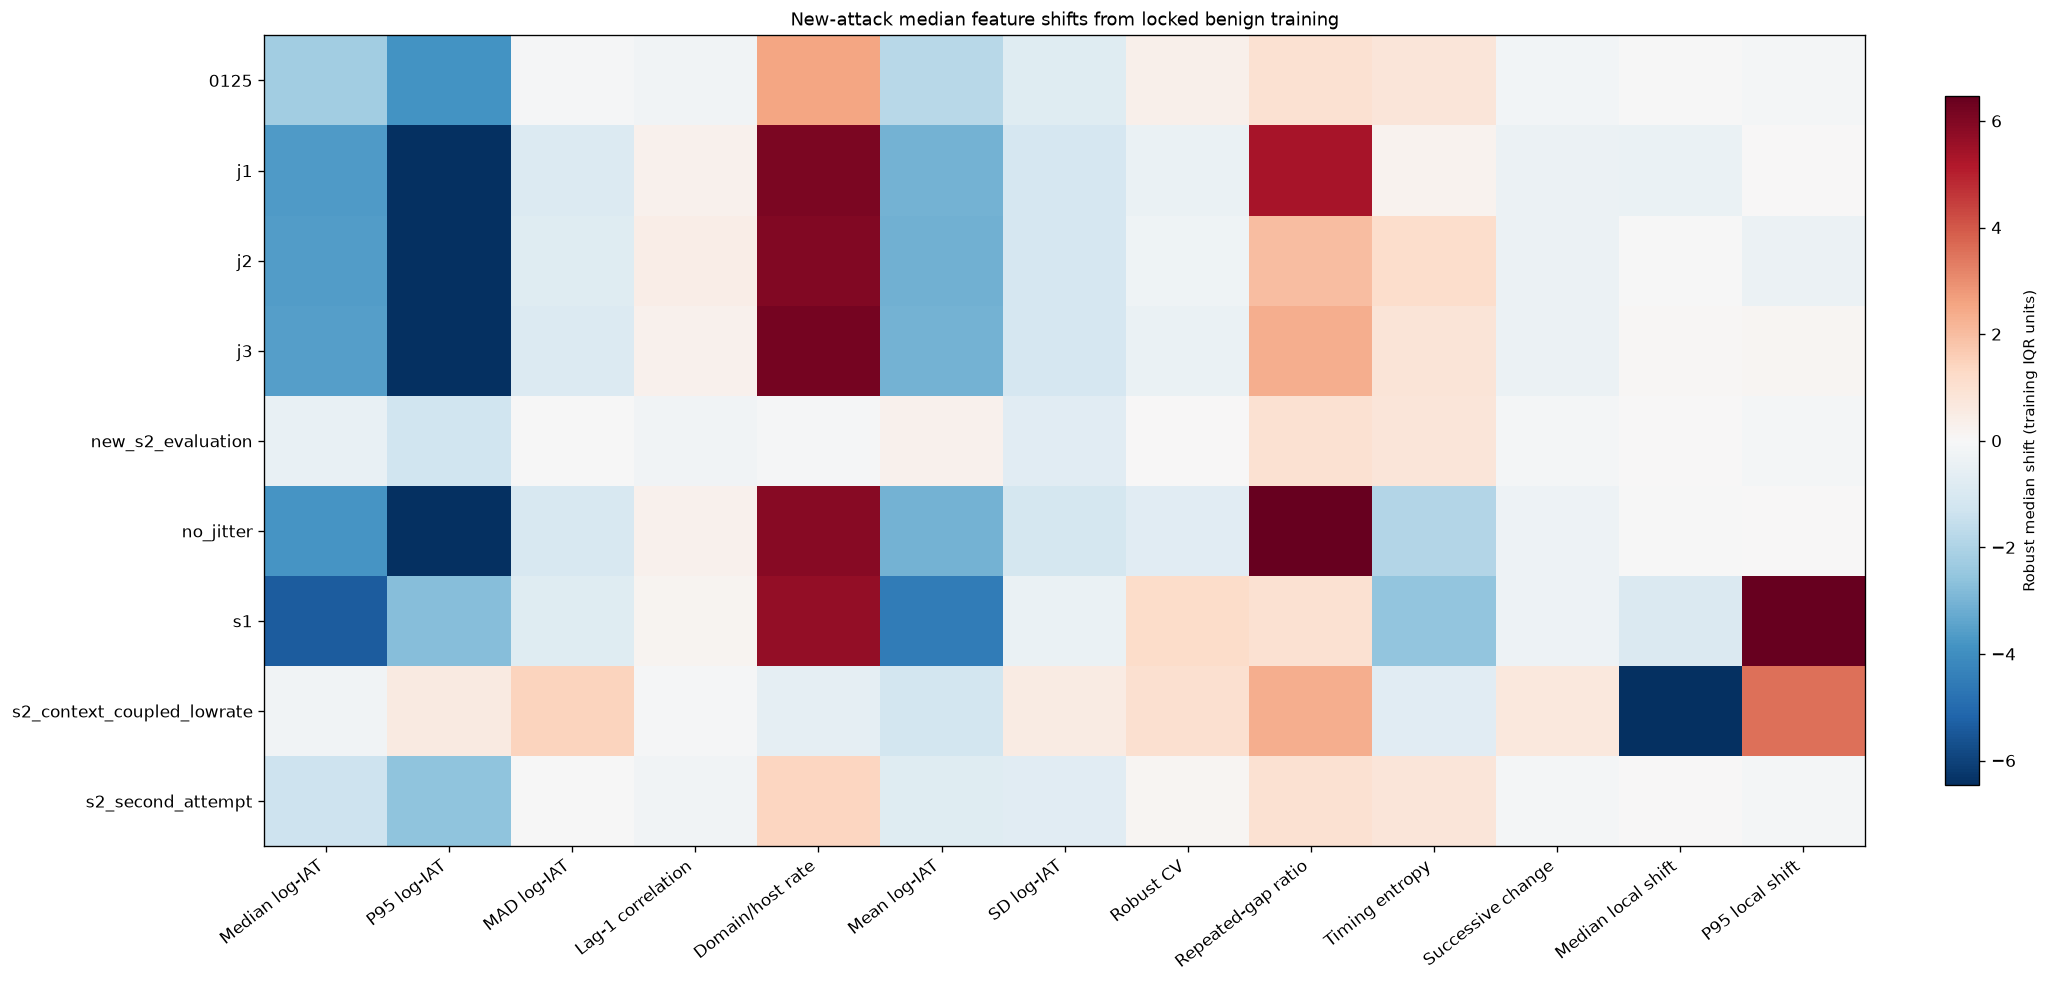


LOCKED FOLDER ATTACK EVALUATION COMPLETE
Evaluated profiles: 9
Detected profiles: 6
Rejected input files: 0
Locked candidate: w64__baseline+regularity+local_change__64fd5af306
Locked threshold: 216.140237928340
Model/feature/threshold changes: NONE
Output directory: /home/notevenknow/Desktop/jupyter_lab/Data/outputs_locked_attack_folder_v1_2_1/run_20260804T151804Z
Results bundle: /home/notevenknow/Desktop/jupyter_lab/Data/outputs_locked_attack_folder_v1_2_1/run_20260804T151804Z/locked_attack_folder_results_v1_2_1.zip

Input audit


attack_profile,source_file,sha256,status,error,detected_format,raw_rows,valid_dns_rows,dropped_rows,attack_domain_rows,captured_context_rows,first_event_utc,last_event_utc,duration_seconds,unique_parent_domains
str,str,str,str,str,str,i64,i64,i64,i64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,i64
"""0125""","""dns_0125.log""","""23cd7e49cd890346e7bbc0502df75c…","""EVALUATED""","""""","""tsv""",287,287,0,265,22,2026-08-04 06:07:44.370263 UTC,2026-08-04 07:13:50.871706 UTC,3966.501443,6
"""j1""","""dns_j1.log""","""53fd9388ffe14a19f76cefaa8753d7…","""EVALUATED""","""""","""tsv""",781,781,0,729,52,2026-07-11 18:21:27.088340 UTC,2026-07-11 19:21:44.477307 UTC,3617.388967,12
"""j2""","""dns_j2.log""","""95f1faf36213a0551bd56b9fd7fc96…","""EVALUATED""","""""","""tsv""",809,809,0,729,80,2026-07-11 19:33:23.055572 UTC,2026-07-11 20:38:24.467021 UTC,3901.411449,20
"""j3""","""dns_j3.log""","""5c6a84857ce367ee7c39eb5ccc6c65…","""EVALUATED""","""""","""tsv""",794,794,0,729,65,2026-07-11 20:54:59.933479 UTC,2026-07-11 21:56:11.081198 UTC,3671.147719,13
"""new_s2_evaluation""","""dns_new_s2_evaluation.log""","""830b096e1f5298d0b03b7145e8c3a5…","""EVALUATED""","""""","""tsv""",351,351,0,265,86,2026-08-03 16:04:58.359742 UTC,2026-08-03 20:29:24.445086 UTC,15866.085344,11
"""no_jitter""","""dns_no_jitter.log""","""789e4b80f2a0e471c1bbdbee80c5c3…","""EVALUATED""","""""","""tsv""",777,777,0,729,48,2026-07-11 14:48:22.987825 UTC,2026-07-11 15:48:26.743733 UTC,3603.755908,13
"""s1""","""dns_s1.log""","""81897052e085426c4c2d6932859cab…","""EVALUATED""","""""","""tsv""",592,592,0,513,79,2026-07-15 10:13:18.217266 UTC,2026-07-15 12:11:40.946615 UTC,7102.729349,13
"""s2_context_coupled_lowrate""","""dns_s2_context_coupled_lowrate…","""17ec3ee3d0d50d719735299774a802…","""EVALUATED""","""""","""tsv""",620,620,0,265,355,2026-07-15 15:48:55.853188 UTC,2026-07-15 23:50:19.673906 UTC,28883.820718,27
"""s2_second_attempt""","""dns_s2_second_attempt.log""","""eee3fb739156ec4a274042b65d416b…","""EVALUATED""","""""","""tsv""",322,322,0,265,57,2026-08-03 21:05:39.365938 UTC,2026-08-03 23:17:52.397741 UTC,7933.031803,14



Detection summary


attack_profile,total_attack_events,scored_attack_windows,eligible_coverage_pct,attack_exceedance_count,exceedance_pct_of_eligible,profile_detected,attack_events_to_detection,seconds_to_detection,median_score_to_threshold,maximum_score_to_threshold
str,i64,i64,f64,i64,f64,bool,i64,f64,f64,f64
"""0125""",265,138,52.075472,7,5.072464,true,163,2431.701266,0.913475,1.049982
"""j1""",729,602,82.578875,602,100.0,true,128,625.248648,2.561161,2.753159
"""j2""",729,602,82.578875,602,100.0,true,128,643.299794,2.122789,2.464507
"""j3""",729,602,82.578875,602,100.0,true,128,629.317108,2.28021,2.552709
"""new_s2_evaluation""",265,138,52.075472,0,0.0,false,null,null,0.266571,0.361133
"""no_jitter""",729,602,82.578875,602,100.0,true,128,630.78487,3.081996,3.603719
"""s1""",513,386,75.243665,326,84.455959,true,128,826.560613,2.248743,3.249551
"""s2_context_coupled_lowrate""",265,138,52.075472,0,0.0,false,null,null,0.13522,0.219457
"""s2_second_attempt""",265,138,52.075472,0,0.0,false,null,null,0.488346,0.590554


In [32]:
# ============================================================
# SECTION 15.2 — LOCKED BATCH INJECTION, SCORING AND PLOTS
# ============================================================
# No fitting, covariance selection, feature selection or threshold
# calibration occurs below. Every file is an independent evaluation stream.


def _detect_batch_zeek_format(path: Path) -> str:
    with path.open("r", encoding="utf-8", errors="replace") as handle:
        for line in handle:
            stripped = line.strip()
            if not stripped:
                continue
            if stripped.startswith("{"):
                return "jsonl"
            if stripped.startswith("#"):
                return "tsv"
            break
    raise ValueError(
        "Input is neither Zeek TSV nor Zeek JSON-lines."
    )


def _canonicalize_batch_attack(
    path: Path,
    *,
    profile: str,
    source_file: str,
) -> tuple[pl.DataFrame, dict]:
    detected_format = _detect_batch_zeek_format(path)
    if detected_format == "jsonl":
        parsed = parse_jsonl_log(path, profile)
    else:
        parsed = parse_zeek_log(path, profile)

    required_columns = {
        "ts_float",
        "query",
        "id.orig_h",
        "id.resp_h",
    }
    missing = sorted(required_columns - set(parsed.columns))
    if missing:
        raise ValueError(
            f"Missing required Zeek DNS fields: {missing}"
        )

    optional_columns = {
        "uid": pl.String,
        "trans_id": pl.String,
        "id.orig_p": pl.Int64,
        "id.resp_p": pl.Int64,
    }
    additions = []
    for column_name, dtype in optional_columns.items():
        if column_name not in parsed.columns:
            additions.append(
                pl.lit(None, dtype=dtype).alias(column_name)
            )
    if additions:
        parsed = parsed.with_columns(additions)

    raw_rows = parsed.height
    valid = (
        parsed
        .with_columns(
            [
                pl.col("ts_float")
                .cast(pl.Float64, strict=False)
                .alias("ts_float"),
                pl.col("query")
                .cast(pl.String, strict=False)
                .alias("query"),
            ]
        )
        .filter(
            pl.col("ts_float").is_not_null()
            & pl.col("ts_float").is_finite()
            & pl.col("query").is_not_null()
            & (pl.col("query").str.strip_chars() != "")
        )
    )
    if valid.height == 0:
        raise ValueError(
            "No rows contain both a finite timestamp and DNS query."
        )

    canonical = (
        valid
        .with_row_index("_source_row")
        .select(
            [
                pl.from_epoch(
                    pl.col("ts_float"), time_unit="s"
                )
                .dt.replace_time_zone("UTC")
                .alias("event_time"),
                (pl.col("ts_float") * 1_000_000)
                .round(0)
                .cast(pl.Int64)
                .alias("_event_time_us"),
                pl.col("id.orig_h")
                .cast(pl.String, strict=False)
                .alias("host_id"),
                pl.col("id.resp_h")
                .cast(pl.String, strict=False)
                .alias("resolver_ip"),
                _normalize_fqdn_expr("query").alias("fqdn"),
                pl.lit("capture_candidate").alias("source_type"),
                pl.lit(None, dtype=pl.String).alias("attack_profile"),
                pl.lit(source_file).alias("source_file"),
                pl.col("_source_row"),
                pl.col("uid")
                .cast(pl.String, strict=False)
                .alias("_uid"),
                pl.col("trans_id")
                .cast(pl.String, strict=False)
                .alias("_trans_id"),
                pl.col("id.orig_p")
                .cast(pl.Int64, strict=False)
                .alias("_orig_port"),
                pl.col("id.resp_p")
                .cast(pl.Int64, strict=False)
                .alias("_resp_port"),
            ]
        )
        .filter(pl.col("fqdn").is_not_null())
        .with_columns(
            [
                pl.when(
                    (pl.col("fqdn") == NEW_ATTACK_GROUND_TRUTH_DOMAIN)
                    | pl.col("fqdn").str.ends_with(
                        "." + NEW_ATTACK_GROUND_TRUTH_DOMAIN
                    )
                )
                .then(pl.lit("attack"))
                .otherwise(pl.lit("captured_benign_context"))
                .alias("source_type"),
                pl.when(
                    (pl.col("fqdn") == NEW_ATTACK_GROUND_TRUTH_DOMAIN)
                    | pl.col("fqdn").str.ends_with(
                        "." + NEW_ATTACK_GROUND_TRUTH_DOMAIN
                    )
                )
                .then(pl.lit(profile))
                .otherwise(pl.lit(None, dtype=pl.String))
                .alias("attack_profile"),
            ]
        )
    )
    if canonical.height == 0:
        raise ValueError("No valid normalized DNS names remain.")

    hierarchy_rows = []
    for fqdn in (
        canonical
        .select("fqdn")
        .unique()
        .get_column("fqdn")
        .to_list()
    ):
        registered_domain, parent_domain = (
            _domain_hierarchy_from_psl(fqdn)
        )
        hierarchy_rows.append(
            {
                "fqdn": fqdn,
                "registered_domain": registered_domain,
                "parent_domain": parent_domain,
            }
        )
    hierarchy = pl.DataFrame(
        hierarchy_rows,
        schema={
            "fqdn": pl.String,
            "registered_domain": pl.String,
            "parent_domain": pl.String,
        },
    )
    canonical = (
        canonical
        .join(hierarchy, on="fqdn", how="left")
        .sort(["_event_time_us", "_source_row"], maintain_order=True)
    )
    attack_domain_rows = canonical.filter(
        pl.col("source_type") == "attack"
    ).height
    captured_context_rows = canonical.filter(
        pl.col("source_type") == "captured_benign_context"
    ).height
    if attack_domain_rows == 0:
        raise ValueError(
            "No query matches the configured ground-truth attack domain "
            f"{NEW_ATTACK_GROUND_TRUTH_DOMAIN!r}."
        )
    timing = canonical["_event_time_us"].to_numpy()
    if np.any(np.diff(timing) < 0):
        raise RuntimeError("Canonical event order is not monotonic.")

    audit = {
        "detected_format": detected_format,
        "raw_rows": raw_rows,
        "valid_dns_rows": canonical.height,
        "dropped_rows": raw_rows - canonical.height,
        "attack_domain_rows": attack_domain_rows,
        "captured_context_rows": captured_context_rows,
        "first_event_utc": canonical["event_time"].min(),
        "last_event_utc": canonical["event_time"].max(),
        "duration_seconds": (
            int(timing[-1]) - int(timing[0])
        ) / 1_000_000.0,
        "unique_parent_domains": canonical[
            "parent_domain"
        ].n_unique(),
    }
    return canonical, audit


def _inject_batch_attack_and_build_windows(
    attack_original: pl.DataFrame,
    *,
    profile: str,
    injection_id: str,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    original_start_us = int(
        attack_original
        .filter(pl.col("source_type") == "attack")
        ["_event_time_us"][0]
    )
    rigid_offset_us = _injected_start_us - original_start_us

    attack_prepared = (
        attack_original
        .with_columns(
            [
                pl.col("_source_row").alias("original_source_row"),
                pl.col("event_time").alias(
                    "original_attack_event_time"
                ),
                pl.col("_event_time_us").alias(
                    "original_attack_event_time_us"
                ),
                pl.col("host_id").alias(
                    "original_attack_host_id"
                ),
                pl.col("resolver_ip").alias(
                    "original_attack_resolver_ip"
                ),
                pl.col("_resp_port").alias(
                    "original_attack_resolver_port"
                ),
                pl.concat_str(
                    [
                        pl.col("source_file"),
                        pl.lit("::row_"),
                        pl.col("_source_row").cast(pl.String),
                    ]
                ).alias("original_attack_event_id"),
                (
                    pl.col("_event_time_us")
                    + pl.lit(rigid_offset_us)
                )
                .cast(pl.Int64)
                .alias("_event_time_us"),
                pl.lit(BENIGN_HOST_ID).alias("host_id"),
                pl.lit(_mapped_resolver_ip).alias("resolver_ip"),
                pl.lit(BENIGN_RESOLVER_PORT).alias("_resp_port"),
                pl.lit(injection_id).alias("injection_id"),
                pl.lit(injection_id).alias("feature_stream_id"),
                pl.lit(1, dtype=pl.Int64).alias("_tie_source_rank"),
                pl.col("_source_row")
                .cast(pl.Int64)
                .alias("_tie_source_row"),
            ]
        )
        .with_columns(
            pl.from_epoch(
                pl.col("_event_time_us"), time_unit="us"
            )
            .dt.replace_time_zone("UTC")
            .alias("event_time")
        )
        .with_columns(
            pl.when(pl.col("source_type") == "attack")
            .then(
                (pl.col("source_type") == "attack")
                .cast(pl.Int64)
                .cum_sum()
            )
            .otherwise(pl.lit(None, dtype=pl.Int64))
            .alias("_attack_event_ordinal")
        )
    )

    benign_prepared = (
        benign_session_audit_events
        .clone()
        .with_columns(
            [
                pl.col("_source_row").alias("original_source_row"),
                pl.lit(
                    None,
                    dtype=pl.Datetime("us", time_zone="UTC"),
                ).alias("original_attack_event_time"),
                pl.lit(None, dtype=pl.Int64).alias(
                    "original_attack_event_time_us"
                ),
                pl.lit(None, dtype=pl.String).alias(
                    "original_attack_host_id"
                ),
                pl.lit(None, dtype=pl.String).alias(
                    "original_attack_resolver_ip"
                ),
                pl.lit(None, dtype=pl.Int64).alias(
                    "original_attack_resolver_port"
                ),
                pl.lit(None, dtype=pl.String).alias(
                    "original_attack_event_id"
                ),
                pl.lit(None, dtype=pl.Int64).alias(
                    "_attack_event_ordinal"
                ),
                pl.lit(injection_id).alias("injection_id"),
                pl.lit(injection_id).alias("feature_stream_id"),
                pl.lit(0, dtype=pl.Int64).alias("_tie_source_rank"),
                pl.col("_source_row")
                .cast(pl.Int64)
                .alias("_tie_source_row"),
            ]
        )
    )

    combined = (
        pl.concat(
            [benign_prepared, attack_prepared],
            how="diagonal_relaxed",
        )
        .sort(
            ["_event_time_us", "_tie_source_rank", "_tie_source_row"],
            maintain_order=True,
        )
        .with_row_index("_stream_row")
        .drop("_source_row")
        .rename({"_stream_row": "_source_row"})
    )
    feature_input = (
        combined
        .with_columns(
            pl.col("source_file").alias("origin_source_file")
        )
        .with_columns(
            pl.col("feature_stream_id").alias("source_file")
        )
    )
    sessionized = _sessionize_benign(
        feature_input,
        FROZEN_HOST_INACTIVITY_MINUTES,
    )
    event_base_internal, _, _ = _sessionized_feature_frames(
        sessionized
    )
    event_base = _restore_audit_source_file(
        event_base_internal
    )
    windows = _build_multiwindow_features(
        event_base,
        cohort_name="locked_new_attack_batch",
        window_sizes=[RESULTS_WINDOW_SIZE],
    )
    attack_windows = (
        windows
        .filter(
            (pl.col("source_type") == "attack")
            & (
                pl.col("attack_profile") == profile
            )
            & _all_finite_mask(windows, RESULTS_FEATURES)
        )
        .sort(["event_time", "_source_row"], maintain_order=True)
    )
    attack_events = (
        event_base
        .filter(pl.col("source_type") == "attack")
        .sort(["event_time", "_source_row"], maintain_order=True)
    )
    return attack_events, attack_windows


_batch_input_audit_rows = []
_batch_summary_rows = []
_batch_scored_parts = []
_batch_feature_shift_rows = []
_batch_feature_shift_matrix = []
_batch_evaluated_profiles = []

for _spec in NEW_ATTACK_FILE_SPECS:
    _path = _spec["path"]
    _profile = _spec["attack_profile"]
    _source_file = _spec["relative_path"]
    _injection_id = _spec["injection_id"]
    _file_hash = hashlib.sha256(_path.read_bytes()).hexdigest()
    print(f"[{_profile}] loading {_source_file}")
    try:
        _canonical_attack, _input_audit = (
            _canonicalize_batch_attack(
                _path,
                profile=_profile,
                source_file=_source_file,
            )
        )
        _attack_events, _attack_windows = (
            _inject_batch_attack_and_build_windows(
                _canonical_attack,
                profile=_profile,
                injection_id=_injection_id,
            )
        )

        _total_events = _attack_events.height
        _first_attack_time = _attack_events["event_time"].min()
        _scored_count = _attack_windows.height
        if _scored_count:
            _raw = np.asarray(
                _attack_windows
                .select(RESULTS_FEATURES)
                .to_numpy(),
                dtype=np.float64,
            )
            _scaled = (
                _raw - RESULTS_TRAIN_MEDIANS[None, :]
            ) / RESULTS_TRAIN_SCALES[None, :]
            _scores = _score_squared_mahalanobis(
                _scaled,
                RESULTS_FITTED_MODEL["center"],
                RESULTS_FITTED_MODEL["precision"],
            )
            _exceedance_mask = _scores > RESULTS_THRESHOLD
            _exceedance_count = int(_exceedance_mask.sum())
            _detected = bool(_exceedance_count > 0)
            _scored = _attack_windows.with_columns(
                [
                    pl.Series("mahalanobis_score", _scores),
                    pl.lit(RESULTS_THRESHOLD).alias(
                        "locked_threshold"
                    ),
                    pl.Series(
                        "is_threshold_exceedance",
                        _exceedance_mask,
                    ),
                ]
            )
            _batch_scored_parts.append(_scored)
            _median_score = float(np.median(_scores))
            _maximum_score = float(np.max(_scores))
            _shift = (
                np.median(_raw, axis=0)
                - RESULTS_TRAIN_MEDIANS
            ) / RESULTS_TRAIN_SCALES
            _batch_feature_shift_matrix.append(_shift)
            for _feature, _value in zip(
                RESULTS_FEATURES, _shift
            ):
                _batch_feature_shift_rows.append(
                    {
                        "attack_profile": _profile,
                        "feature_name": _feature,
                        "robust_median_shift_iqr": float(_value),
                    }
                )
            if _detected:
                _first_index = int(
                    np.flatnonzero(_exceedance_mask)[0]
                )
                _first_row = _scored.row(
                    _first_index, named=True
                )
                _first_detection_time = _first_row["event_time"]
                _first_detection_ordinal = _first_row[
                    "_attack_event_ordinal"
                ]
                _seconds_to_detection = (
                    _first_detection_time - _first_attack_time
                ).total_seconds()
            else:
                _first_detection_time = None
                _first_detection_ordinal = None
                _seconds_to_detection = None
        else:
            _exceedance_count = 0
            _detected = False
            _median_score = None
            _maximum_score = None
            _first_detection_time = None
            _first_detection_ordinal = None
            _seconds_to_detection = None

        _batch_summary_rows.append(
            {
                "attack_profile": _profile,
                "source_file": _source_file,
                "sha256": _file_hash,
                "total_attack_events": _total_events,
                "scored_attack_windows": _scored_count,
                "eligible_coverage_pct": (
                    100.0 * _scored_count / _total_events
                    if _total_events else None
                ),
                "attack_exceedance_count": _exceedance_count,
                "exceedance_pct_of_eligible": (
                    100.0 * _exceedance_count / _scored_count
                    if _scored_count else None
                ),
                "profile_detected": _detected,
                "first_detection_utc": _first_detection_time,
                "attack_events_to_detection": (
                    _first_detection_ordinal
                ),
                "seconds_to_detection": _seconds_to_detection,
                "median_attack_score": _median_score,
                "maximum_attack_score": _maximum_score,
                "median_score_to_threshold": (
                    _median_score / RESULTS_THRESHOLD
                    if _median_score is not None else None
                ),
                "maximum_score_to_threshold": (
                    _maximum_score / RESULTS_THRESHOLD
                    if _maximum_score is not None else None
                ),
                "locked_threshold": RESULTS_THRESHOLD,
                "locked_candidate_id": RESULTS_CANDIDATE_ID,
            }
        )
        _batch_evaluated_profiles.append(_profile)
        _batch_input_audit_rows.append(
            {
                "attack_profile": _profile,
                "source_file": _source_file,
                "sha256": _file_hash,
                "status": "EVALUATED",
                "error": "",
                **_input_audit,
            }
        )
        print(
            f"  events={_total_events}, scored={_scored_count}, "
            f"exceedances={_exceedance_count}, detected={_detected}"
        )
    except Exception as exc:
        _batch_input_audit_rows.append(
            {
                "attack_profile": _profile,
                "source_file": _source_file,
                "sha256": _file_hash,
                "status": "REJECTED",
                "error": f"{type(exc).__name__}: {exc}",
                "detected_format": None,
                "raw_rows": None,
                "valid_dns_rows": None,
                "dropped_rows": None,
                "attack_domain_rows": None,
                "captured_context_rows": None,
                "first_event_utc": None,
                "last_event_utc": None,
                "duration_seconds": None,
                "unique_parent_domains": None,
            }
        )
        print(f"  REJECTED: {type(exc).__name__}: {exc}")

locked_attack_batch_input_audit = pl.DataFrame(
    _batch_input_audit_rows,
    infer_schema_length=None,
)
if not _batch_summary_rows:
    display(locked_attack_batch_input_audit)
    raise RuntimeError(
        "No compatible attack file could be evaluated. Inspect the "
        "input audit above; the locked detector was not changed."
    )

locked_attack_batch_summary = pl.DataFrame(
    _batch_summary_rows,
    infer_schema_length=None,
).sort("attack_profile")
locked_attack_batch_scored_windows = (
    pl.concat(_batch_scored_parts, how="diagonal_relaxed")
    if _batch_scored_parts
    else pl.DataFrame()
)
locked_attack_batch_feature_shifts = (
    pl.DataFrame(
        _batch_feature_shift_rows,
        infer_schema_length=None,
    )
    if _batch_feature_shift_rows
    else pl.DataFrame(
        schema={
            "attack_profile": pl.String,
            "feature_name": pl.String,
            "robust_median_shift_iqr": pl.Float64,
        }
    )
)

# -------------------- exports --------------------
_batch_input_path = (
    NEW_ATTACKS_OUTPUT_DIR / "01_input_audit.csv"
)
_batch_summary_path = (
    NEW_ATTACKS_OUTPUT_DIR / "02_detection_summary.csv"
)
_batch_shifts_path = (
    NEW_ATTACKS_OUTPUT_DIR / "03_feature_shifts.csv"
)
_batch_scored_path = (
    NEW_ATTACKS_OUTPUT_DIR / "04_scored_windows.parquet"
)
locked_attack_batch_input_audit.write_csv(_batch_input_path)
locked_attack_batch_summary.write_csv(_batch_summary_path)
locked_attack_batch_feature_shifts.write_csv(_batch_shifts_path)
if locked_attack_batch_scored_windows.height:
    locked_attack_batch_scored_windows.write_parquet(
        _batch_scored_path
    )

# -------------------- dynamic profile plot --------------------
_batch_order = locked_attack_batch_summary[
    "attack_profile"
].to_list()
_batch_records = {
    row["attack_profile"]: row
    for row in locked_attack_batch_summary.to_dicts()
}
_profile_count = len(_batch_order)
_profile_labels = [
    profile if len(profile) <= 32 else profile[:29] + "..."
    for profile in _batch_order
]
_figure_height = max(5.5, 0.62 * _profile_count + 2.2)
_figure, _axes = plt.subplots(
    1,
    2,
    figsize=(16, _figure_height),
    constrained_layout=True,
)
_y = np.arange(_profile_count)
_scored_values = np.asarray(
    [_batch_records[p]["scored_attack_windows"] for p in _batch_order]
)
_unscored_values = np.asarray(
    [
        _batch_records[p]["total_attack_events"]
        - _batch_records[p]["scored_attack_windows"]
        for p in _batch_order
    ]
)
_exceed_values = np.asarray(
    [_batch_records[p]["attack_exceedance_count"] for p in _batch_order]
)
_eligible_below = _scored_values - _exceed_values
_axes[0].barh(
    _y,
    _exceed_values,
    color="#2A9D8F",
    label="Exceeding threshold",
)
_axes[0].barh(
    _y,
    _eligible_below,
    left=_exceed_values,
    color="#457B9D",
    label="Eligible, below threshold",
)
_axes[0].barh(
    _y,
    _unscored_values,
    left=_scored_values,
    color="#D8E1E7",
    label="Not eligible",
)
_axes[0].set_yticks(_y, labels=_profile_labels)
_axes[0].invert_yaxis()
_axes[0].set_xlabel("Attack events / eligible window endpoints")
_axes[0].set_title("A. Eligibility and threshold exceedances")
_axes[0].legend()
_axes[0].grid(axis="x", alpha=0.18)

for _index, _profile in enumerate(_batch_order):
    _record = _batch_records[_profile]
    _median_ratio = _record["median_score_to_threshold"]
    _maximum_ratio = _record["maximum_score_to_threshold"]
    if _median_ratio is None or _maximum_ratio is None:
        _axes[1].text(
            0.02,
            _index,
            "not scoreable",
            va="center",
            color="#E76F51",
        )
        continue
    _axes[1].plot(
        [_median_ratio, _maximum_ratio],
        [_index, _index],
        color="#AAB4BB",
        linewidth=2,
    )
    _axes[1].scatter(
        _median_ratio,
        _index,
        color="#457B9D",
        s=58,
        label="Median" if _index == 0 else None,
    )
    _axes[1].scatter(
        _maximum_ratio,
        _index,
        marker="D",
        color=(
            "#2A9D8F"
            if bool(_record["profile_detected"])
            else "#E76F51"
        ),
        s=64,
        label="Maximum" if _index == 0 else None,
    )
_axes[1].axvline(
    1.0,
    color="#C62828",
    linestyle="--",
    linewidth=2,
    label="Locked threshold",
)
_axes[1].set_xscale("symlog", linthresh=0.1)
_axes[1].set_yticks(_y, labels=_profile_labels)
_axes[1].invert_yaxis()
_axes[1].set_xlabel("Mahalanobis score / locked threshold")
_axes[1].set_title("B. Separation from the decision boundary")
_axes[1].legend()
_axes[1].grid(axis="x", alpha=0.18, which="both")
_figure.suptitle(
    f"Locked detector evaluation of {_profile_count} folder attack profile(s)",
    fontsize=15,
    fontweight="bold",
)
_batch_profile_plot_path = (
    NEW_ATTACKS_OUTPUT_DIR / "plot_01_batch_profile_outcomes.png"
)
_figure.savefig(
    _batch_profile_plot_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# -------------------- dynamic trajectory plot --------------------
_columns = 2 if _profile_count > 1 else 1
_rows = int(math.ceil(_profile_count / _columns))
_trajectory_figure, _trajectory_axes = plt.subplots(
    _rows,
    _columns,
    figsize=(16 if _columns == 2 else 10, max(4.2, 4.0 * _rows)),
    squeeze=False,
    constrained_layout=True,
)
for _axis, _profile in zip(
    _trajectory_axes.flat,
    _batch_order,
):
    _record = _batch_records[_profile]
    _profile_windows = (
        locked_attack_batch_scored_windows
        .filter(pl.col("attack_profile") == _profile)
        .sort(["event_time", "_source_row"], maintain_order=True)
        if locked_attack_batch_scored_windows.height
        else pl.DataFrame()
    )
    if _profile_windows.height:
        _axis.plot(
            _profile_windows["_attack_event_ordinal"].to_numpy(),
            _profile_windows["mahalanobis_score"].to_numpy(),
            marker="o",
            markersize=2.8,
            linewidth=1.0,
            color="#457B9D",
            alpha=0.78,
        )
        _flagged = _profile_windows.filter(
            pl.col("is_threshold_exceedance")
        )
        if _flagged.height:
            _axis.scatter(
                _flagged["_attack_event_ordinal"].to_numpy(),
                _flagged["mahalanobis_score"].to_numpy(),
                s=15,
                color="#2A9D8F",
                zorder=3,
            )
        _axis.set_yscale("log")
    else:
        _axis.text(
            0.5,
            0.5,
            "No complete scoreable windows",
            transform=_axis.transAxes,
            ha="center",
            va="center",
            color="#E76F51",
        )
    _axis.axhline(
        RESULTS_THRESHOLD,
        color="#C62828",
        linestyle="--",
        linewidth=1.7,
    )
    _axis.set_title(
        f"{_profile} — "
        f"{'DETECTED' if _record['profile_detected'] else 'MISSED'}\n"
        f"{_record['attack_exceedance_count']}/"
        f"{_record['scored_attack_windows']} eligible windows exceed"
    )
    _axis.set_xlabel("Original attack event ordinal")
    _axis.set_ylabel("Squared Mahalanobis score")
    _axis.grid(alpha=0.16, which="both")
for _axis in list(_trajectory_axes.flat)[_profile_count:]:
    _axis.set_visible(False)
_trajectory_figure.suptitle(
    "Locked-score trajectory of every folder attack profile",
    fontsize=15,
    fontweight="bold",
)
_batch_trajectory_plot_path = (
    NEW_ATTACKS_OUTPUT_DIR / "plot_02_batch_score_trajectories.png"
)
_trajectory_figure.savefig(
    _batch_trajectory_plot_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# -------------------- dynamic feature-shift plot --------------------
_feature_short = {
    "log_iat_median": "Median log-IAT",
    "log_iat_p95": "P95 log-IAT",
    "log_iat_mad": "MAD log-IAT",
    "log_iat_lag1_autocorrelation": "Lag-1 correlation",
    "domain_host_rate_ratio": "Domain/host rate",
    "log_iat_mean": "Mean log-IAT",
    "log_iat_std": "SD log-IAT",
    "robust_log_iat_cv": "Robust CV",
    "repeated_gap_ratio_5pct": "Repeated-gap ratio",
    "normalized_iat_entropy_8": "Timing entropy",
    "median_abs_successive_log_iat_change": "Successive change",
    "delta_log_iat_median_vs_previous_window": "Median local shift",
    "delta_log_iat_p95_vs_previous_window": "P95 local shift",
}
_shift_profiles = [
    profile
    for profile in _batch_order
    if _batch_records[profile]["scored_attack_windows"] > 0
]
_batch_shift_plot_path = None
if _shift_profiles:
    _shift_matrix = np.asarray(
        [
            [
                locked_attack_batch_feature_shifts
                .filter(
                    (pl.col("attack_profile") == profile)
                    & (pl.col("feature_name") == feature_name)
                )["robust_median_shift_iqr"]
                .item()
                for feature_name in RESULTS_FEATURES
            ]
            for profile in _shift_profiles
        ]
    )
    _shift_limit = max(
        2.0,
        float(np.nanpercentile(np.abs(_shift_matrix), 95)),
    )
    _shift_limit = min(_shift_limit, 12.0)
    _shift_figure, _shift_axis = plt.subplots(
        1,
        1,
        figsize=(17, max(4.5, 0.62 * len(_shift_profiles) + 2.5)),
        constrained_layout=True,
    )
    _image = _shift_axis.imshow(
        np.clip(_shift_matrix, -_shift_limit, _shift_limit),
        aspect="auto",
        cmap="RdBu_r",
        vmin=-_shift_limit,
        vmax=_shift_limit,
    )
    _shift_axis.set_xticks(
        np.arange(len(RESULTS_FEATURES)),
        labels=[_feature_short.get(name, name) for name in RESULTS_FEATURES],
        rotation=38,
        ha="right",
    )
    _shift_axis.set_yticks(
        np.arange(len(_shift_profiles)),
        labels=[
            p if len(p) <= 32 else p[:29] + "..."
            for p in _shift_profiles
        ],
    )
    _shift_axis.set_title(
        "New-attack median feature shifts from locked benign training"
    )
    _colorbar = _shift_figure.colorbar(
        _image, ax=_shift_axis, shrink=0.85
    )
    _colorbar.set_label("Robust median shift (training IQR units)")
    _batch_shift_plot_path = (
        NEW_ATTACKS_OUTPUT_DIR / "plot_03_batch_feature_shifts.png"
    )
    _shift_figure.savefig(
        _batch_shift_plot_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

# -------------------- manifest and bundle --------------------
_evaluated_count = len(_batch_evaluated_profiles)
_detected_count = int(
    locked_attack_batch_summary["profile_detected"].sum()
)
_rejected_count = int(
    locked_attack_batch_input_audit
    .filter(pl.col("status") == "REJECTED")
    .height
)
_batch_manifest = {
    "analysis_version": LOCKED_BATCH_VERSION,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "input_directory": str(NEW_ATTACKS_DIR),
    "output_root": str(NEW_ATTACKS_OUTPUT_ROOT),
    "run_id": NEW_ATTACKS_RUN_ID,
    "output_directory": str(NEW_ATTACKS_OUTPUT_DIR),
    "candidate_files_discovered": len(NEW_ATTACK_FILE_SPECS),
    "profiles_evaluated": _evaluated_count,
    "profiles_detected": _detected_count,
    "files_rejected": _rejected_count,
    "locked_candidate_id": RESULTS_CANDIDATE_ID,
    "locked_window_size_events": RESULTS_WINDOW_SIZE,
    "locked_features": RESULTS_FEATURES,
    "locked_threshold": RESULTS_THRESHOLD,
    "locked_benign_incidents_per_day": RESULTS_OBSERVED_INCIDENT_RATE,
    "ground_truth_attack_domain": NEW_ATTACK_GROUND_TRUTH_DOMAIN,
    "ground_truth_domain_is_model_input": False,
    "captured_non_attack_dns_role": (
        "retained as endpoint timing context; excluded from attack attribution"
    ),
    "model_refit_performed": False,
    "feature_selection_performed": False,
    "threshold_recalibration_performed": False,
    "injection_policy": PLACEMENT_POLICY,
    "evaluation_semantics": (
        "one independent benign-plus-one-attack stream per compatible file"
    ),
    "profile_results": locked_attack_batch_summary.to_dicts(),
}
_batch_manifest_path = (
    NEW_ATTACKS_OUTPUT_DIR / "run_manifest.json"
)
_batch_manifest_path.write_text(
    json.dumps(_batch_manifest, indent=2, default=str),
    encoding="utf-8",
)

_batch_readme_path = (
    NEW_ATTACKS_OUTPUT_DIR / "README.md"
)
_batch_readme_path.write_text(
    "# Locked folder-driven attack evaluation\n\n"
    f"- Candidate: `{RESULTS_CANDIDATE_ID}`\n"
    f"- Locked threshold: `{RESULTS_THRESHOLD:.12f}`\n"
    f"- Evaluated: `{_evaluated_count}` profile(s)\n"
    f"- Detected: `{_detected_count}` profile(s)\n"
    f"- Rejected inputs: `{_rejected_count}` file(s)\n\n"
    "New attacks were evaluated without model refitting, feature selection, "
    "or threshold recalibration. Detection means at least one complete "
    "eligible attack window exceeded the locked threshold.\n",
    encoding="utf-8",
)

_batch_bundle_members = [
    _batch_input_path,
    _batch_summary_path,
    _batch_shifts_path,
    _batch_profile_plot_path,
    _batch_trajectory_plot_path,
    _batch_manifest_path,
    _batch_readme_path,
]
if locked_attack_batch_scored_windows.height:
    _batch_bundle_members.append(_batch_scored_path)
if _batch_shift_plot_path is not None:
    _batch_bundle_members.append(_batch_shift_plot_path)
_batch_bundle_path = (
    NEW_ATTACKS_OUTPUT_DIR
    / "locked_attack_folder_results_v1_2_1.zip"
)
with zipfile.ZipFile(
    _batch_bundle_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as _archive:
    for _member in _batch_bundle_members:
        if _member.exists():
            _archive.write(_member, arcname=_member.name)

print("\n" + "=" * 92)
print("LOCKED FOLDER ATTACK EVALUATION COMPLETE")
print("=" * 92)
print(f"Evaluated profiles: {_evaluated_count}")
print(f"Detected profiles: {_detected_count}")
print(f"Rejected input files: {_rejected_count}")
print(f"Locked candidate: {RESULTS_CANDIDATE_ID}")
print(f"Locked threshold: {RESULTS_THRESHOLD:.12f}")
print("Model/feature/threshold changes: NONE")
print(f"Output directory: {NEW_ATTACKS_OUTPUT_DIR}")
print(f"Results bundle: {_batch_bundle_path}")
print("\nInput audit")
display(locked_attack_batch_input_audit)
print("\nDetection summary")
display(
    locked_attack_batch_summary.select(
        [
            "attack_profile",
            "total_attack_events",
            "scored_attack_windows",
            "eligible_coverage_pct",
            "attack_exceedance_count",
            "exceedance_pct_of_eligible",
            "profile_detected",
            "attack_events_to_detection",
            "seconds_to_detection",
            "median_score_to_threshold",
            "maximum_score_to_threshold",
        ]
    )
)


## Section 16 — Benign-calibrated sequential-evidence extension

### Why this extension is being tested

The locked detector already has a strong immediate-alert path, but the S2
boundary sweep showed a second failure mode: many consecutive eligible windows
can remain moderately anomalous without any single window crossing the direct
threshold.

| Development profile | Median score / threshold | Maximum | Direct result |
|---|---:|---:|---|
| S2 scale 0.125 | 0.913 | 1.050 | detected, 7/138 exceedances |
| S2 scale 0.25 | 0.488 | 0.591 | missed |
| S2 scale 0.50 | 0.267 | 0.361 | missed |
| Original S2 | 0.135 | 0.219 | missed |

The heatmap also showed that the two local-shift features are approximately
neutral for the 0.125/0.25/0.50 boundary series. Consequently, this version
does **not** reweight those features or lower the Mahalanobis threshold. It uses
the complete locked score as sequential evidence.

### Expanded decision

For score `M_t`, estimate its smoothed empirical upper-tail probability from
benign calibration scores:

\[
p_t = \frac{1 + \#\{M_{cal} \ge M_t\}}{N_{cal}+1}.
\]

Only scores in the unusual benign tail contribute evidence:

\[
e_t = \max\left(0,\log\frac{p_0}{p_t}\right).
\]

Evidence is accumulated per endpoint and parent domain with elapsed-time decay:

\[
A_t = e^{-\Delta t/\tau} A_{t-1} + e_t.
\]

The original detector and the new slow path are joined with an OR decision:

\[
alarm_t = (M_t > T_{locked}) \lor (A_t > H_{seq}).
\]

`p0=0.05` is a predeclared evidence-start tail, `tau=15 minutes` reuses the
existing incident/session timescale, and `H_seq` is the benign q99.9
accumulator threshold using method `higher`. No attack score enters this
calibration.


In [33]:
# ============================================================
# SECTION 16.1 — FROZEN BASELINE CHECKS AND SEQUENTIAL HELPERS
# ============================================================

from datetime import datetime, timezone
from pathlib import Path
import json
import math
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import polars as pl


SEQUENTIAL_EXPANSION_VERSION = "1.3.1"
SEQUENTIAL_EXPECTED_CANDIDATE_ID = (
    "w64__baseline+regularity+local_change__64fd5af306"
)
SEQUENTIAL_EXPECTED_WINDOW_SIZE = 64
SEQUENTIAL_EXPECTED_FEATURE_COUNT = 13
SEQUENTIAL_EXPECTED_LOCKED_THRESHOLD = 216.1402379283405

# These two architectural constants are not selected from attack outcomes.
SEQUENTIAL_EVIDENCE_START_TAIL_PROBABILITY = 0.05
SEQUENTIAL_DECAY_MINUTES = float(
    FEATURE_LAB_INCIDENT_GAP_MINUTES
)
SEQUENTIAL_CALIBRATION_QUANTILE = float(
    FEATURE_LAB_CALIBRATION_QUANTILE
)
SEQUENTIAL_THRESHOLD_METHOD = "higher"
SEQUENTIAL_THRESHOLD_COMPARISON = "accumulator > threshold"
SEQUENTIAL_INCIDENT_GAP_MINUTES = int(
    FEATURE_LAB_INCIDENT_GAP_MINUTES
)
SEQUENTIAL_FALSE_INCIDENT_BUDGET_PER_DAY = float(
    FEATURE_LAB_FALSE_INCIDENT_BUDGET_PER_DAY
)

SEQUENTIAL_OUTPUT_DIR = (
    NEW_ATTACKS_OUTPUT_DIR
    / "expanded_sequential_detector_v1_3_1"
)
SEQUENTIAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_sequential_required_objects = [
    "results_benign_scored",
    "locked_attack_batch_scored_windows",
    "locked_attack_batch_summary",
    "locked_attack_batch_input_audit",
    "RESULTS_CANDIDATE_ID",
    "RESULTS_WINDOW_SIZE",
    "RESULTS_FEATURES",
    "RESULTS_THRESHOLD",
    "RESULTS_OBSERVED_INCIDENTS",
    "RESULTS_OBSERVED_INCIDENT_RATE",
    "RESULTS_WALL_DAYS",
    "FEATURE_LAB_TRAIN_END_EXCLUSIVE",
    "FEATURE_LAB_CALIBRATION_END_EXCLUSIVE",
    "_incident_count",
]
_sequential_missing_objects = [
    name
    for name in _sequential_required_objects
    if name not in globals()
]
if _sequential_missing_objects:
    raise RuntimeError(
        "Run the retained notebook through Section 15 before the "
        "sequential expansion. Missing: "
        f"{_sequential_missing_objects}"
    )

if RESULTS_CANDIDATE_ID != SEQUENTIAL_EXPECTED_CANDIDATE_ID:
    raise RuntimeError("Locked candidate identity changed unexpectedly.")
if int(RESULTS_WINDOW_SIZE) != SEQUENTIAL_EXPECTED_WINDOW_SIZE:
    raise RuntimeError("Locked window size changed unexpectedly.")
if len(RESULTS_FEATURES) != SEQUENTIAL_EXPECTED_FEATURE_COUNT:
    raise RuntimeError("Locked feature-vector length changed unexpectedly.")
if not np.isclose(
    float(RESULTS_THRESHOLD),
    SEQUENTIAL_EXPECTED_LOCKED_THRESHOLD,
    rtol=1e-12,
    atol=1e-12,
):
    raise RuntimeError("Locked direct threshold changed unexpectedly.")


def _sequential_upper_tail_pvalues(
    scores: np.ndarray,
    reference_scores: np.ndarray,
) -> np.ndarray:
    """Smoothed empirical upper-tail probabilities from benign scores."""
    values = np.asarray(scores, dtype=np.float64)
    reference = np.sort(
        np.asarray(reference_scores, dtype=np.float64)
    )
    if reference.ndim != 1 or reference.size < 100:
        raise ValueError(
            "At least 100 finite benign calibration scores are required."
        )
    if values.ndim != 1:
        raise ValueError("Scores must be a one-dimensional array.")
    if not np.isfinite(reference).all() or not np.isfinite(values).all():
        raise ValueError("Sequential scoring received non-finite scores.")
    left_indices = np.searchsorted(
        reference,
        values,
        side="left",
    )
    counts_greater_or_equal = reference.size - left_indices
    return (
        counts_greater_or_equal.astype(np.float64) + 1.0
    ) / float(reference.size + 1)


def _sequential_group_columns(
    frame: pl.DataFrame,
    *,
    include_attack_profile: bool,
) -> list[str]:
    columns = ["source_file", "host_id", "parent_domain"]
    if include_attack_profile:
        columns = ["attack_profile", *columns]
    missing = [name for name in columns if name not in frame.columns]
    if missing:
        raise ValueError(
            "Sequential grouping metadata are missing: "
            f"{missing}"
        )
    return columns


def _add_sequential_evidence(
    frame: pl.DataFrame,
    *,
    reference_scores: np.ndarray,
    group_columns: list[str],
    score_column: str = "mahalanobis_score",
    time_column: str = "event_time",
) -> pl.DataFrame:
    """Add causal, elapsed-time-decayed evidence without changing scores."""
    required = [*group_columns, score_column, time_column]
    missing = [name for name in required if name not in frame.columns]
    if missing:
        raise ValueError(
            f"Cannot accumulate sequential evidence; missing {missing}."
        )
    if frame.height == 0:
        raise ValueError("Sequential evidence cannot score an empty frame.")

    order_columns = [*group_columns, time_column]
    if "_source_row" in frame.columns:
        order_columns.append("_source_row")
    ordered = (
        frame
        .with_row_index("_sequential_input_order")
        .sort(order_columns, maintain_order=True)
    )
    scores = np.asarray(
        ordered[score_column].to_numpy(),
        dtype=np.float64,
    )
    tail_pvalues = _sequential_upper_tail_pvalues(
        scores,
        reference_scores,
    )
    increments = np.maximum(
        0.0,
        np.log(
            SEQUENTIAL_EVIDENCE_START_TAIL_PROBABILITY
            / tail_pvalues
        ),
    )

    accumulators = np.zeros(ordered.height, dtype=np.float64)
    decay_factors = np.zeros(ordered.height, dtype=np.float64)
    state_by_group: dict[tuple, float] = {}
    previous_time_by_group: dict[tuple, object] = {}
    group_rows = ordered.select(group_columns).iter_rows()
    event_times = ordered[time_column].to_list()

    for index, (group_values, event_time) in enumerate(
        zip(group_rows, event_times)
    ):
        group_key = tuple(group_values)
        previous_time = previous_time_by_group.get(group_key)
        if previous_time is None:
            decay = 0.0
            previous_accumulator = 0.0
        else:
            elapsed_seconds = max(
                0.0,
                float((event_time - previous_time).total_seconds()),
            )
            decay = math.exp(
                -elapsed_seconds
                / (60.0 * SEQUENTIAL_DECAY_MINUTES)
            )
            previous_accumulator = state_by_group[group_key]
        accumulator = (
            decay * previous_accumulator + increments[index]
        )
        decay_factors[index] = decay
        accumulators[index] = accumulator
        state_by_group[group_key] = accumulator
        previous_time_by_group[group_key] = event_time

    return (
        ordered
        .with_columns(
            [
                pl.Series(
                    "sequential_tail_pvalue",
                    tail_pvalues,
                ),
                pl.Series(
                    "sequential_evidence_increment",
                    increments,
                ),
                pl.Series(
                    "sequential_decay_factor",
                    decay_factors,
                ),
                pl.Series(
                    "sequential_accumulator",
                    accumulators,
                ),
                (
                    pl.col(score_column)
                    / float(RESULTS_THRESHOLD)
                ).alias("direct_score_to_threshold"),
            ]
        )
        .sort("_sequential_input_order")
        .drop("_sequential_input_order")
    )


def _add_expanded_decisions(
    frame: pl.DataFrame,
    *,
    accumulator_threshold: float,
) -> pl.DataFrame:
    return (
        frame
        .with_columns(
            [
                (
                    pl.col("mahalanobis_score")
                    > float(RESULTS_THRESHOLD)
                ).alias("is_direct_threshold_exceedance"),
                (
                    pl.col("sequential_accumulator")
                    > float(accumulator_threshold)
                ).alias("is_sequential_slow_exceedance"),
                (
                    pl.col("sequential_accumulator")
                    / float(accumulator_threshold)
                ).alias("sequential_accumulator_to_threshold"),
            ]
        )
        .with_columns(
            (
                pl.col("is_direct_threshold_exceedance")
                | pl.col("is_sequential_slow_exceedance")
            ).alias("is_expanded_detector_exceedance")
        )
    )


print("SEQUENTIAL EXPANSION CONFIGURATION LOCKED")
print(f"Baseline candidate: {RESULTS_CANDIDATE_ID}")
print(f"Baseline threshold: {RESULTS_THRESHOLD:.12f}")
print(
    "Sequential policy: empirical tail, "
    f"p0={SEQUENTIAL_EVIDENCE_START_TAIL_PROBABILITY}, "
    f"tau={SEQUENTIAL_DECAY_MINUTES:.1f} minutes, "
    f"q={SEQUENTIAL_CALIBRATION_QUANTILE}"
)
print("Attack data used in sequential calibration: NO")


SEQUENTIAL EXPANSION CONFIGURATION LOCKED
Baseline candidate: w64__baseline+regularity+local_change__64fd5af306
Baseline threshold: 216.140237928340
Sequential policy: empirical tail, p0=0.05, tau=15.0 minutes, q=0.999
Attack data used in sequential calibration: NO


In [34]:
# ============================================================
# SECTION 16.2 — BENIGN-ONLY CALIBRATION AND UNTOUCHED VALIDATION
# ============================================================

_sequential_calibration_rows = (
    results_benign_scored
    .filter(pl.col("result_split") == "calibration")
    .sort(["event_time", "source_file", "host_id", "parent_domain"])
)
_sequential_development_rows = (
    results_benign_scored
    .filter(pl.col("result_split") == "development_validation")
    .sort(["event_time", "source_file", "host_id", "parent_domain"])
)
if _sequential_calibration_rows.height < 100:
    raise RuntimeError(
        "Insufficient benign calibration windows for sequential scoring."
    )
if _sequential_development_rows.height == 0:
    raise RuntimeError(
        "No untouched benign development-validation windows are available."
    )

SEQUENTIAL_REFERENCE_SCORES = np.sort(
    np.asarray(
        _sequential_calibration_rows[
            "mahalanobis_score"
        ].to_numpy(),
        dtype=np.float64,
    )
)
SEQUENTIAL_BENIGN_GROUP_COLUMNS = _sequential_group_columns(
    _sequential_calibration_rows,
    include_attack_profile=False,
)

sequential_calibration_scored = _add_sequential_evidence(
    _sequential_calibration_rows,
    reference_scores=SEQUENTIAL_REFERENCE_SCORES,
    group_columns=SEQUENTIAL_BENIGN_GROUP_COLUMNS,
)
SEQUENTIAL_ACCUMULATOR_THRESHOLD = float(
    np.quantile(
        sequential_calibration_scored[
            "sequential_accumulator"
        ].to_numpy(),
        SEQUENTIAL_CALIBRATION_QUANTILE,
        method=SEQUENTIAL_THRESHOLD_METHOD,
    )
)
if not (
    np.isfinite(SEQUENTIAL_ACCUMULATOR_THRESHOLD)
    and SEQUENTIAL_ACCUMULATOR_THRESHOLD > 0.0
):
    raise RuntimeError(
        "Benign sequential calibration produced an invalid threshold."
    )

sequential_calibration_scored = _add_expanded_decisions(
    sequential_calibration_scored,
    accumulator_threshold=SEQUENTIAL_ACCUMULATOR_THRESHOLD,
)
sequential_benign_validation_scored = _add_sequential_evidence(
    _sequential_development_rows,
    reference_scores=SEQUENTIAL_REFERENCE_SCORES,
    group_columns=SEQUENTIAL_BENIGN_GROUP_COLUMNS,
)
sequential_benign_validation_scored = _add_expanded_decisions(
    sequential_benign_validation_scored,
    accumulator_threshold=SEQUENTIAL_ACCUMULATOR_THRESHOLD,
)

_sequential_incident_groups = ["source_file", "host_id"]
_sequential_calibration_flags = sequential_calibration_scored.filter(
    pl.col("is_expanded_detector_exceedance")
)
_sequential_validation_flags = (
    sequential_benign_validation_scored.filter(
        pl.col("is_expanded_detector_exceedance")
    )
)
SEQUENTIAL_CALIBRATION_INCIDENTS = _incident_count(
    _sequential_calibration_flags,
    time_column="event_time",
    group_columns=_sequential_incident_groups,
)
SEQUENTIAL_VALIDATION_INCIDENTS = _incident_count(
    _sequential_validation_flags,
    time_column="event_time",
    group_columns=_sequential_incident_groups,
)
SEQUENTIAL_CALIBRATION_WALL_DAYS = max(
    1e-12,
    (
        FEATURE_LAB_CALIBRATION_END_EXCLUSIVE
        - FEATURE_LAB_TRAIN_END_EXCLUSIVE
    ).total_seconds()
    / 86400.0,
)
SEQUENTIAL_VALIDATION_WALL_DAYS = float(RESULTS_WALL_DAYS)
SEQUENTIAL_VALIDATION_INCIDENTS_PER_DAY = (
    SEQUENTIAL_VALIDATION_INCIDENTS
    / SEQUENTIAL_VALIDATION_WALL_DAYS
)
SEQUENTIAL_BENIGN_BUDGET_DIAGNOSTIC_PASS = bool(
    SEQUENTIAL_VALIDATION_INCIDENTS_PER_DAY
    <= SEQUENTIAL_FALSE_INCIDENT_BUDGET_PER_DAY
)
SEQUENTIAL_DIRECT_BASELINE_BUDGET_PASS = bool(
    float(RESULTS_OBSERVED_INCIDENT_RATE)
    <= SEQUENTIAL_FALSE_INCIDENT_BUDGET_PER_DAY
)
# User-selected development policy: the expanded path's incident rate is
# reported as an operating trade-off and does not block attack evaluation.
SEQUENTIAL_ATTACK_EVALUATION_ALLOWED = True

sequential_benign_summary = pl.DataFrame(
    [
        {
            "split": "calibration",
            "windows": sequential_calibration_scored.height,
            "direct_exceedances": int(
                sequential_calibration_scored[
                    "is_direct_threshold_exceedance"
                ].sum()
            ),
            "slow_exceedances": int(
                sequential_calibration_scored[
                    "is_sequential_slow_exceedance"
                ].sum()
            ),
            "expanded_exceedances": int(
                sequential_calibration_scored[
                    "is_expanded_detector_exceedance"
                ].sum()
            ),
            "expanded_incidents": SEQUENTIAL_CALIBRATION_INCIDENTS,
            "wall_days": SEQUENTIAL_CALIBRATION_WALL_DAYS,
            "incidents_per_day": (
                SEQUENTIAL_CALIBRATION_INCIDENTS
                / SEQUENTIAL_CALIBRATION_WALL_DAYS
            ),
        },
        {
            "split": "development_validation",
            "windows": sequential_benign_validation_scored.height,
            "direct_exceedances": int(
                sequential_benign_validation_scored[
                    "is_direct_threshold_exceedance"
                ].sum()
            ),
            "slow_exceedances": int(
                sequential_benign_validation_scored[
                    "is_sequential_slow_exceedance"
                ].sum()
            ),
            "expanded_exceedances": int(
                sequential_benign_validation_scored[
                    "is_expanded_detector_exceedance"
                ].sum()
            ),
            "expanded_incidents": SEQUENTIAL_VALIDATION_INCIDENTS,
            "wall_days": SEQUENTIAL_VALIDATION_WALL_DAYS,
            "incidents_per_day": (
                SEQUENTIAL_VALIDATION_INCIDENTS_PER_DAY
            ),
        },
    ],
    infer_schema_length=None,
)

sequential_benign_integrity_gates = pl.DataFrame(
    [
        {
            "gate_name": "locked candidate unchanged",
            "status": "PASS",
            "observed": RESULTS_CANDIDATE_ID,
        },
        {
            "gate_name": "locked direct threshold unchanged",
            "status": "PASS",
            "observed": f"{RESULTS_THRESHOLD:.12f}",
        },
        {
            "gate_name": "sequential reference uses benign calibration only",
            "status": "PASS",
            "observed": (
                f"{SEQUENTIAL_REFERENCE_SCORES.size} calibration scores"
            ),
        },
        {
            "gate_name": "sequential threshold uses benign q99.9 only",
            "status": "PASS",
            "observed": f"{SEQUENTIAL_ACCUMULATOR_THRESHOLD:.12f}",
        },
        {
            "gate_name": "locked direct detector benign budget retained",
            "status": (
                "PASS"
                if SEQUENTIAL_DIRECT_BASELINE_BUDGET_PASS
                else "FAIL"
            ),
            "observed": (
                f"{RESULTS_OBSERVED_INCIDENT_RATE:.6f}/day "
                f"<= {SEQUENTIAL_FALSE_INCIDENT_BUDGET_PER_DAY:.6f}/day"
            ),
        },
        {
            "gate_name": "expanded benign incident rate (non-blocking)",
            "status": "REPORT",
            "observed": (
                f"{SEQUENTIAL_VALIDATION_INCIDENTS_PER_DAY:.6f}/day; "
                "no hard budget enforced for expanded development path"
            ),
        },
    ],
    infer_schema_length=None,
)

_sequential_configuration = {
    "version": SEQUENTIAL_EXPANSION_VERSION,
    "locked_candidate_id": RESULTS_CANDIDATE_ID,
    "locked_window_size_events": RESULTS_WINDOW_SIZE,
    "locked_features": RESULTS_FEATURES,
    "locked_direct_threshold": RESULTS_THRESHOLD,
    "direct_threshold_changed": False,
    "model_refit_performed": False,
    "feature_reweighting_performed": False,
    "attack_data_used_for_calibration": False,
    "empirical_reference_split": "benign calibration",
    "evidence_start_tail_probability": (
        SEQUENTIAL_EVIDENCE_START_TAIL_PROBABILITY
    ),
    "decay_minutes": SEQUENTIAL_DECAY_MINUTES,
    "accumulator_calibration_quantile": (
        SEQUENTIAL_CALIBRATION_QUANTILE
    ),
    "accumulator_threshold_method": SEQUENTIAL_THRESHOLD_METHOD,
    "accumulator_threshold": SEQUENTIAL_ACCUMULATOR_THRESHOLD,
    "expanded_decision": (
        "direct Mahalanobis exceedance OR sequential accumulator exceedance"
    ),
    "benign_validation_incidents": SEQUENTIAL_VALIDATION_INCIDENTS,
    "benign_validation_incidents_per_day": (
        SEQUENTIAL_VALIDATION_INCIDENTS_PER_DAY
    ),
    "locked_direct_budget_retained": True,
    "locked_direct_budget_pass": (
        SEQUENTIAL_DIRECT_BASELINE_BUDGET_PASS
    ),
    "expanded_budget_enforced": False,
    "expanded_budget_diagnostic_pass": (
        SEQUENTIAL_BENIGN_BUDGET_DIAGNOSTIC_PASS
    ),
    "attack_evaluation_allowed": (
        SEQUENTIAL_ATTACK_EVALUATION_ALLOWED
    ),
    "scientific_status": (
        "attack-informed detector development; fresh holdouts required"
    ),
}

_sequential_config_path = (
    SEQUENTIAL_OUTPUT_DIR / "01_sequential_configuration.json"
)
_sequential_benign_summary_path = (
    SEQUENTIAL_OUTPUT_DIR / "02_benign_calibration_validation.csv"
)
_sequential_benign_gates_path = (
    SEQUENTIAL_OUTPUT_DIR / "03_benign_integrity_gates.csv"
)
_sequential_calibration_scored_path = (
    SEQUENTIAL_OUTPUT_DIR / "04_calibration_scored.parquet"
)
_sequential_validation_scored_path = (
    SEQUENTIAL_OUTPUT_DIR / "05_benign_validation_scored.parquet"
)
_sequential_config_path.write_text(
    json.dumps(_sequential_configuration, indent=2, default=str),
    encoding="utf-8",
)
sequential_benign_summary.write_csv(
    _sequential_benign_summary_path
)
sequential_benign_integrity_gates.write_csv(
    _sequential_benign_gates_path
)
sequential_calibration_scored.write_parquet(
    _sequential_calibration_scored_path
)
sequential_benign_validation_scored.write_parquet(
    _sequential_validation_scored_path
)

print("\n" + "=" * 88)
print("SEQUENTIAL BENIGN-ONLY CALIBRATION COMPLETE")
print("=" * 88)
print(
    "Accumulator threshold: "
    f"{SEQUENTIAL_ACCUMULATOR_THRESHOLD:.12f}"
)
print(
    "Expanded benign incidents/day (reported, non-blocking): "
    f"{SEQUENTIAL_VALIDATION_INCIDENTS_PER_DAY:.6f}"
)
display(sequential_benign_summary)
display(sequential_benign_integrity_gates)

if not SEQUENTIAL_DIRECT_BASELINE_BUDGET_PASS:
    raise RuntimeError(
        "The original locked direct detector no longer satisfies its "
        "retained benign incident budget."
    )



SEQUENTIAL BENIGN-ONLY CALIBRATION COMPLETE
Accumulator threshold: 35.832336055219
Expanded benign incidents/day (reported, non-blocking): 0.179510


split,windows,direct_exceedances,slow_exceedances,expanded_exceedances,expanded_incidents,wall_days,incidents_per_day
str,i64,i64,i64,i64,i64,f64,f64
"""calibration""",4378,4,4,7,1,2.253472,0.44376
"""development_validation""",3184,0,25,25,1,5.570712,0.17951


gate_name,status,observed
str,str,str
"""locked candidate unchanged""","""PASS""","""w64__baseline+regularity+local…"
"""locked direct threshold unchan…","""PASS""","""216.140237928340"""
"""sequential reference uses beni…","""PASS""","""4378 calibration scores"""
"""sequential threshold uses beni…","""PASS""","""35.832336055219"""
"""locked direct detector benign …","""PASS""","""0.000000/day <= 0.050000/day"""
"""expanded benign incident rate …","""REPORT""","""0.179510/day; no hard budget e…"


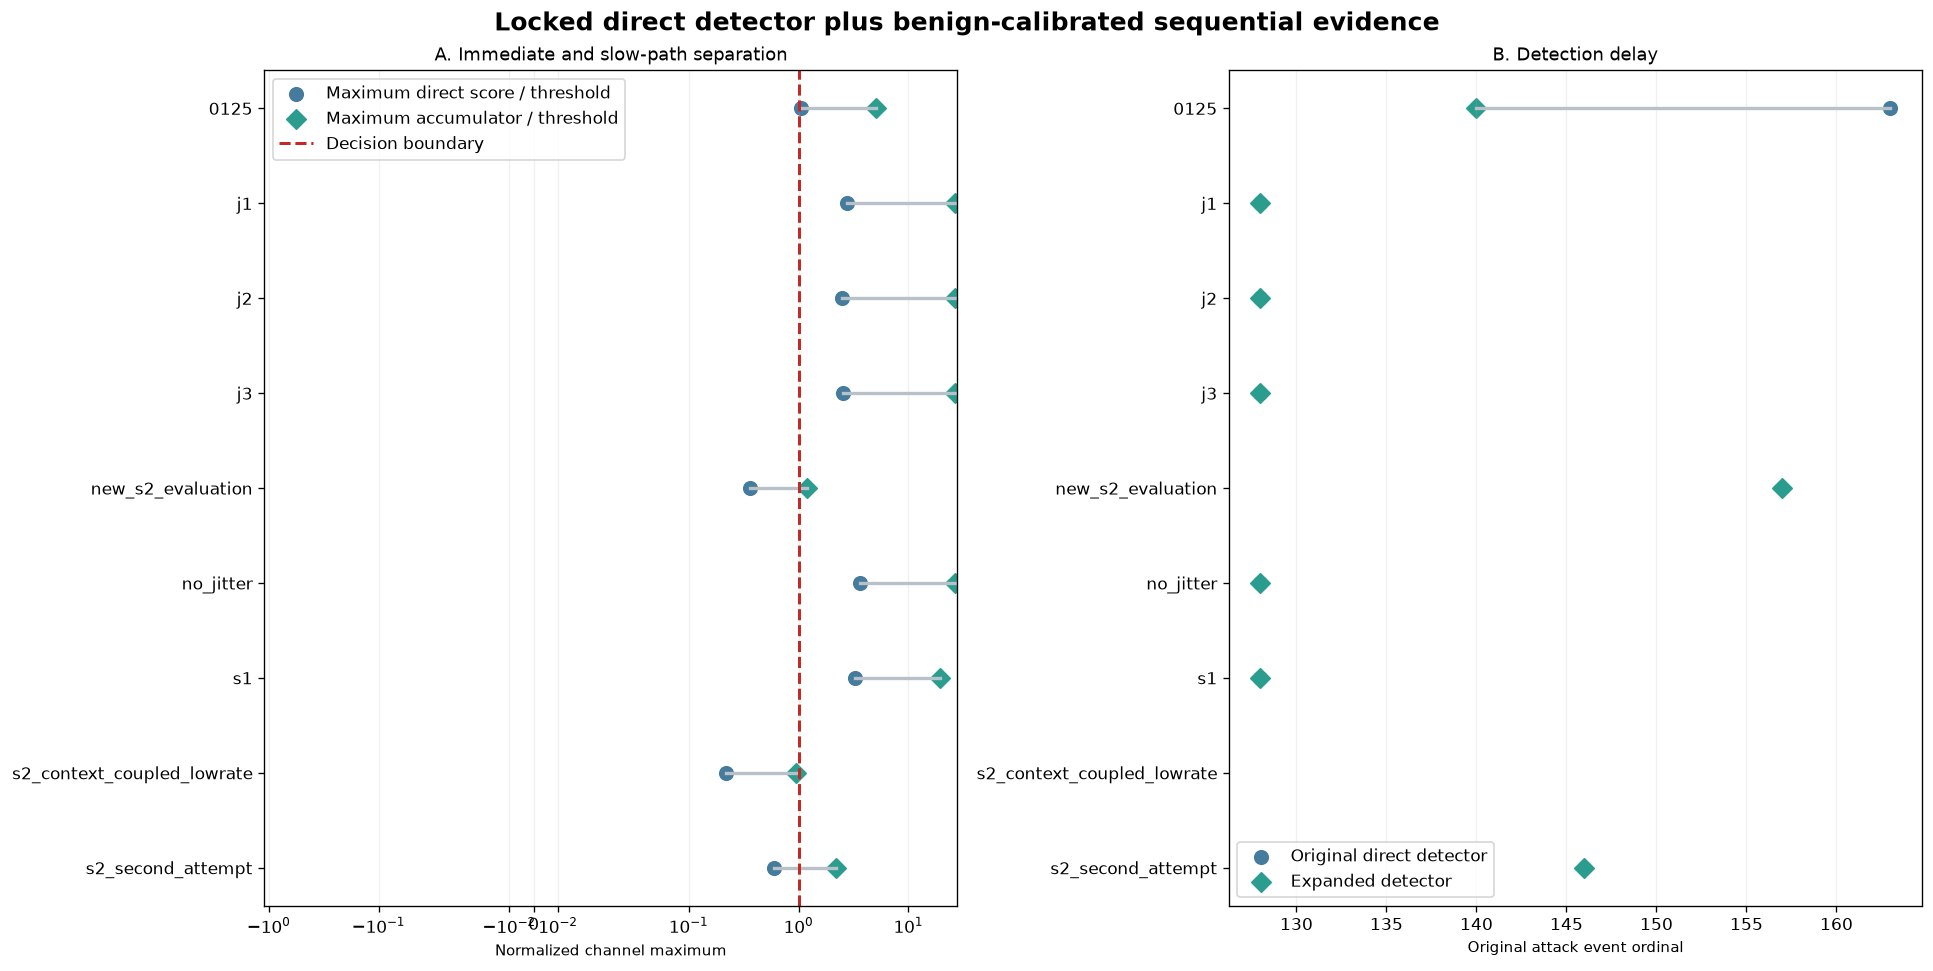

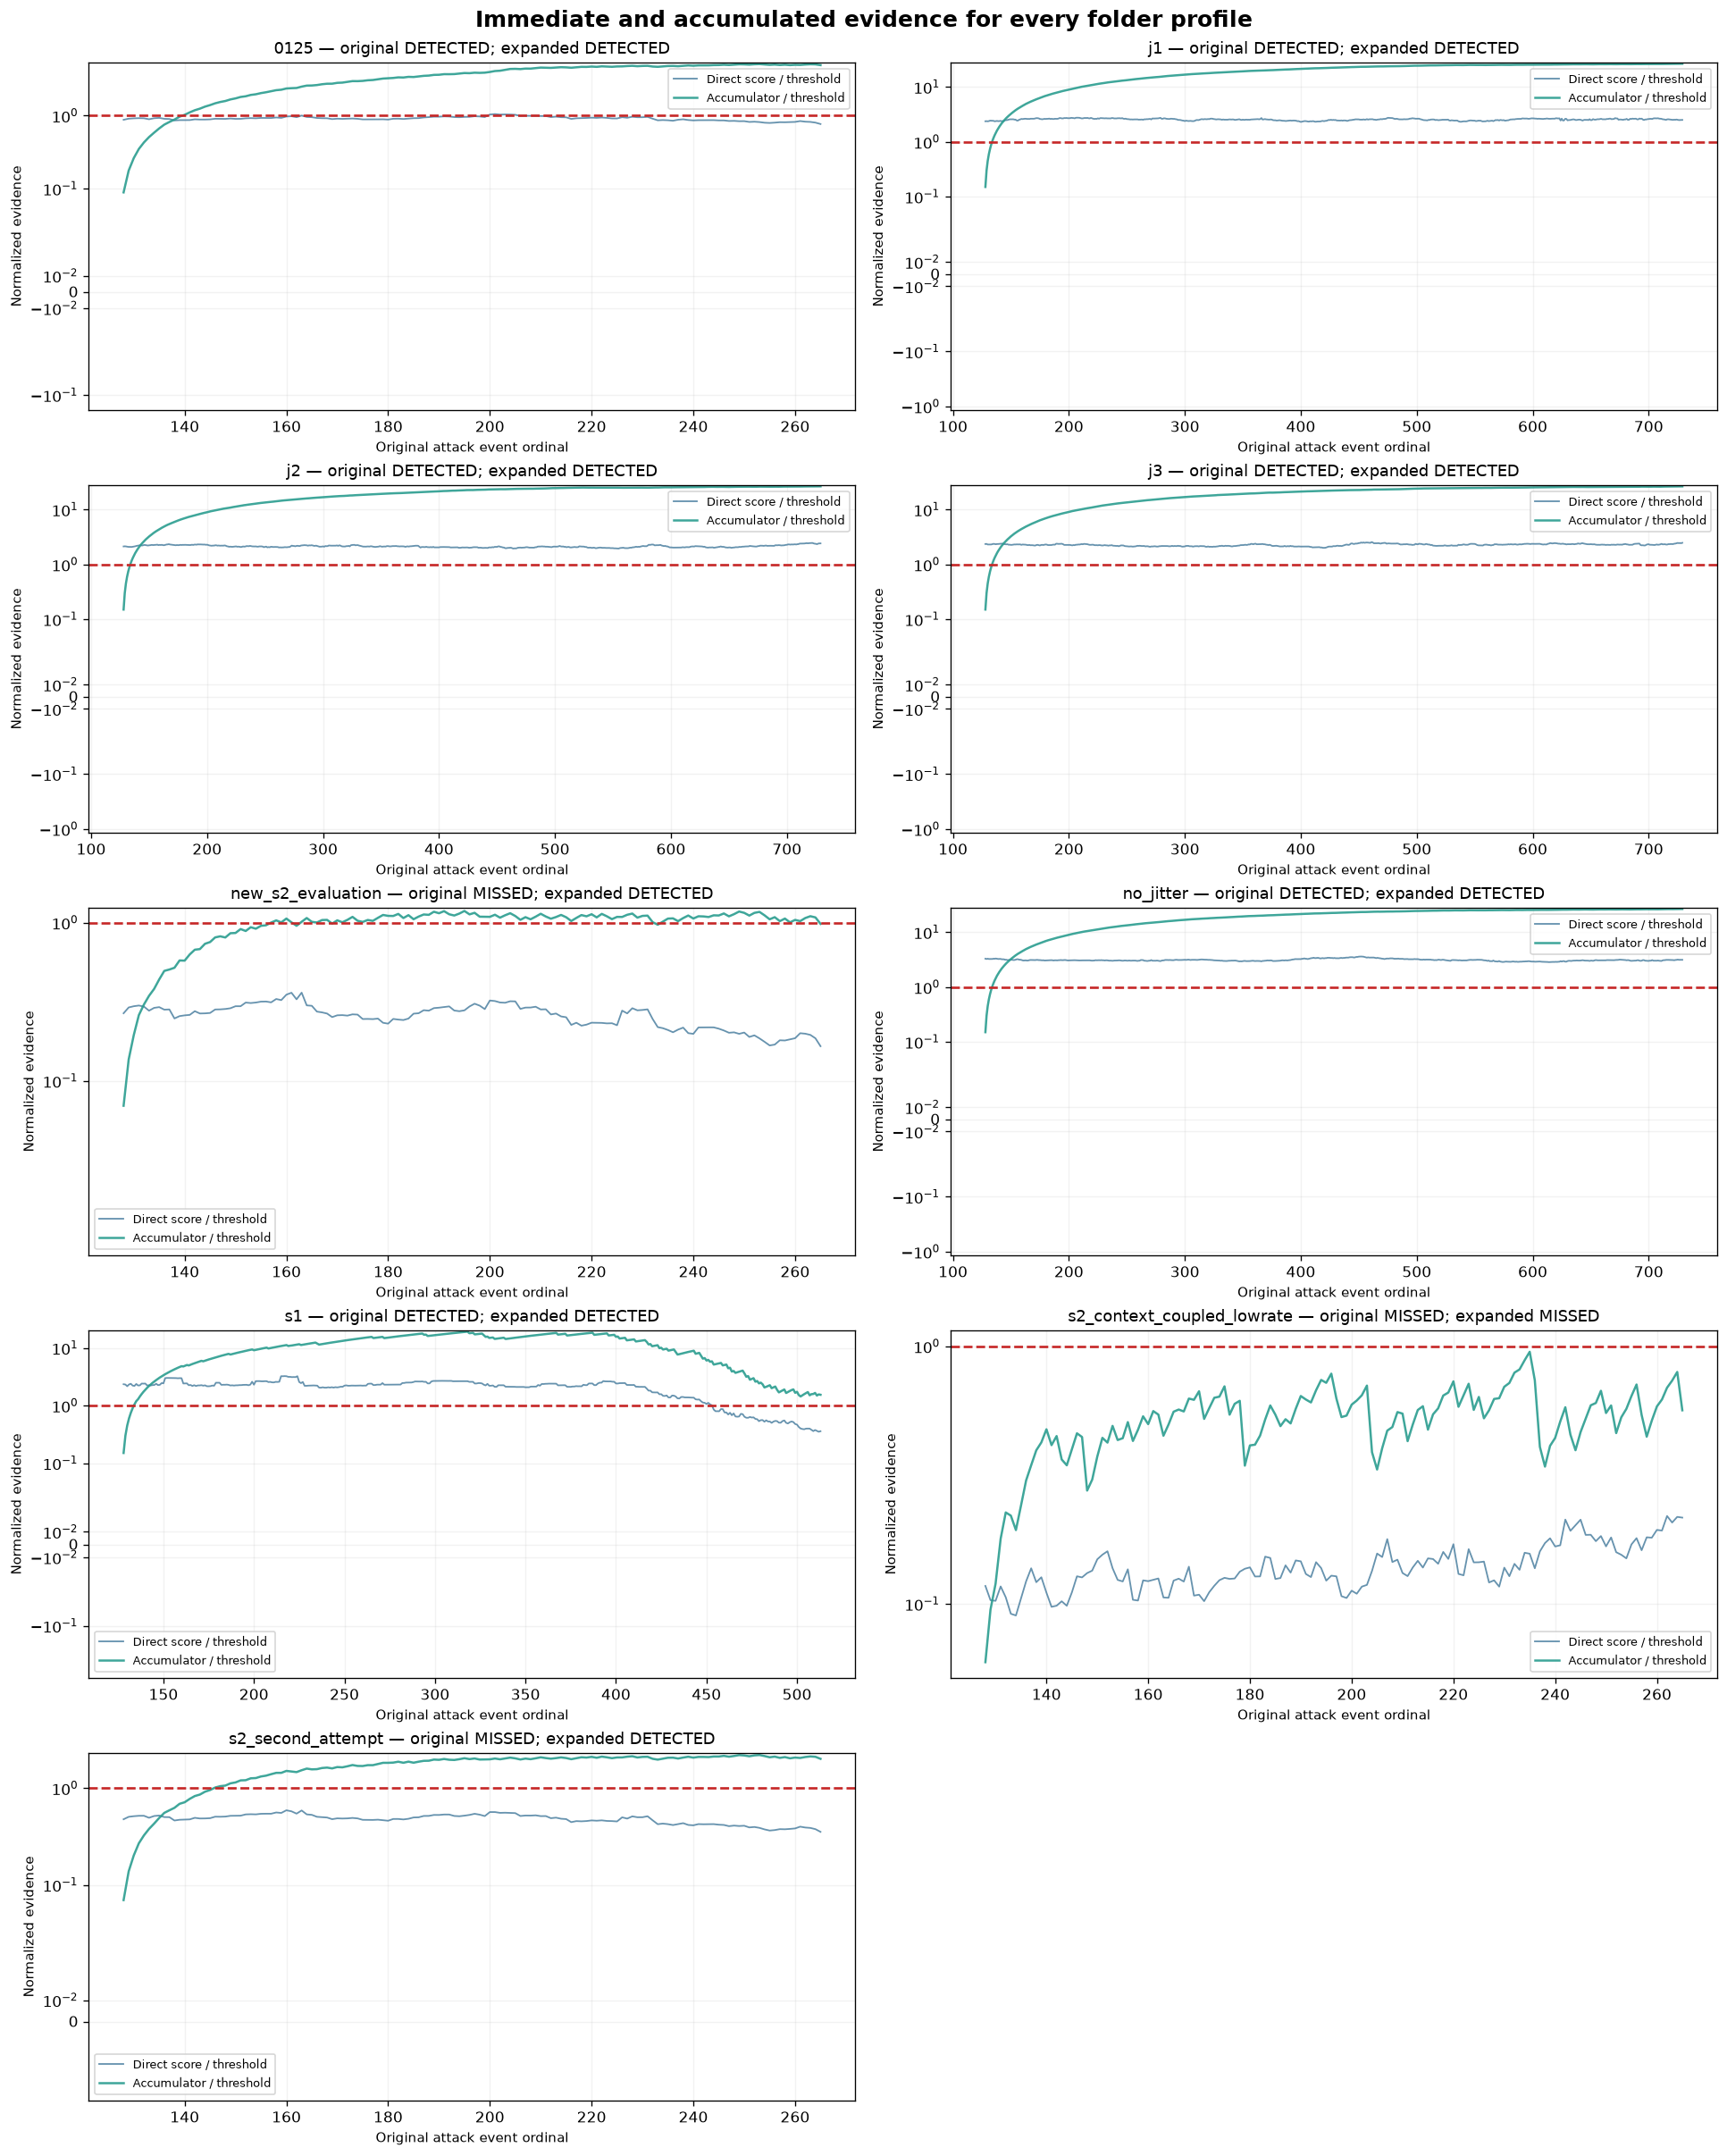


EXPANDED ATTACK EVALUATION COMPLETE
Original detected profiles: 6
Expanded detected profiles: 8
Newly detected by sequential path: ['new_s2_evaluation', 's2_second_attempt']


attack_profile,source_file,total_attack_events,scored_attack_windows,original_direct_exceedances,sequential_slow_exceedances,sequential_only_exceedances,expanded_exceedances,original_profile_detected,expanded_profile_detected,newly_detected_by_sequential_path,first_detection_path,expanded_first_detection_utc,expanded_attack_events_to_detection,expanded_seconds_to_detection,original_attack_events_to_detection,median_direct_score_to_threshold,maximum_direct_score_to_threshold,median_accumulator_to_threshold,maximum_accumulator_to_threshold
str,str,i64,i64,i64,i64,i64,i64,bool,bool,bool,str,"datetime[μs, UTC]",i64,f64,i64,f64,f64,f64,f64
"""0125""","""dns_0125.log""",265,138,7,126,119,126,true,true,false,"""sequential""",2026-07-16 19:42:45.878997 UTC,140,2121.894449,163,0.913475,1.049982,3.834689,5.071911
"""j1""","""dns_j1.log""",729,602,602,596,0,602,true,true,false,"""direct""",2026-07-16 19:17:49.233196 UTC,128,625.248648,128,2.561161,2.753159,22.447419,26.567518
"""j2""","""dns_j2.log""",729,602,602,596,0,602,true,true,false,"""direct""",2026-07-16 19:18:07.284342 UTC,128,643.299794,128,2.122789,2.464507,22.739869,26.565698
"""j3""","""dns_j3.log""",729,602,602,596,0,602,true,true,false,"""direct""",2026-07-16 19:17:53.301656 UTC,128,629.317108,128,2.28021,2.552709,22.214796,26.514495
"""new_s2_evaluation""","""dns_new_s2_evaluation.log""",265,138,0,105,105,105,false,true,true,"""sequential""",2026-07-16 21:43:14.564760 UTC,157,9350.580212,null,0.266571,0.361133,1.068295,1.184592
"""no_jitter""","""dns_no_jitter.log""",729,602,602,596,0,602,true,true,false,"""direct""",2026-07-16 19:17:54.769418 UTC,128,630.78487,128,3.081996,3.603719,22.462017,26.544594
"""s1""","""dns_s1.log""",513,386,326,380,60,386,true,true,false,"""direct""",2026-07-16 19:21:10.545161 UTC,128,826.560613,128,2.248743,3.249551,11.472884,19.23757
"""s2_context_coupled_lowrate""","""dns_s2_context_coupled_lowrate…",265,138,0,0,0,0,false,false,false,null,null,null,null,null,0.13522,0.219457,0.541772,0.951533
"""s2_second_attempt""","""dns_s2_second_attempt.log""",265,138,0,120,120,120,false,true,true,"""sequential""",2026-07-16 20:20:15.617579 UTC,146,4371.633031,null,0.488346,0.590554,1.982081,2.198946


In [35]:
# ============================================================
# SECTION 17 — EXPANDED FOLDER ATTACK EVALUATION
# ============================================================
# The original detector's gate remains enforced. The expanded path's observed
# incident rate is report-only and does not block this development evaluation.

if not bool(SEQUENTIAL_ATTACK_EVALUATION_ALLOWED):
    raise RuntimeError("Expanded attack evaluation is disabled by policy.")
if locked_attack_batch_scored_windows.height == 0:
    raise RuntimeError("No locked folder attack windows are available.")

SEQUENTIAL_ATTACK_GROUP_COLUMNS = _sequential_group_columns(
    locked_attack_batch_scored_windows,
    include_attack_profile=True,
)
expanded_attack_scored_windows = _add_sequential_evidence(
    locked_attack_batch_scored_windows,
    reference_scores=SEQUENTIAL_REFERENCE_SCORES,
    group_columns=SEQUENTIAL_ATTACK_GROUP_COLUMNS,
)
expanded_attack_scored_windows = _add_expanded_decisions(
    expanded_attack_scored_windows,
    accumulator_threshold=SEQUENTIAL_ACCUMULATOR_THRESHOLD,
)

# The injection function rigidly places each profile's first attack event at
# this timestamp. This makes expanded wall-clock delay directly auditable.
_expanded_injected_start_utc = datetime.fromtimestamp(
    float(_injected_start_us) / 1_000_000.0,
    tz=timezone.utc,
)

_expanded_attack_summary_rows = []
for _baseline_record in locked_attack_batch_summary.to_dicts():
    _profile = _baseline_record["attack_profile"]
    _profile_windows = (
        expanded_attack_scored_windows
        .filter(pl.col("attack_profile") == _profile)
        .sort(["event_time", "_source_row"], maintain_order=True)
    )
    _direct_count = int(
        _profile_windows["is_direct_threshold_exceedance"].sum()
    )
    _slow_count = int(
        _profile_windows["is_sequential_slow_exceedance"].sum()
    )
    _slow_only_count = int(
        _profile_windows.filter(
            pl.col("is_sequential_slow_exceedance")
            & ~pl.col("is_direct_threshold_exceedance")
        ).height
    )
    _expanded_count = int(
        _profile_windows["is_expanded_detector_exceedance"].sum()
    )
    _expanded_detected = bool(_expanded_count > 0)
    _expanded_flags = _profile_windows.filter(
        pl.col("is_expanded_detector_exceedance")
    )
    if _expanded_flags.height:
        _first = _expanded_flags.row(0, named=True)
        _first_detection_utc = _first["event_time"]
        _first_detection_ordinal = int(
            _first["_attack_event_ordinal"]
        )
        _seconds_to_detection = float(
            (
                _first_detection_utc
                - _expanded_injected_start_utc
            ).total_seconds()
        )
        if (
            _first["is_direct_threshold_exceedance"]
            and _first["is_sequential_slow_exceedance"]
        ):
            _first_detection_path = "direct_and_sequential"
        elif _first["is_direct_threshold_exceedance"]:
            _first_detection_path = "direct"
        else:
            _first_detection_path = "sequential"
    else:
        _first_detection_utc = None
        _first_detection_ordinal = None
        _seconds_to_detection = None
        _first_detection_path = None

    _expanded_attack_summary_rows.append(
        {
            "attack_profile": _profile,
            "source_file": _baseline_record["source_file"],
            "total_attack_events": int(
                _baseline_record["total_attack_events"]
            ),
            "scored_attack_windows": _profile_windows.height,
            "original_direct_exceedances": _direct_count,
            "sequential_slow_exceedances": _slow_count,
            "sequential_only_exceedances": _slow_only_count,
            "expanded_exceedances": _expanded_count,
            "original_profile_detected": bool(
                _baseline_record["profile_detected"]
            ),
            "expanded_profile_detected": _expanded_detected,
            "newly_detected_by_sequential_path": bool(
                _expanded_detected
                and not _baseline_record["profile_detected"]
            ),
            "first_detection_path": _first_detection_path,
            "expanded_first_detection_utc": _first_detection_utc,
            "expanded_attack_events_to_detection": (
                _first_detection_ordinal
            ),
            "expanded_seconds_to_detection": _seconds_to_detection,
            "original_attack_events_to_detection": (
                _baseline_record["attack_events_to_detection"]
            ),
            "median_direct_score_to_threshold": float(
                _profile_windows[
                    "direct_score_to_threshold"
                ].median()
            ),
            "maximum_direct_score_to_threshold": float(
                _profile_windows[
                    "direct_score_to_threshold"
                ].max()
            ),
            "median_accumulator_to_threshold": float(
                _profile_windows[
                    "sequential_accumulator_to_threshold"
                ].median()
            ),
            "maximum_accumulator_to_threshold": float(
                _profile_windows[
                    "sequential_accumulator_to_threshold"
                ].max()
            ),
        }
    )

expanded_attack_summary = (
    pl.DataFrame(
        _expanded_attack_summary_rows,
        infer_schema_length=None,
    )
    .sort("attack_profile")
)

_expanded_summary_path = (
    SEQUENTIAL_OUTPUT_DIR / "06_expanded_attack_summary.csv"
)
_expanded_scored_path = (
    SEQUENTIAL_OUTPUT_DIR / "07_expanded_attack_scored.parquet"
)
expanded_attack_summary.write_csv(_expanded_summary_path)
expanded_attack_scored_windows.write_parquet(_expanded_scored_path)

# -------------------- outcome comparison plot --------------------
_expanded_order = expanded_attack_summary["attack_profile"].to_list()
_expanded_records = {
    row["attack_profile"]: row
    for row in expanded_attack_summary.to_dicts()
}
_y = np.arange(len(_expanded_order))

_comparison_figure, _comparison_axes = plt.subplots(
    1,
    2,
    figsize=(16, max(5.5, 0.62 * len(_expanded_order) + 2.4)),
    constrained_layout=True,
)
for _index, _profile in enumerate(_expanded_order):
    _record = _expanded_records[_profile]
    _comparison_axes[0].plot(
        [
            _record["maximum_direct_score_to_threshold"],
            _record["maximum_accumulator_to_threshold"],
        ],
        [_index, _index],
        color="#B8C1C8",
        linewidth=2,
    )
_comparison_axes[0].scatter(
    [
        _expanded_records[p]["maximum_direct_score_to_threshold"]
        for p in _expanded_order
    ],
    _y,
    color="#457B9D",
    s=65,
    label="Maximum direct score / threshold",
)
_comparison_axes[0].scatter(
    [
        _expanded_records[p]["maximum_accumulator_to_threshold"]
        for p in _expanded_order
    ],
    _y,
    color="#2A9D8F",
    marker="D",
    s=68,
    label="Maximum accumulator / threshold",
)
_comparison_axes[0].axvline(
    1.0,
    color="#C62828",
    linestyle="--",
    linewidth=1.8,
    label="Decision boundary",
)
_comparison_axes[0].set_xscale("symlog", linthresh=0.05)
_comparison_axes[0].set_yticks(_y, labels=_expanded_order)
_comparison_axes[0].invert_yaxis()
_comparison_axes[0].set_xlabel("Normalized channel maximum")
_comparison_axes[0].set_title("A. Immediate and slow-path separation")
_comparison_axes[0].grid(axis="x", alpha=0.18, which="both")
_comparison_axes[0].legend()

_original_delays = []
_expanded_delays = []
for _profile in _expanded_order:
    _record = _expanded_records[_profile]
    _original_delays.append(
        float(_record["original_attack_events_to_detection"])
        if _record["original_attack_events_to_detection"] is not None
        else np.nan
    )
    _expanded_delays.append(
        float(_record["expanded_attack_events_to_detection"])
        if _record["expanded_attack_events_to_detection"] is not None
        else np.nan
    )
_comparison_axes[1].scatter(
    _original_delays,
    _y,
    color="#457B9D",
    s=65,
    label="Original direct detector",
)
_comparison_axes[1].scatter(
    _expanded_delays,
    _y,
    color="#2A9D8F",
    marker="D",
    s=68,
    label="Expanded detector",
)
for _index, (_original, _expanded) in enumerate(
    zip(_original_delays, _expanded_delays)
):
    if np.isfinite(_original) and np.isfinite(_expanded):
        _comparison_axes[1].plot(
            [_original, _expanded],
            [_index, _index],
            color="#B8C1C8",
            linewidth=2,
        )
_comparison_axes[1].set_yticks(_y, labels=_expanded_order)
_comparison_axes[1].invert_yaxis()
_comparison_axes[1].set_xlabel("Original attack event ordinal")
_comparison_axes[1].set_title("B. Detection delay")
_comparison_axes[1].grid(axis="x", alpha=0.18)
_comparison_axes[1].legend()
_comparison_figure.suptitle(
    "Locked direct detector plus benign-calibrated sequential evidence",
    fontsize=15,
    fontweight="bold",
)
_expanded_comparison_plot_path = (
    SEQUENTIAL_OUTPUT_DIR / "plot_01_expanded_detector_comparison.png"
)
_comparison_figure.savefig(
    _expanded_comparison_plot_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# -------------------- normalized two-channel trajectories --------------------
_trajectory_columns = 2 if len(_expanded_order) > 1 else 1
_trajectory_rows = int(
    math.ceil(len(_expanded_order) / _trajectory_columns)
)
_expanded_trajectory_figure, _expanded_trajectory_axes = plt.subplots(
    _trajectory_rows,
    _trajectory_columns,
    figsize=(
        16 if _trajectory_columns == 2 else 10,
        max(4.2, 4.0 * _trajectory_rows),
    ),
    squeeze=False,
    constrained_layout=True,
)
for _axis, _profile in zip(
    _expanded_trajectory_axes.flat,
    _expanded_order,
):
    _record = _expanded_records[_profile]
    _profile_windows = (
        expanded_attack_scored_windows
        .filter(pl.col("attack_profile") == _profile)
        .sort(["event_time", "_source_row"], maintain_order=True)
    )
    _x = _profile_windows["_attack_event_ordinal"].to_numpy()
    _axis.plot(
        _x,
        _profile_windows["direct_score_to_threshold"].to_numpy(),
        color="#457B9D",
        linewidth=1.1,
        alpha=0.82,
        label="Direct score / threshold",
    )
    _axis.plot(
        _x,
        _profile_windows[
            "sequential_accumulator_to_threshold"
        ].to_numpy(),
        color="#2A9D8F",
        linewidth=1.5,
        alpha=0.9,
        label="Accumulator / threshold",
    )
    _axis.axhline(
        1.0,
        color="#C62828",
        linestyle="--",
        linewidth=1.6,
    )
    _axis.set_yscale("symlog", linthresh=0.05)
    _axis.set_title(
        f"{_profile} — original "
        f"{'DETECTED' if _record['original_profile_detected'] else 'MISSED'}; "
        f"expanded "
        f"{'DETECTED' if _record['expanded_profile_detected'] else 'MISSED'}"
    )
    _axis.set_xlabel("Original attack event ordinal")
    _axis.set_ylabel("Normalized evidence")
    _axis.grid(alpha=0.16, which="both")
    _axis.legend(fontsize=8)
for _axis in list(_expanded_trajectory_axes.flat)[len(_expanded_order):]:
    _axis.set_visible(False)
_expanded_trajectory_figure.suptitle(
    "Immediate and accumulated evidence for every folder profile",
    fontsize=15,
    fontweight="bold",
)
_expanded_trajectory_plot_path = (
    SEQUENTIAL_OUTPUT_DIR
    / "plot_02_expanded_detector_trajectories.png"
)
_expanded_trajectory_figure.savefig(
    _expanded_trajectory_plot_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("\n" + "=" * 92)
print("EXPANDED ATTACK EVALUATION COMPLETE")
print("=" * 92)
print(
    "Original detected profiles: "
    f"{int(expanded_attack_summary['original_profile_detected'].sum())}"
)
print(
    "Expanded detected profiles: "
    f"{int(expanded_attack_summary['expanded_profile_detected'].sum())}"
)
print(
    "Newly detected by sequential path: "
    f"{expanded_attack_summary.filter(pl.col('newly_detected_by_sequential_path'))['attack_profile'].to_list()}"
)
display(expanded_attack_summary)


In [36]:
# ============================================================
# SECTION 18 — FINAL INTEGRITY GATES, MANIFEST AND RESULTS BUNDLE
# ============================================================

_baseline_profile_decisions = {
    row["attack_profile"]: bool(row["profile_detected"])
    for row in locked_attack_batch_summary.to_dicts()
}
_reconstructed_direct_decisions = {
    profile: bool(
        expanded_attack_scored_windows
        .filter(pl.col("attack_profile") == profile)
        ["is_direct_threshold_exceedance"]
        .any()
    )
    for profile in expanded_attack_summary["attack_profile"].to_list()
}
_direct_decisions_unchanged = bool(
    _baseline_profile_decisions == _reconstructed_direct_decisions
)
_profile_coverage_complete = bool(
    set(expanded_attack_summary["attack_profile"].to_list())
    == set(locked_attack_batch_summary["attack_profile"].to_list())
)

sequential_final_integrity_gates = pl.DataFrame(
    [
        {
            "gate_name": "locked model identity retained",
            "status": (
                "PASS"
                if RESULTS_CANDIDATE_ID
                == SEQUENTIAL_EXPECTED_CANDIDATE_ID
                else "FAIL"
            ),
            "observed": RESULTS_CANDIDATE_ID,
        },
        {
            "gate_name": "locked direct threshold retained",
            "status": (
                "PASS"
                if np.isclose(
                    RESULTS_THRESHOLD,
                    SEQUENTIAL_EXPECTED_LOCKED_THRESHOLD,
                    rtol=1e-12,
                    atol=1e-12,
                )
                else "FAIL"
            ),
            "observed": f"{RESULTS_THRESHOLD:.12f}",
        },
        {
            "gate_name": "original folder decisions reconstruct exactly",
            "status": (
                "PASS" if _direct_decisions_unchanged else "FAIL"
            ),
            "observed": str(_reconstructed_direct_decisions),
        },
        {
            "gate_name": "sequential calibration is benign only",
            "status": "PASS",
            "observed": (
                "empirical reference and q99.9 accumulator threshold "
                "from result_split=calibration"
            ),
        },
        {
            "gate_name": "locked direct detector benign budget retained",
            "status": (
                "PASS"
                if SEQUENTIAL_DIRECT_BASELINE_BUDGET_PASS
                else "FAIL"
            ),
            "observed": (
                f"direct={RESULTS_OBSERVED_INCIDENT_RATE:.6f}/day; "
                f"budget={SEQUENTIAL_FALSE_INCIDENT_BUDGET_PER_DAY:.6f}/day"
            ),
        },
        {
            "gate_name": "expanded incident rate is report-only",
            "status": "PASS",
            "observed": (
                f"{SEQUENTIAL_VALIDATION_INCIDENTS_PER_DAY:.6f}/day; "
                "attack evaluation remains enabled"
            ),
        },
        {
            "gate_name": "all folder profiles evaluated",
            "status": (
                "PASS" if _profile_coverage_complete else "FAIL"
            ),
            "observed": str(
                expanded_attack_summary["attack_profile"].to_list()
            ),
        },
        {
            "gate_name": "current attacks remain development data",
            "status": "PASS",
            "observed": (
                "0.125/0.25/0.50 and earlier profiles are not final holdouts"
            ),
        },
    ],
    infer_schema_length=None,
)
_all_sequential_final_gates_pass = bool(
    sequential_final_integrity_gates
    .select((pl.col("status") == "PASS").all())
    .item()
)

_sequential_final_gates_path = (
    SEQUENTIAL_OUTPUT_DIR / "08_final_integrity_gates.csv"
)
sequential_final_integrity_gates.write_csv(
    _sequential_final_gates_path
)

_sequential_manifest = {
    "analysis_version": SEQUENTIAL_EXPANSION_VERSION,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "output_directory": str(SEQUENTIAL_OUTPUT_DIR),
    "baseline": {
        "candidate_id": RESULTS_CANDIDATE_ID,
        "window_size_events": RESULTS_WINDOW_SIZE,
        "features": RESULTS_FEATURES,
        "feature_count": len(RESULTS_FEATURES),
        "direct_threshold": RESULTS_THRESHOLD,
        "direct_threshold_comparison": "score > threshold",
        "model_refit_performed": False,
        "feature_reweighting_performed": False,
        "direct_threshold_changed": False,
    },
    "sequential_extension": {
        "reference": "benign calibration Mahalanobis scores",
        "upper_tail_probability": "smoothed empirical survival function",
        "evidence_start_tail_probability": (
            SEQUENTIAL_EVIDENCE_START_TAIL_PROBABILITY
        ),
        "decay_minutes": SEQUENTIAL_DECAY_MINUTES,
        "accumulator_threshold_quantile": (
            SEQUENTIAL_CALIBRATION_QUANTILE
        ),
        "accumulator_threshold_method": (
            SEQUENTIAL_THRESHOLD_METHOD
        ),
        "accumulator_threshold": (
            SEQUENTIAL_ACCUMULATOR_THRESHOLD
        ),
        "decision": (
            "direct exceedance OR sequential accumulator exceedance"
        ),
        "attack_data_used_for_calibration": False,
    },
    "benign_validation": {
        "wall_days": SEQUENTIAL_VALIDATION_WALL_DAYS,
        "locked_direct_incidents_per_day": (
            RESULTS_OBSERVED_INCIDENT_RATE
        ),
        "locked_direct_budget_per_day": (
            SEQUENTIAL_FALSE_INCIDENT_BUDGET_PER_DAY
        ),
        "locked_direct_budget_pass": (
            SEQUENTIAL_DIRECT_BASELINE_BUDGET_PASS
        ),
        "expanded_incidents": SEQUENTIAL_VALIDATION_INCIDENTS,
        "expanded_incidents_per_day": (
            SEQUENTIAL_VALIDATION_INCIDENTS_PER_DAY
        ),
        "expanded_budget_enforced": False,
        "expanded_budget_diagnostic_pass": (
            SEQUENTIAL_BENIGN_BUDGET_DIAGNOSTIC_PASS
        ),
    },
    "attack_results": expanded_attack_summary.to_dicts(),
    "scientific_status": (
        "attack-informed development; fresh benign and attack holdouts "
        "required after freezing"
    ),
    "integrity_pass": _all_sequential_final_gates_pass,
}
_sequential_manifest_path = (
    SEQUENTIAL_OUTPUT_DIR / "run_manifest.json"
)
_sequential_manifest_path.write_text(
    json.dumps(_sequential_manifest, indent=2, default=str),
    encoding="utf-8",
)

_newly_detected_profiles = expanded_attack_summary.filter(
    pl.col("newly_detected_by_sequential_path")
)["attack_profile"].to_list()
_sequential_readme = f"""# Expanded sequential DNS timing detector v1.3.1

## Locked immediate path

- Candidate: `{RESULTS_CANDIDATE_ID}`
- Window: `{RESULTS_WINDOW_SIZE}` same-parent-domain events
- Features: `{len(RESULTS_FEATURES)}` causal content-free timing features
- Direct threshold: `{RESULTS_THRESHOLD:.12f}`
- Baseline model/feature/threshold changes: **none**

## New slow path

- Evidence reference: benign calibration scores only
- Evidence-start tail probability: `{SEQUENTIAL_EVIDENCE_START_TAIL_PROBABILITY}`
- Time decay: `{SEQUENTIAL_DECAY_MINUTES:.1f}` minutes
- Accumulator threshold: `{SEQUENTIAL_ACCUMULATOR_THRESHOLD:.12f}`
- Threshold rule: benign q99.9, method `higher`
- Final decision: direct exceedance OR accumulator exceedance

## Benign development validation

- Exposure: `{SEQUENTIAL_VALIDATION_WALL_DAYS:.6f}` days
- Locked direct incidents/day: `{RESULTS_OBSERVED_INCIDENT_RATE:.6f}`
- Locked direct budget: `{SEQUENTIAL_FALSE_INCIDENT_BUDGET_PER_DAY:.6f}`/day — retained
- Expanded incidents: `{SEQUENTIAL_VALIDATION_INCIDENTS}`
- Expanded incidents/day: `{SEQUENTIAL_VALIDATION_INCIDENTS_PER_DAY:.6f}`
- Expanded hard budget: **not enforced**
- Expanded rate role: reported operating trade-off

## Development attack evaluation

- Original detected profiles: `{int(expanded_attack_summary['original_profile_detected'].sum())}`
- Expanded detected profiles: `{int(expanded_attack_summary['expanded_profile_detected'].sum())}`
- Newly detected by the sequential path: `{_newly_detected_profiles}`

## Scientific boundary

The current folder attacks, including the S2 0.125/0.25/0.50 boundary series,
are development profiles because they motivated this architecture. After this
extension is frozen, new captures with unseen seeds, payloads and start times
are required for final evaluation.
"""
_sequential_readme_path = (
    SEQUENTIAL_OUTPUT_DIR / "README.md"
)
_sequential_readme_path.write_text(
    _sequential_readme,
    encoding="utf-8",
)

_sequential_bundle_members = [
    _sequential_config_path,
    _sequential_benign_summary_path,
    _sequential_benign_gates_path,
    _sequential_calibration_scored_path,
    _sequential_validation_scored_path,
    _expanded_summary_path,
    _expanded_scored_path,
    _sequential_final_gates_path,
    _expanded_comparison_plot_path,
    _expanded_trajectory_plot_path,
    _sequential_manifest_path,
    _sequential_readme_path,
]
_sequential_bundle_path = (
    SEQUENTIAL_OUTPUT_DIR
    / "dns_timing_expanded_sequential_results_v1_3_1.zip"
)
with zipfile.ZipFile(
    _sequential_bundle_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as _archive:
    for _member in _sequential_bundle_members:
        if _member.exists():
            _archive.write(_member, arcname=_member.name)

print("\n" + "=" * 92)
print("EXPANDED SEQUENTIAL DETECTOR — FINAL GATES")
print("=" * 92)
display(sequential_final_integrity_gates)
print(
    "Overall integrity: "
    f"{'PASS' if _all_sequential_final_gates_pass else 'FAIL'}"
)
print(f"Output directory: {SEQUENTIAL_OUTPUT_DIR}")
print(f"Results bundle: {_sequential_bundle_path}")
print(
    "Claim boundary: attack-informed development; fresh independent "
    "holdouts remain mandatory."
)

if not _all_sequential_final_gates_pass:
    raise RuntimeError(
        "One or more final sequential-detector integrity gates failed."
    )



EXPANDED SEQUENTIAL DETECTOR — FINAL GATES


gate_name,status,observed
str,str,str
"""locked model identity retained""","""PASS""","""w64__baseline+regularity+local…"
"""locked direct threshold retain…","""PASS""","""216.140237928340"""
"""original folder decisions reco…","""PASS""","""{'0125': True, 'j1': True, 'j2…"
"""sequential calibration is beni…","""PASS""","""empirical reference and q99.9 …"
"""locked direct detector benign …","""PASS""","""direct=0.000000/day; budget=0.…"
"""expanded incident rate is repo…","""PASS""","""0.179510/day; attack evaluatio…"
"""all folder profiles evaluated""","""PASS""","""['0125', 'j1', 'j2', 'j3', 'ne…"
"""current attacks remain develop…","""PASS""","""0.125/0.25/0.50 and earlier pr…"


Overall integrity: PASS
Output directory: /home/notevenknow/Desktop/jupyter_lab/Data/outputs_locked_attack_folder_v1_2_1/run_20260804T151804Z/expanded_sequential_detector_v1_3_1
Results bundle: /home/notevenknow/Desktop/jupyter_lab/Data/outputs_locked_attack_folder_v1_2_1/run_20260804T151804Z/expanded_sequential_detector_v1_3_1/dns_timing_expanded_sequential_results_v1_3_1.zip
Claim boundary: attack-informed development; fresh independent holdouts remain mandatory.


## Section 19 — How to interpret the expanded result

The direct Mahalanobis channel remains the primary high-confidence detector.
The expanded development result is useful when all three conditions hold:

1. the original direct detector and its strict benign budget remain unchanged;
2. the expanded incident rate is reported transparently as an operational
   trade-off rather than used as a blocking gate;
3. at least one slower S2 profile is detected through persistent accumulated
   evidence rather than by lowering the direct threshold.

If S2 0.25 becomes detected while the benign gate remains at zero incidents,
the result supports the paper's central mechanism: sustained sequences of
moderate timing anomalies contain operationally useful evidence even when no
individual window is sufficiently extreme. If S2 0.50 remains missed, that is
a measured sensitivity boundary—not a notebook failure.

Do not tune `p0`, `tau`, the accumulator quantile or the feature vector after
viewing these attack results. Freeze the expansion and validate it on newly
captured S2 profiles with unseen seeds, payloads and start times.
